In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
from matplotlib.gridspec import GridSpec
from scipy.signal import savgol_filter
from pathlib import Path

# store plastic slip rates and temperatures
data = []
maxout = 1000

# plot function for stress and pile-up dislocations
def plot_stress_bfield(npt = 300, file=None, cutoff=100.):
    xpts = np.linspace(0.0, dsl.lx, npt)
    ypts = np.linspace(0.0, dsl.ly, npt)
    XP, YP = np.meshgrid(xpts, ypts)
    s12 = np.zeros((npt, npt), dtype=np.float64)
    for i in range(dsl.Ntot):
        s12 += dsl.bx[i] * dsl.sig_xy(XP - dsl.xpos[i], YP - dsl.ypos[i])
        s12 -= dsl.by[i] * dsl.sig_xy(YP - dsl.ypos[i], XP - dsl.xpos[i])
    extent = (0.0, dsl.lx, 0.0, dsl.ly)
    
    #fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 12), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)
    fig = plt.figure(figsize=(12, 9))
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.0)
    # -----------------------------
    # upper plot: stress field and dislocations
    # -----------------------------
    ax1 = fig.add_subplot(gs[0])
    #ax1.xaxis.set_label_position('top')
    #ax1.set_xlabel(r"x ($\mu$m)")
    ax1.xaxis.tick_top()
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_ylabel(r"y ($\mu$m)")
    im = ax1.imshow(s12, origin="lower", extent=extent,
        vmin=-cutoff, vmax=cutoff, cmap=plt.cm.RdBu, aspect="equal")
    ax1.scatter(dsl.xpos[:npu], dsl.ypos[:npu], s=10, c="yellow", marker="o")
    cbar = fig.colorbar(im, ax=ax1, pad=0.08)
    #cbar.set_label(r"$\sigma_{12}$ (MPa)")
    cbar.ax.set_title(r"$\sigma_{12}$ (MPa)")
    
    # -----------------------------
    # Lower Plot: b-field
    # -----------------------------
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.plot(dsl.xpos[npu:], dsl.by[npu:], lw=2)  #color=plt.cm.viridis(0)
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylim(0., dsl.by[npu:].max())
    ax2.invert_yaxis()
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    ax2.set_position([
        pos1.x0,
        pos2.y0,
        pos1.width,
        pos2.height
    ])
    ax2.set_ylabel(r"$b_y \, / \, B$")
    ax2.set_xlabel(r"x ($\mu$m)")
    ax2.yaxis.set_label_position('right')
    ax2.yaxis.tick_right()
    if file is not None:
        plt.savefig(file, dpi=300)
    plt.show()

def find_h5_files(directory: str | Path, recursive: bool = False) -> list[Path]:
    """
    Find all .h5 files in a directory.

    Parameters
    ----------
    directory : str | Path
        Directory to search.
    recursive : bool, optional
        If True, search recursively in subdirectories.

    Returns
    -------
    list[Path]
        Sorted list of .h5 files.
    """
    path = Path(directory)

    if not path.is_dir():
        raise NotADirectoryError(f"Not a directory: {path}")

    pattern = "**/*.h5" if recursive else "*.h5"

    return sorted(path.glob(pattern))

def eps_dot(sig, temp, gs):
    Dgb = 10.  # micron^2/micro s
    delta = 0.5  # e-3
    om = 0.25**3  # e-3 **3
    kb = 1.380649e-5  # e-23 / e-6 (tau0) e-3 (delta) e-9 (om)
    ed = 148. * sig * Dgb * delta * om / (gs**3 * kb * temp)
    return ed

Data file with H=10.0, L=0.1, T=1000.0, tau0=150.0, n=24


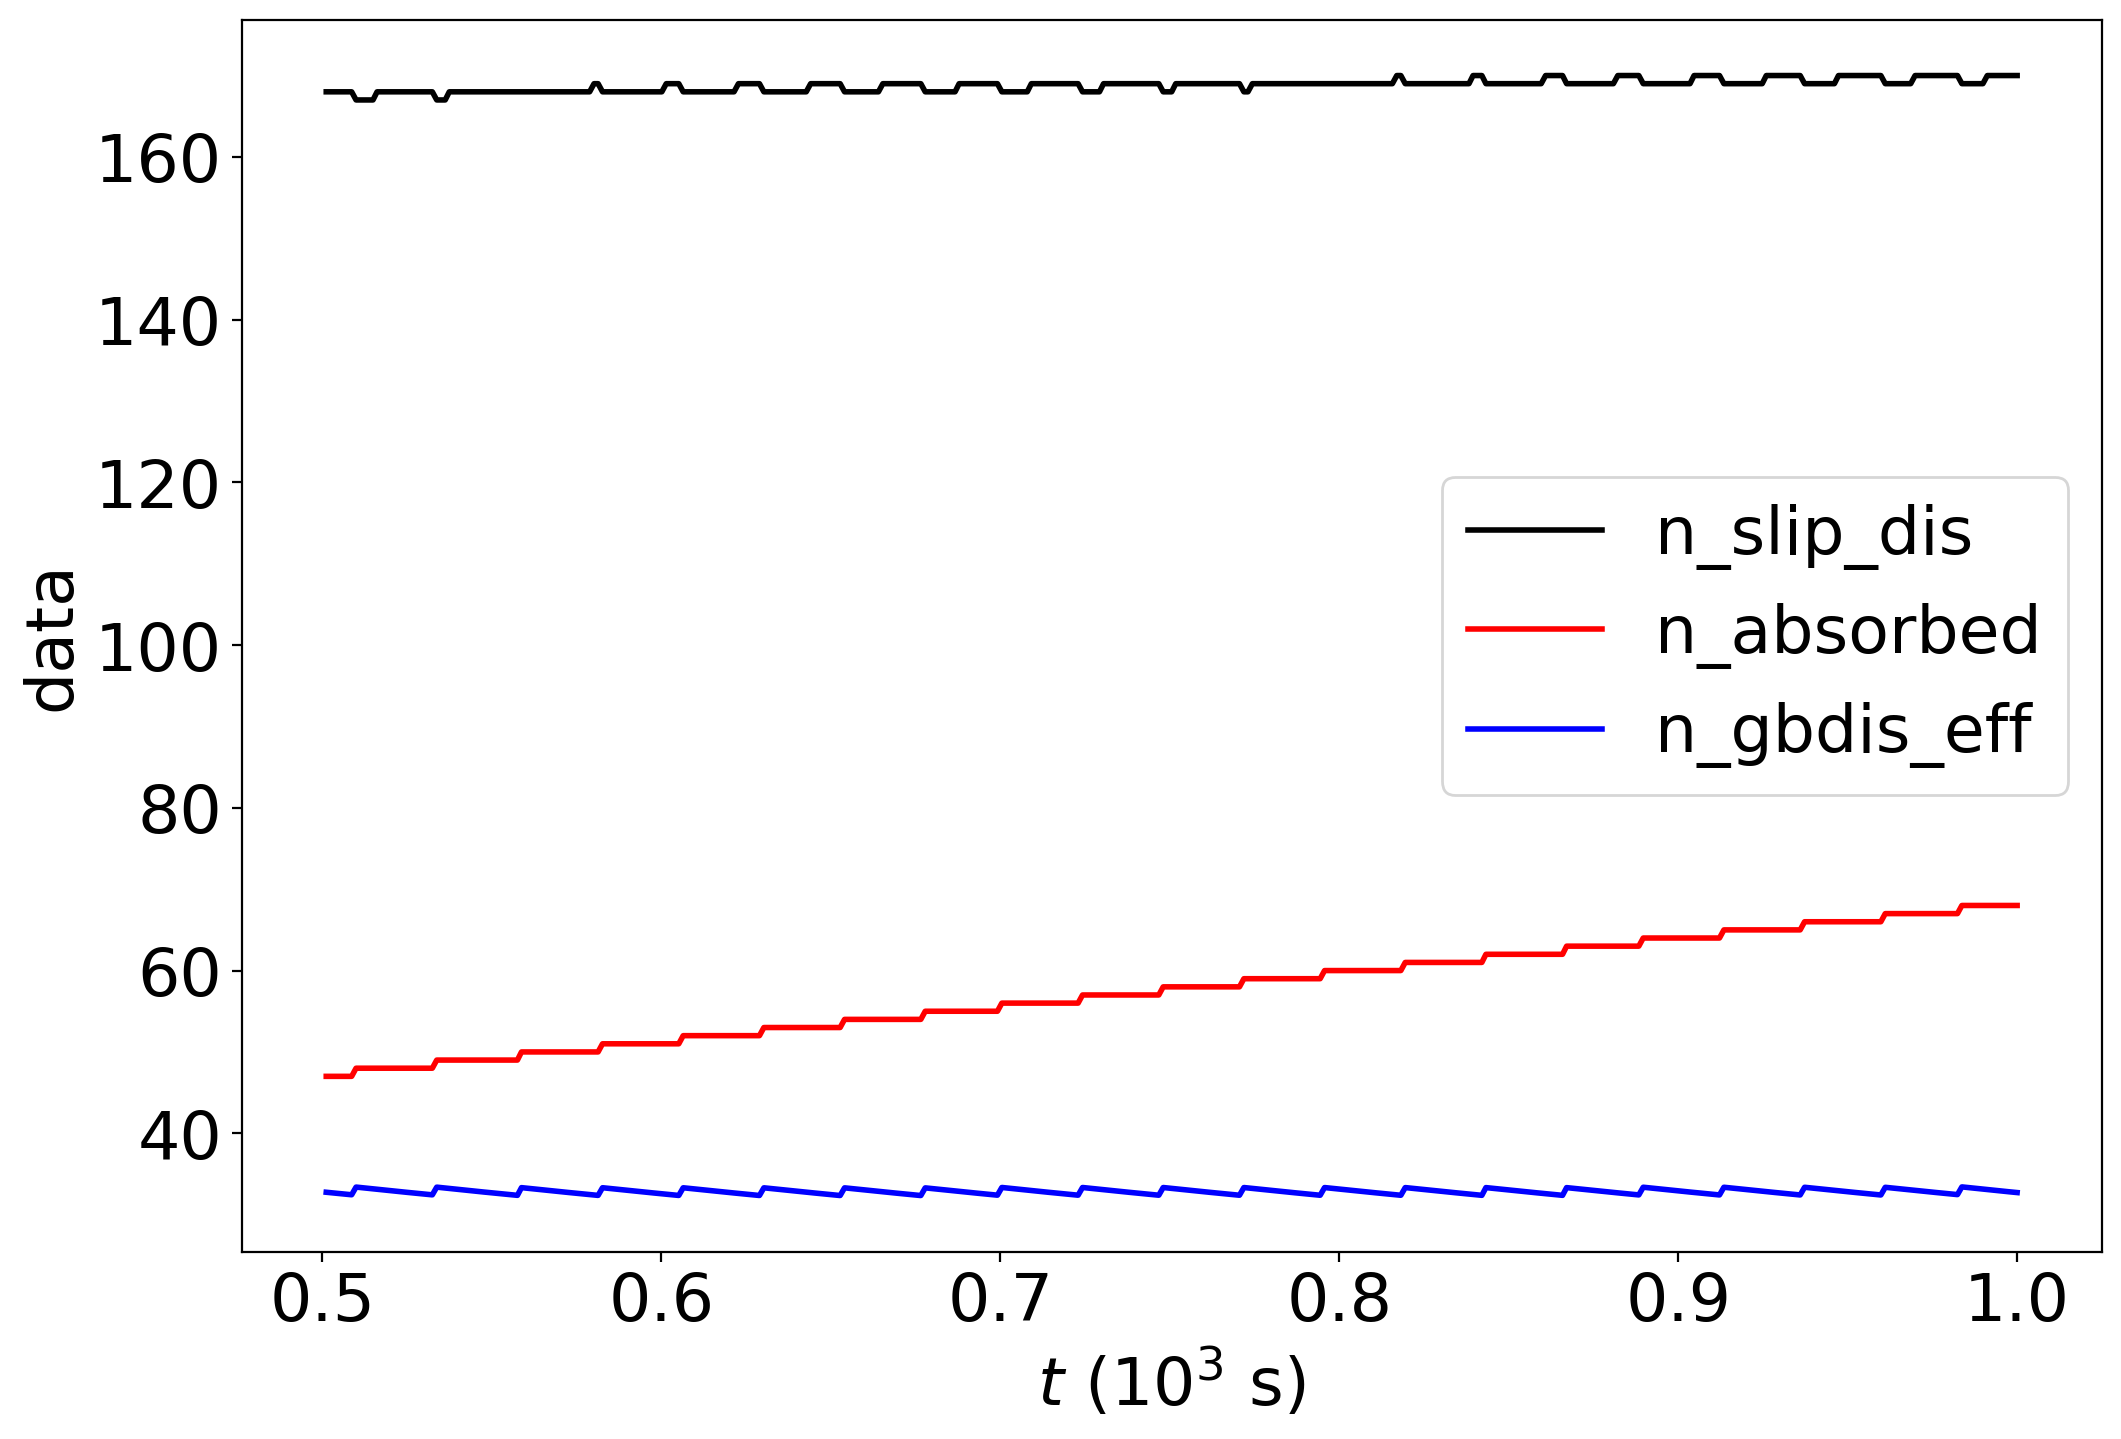

** Max. time step = 1296.4598378442363, Median: 1059.5742059078848
Av. slip rate: 1.1176136292505081e-10, Nslip: 169.52, Ngb_eff: 32.89259501533348
*** hvar, hist *** 1.0 (array([48, 52]), array([169. , 169.5, 170. ]))
Data file with H=10.0, L=0.3, T=1000.0, tau0=150.0, n=74


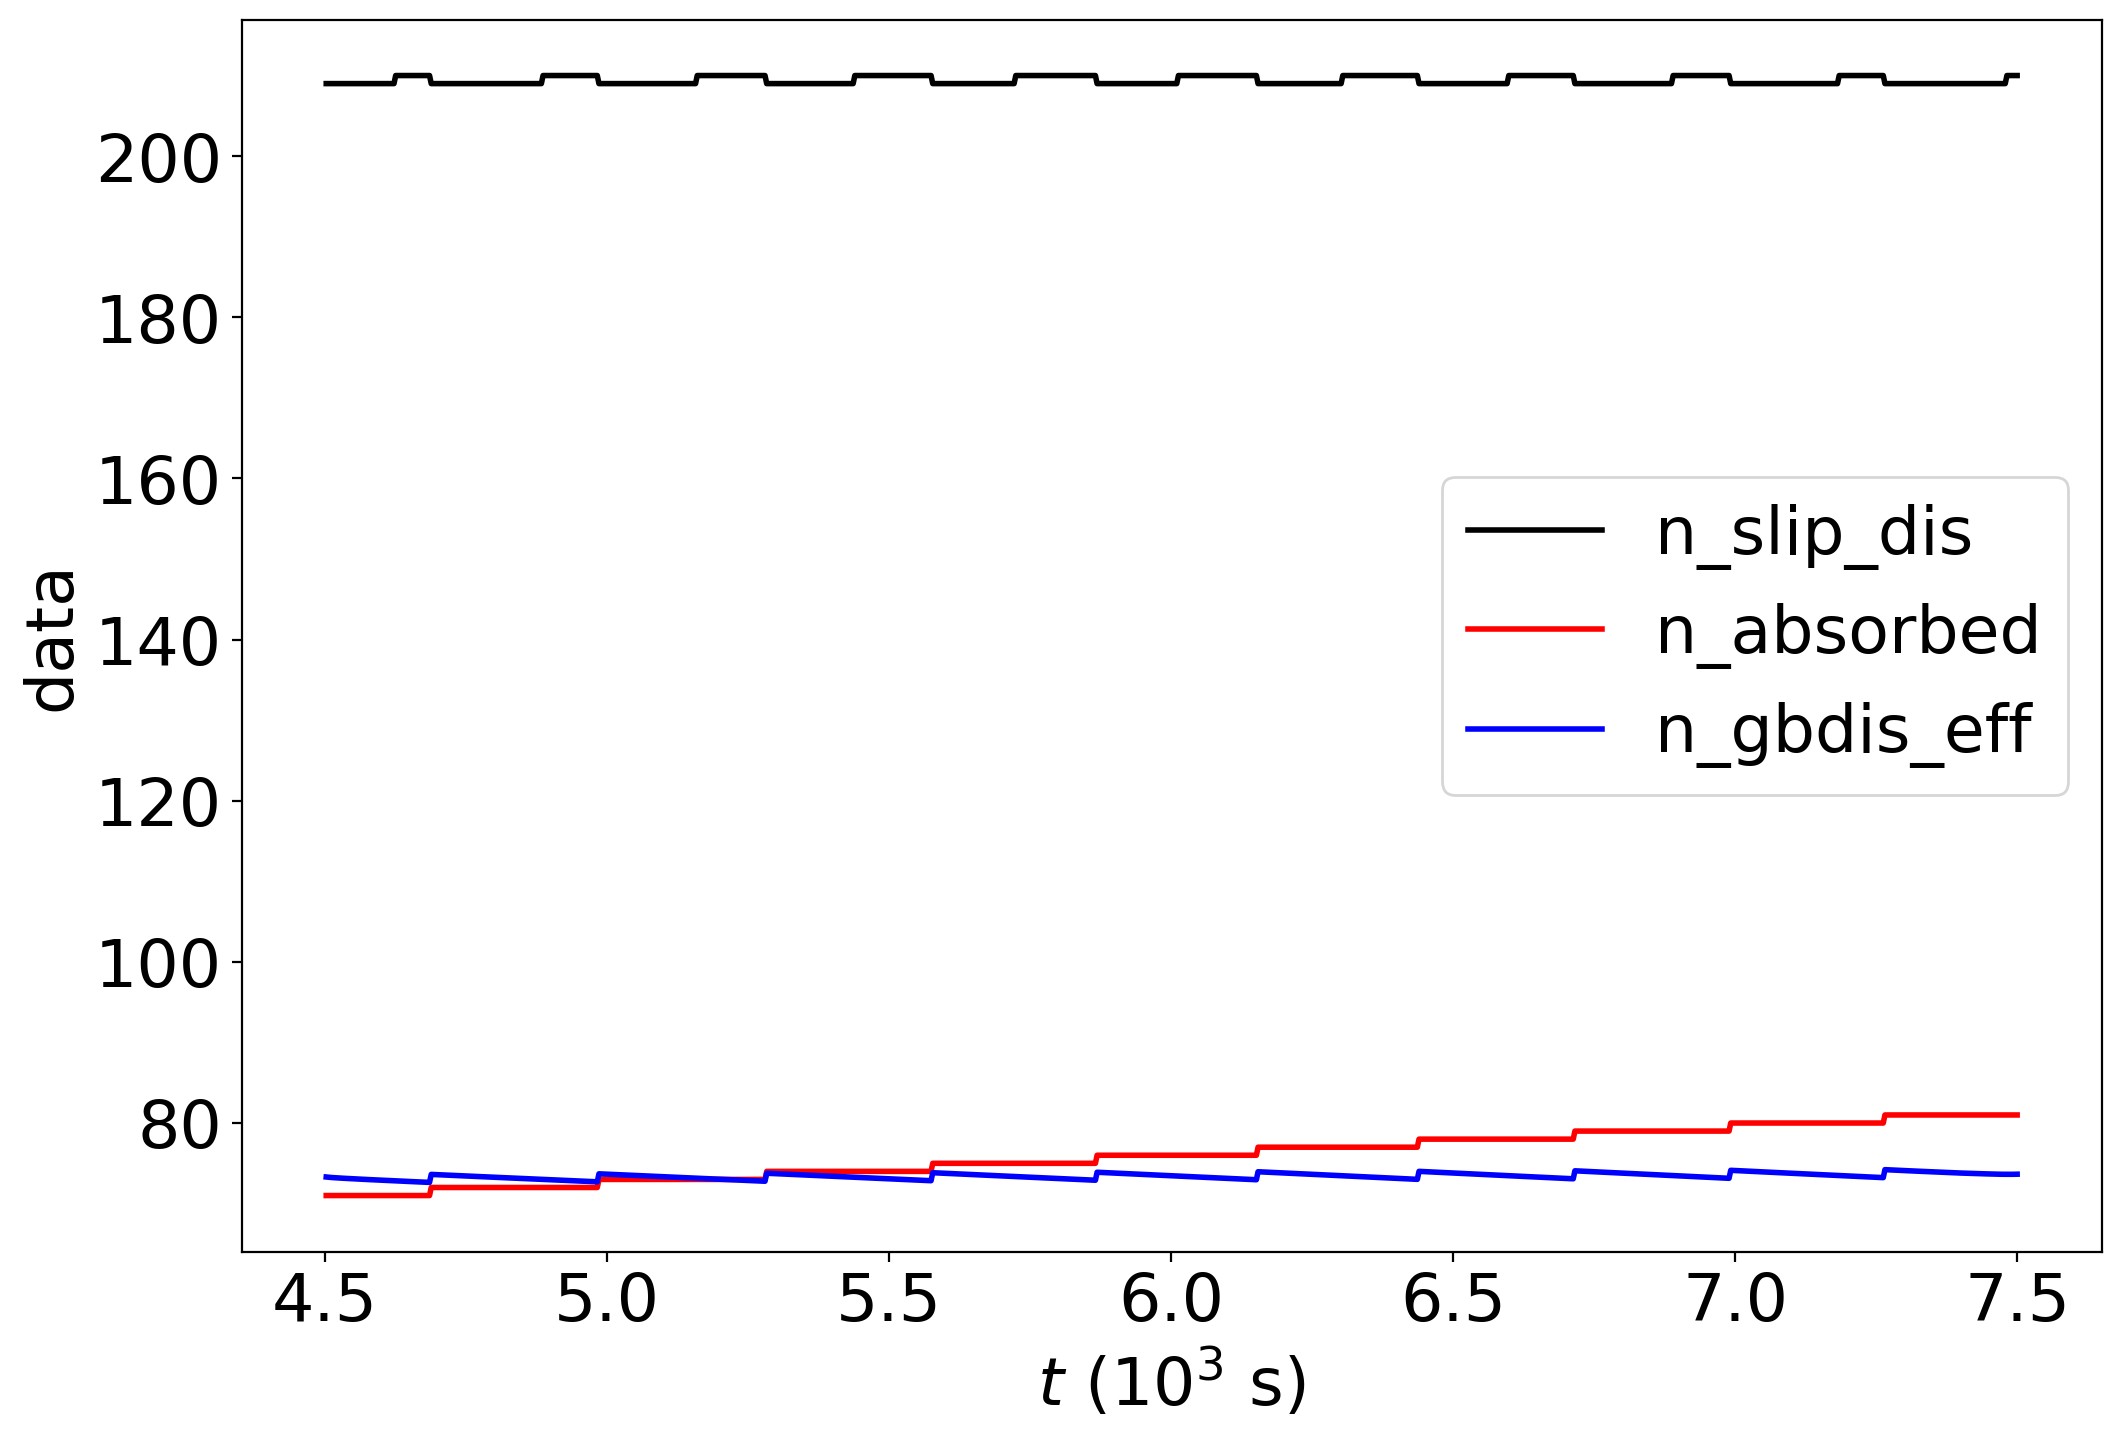

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.8132819084774407e-12, Nslip: 209.28, Ngb_eff: 73.75190369364904
*** hvar, hist *** 1.0 (array([72, 28]), array([209. , 209.5, 210. ]))
Data file with H=1.0, L=0.1, T=1000.0, tau0=150.0, n=24


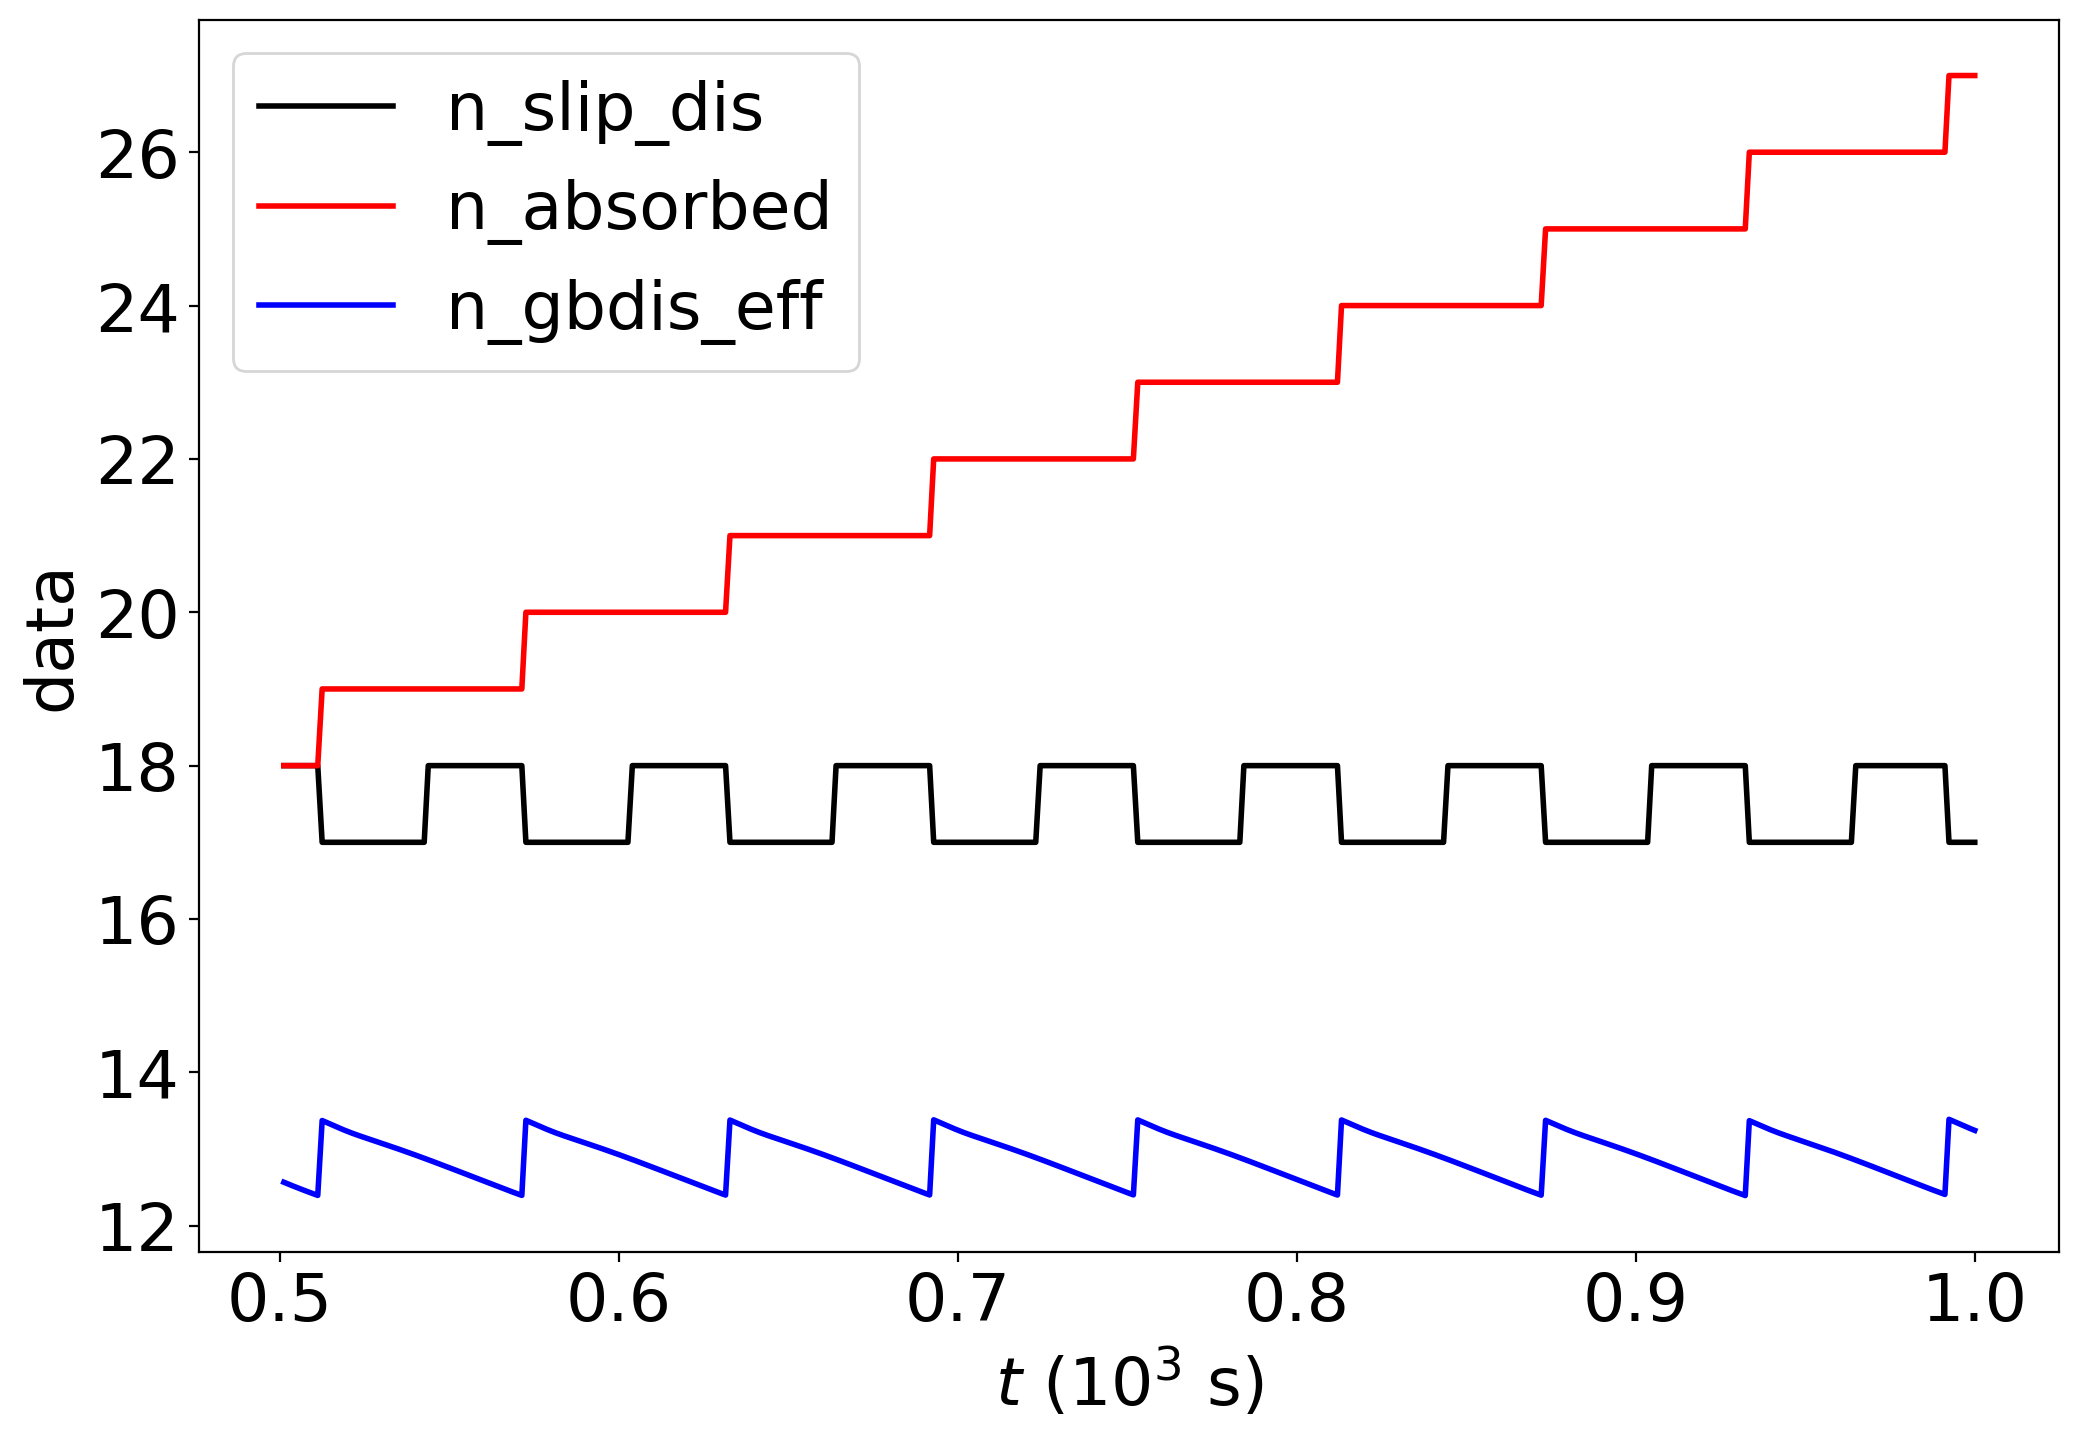

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 4.184847390216326e-11, Nslip: 17.45, Ngb_eff: 12.906146120243038
*** hvar, hist *** 1.0 (array([55, 45]), array([17. , 17.5, 18. ]))
Data file with H=1.0, L=0.3, T=1000.0, tau0=150.0, n=74


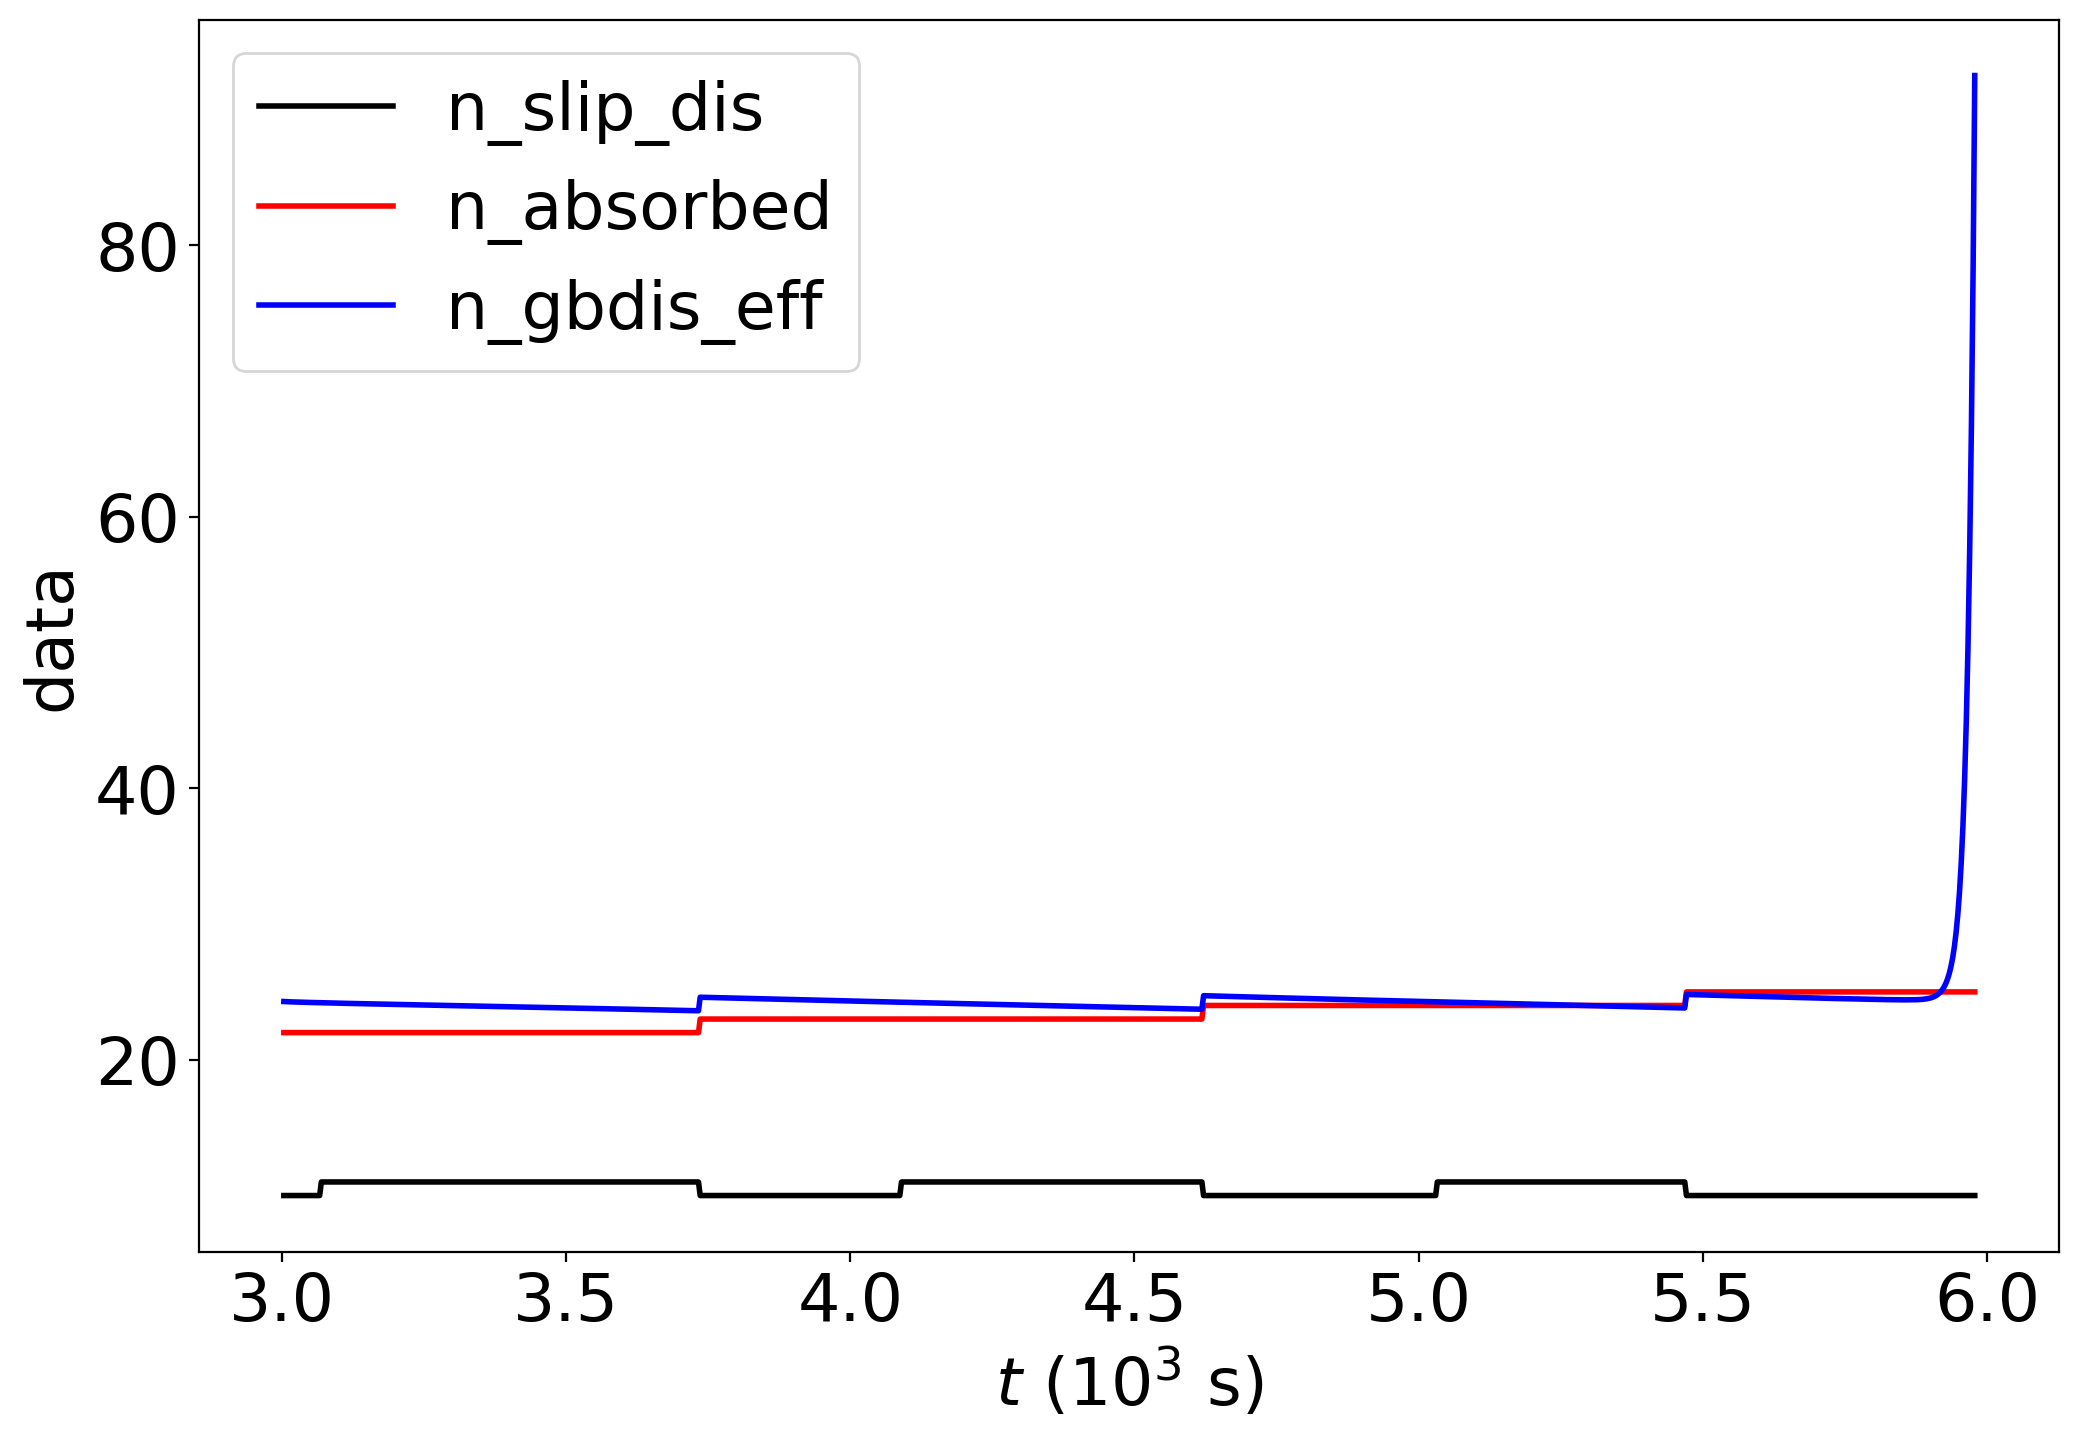

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -7.599066497619643e-12, Nslip: 10.0, Ngb_eff: 27.663730708167513
*** hvar, hist *** 0.0 (array([100]), array([ 9.5, 10.5]))
Data file with H=30.0, L=0.1, T=1000.0, tau0=150.0, n=24


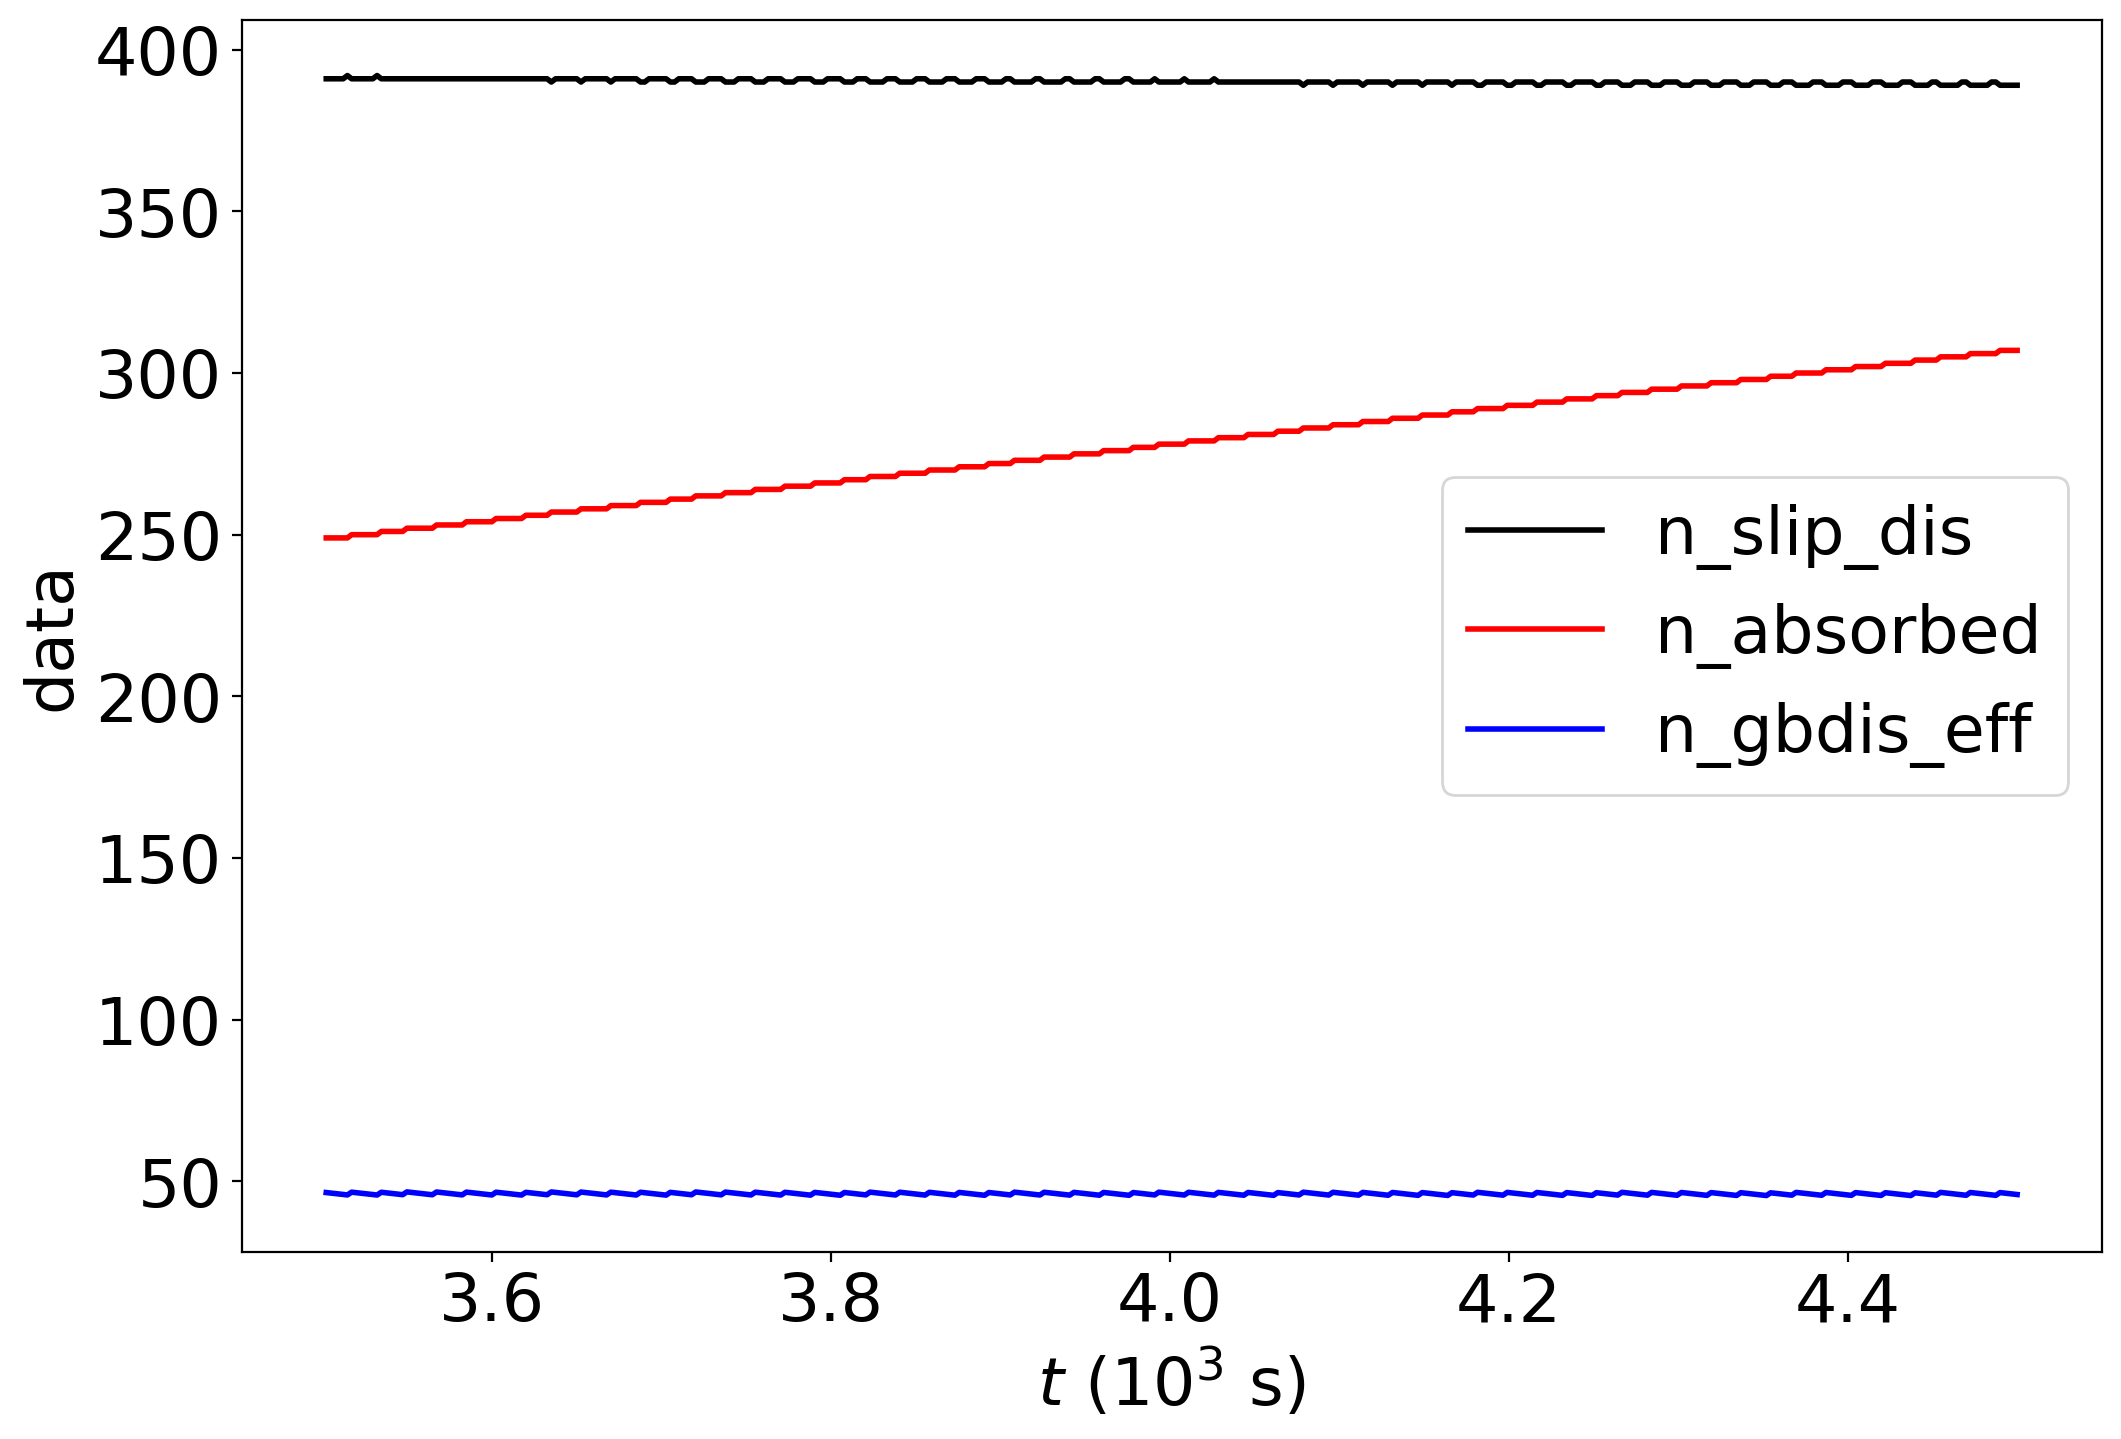

** Max. time step = 849.8163951570258, Median: 695.7160296651784
Av. slip rate: 1.425638371038098e-10, Nslip: 389.45, Ngb_eff: 46.106241031203254
*** hvar, hist *** 1.0 (array([55, 45]), array([389. , 389.5, 390. ]))
Data file with H=30.0, L=0.3, T=1000.0, tau0=150.0, n=74


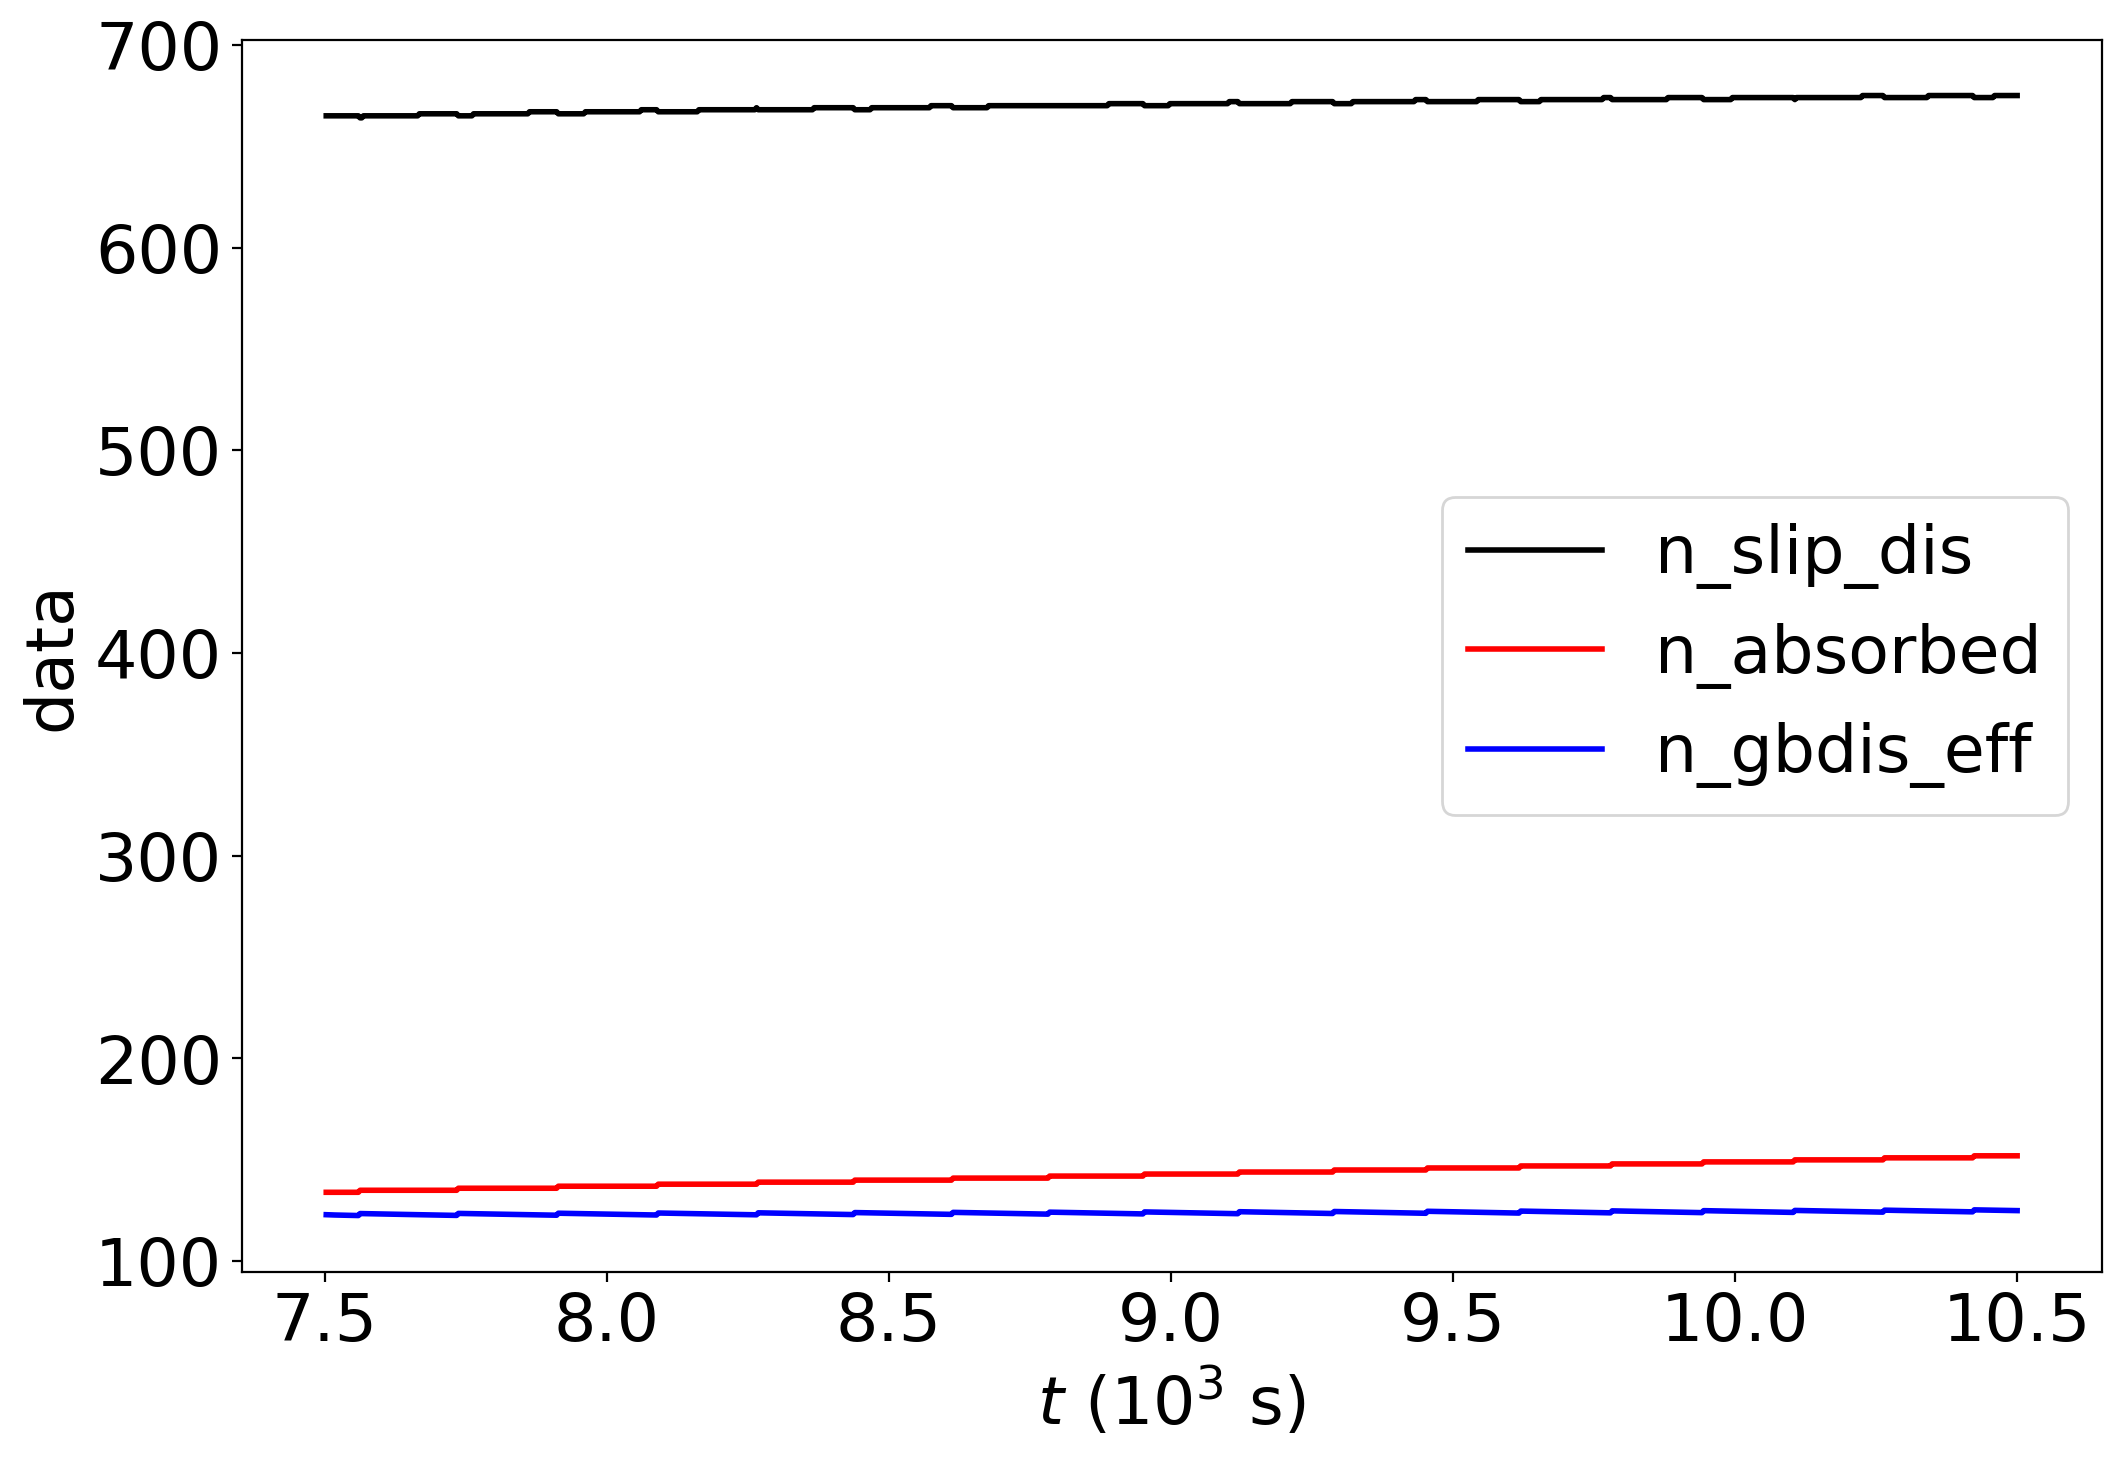

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 6.331953338217921e-12, Nslip: 674.54, Ngb_eff: 124.78386018380311
*** hvar, hist *** 1.0 (array([46, 54]), array([674. , 674.5, 675. ]))
Data file with H=3.0, L=0.1, T=1000.0, tau0=150.0, n=24


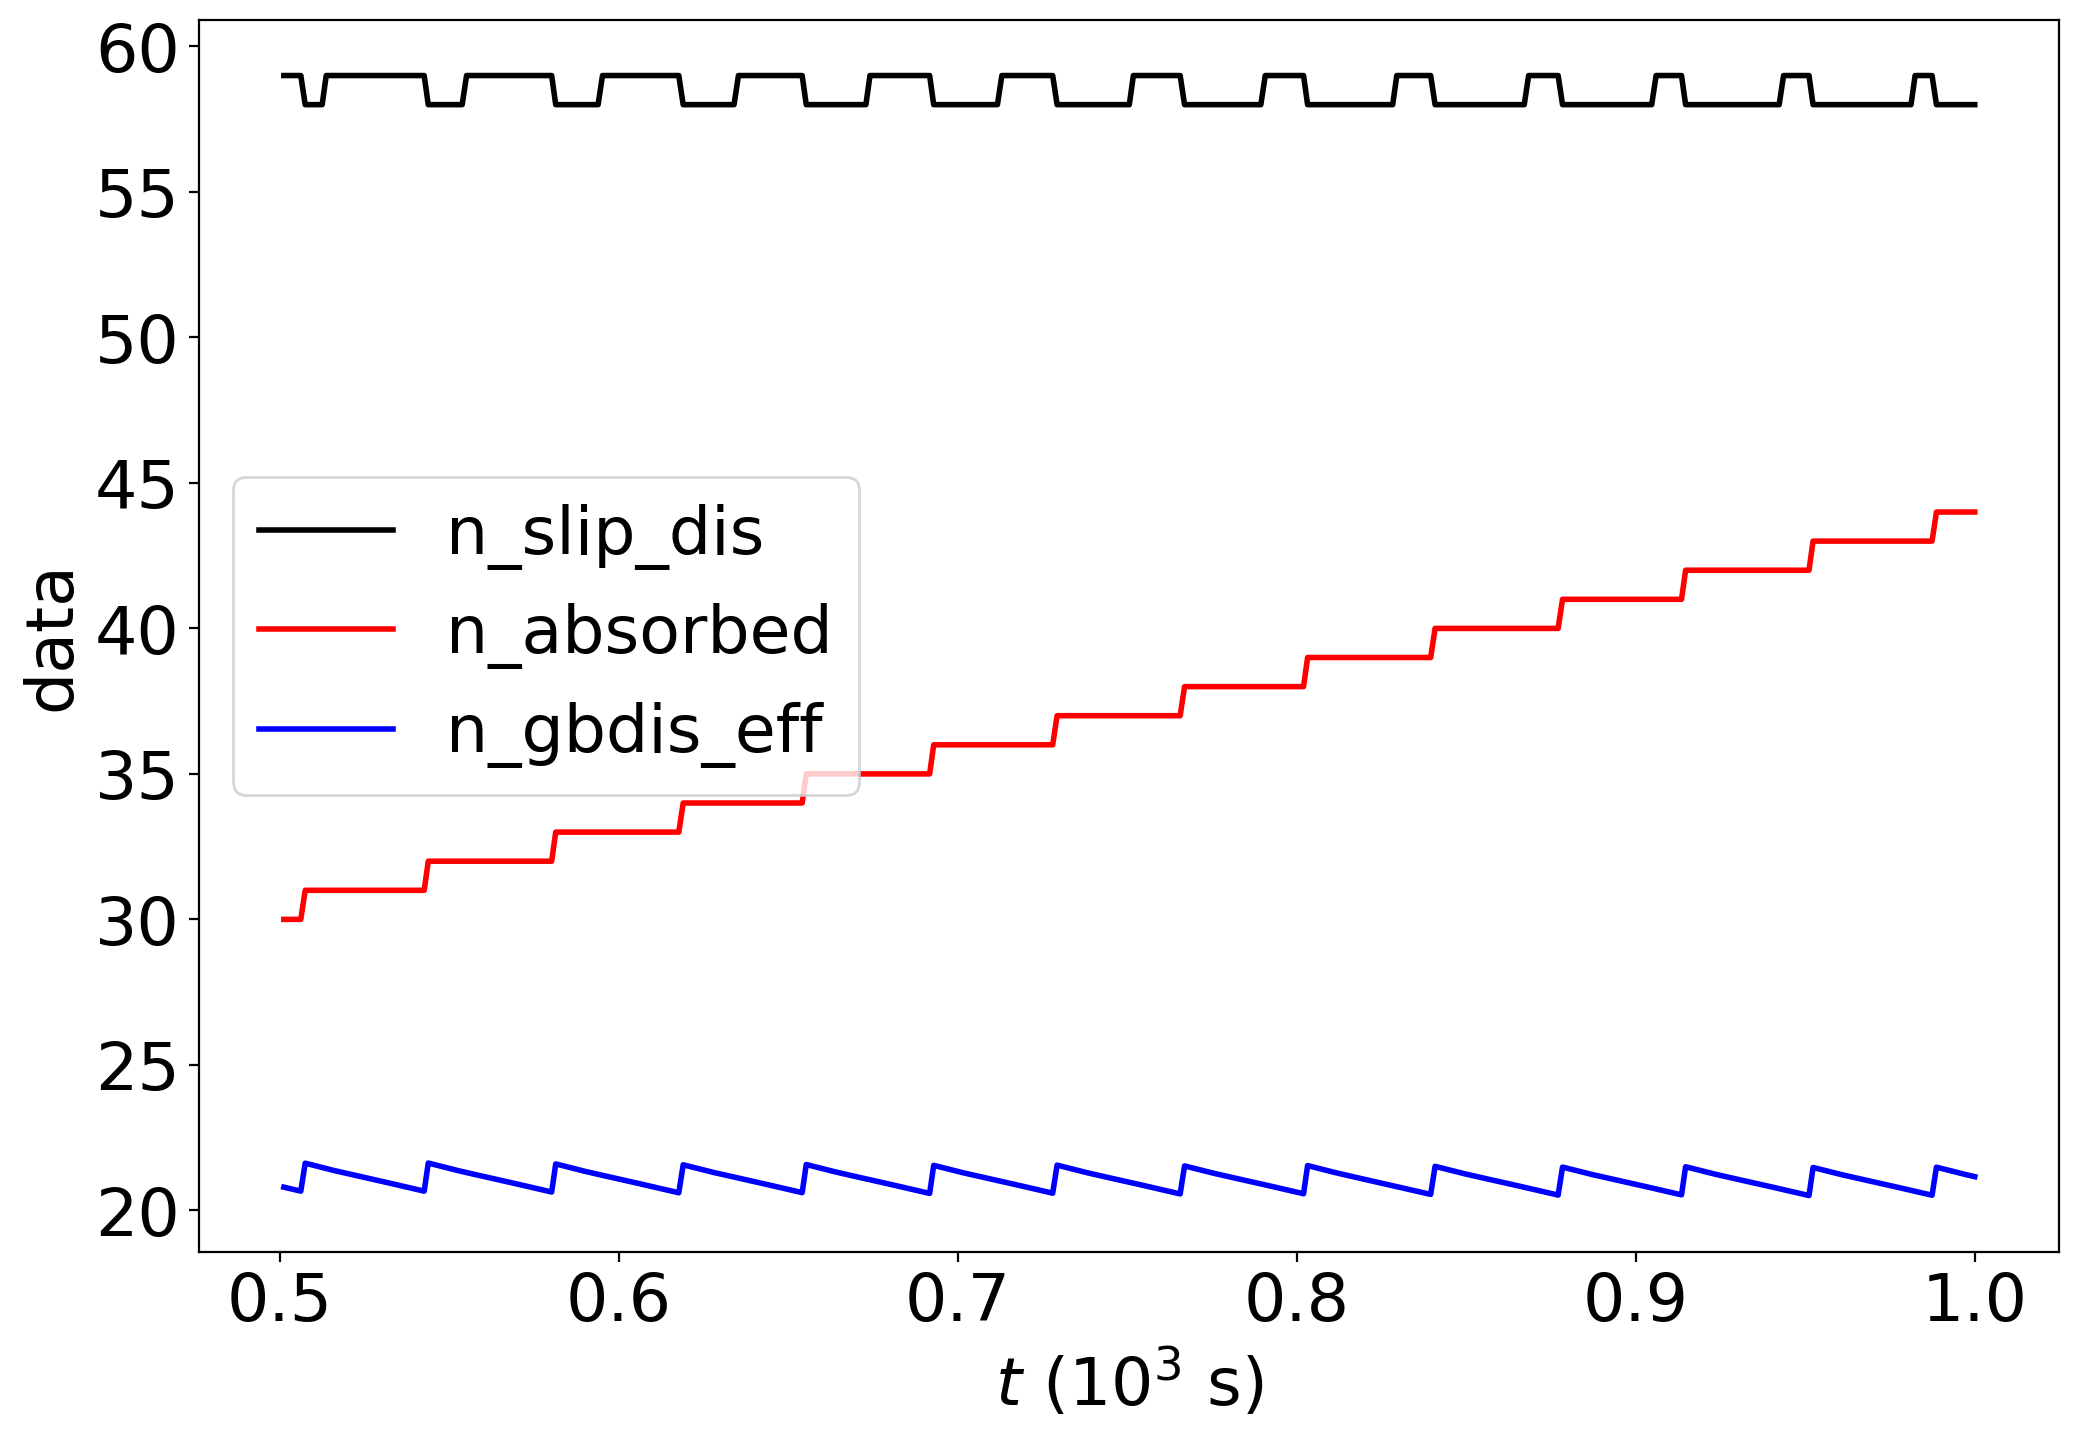

** Max. time step = 2256.5129296096948, Median: 1824.5896189638277
Av. slip rate: 6.687749267388381e-11, Nslip: 58.21, Ngb_eff: 21.019388817010473
*** hvar, hist *** 1.0 (array([79, 21]), array([58. , 58.5, 59. ]))
Data file with H=3.0, L=0.3, T=1000.0, tau0=150.0, n=74


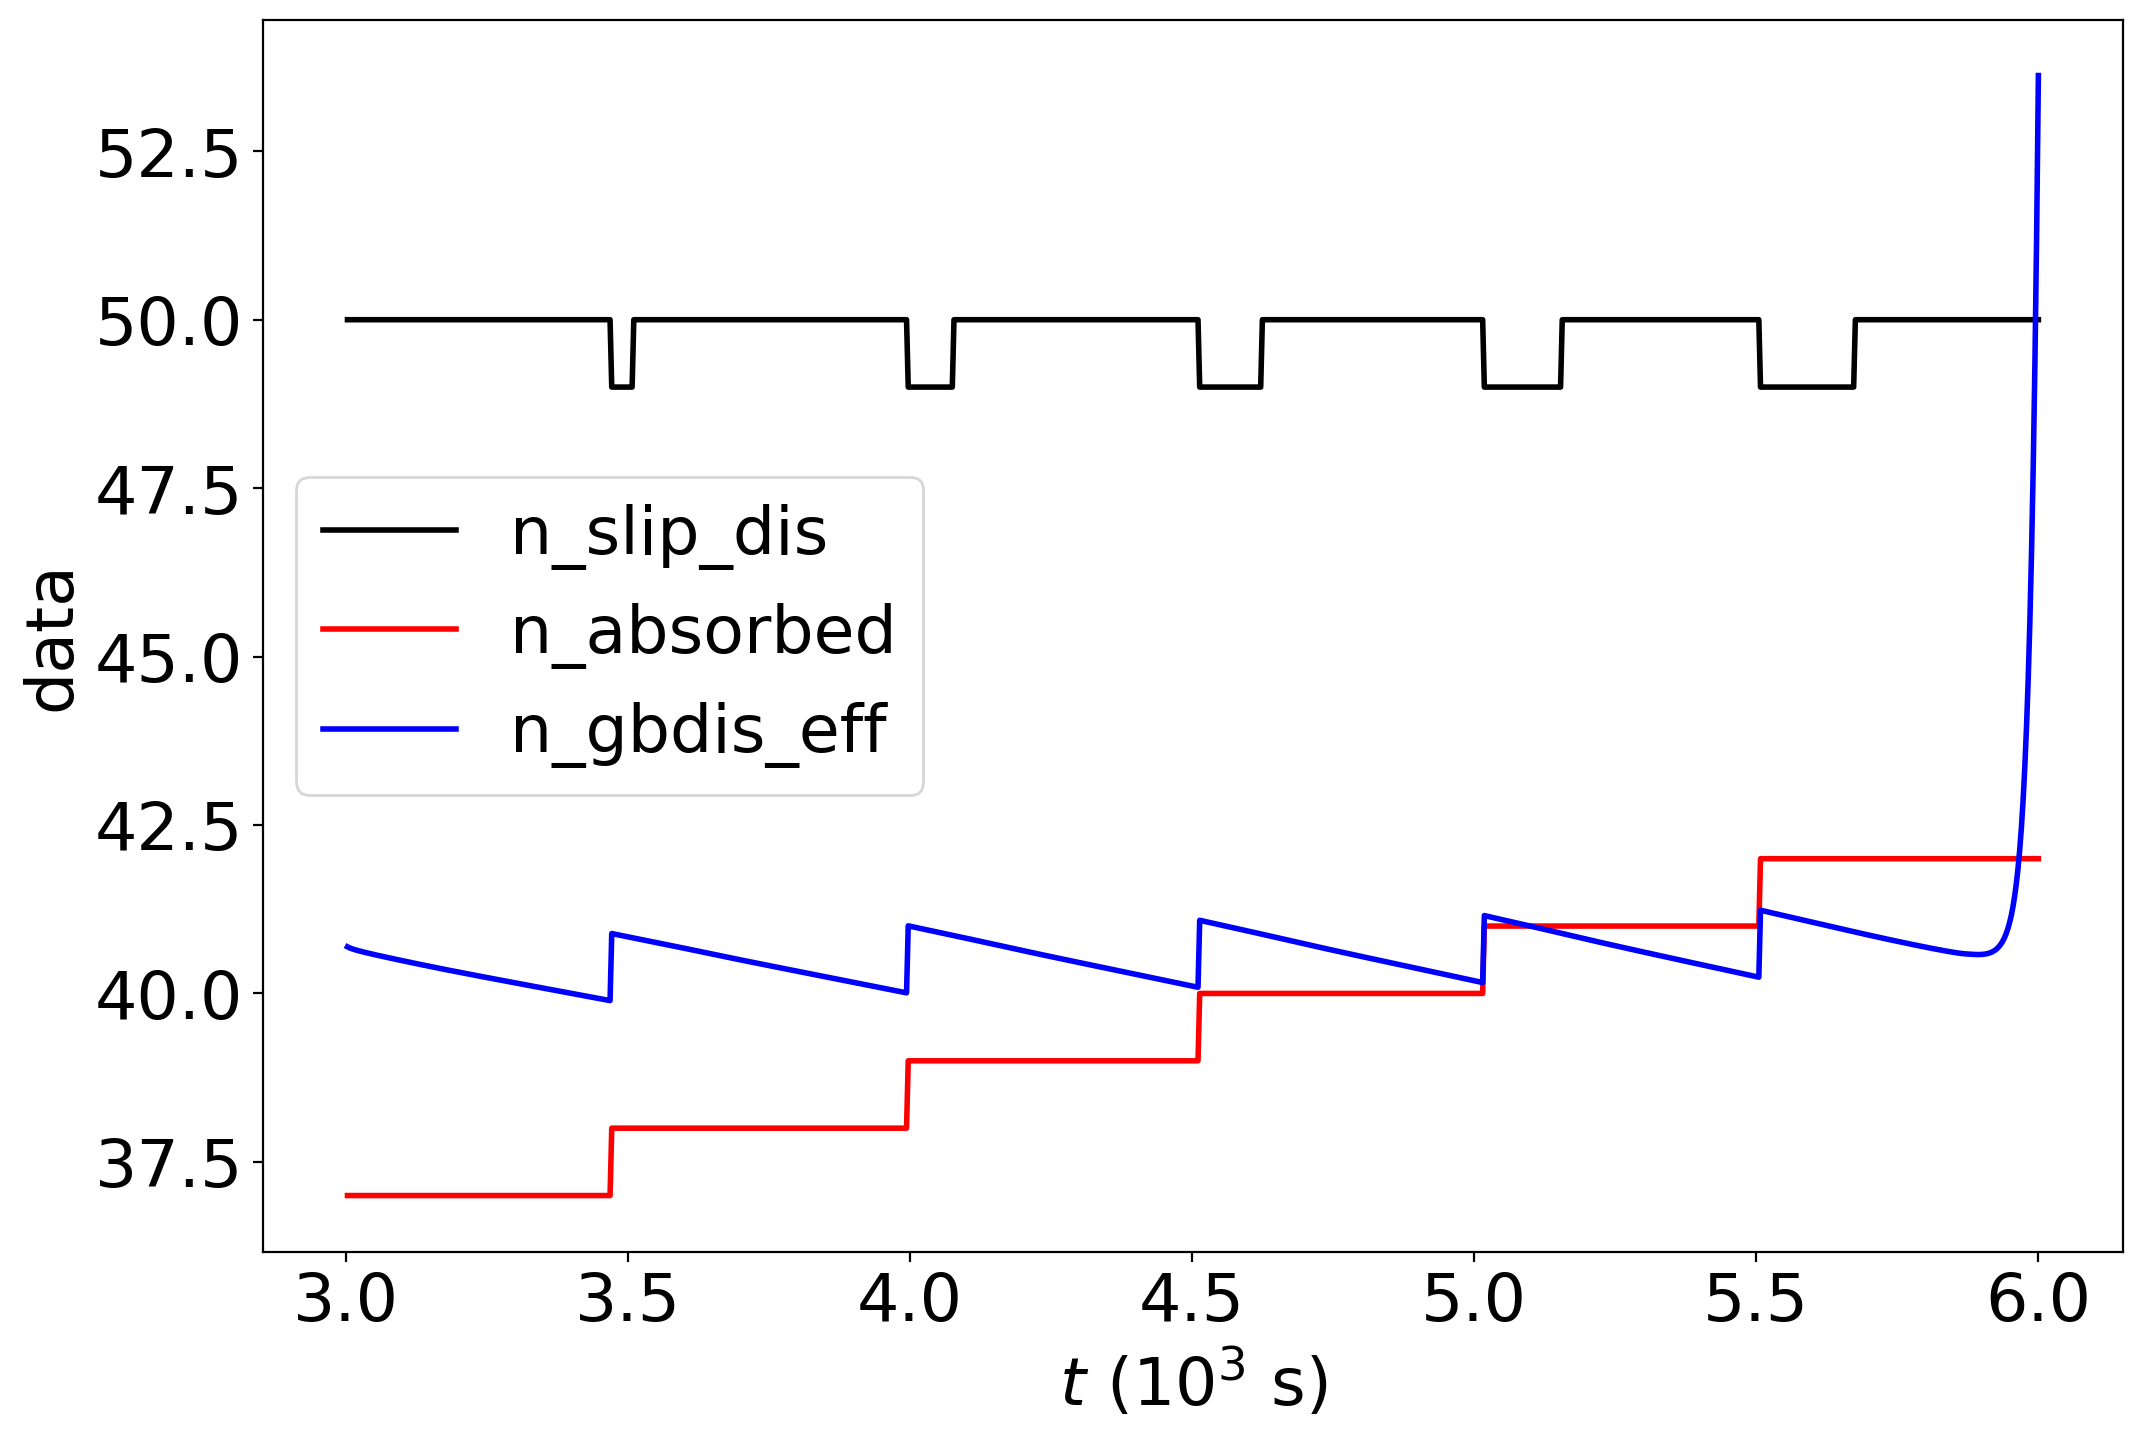

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -2.705451987308305e-13, Nslip: 50.0, Ngb_eff: 41.389102085365224
*** hvar, hist *** 0.0 (array([100]), array([49.5, 50.5]))
Data file with H=0.3, L=0.1, T=1000.0, tau0=150.0, n=24


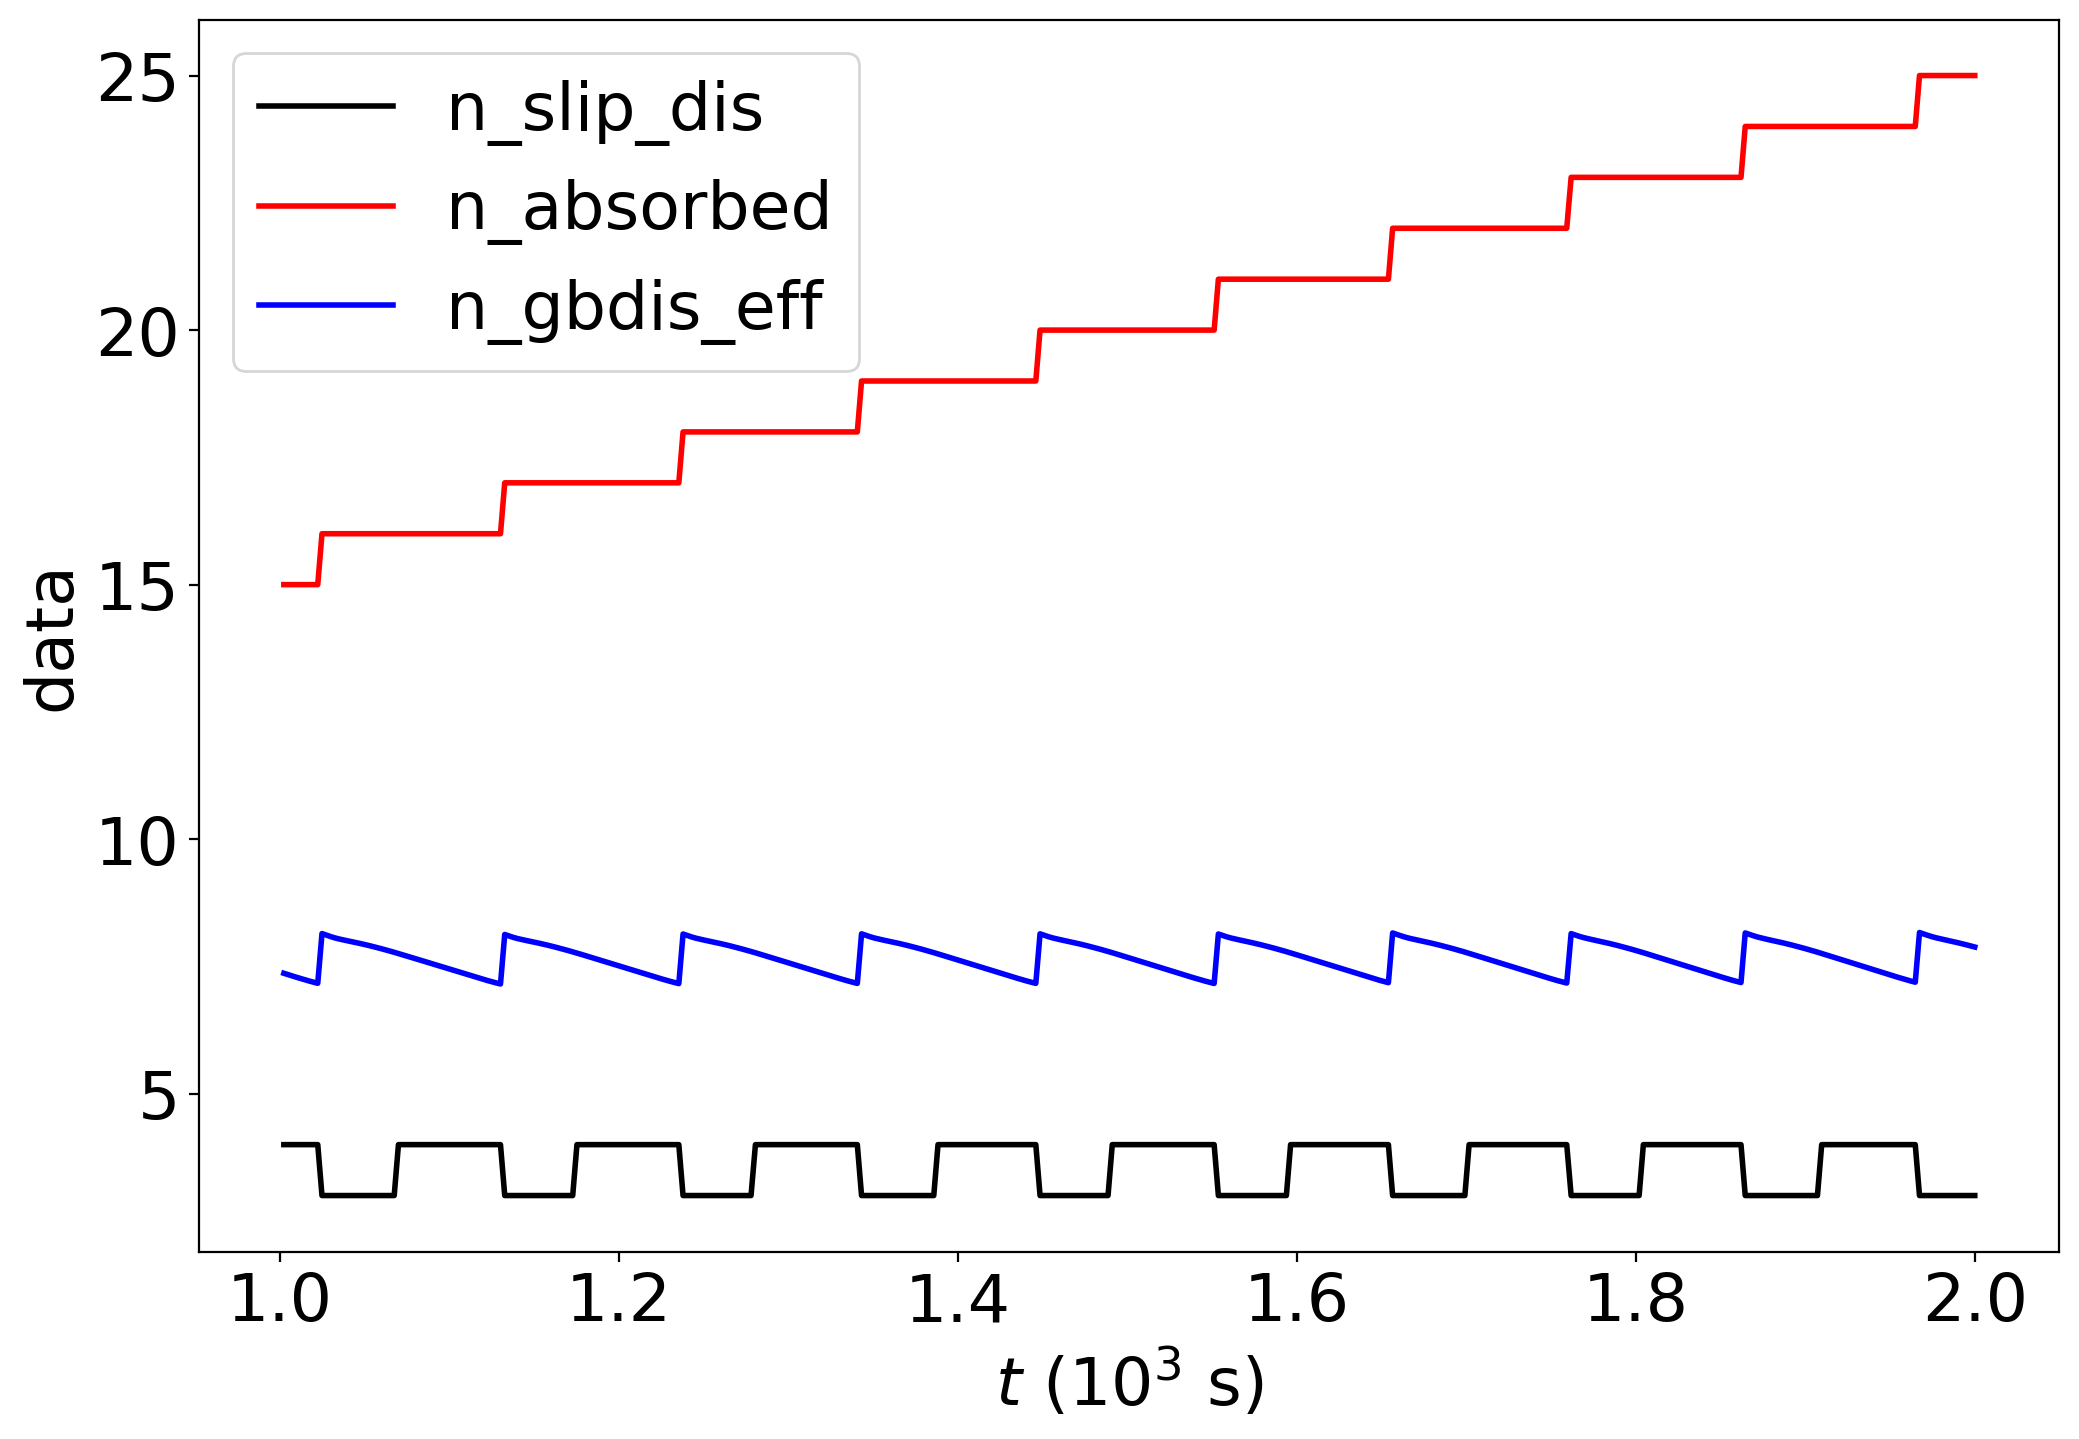

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.207604610946667e-11, Nslip: 3.51, Ngb_eff: 7.71066496117118
*** hvar, hist *** 1.0 (array([49, 51]), array([3. , 3.5, 4. ]))
Data file with H=0.3, L=0.3, T=1000.0, tau0=150.0, n=74


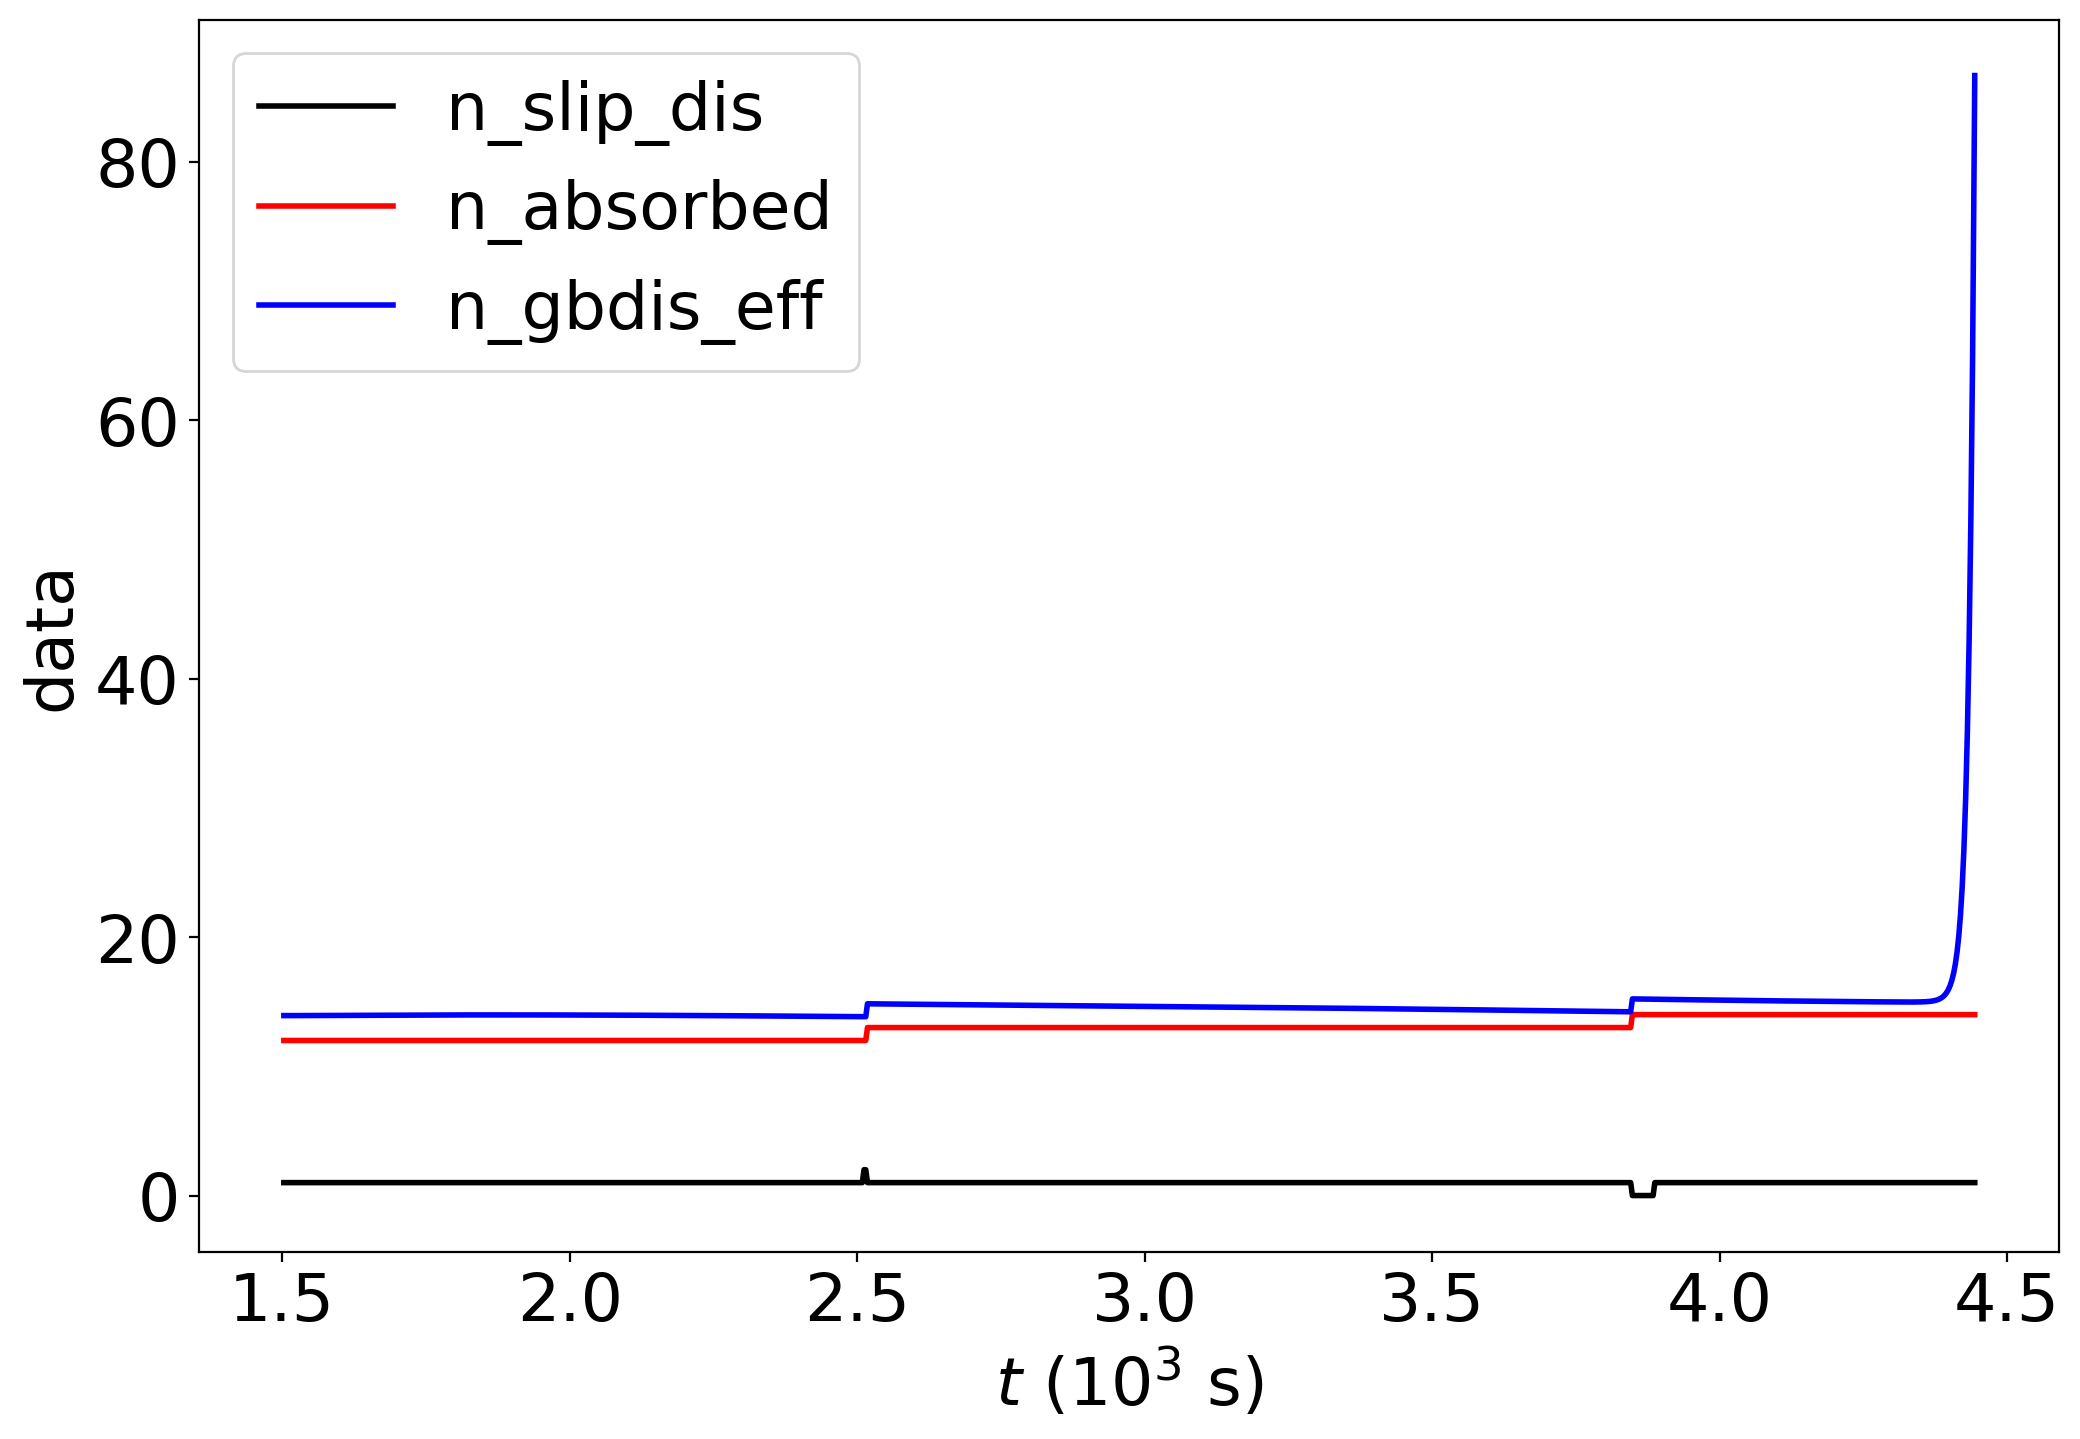

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.065441982599225e-12, Nslip: 1.0, Ngb_eff: 18.378455995154592
*** hvar, hist *** 0.0 (array([100]), array([0.5, 1.5]))
Data file with H=60.0, L=0.1, T=1000.0, tau0=150.0, n=24


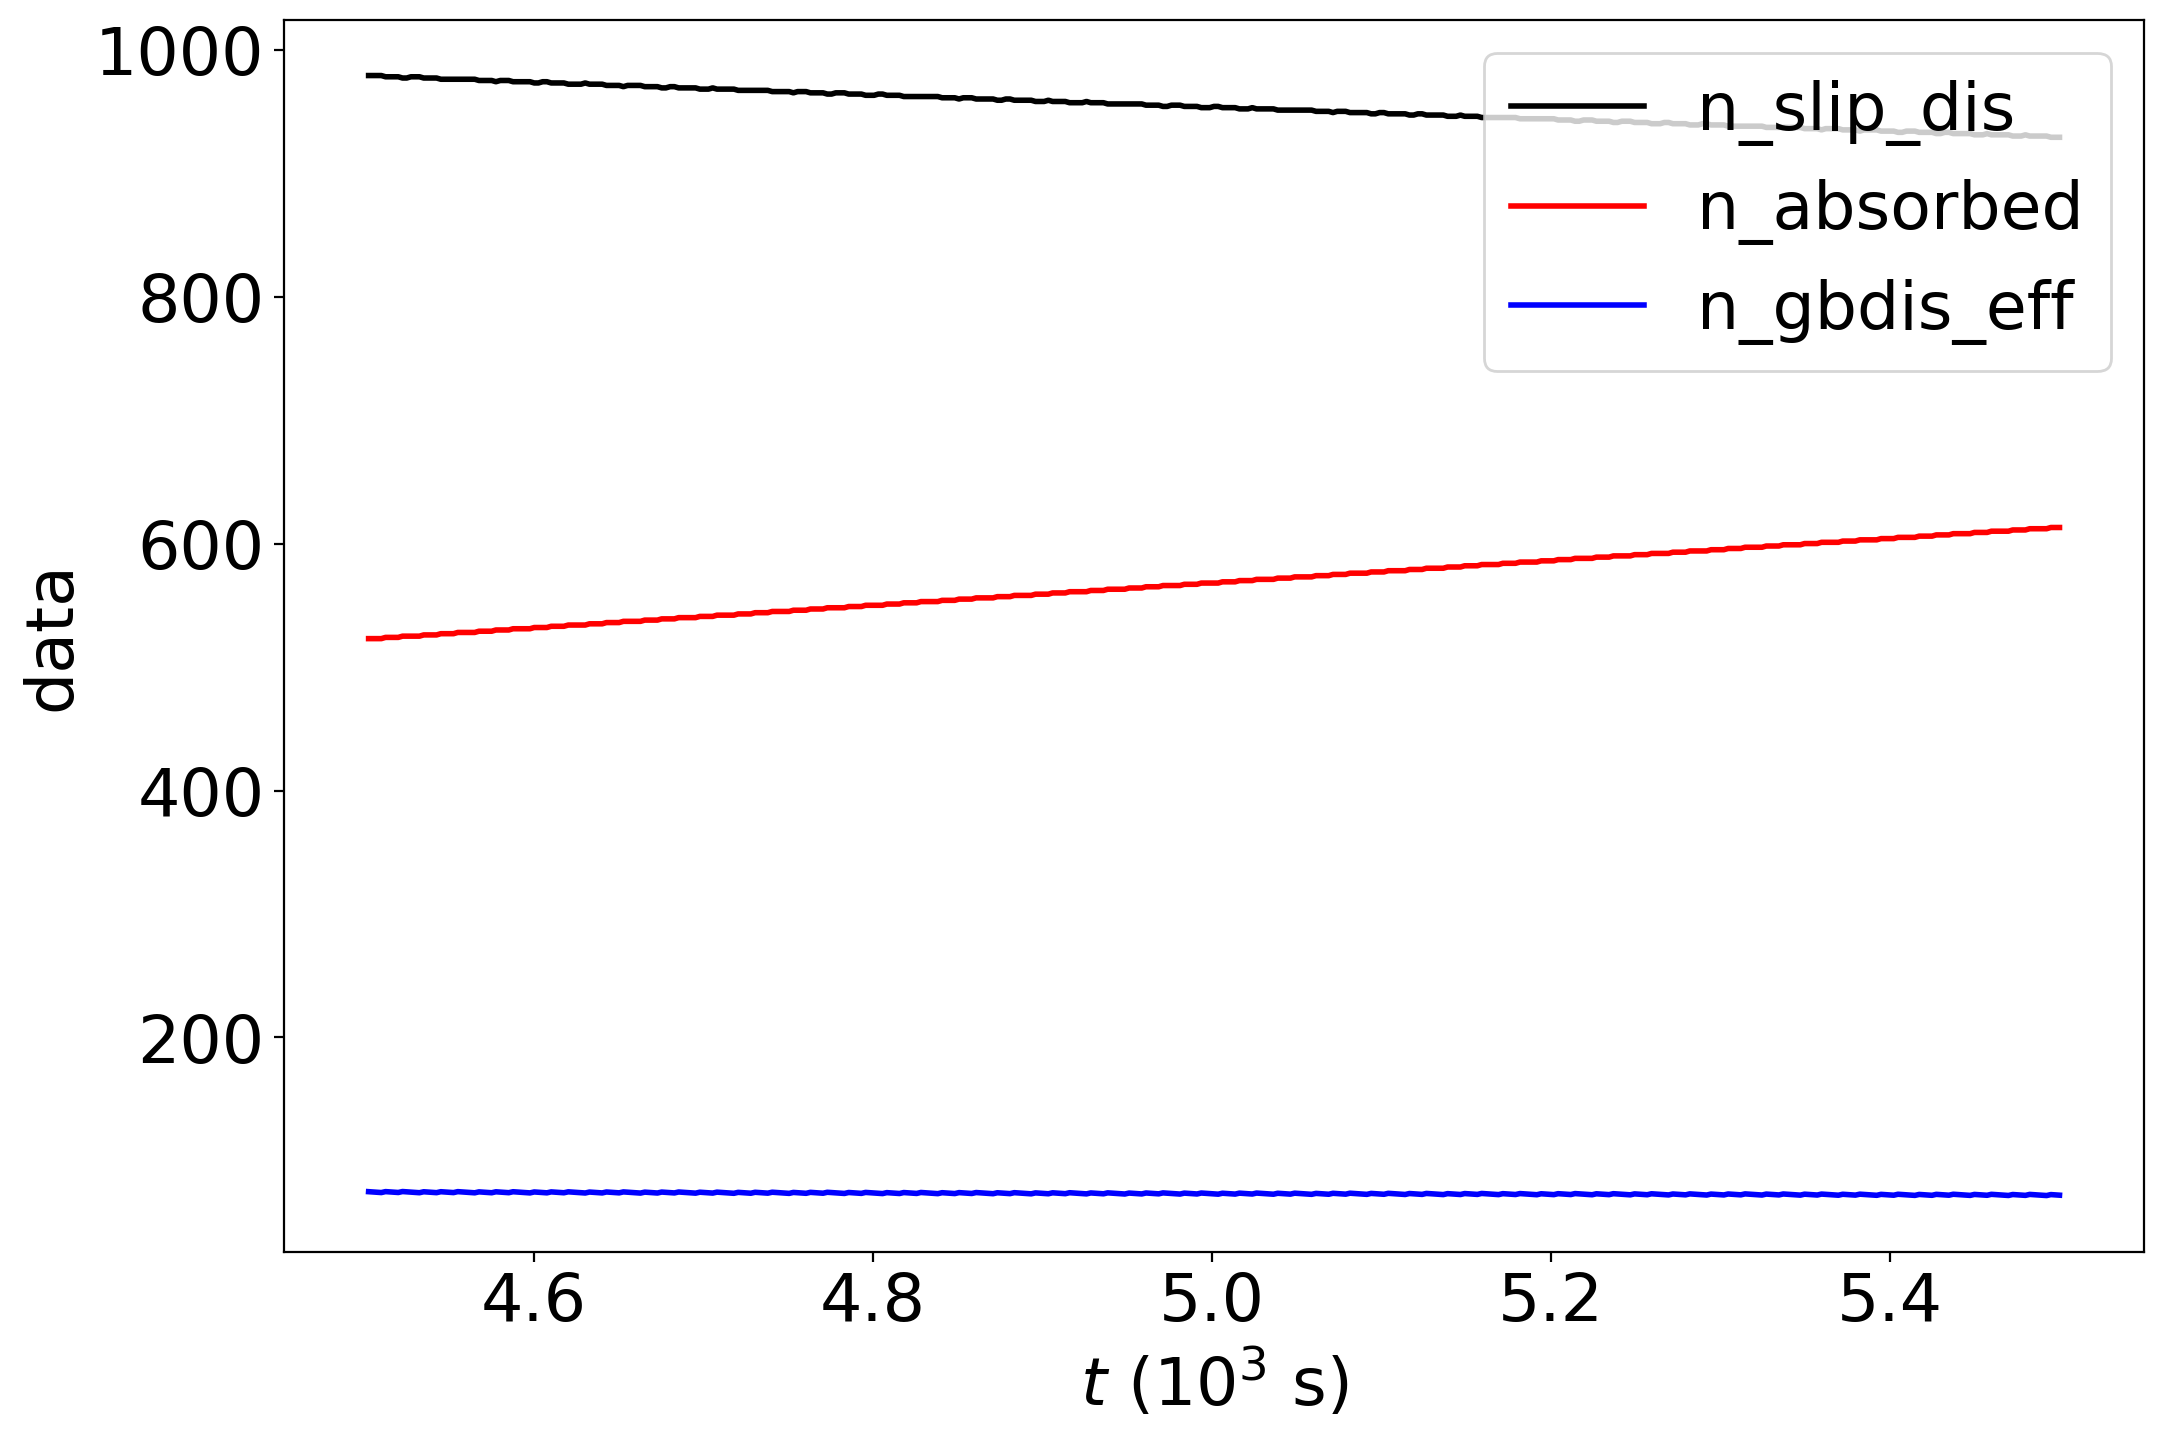

** Max. time step = 497.9833006649445, Median: 393.80445508097944
Av. slip rate: 1.3155348799078518e-10, Nslip: 935.14, Ngb_eff: 72.70166183979707
*** hvar, hist *** 12.0 (array([3, 8, 9, 8, 8, 8, 9, 8, 9, 9, 7, 9, 5]), array([929.        , 929.92307692, 930.84615385, 931.76923077,
       932.69230769, 933.61538462, 934.53846154, 935.46153846,
       936.38461538, 937.30769231, 938.23076923, 939.15384615,
       940.07692308, 941.        ]))
Data file with H=60.0, L=0.3, T=1000.0, tau0=150.0, n=74


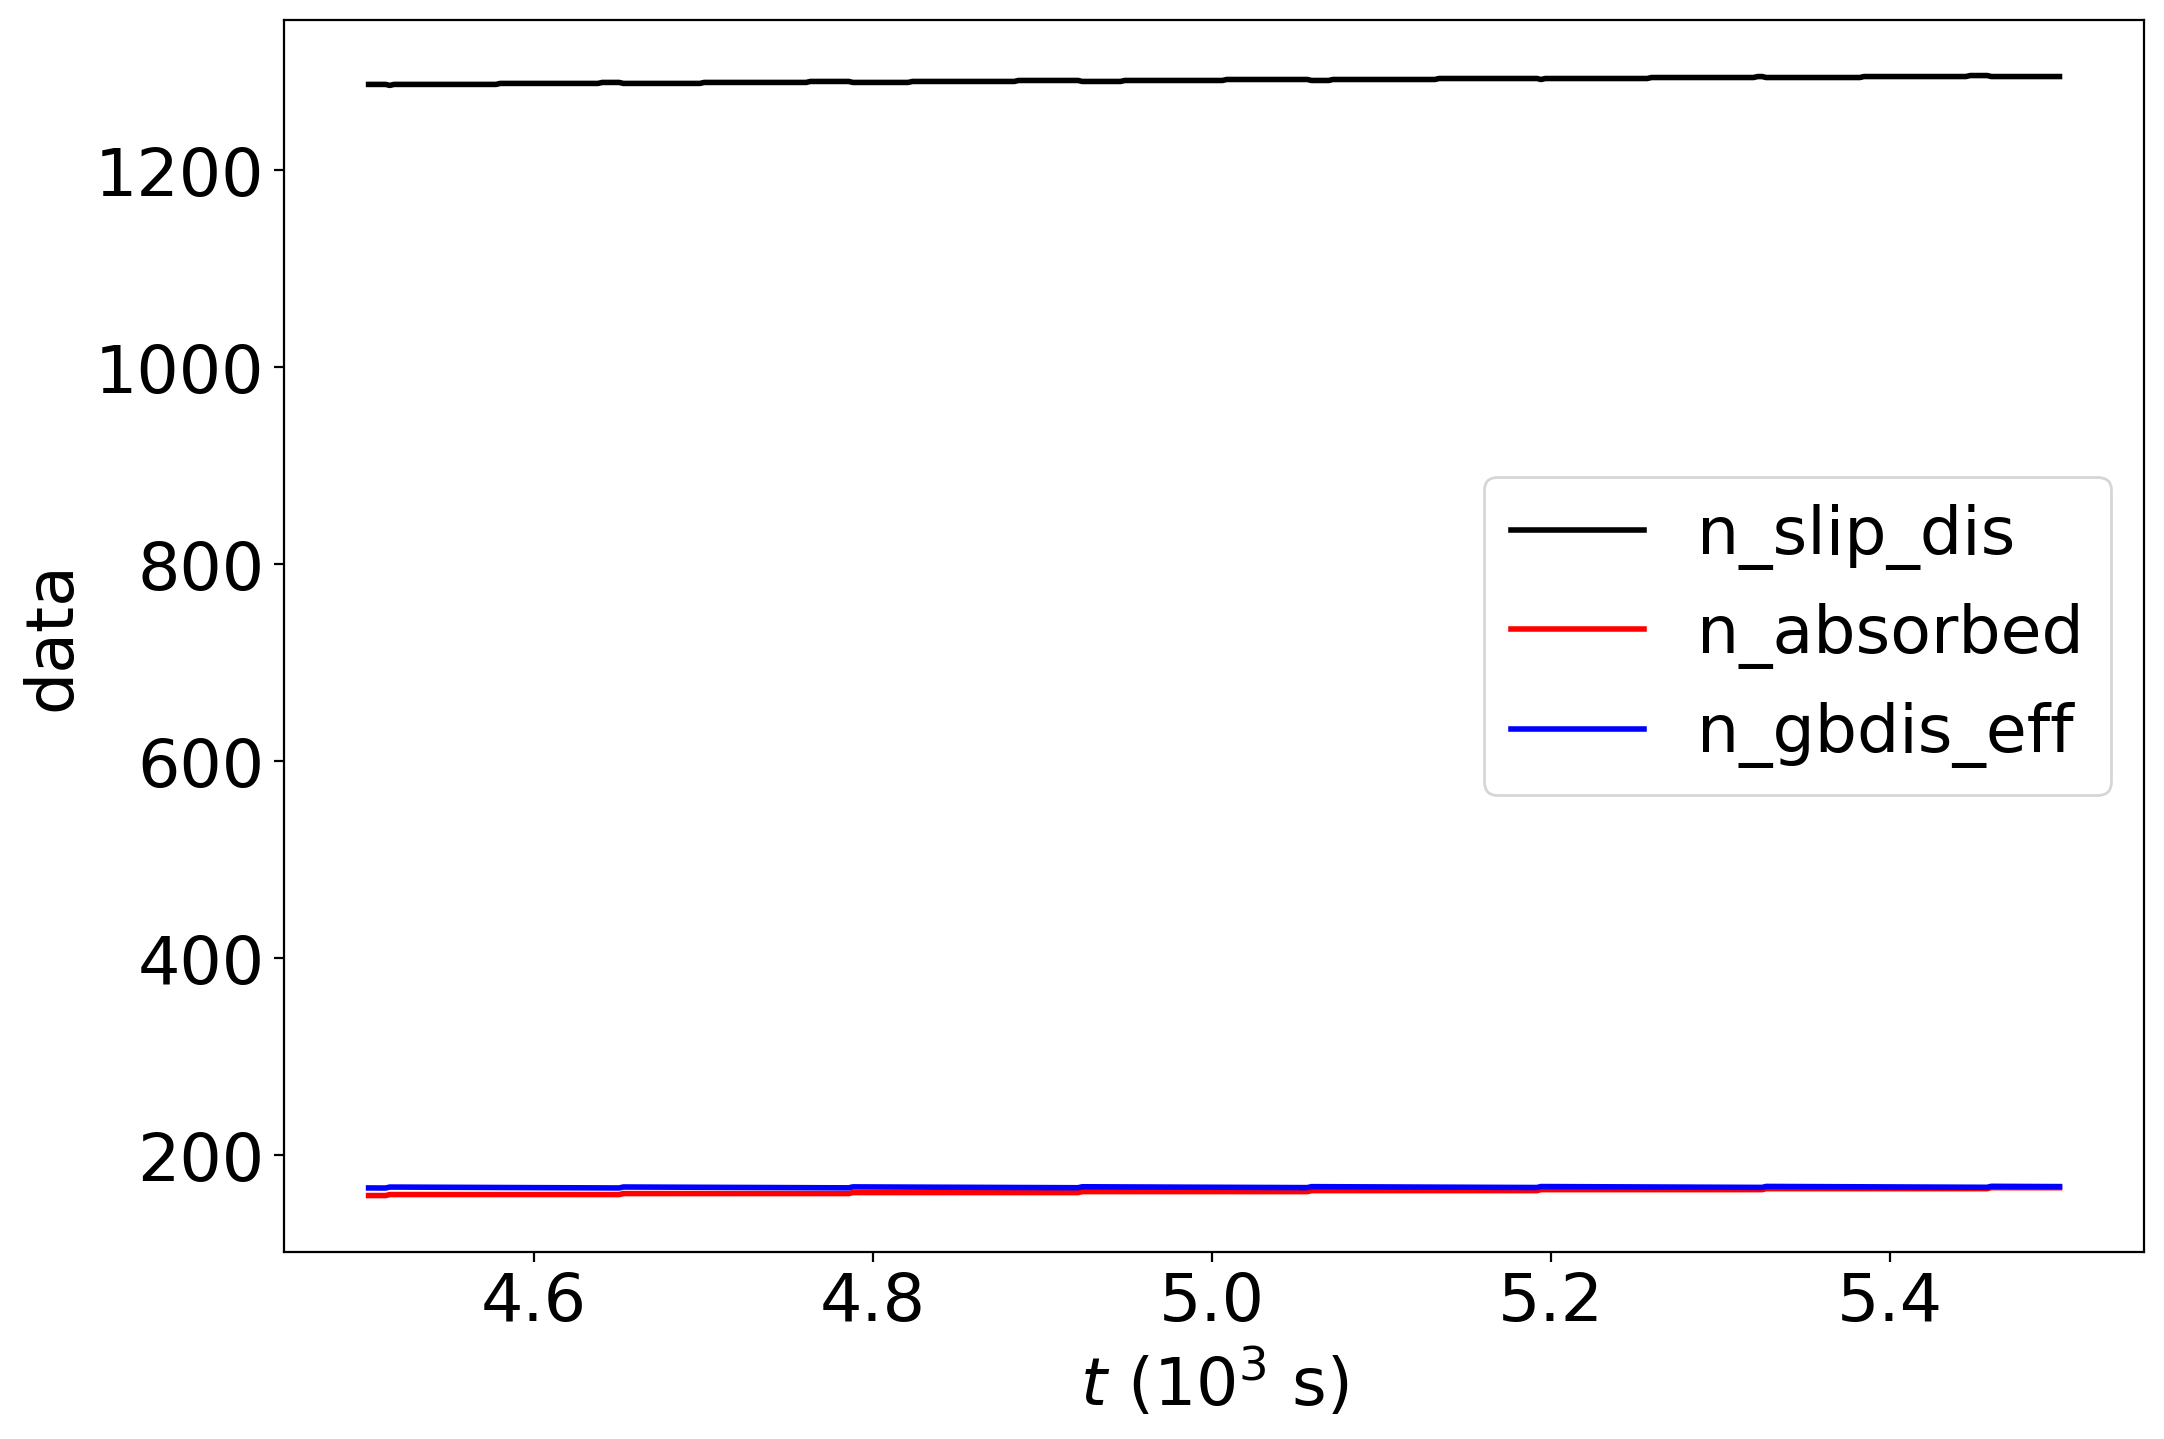

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.0474863600804394e-11, Nslip: 1294.51, Ngb_eff: 167.7970228276542
*** hvar, hist *** 3.0 (array([ 3, 48, 44,  5]), array([1293.  , 1293.75, 1294.5 , 1295.25, 1296.  ]))
Data file with H=100.0, L=0.1, T=700.0, tau0=150.0, n=24


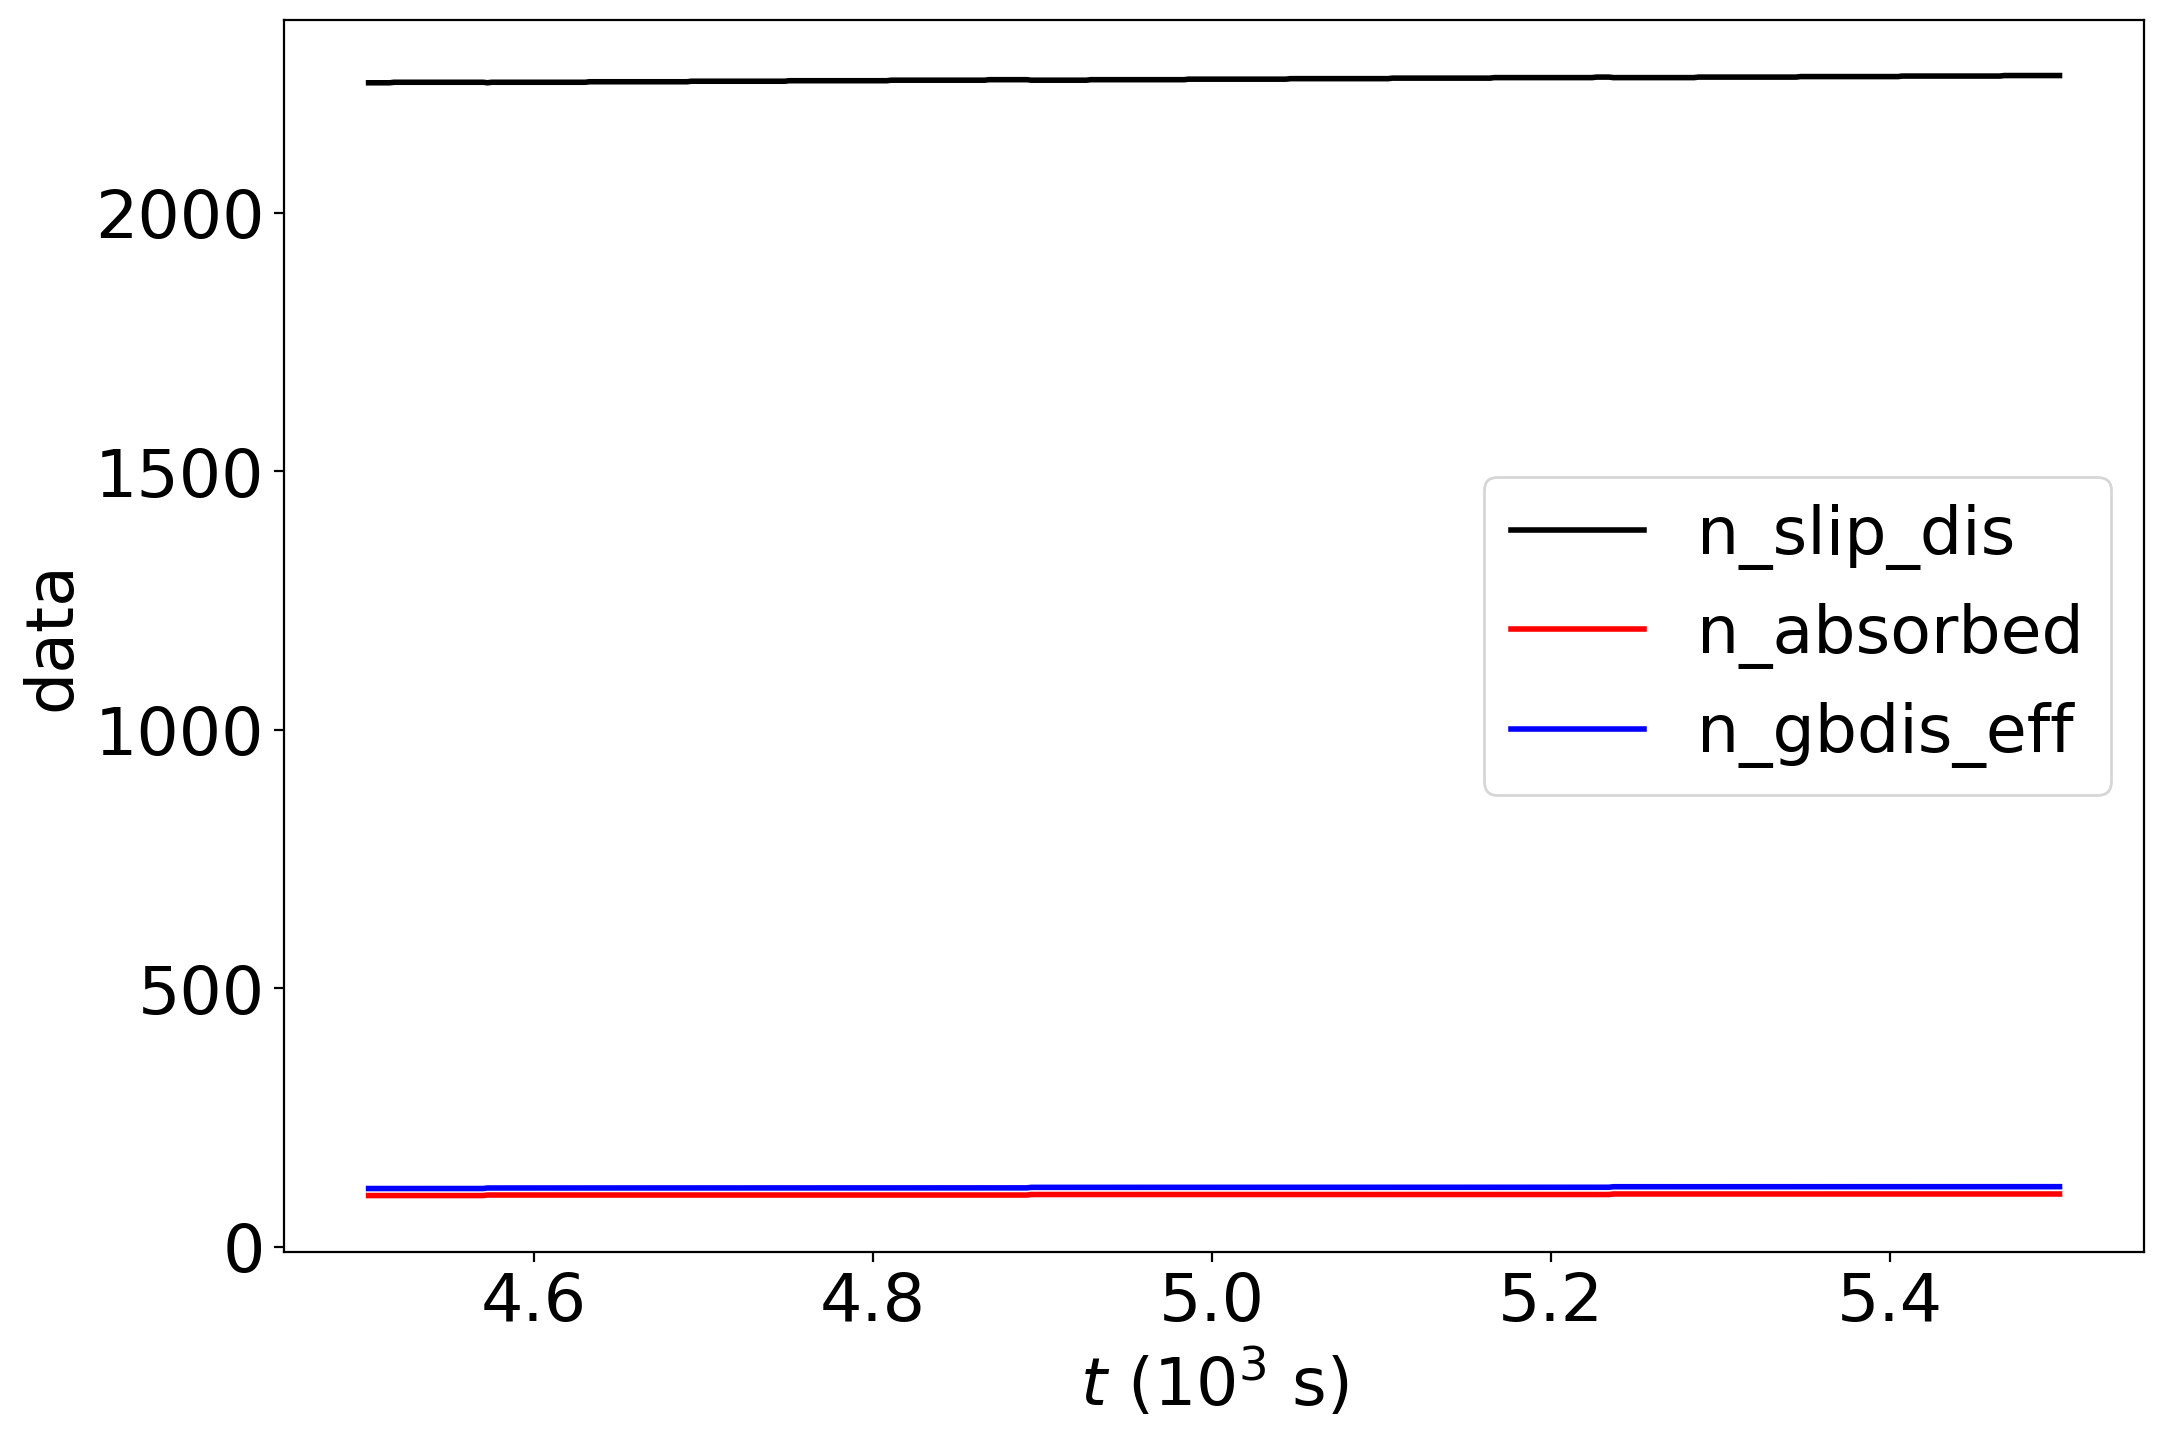

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.2991688374271667e-11, Nslip: 2263.0, Ngb_eff: 116.1059871272996
*** hvar, hist *** 4.0 (array([14, 24, 24, 24, 14]), array([2261. , 2261.8, 2262.6, 2263.4, 2264.2, 2265. ]))
Data file with H=100.0, L=0.3, T=700.0, tau0=150.0, n=74


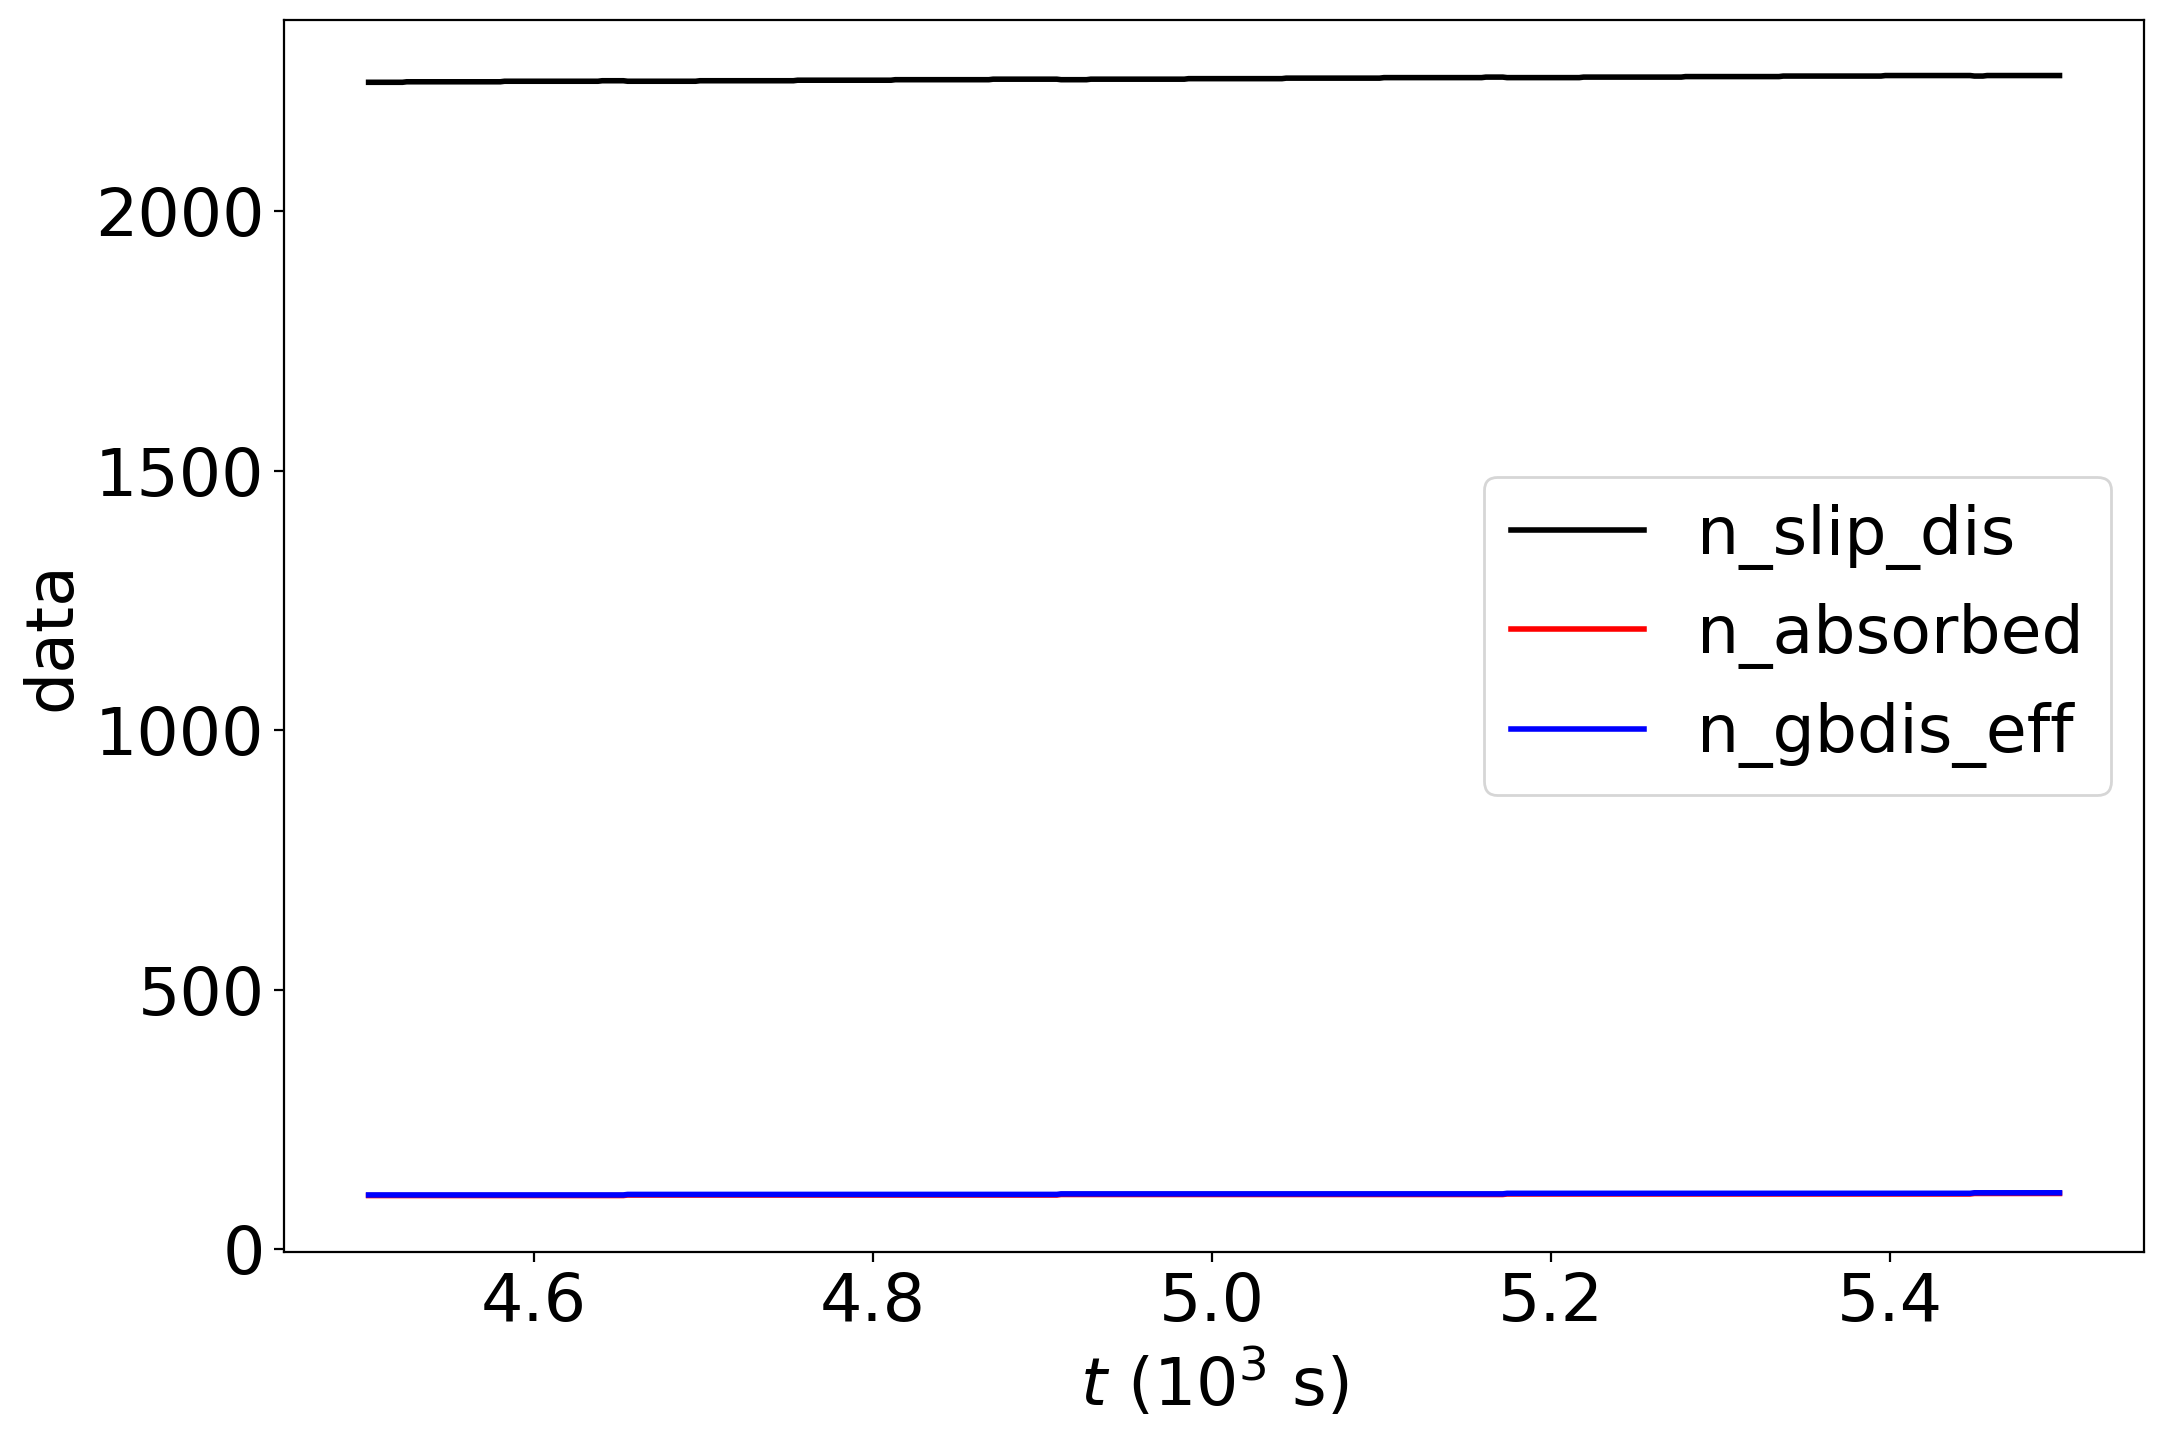

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 8.156951585224517e-12, Nslip: 2259.94, Ngb_eff: 107.49784611227484
*** hvar, hist *** 3.0 (array([11, 23, 27, 39]), array([2258.  , 2258.75, 2259.5 , 2260.25, 2261.  ]))
Data file with H=10.0, L=0.1, T=700.0, tau0=150.0, n=24


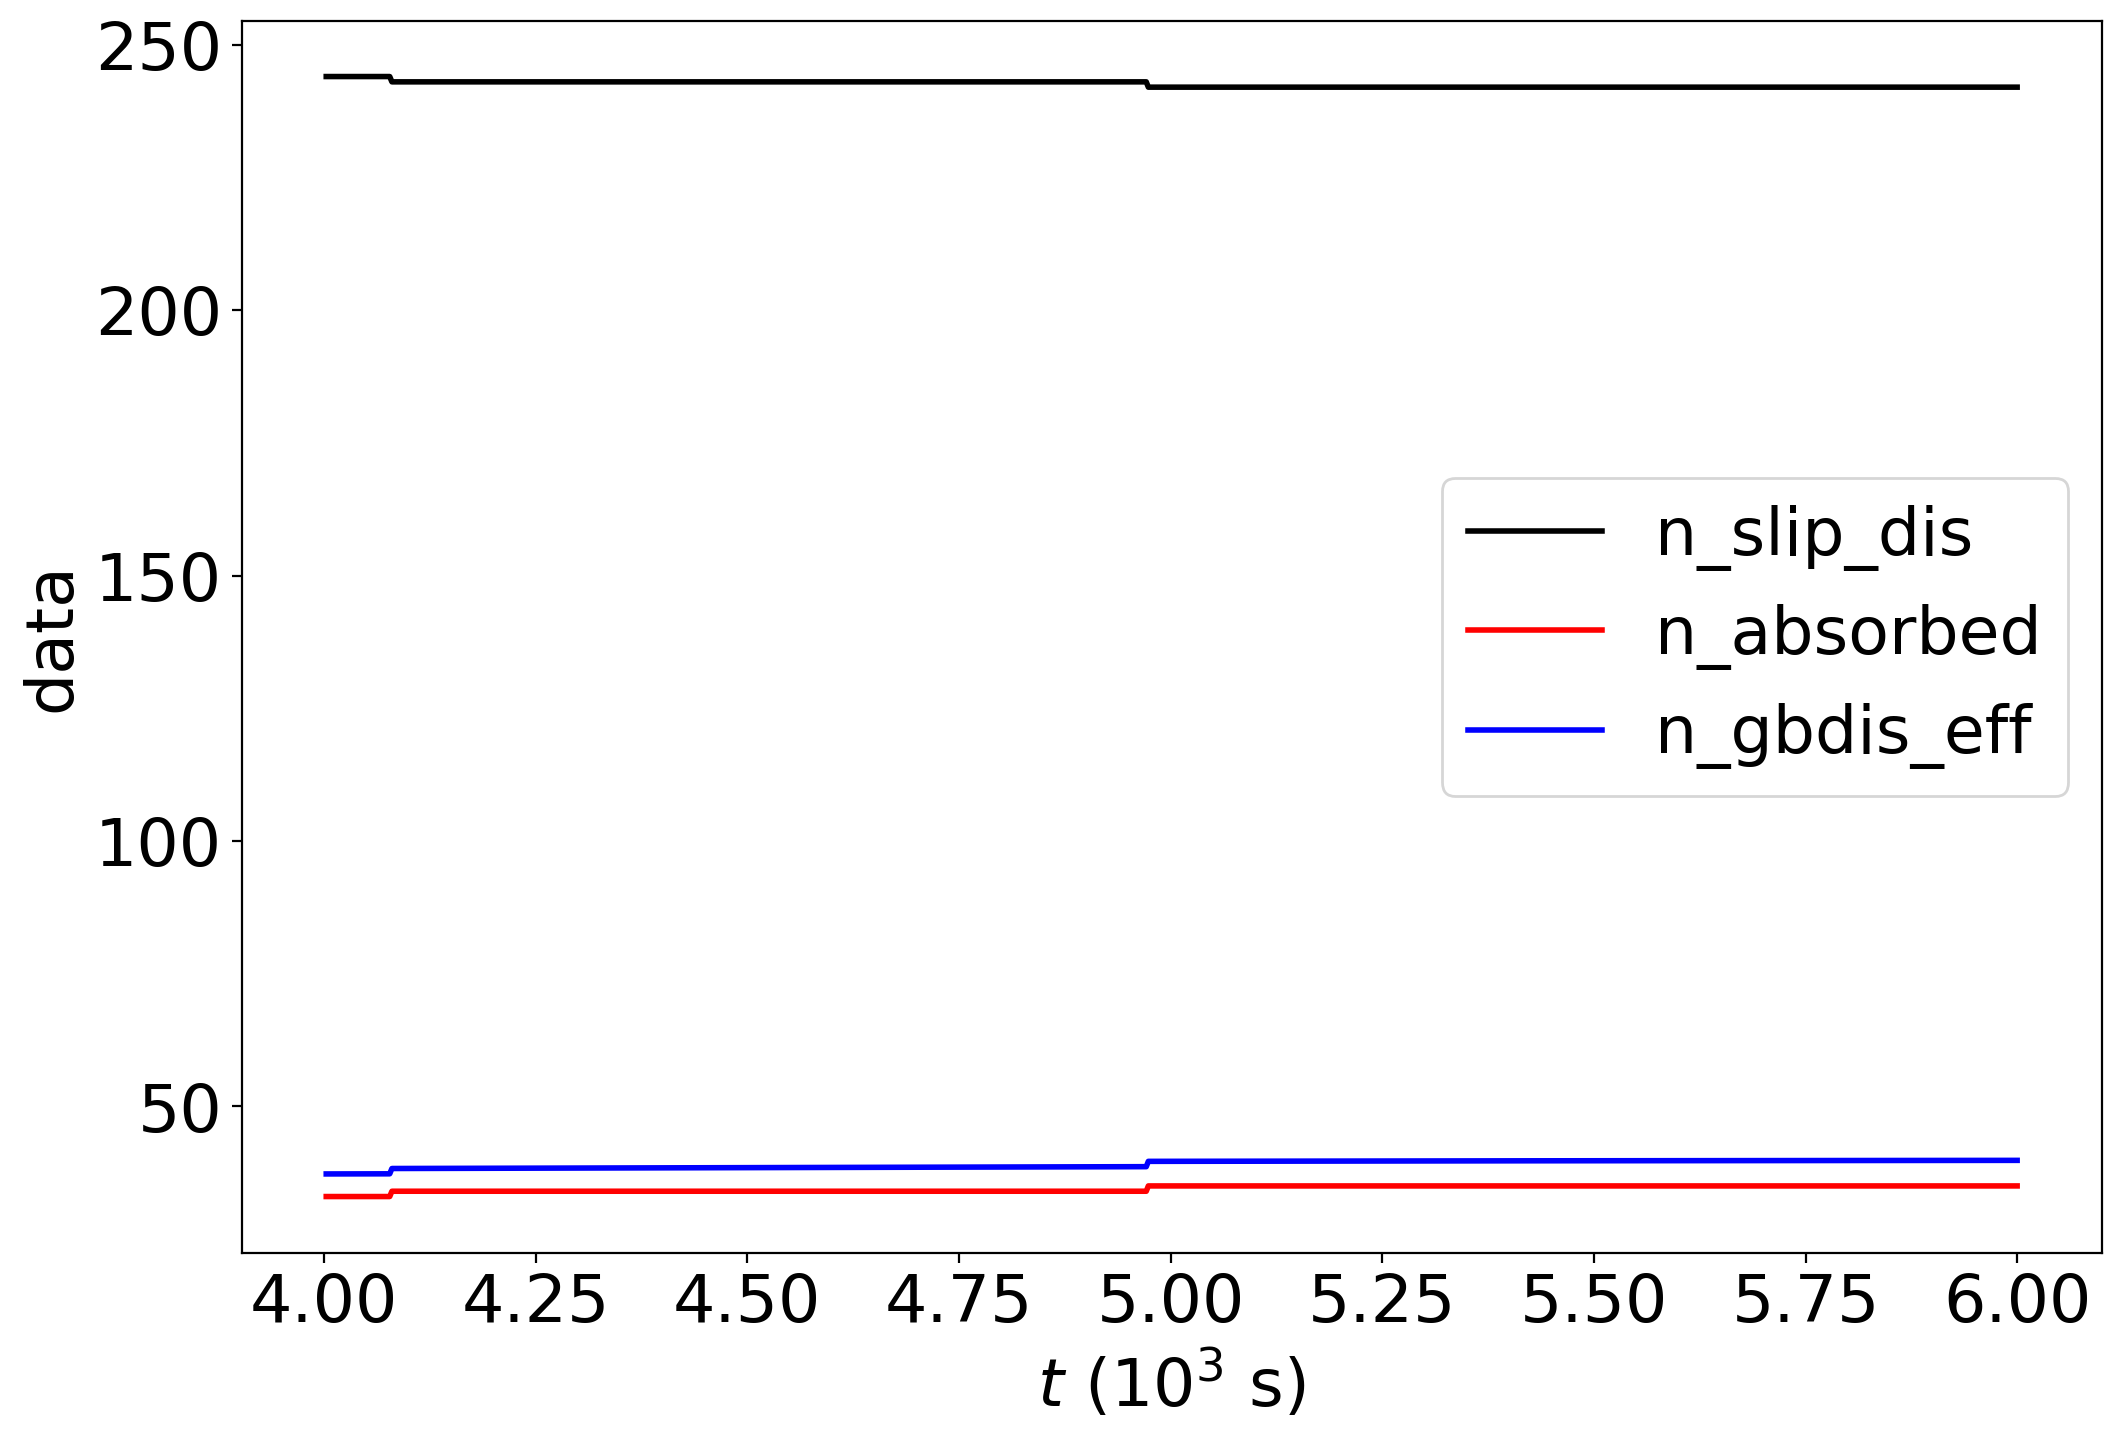

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -4.158414594712669e-14, Nslip: 242.0, Ngb_eff: 39.800652325321614
*** hvar, hist *** 0.0 (array([100]), array([241.5, 242.5]))
Data file with H=10.0, L=0.3, T=700.0, tau0=150.0, n=74


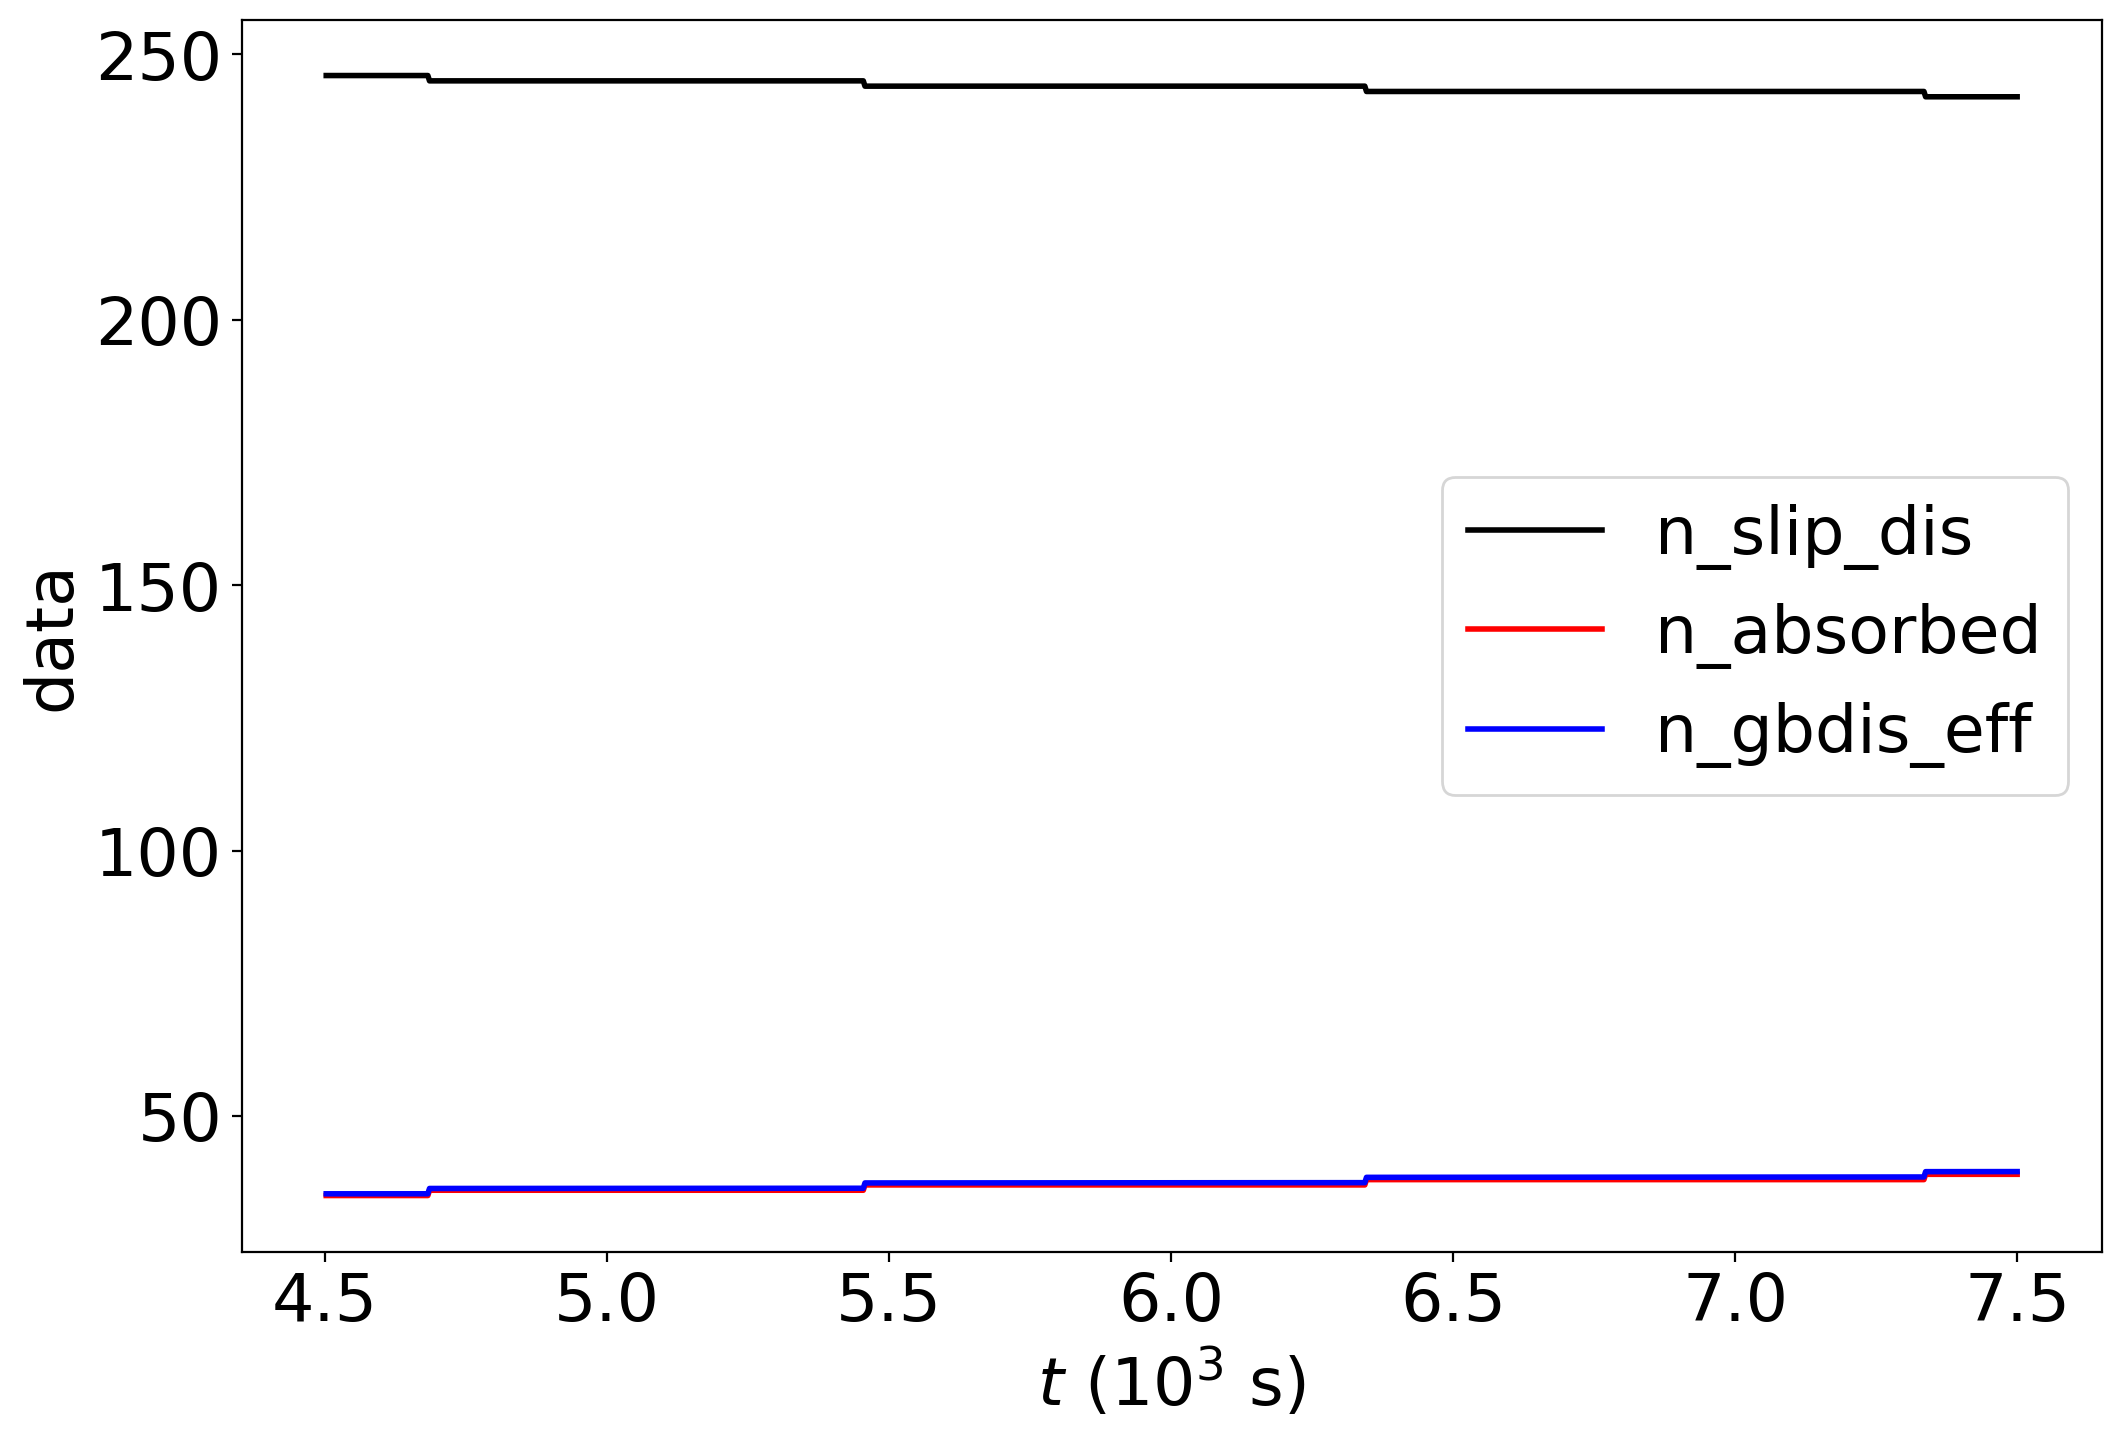

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 8.0389395144802e-14, Nslip: 242.45, Ngb_eff: 39.05037796801726
*** hvar, hist *** 1.0 (array([55, 45]), array([242. , 242.5, 243. ]))
Data file with H=1.0, L=0.1, T=700.0, tau0=150.0, n=24


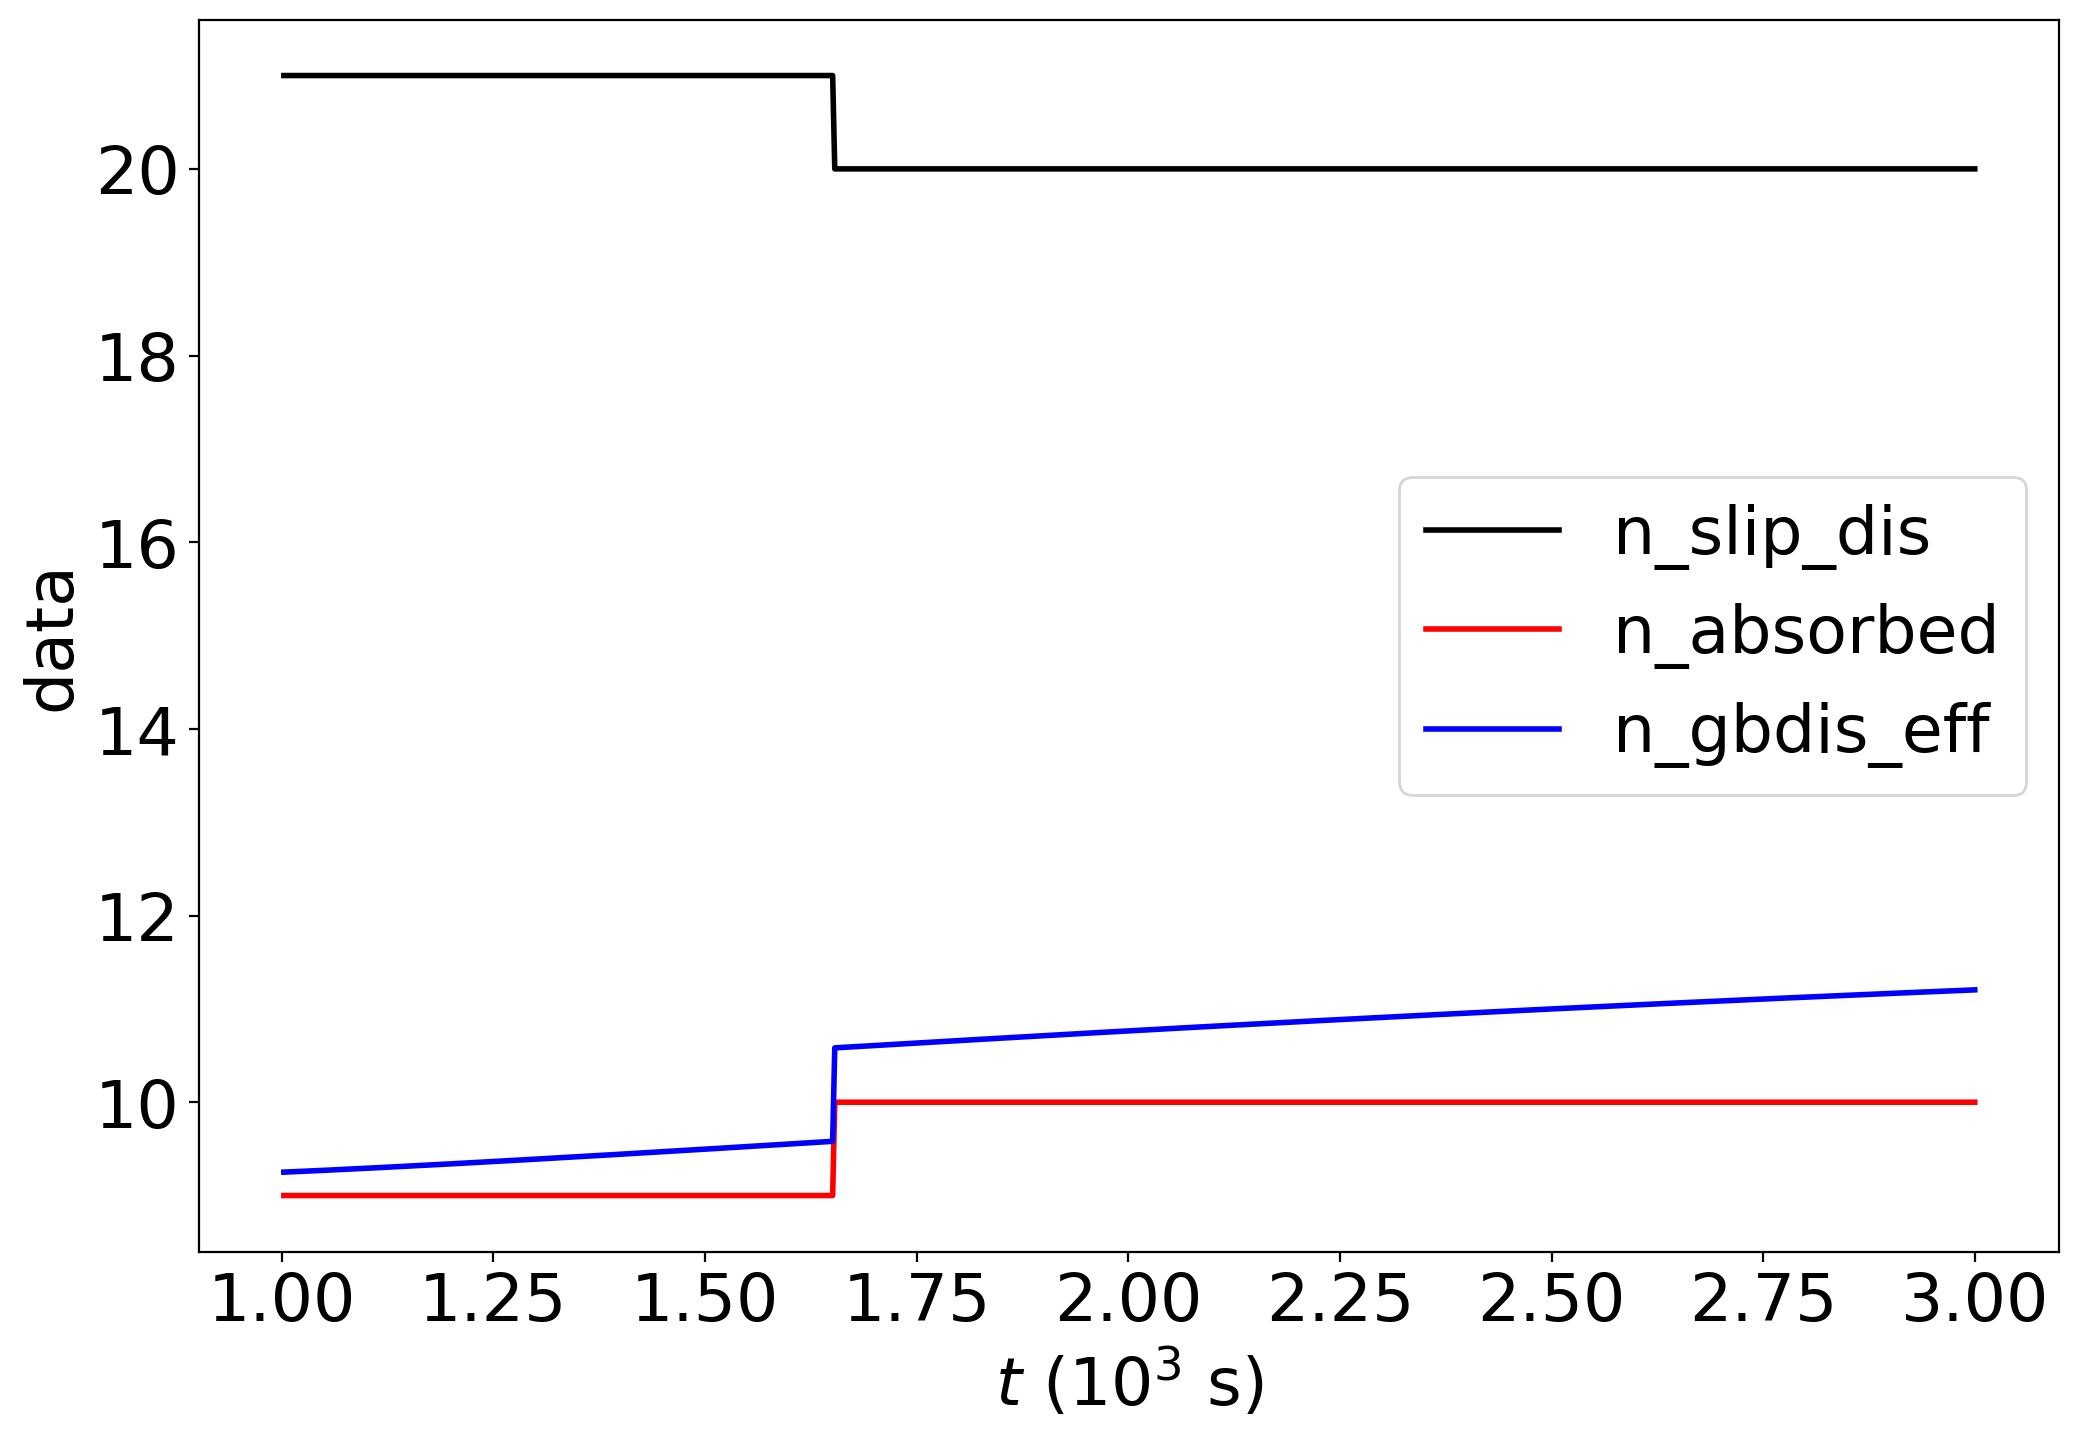

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -1.1243812792827159e-14, Nslip: 20.0, Ngb_eff: 11.155719239471862
*** hvar, hist *** 0.0 (array([100]), array([19.5, 20.5]))
Data file with H=1.0, L=0.3, T=700.0, tau0=150.0, n=74


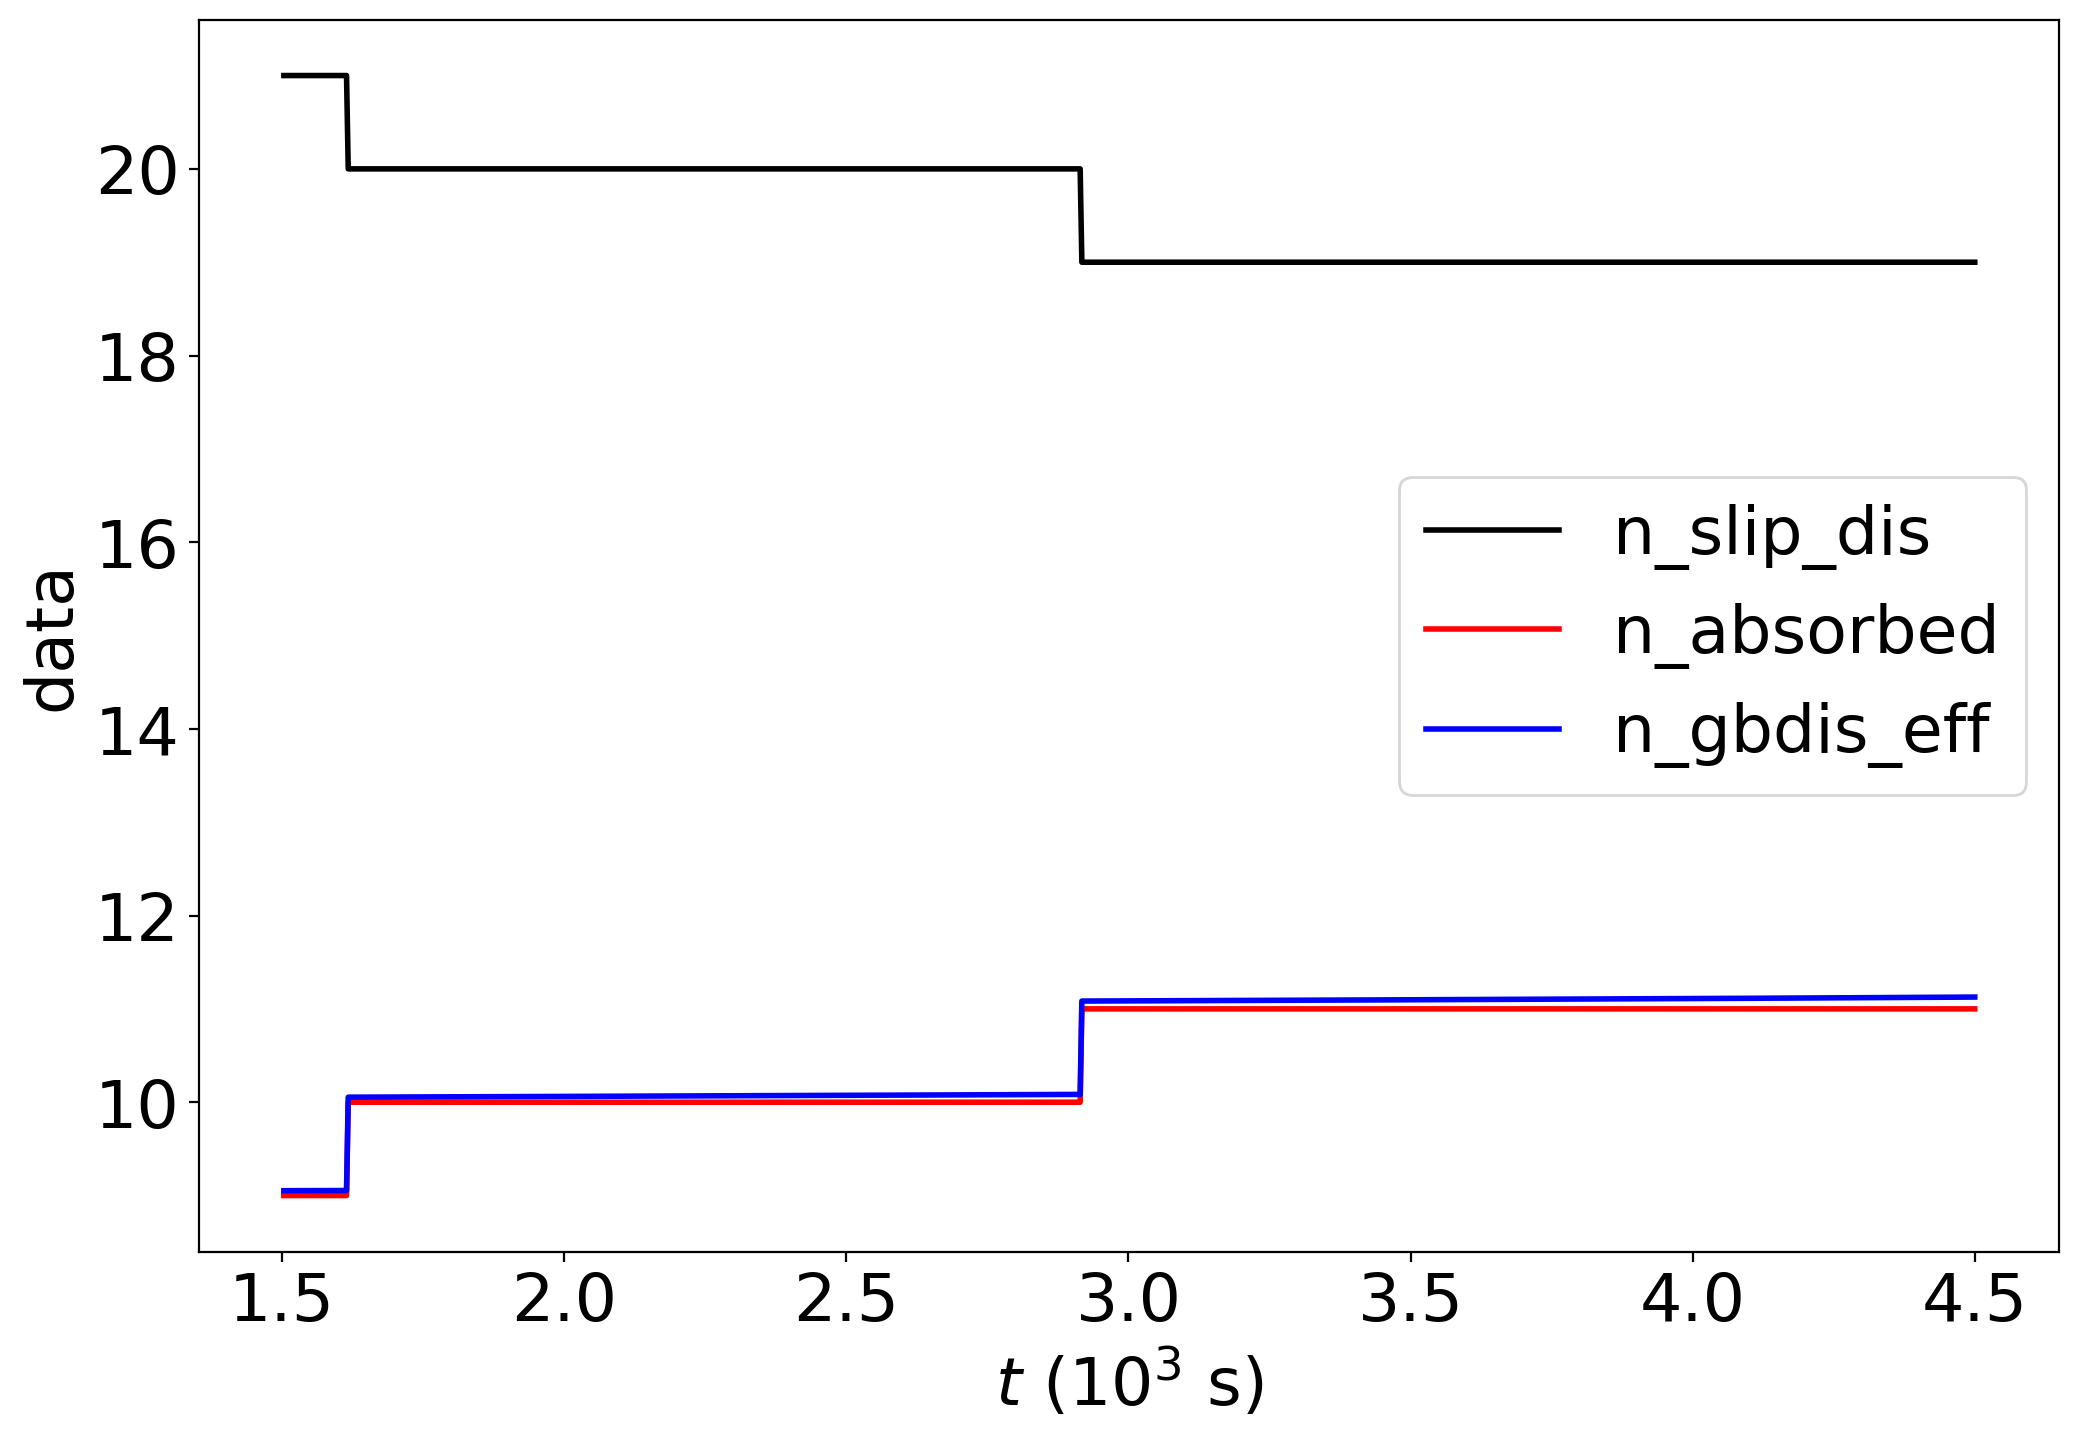

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 4.626769860749392e-14, Nslip: 19.0, Ngb_eff: 11.121362820043064
*** hvar, hist *** 0.0 (array([100]), array([18.5, 19.5]))
Data file with H=30.0, L=0.1, T=700.0, tau0=150.0, n=24


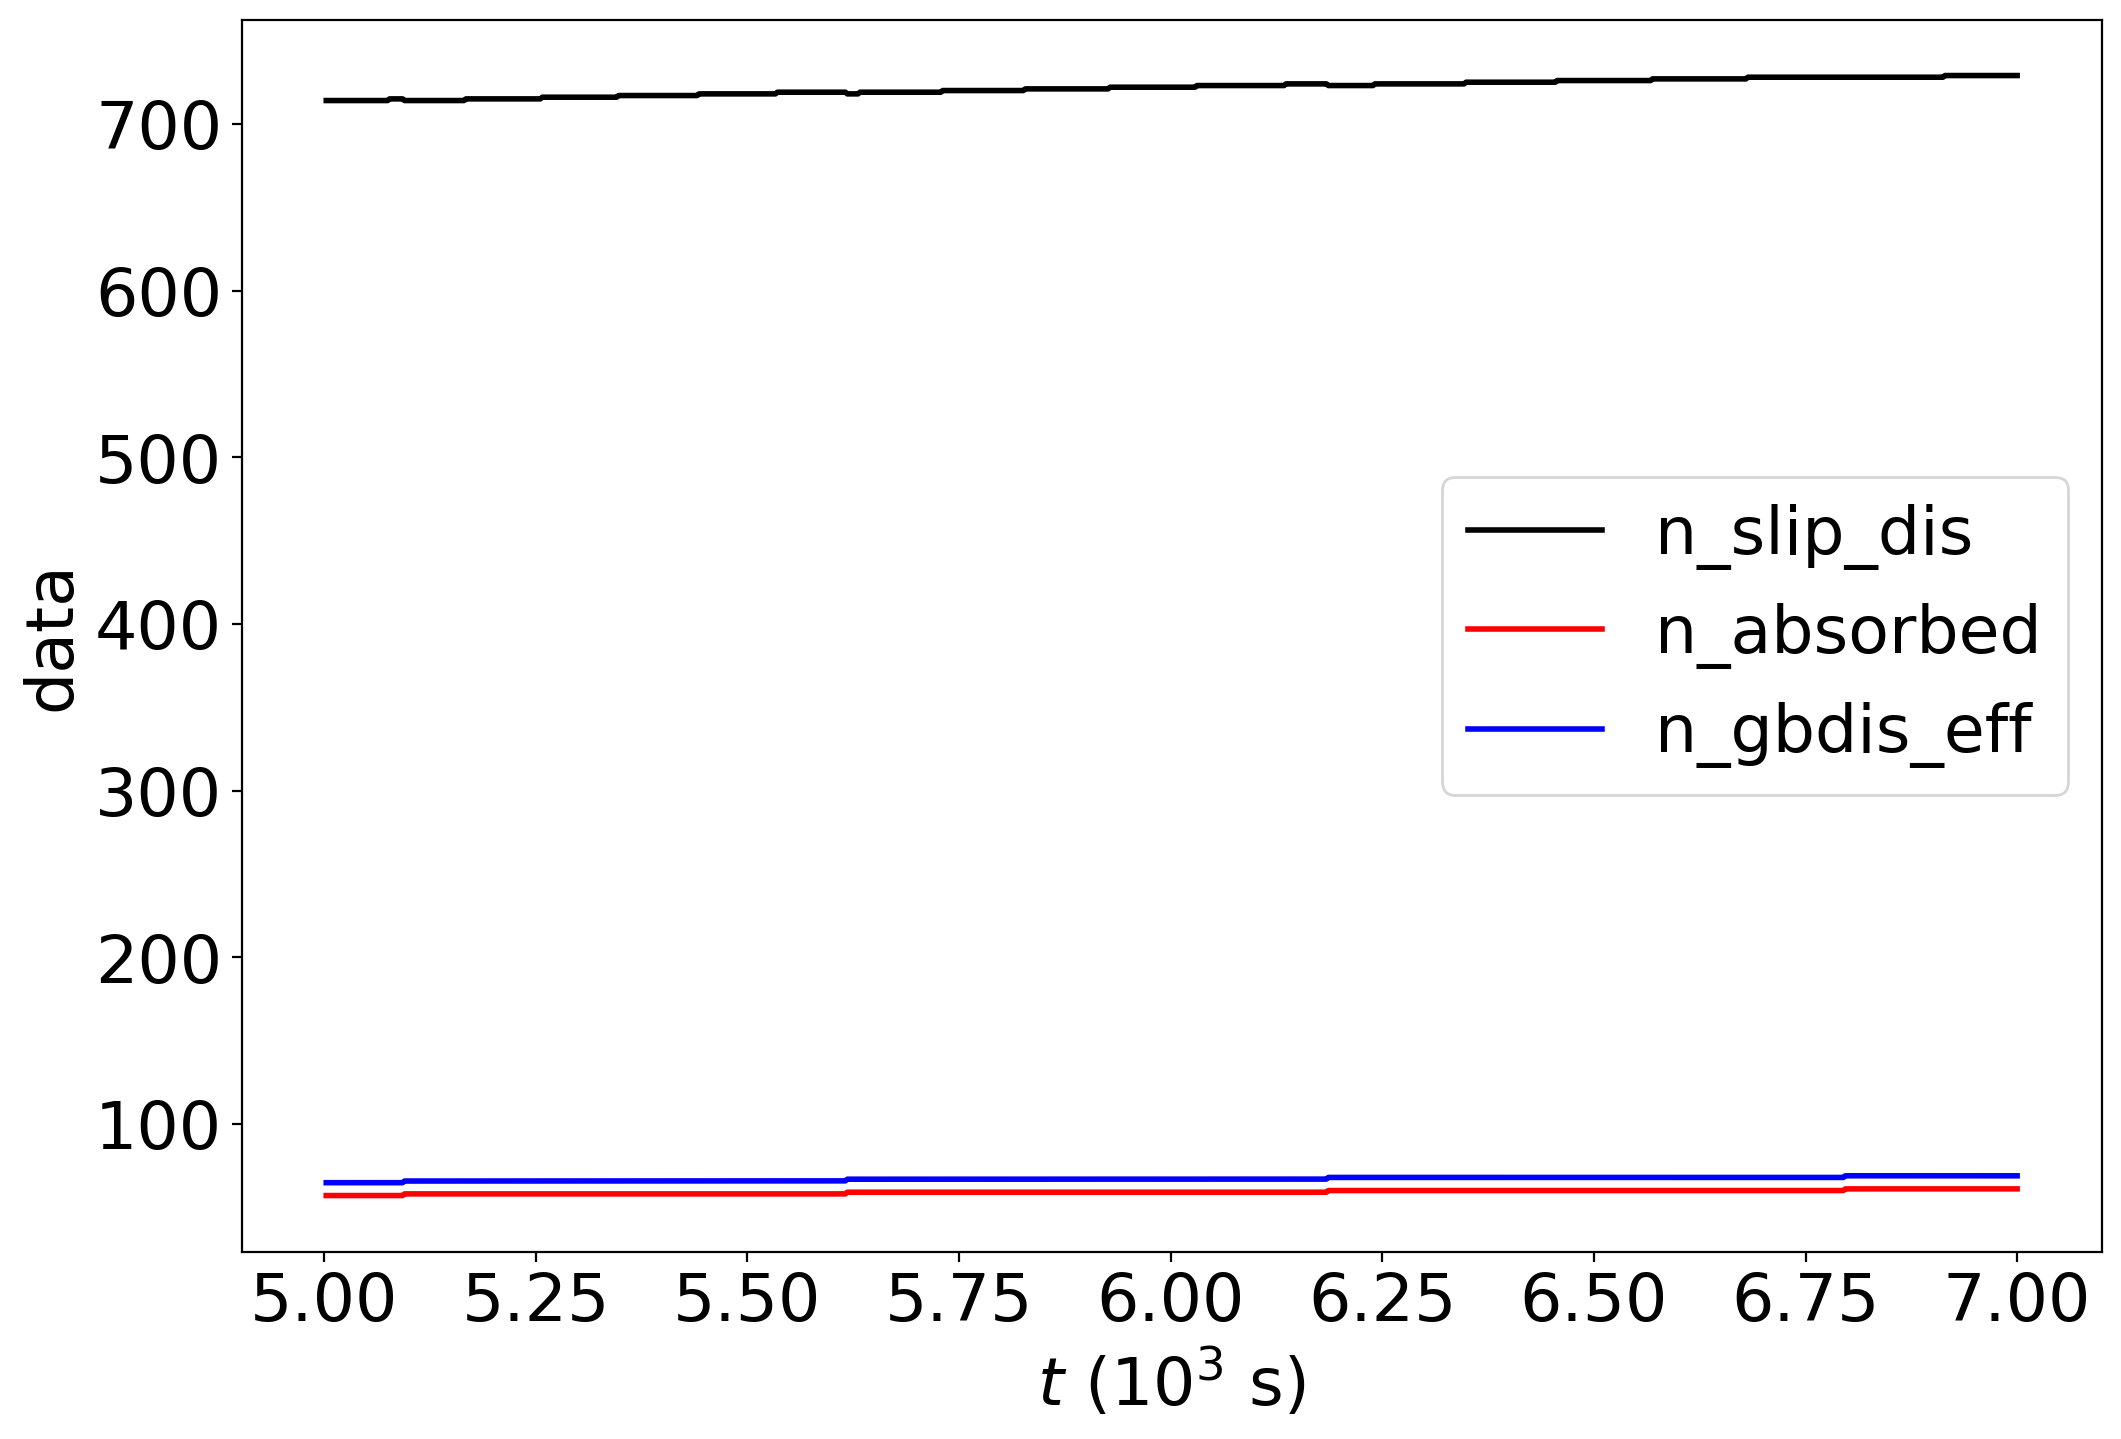

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.4354801815912341e-11, Nslip: 728.35, Ngb_eff: 68.66976703229636
*** hvar, hist *** 1.0 (array([65, 35]), array([728. , 728.5, 729. ]))
Data file with H=30.0, L=0.3, T=700.0, tau0=150.0, n=74


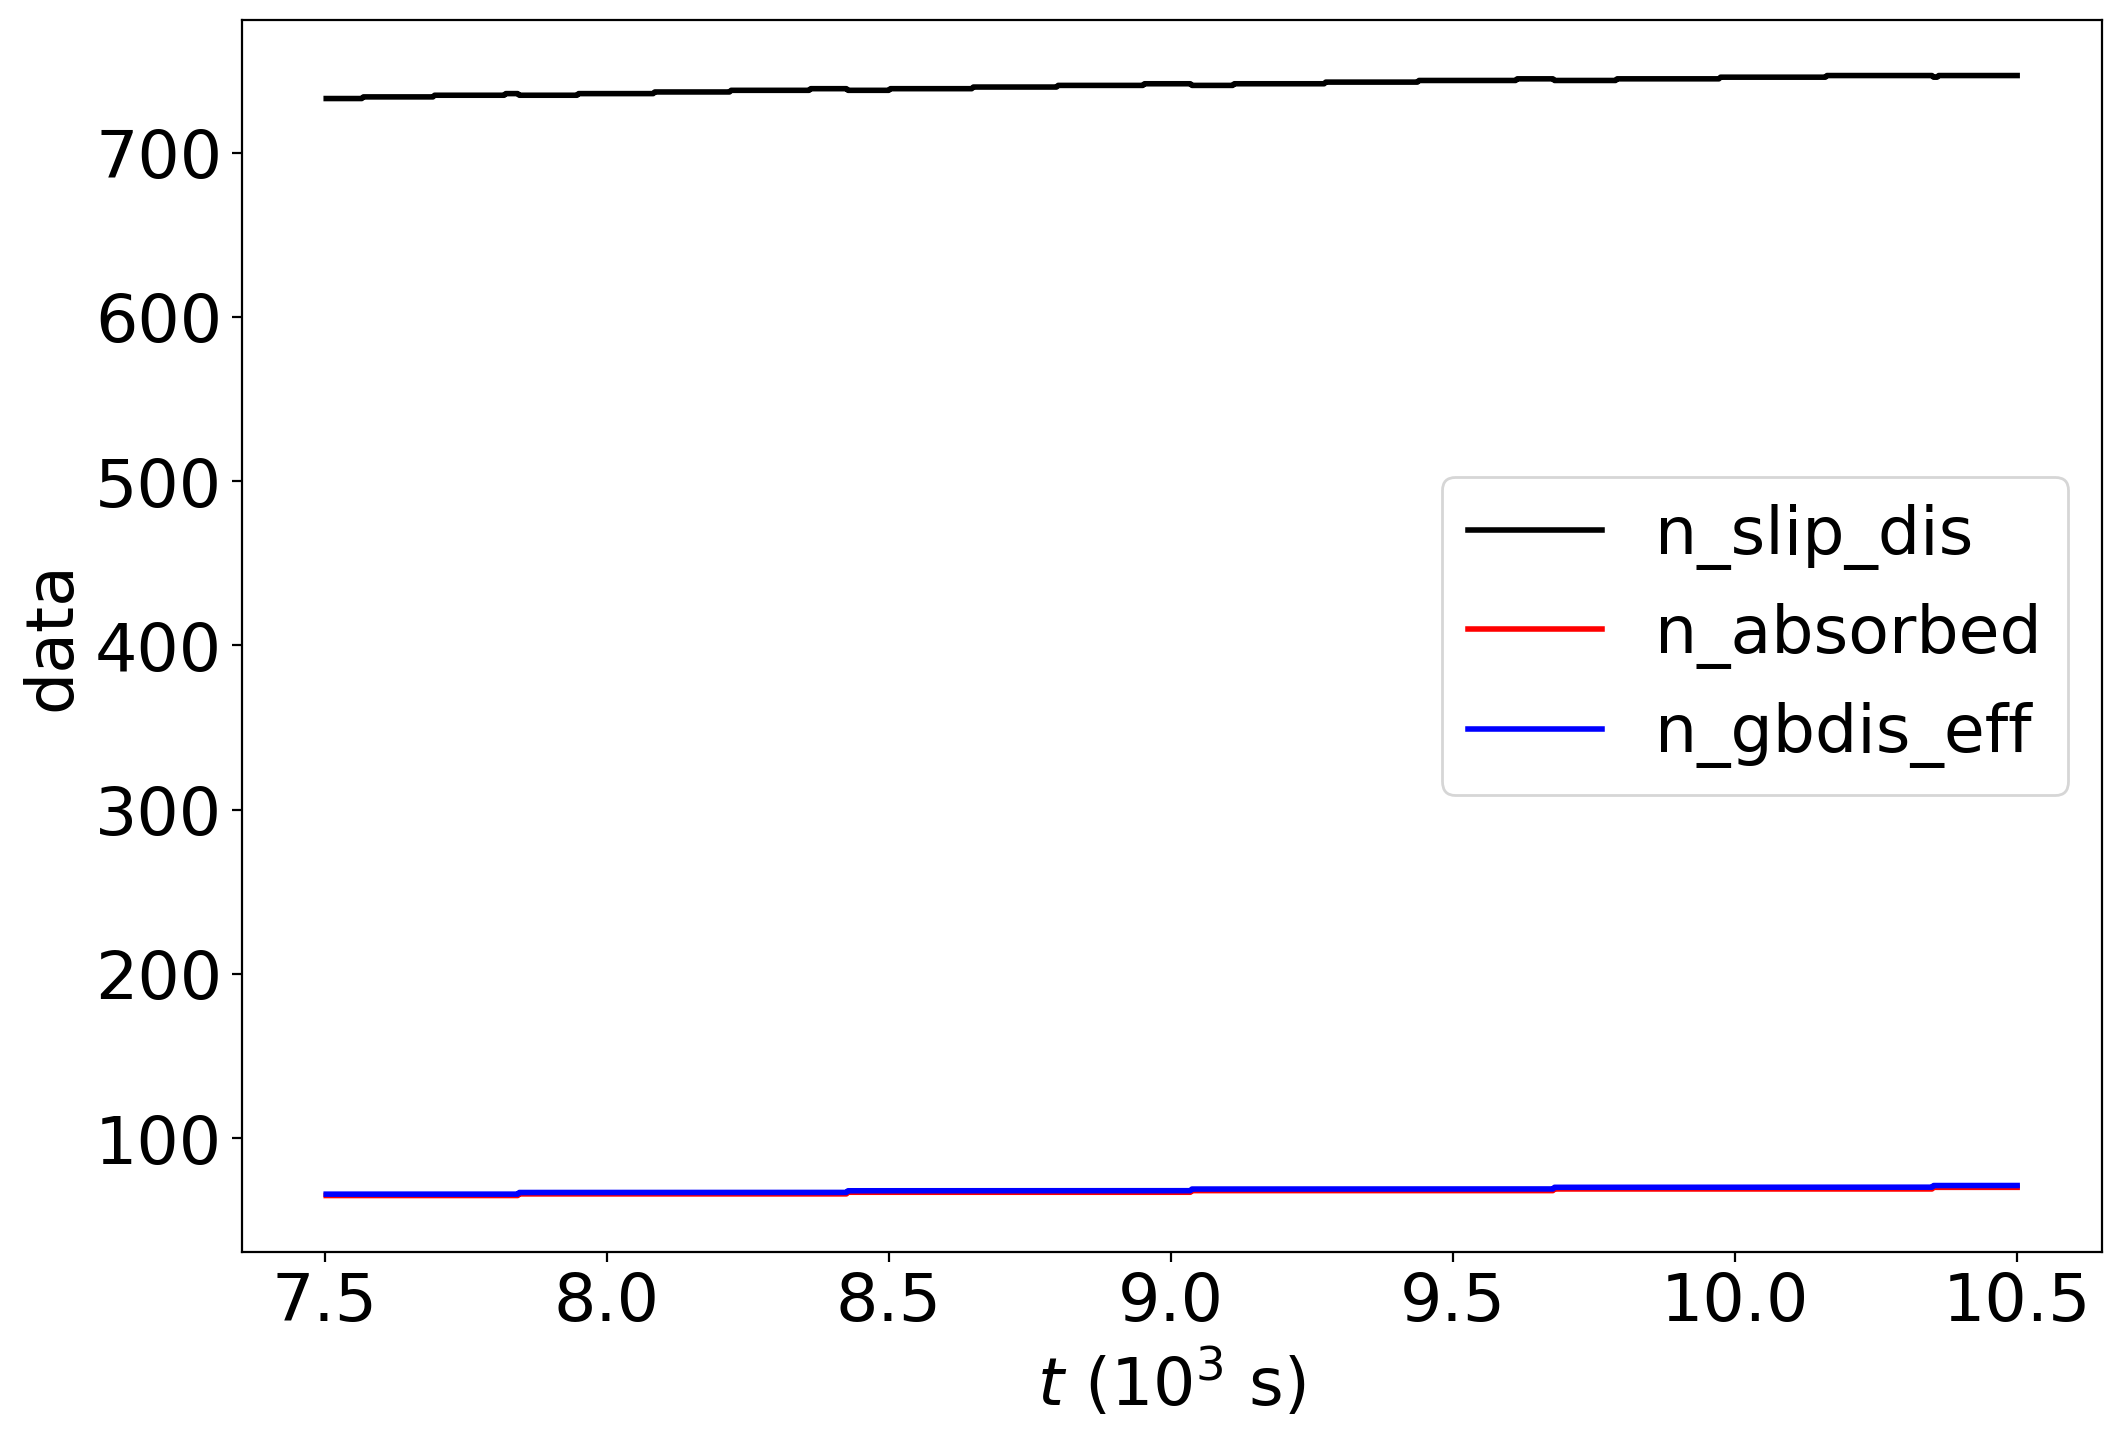

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.8273357316093644e-12, Nslip: 746.97, Ngb_eff: 70.59043496321353
*** hvar, hist *** 1.0 (array([ 3, 97]), array([746. , 746.5, 747. ]))
Data file with H=3.0, L=0.1, T=700.0, tau0=150.0, n=24


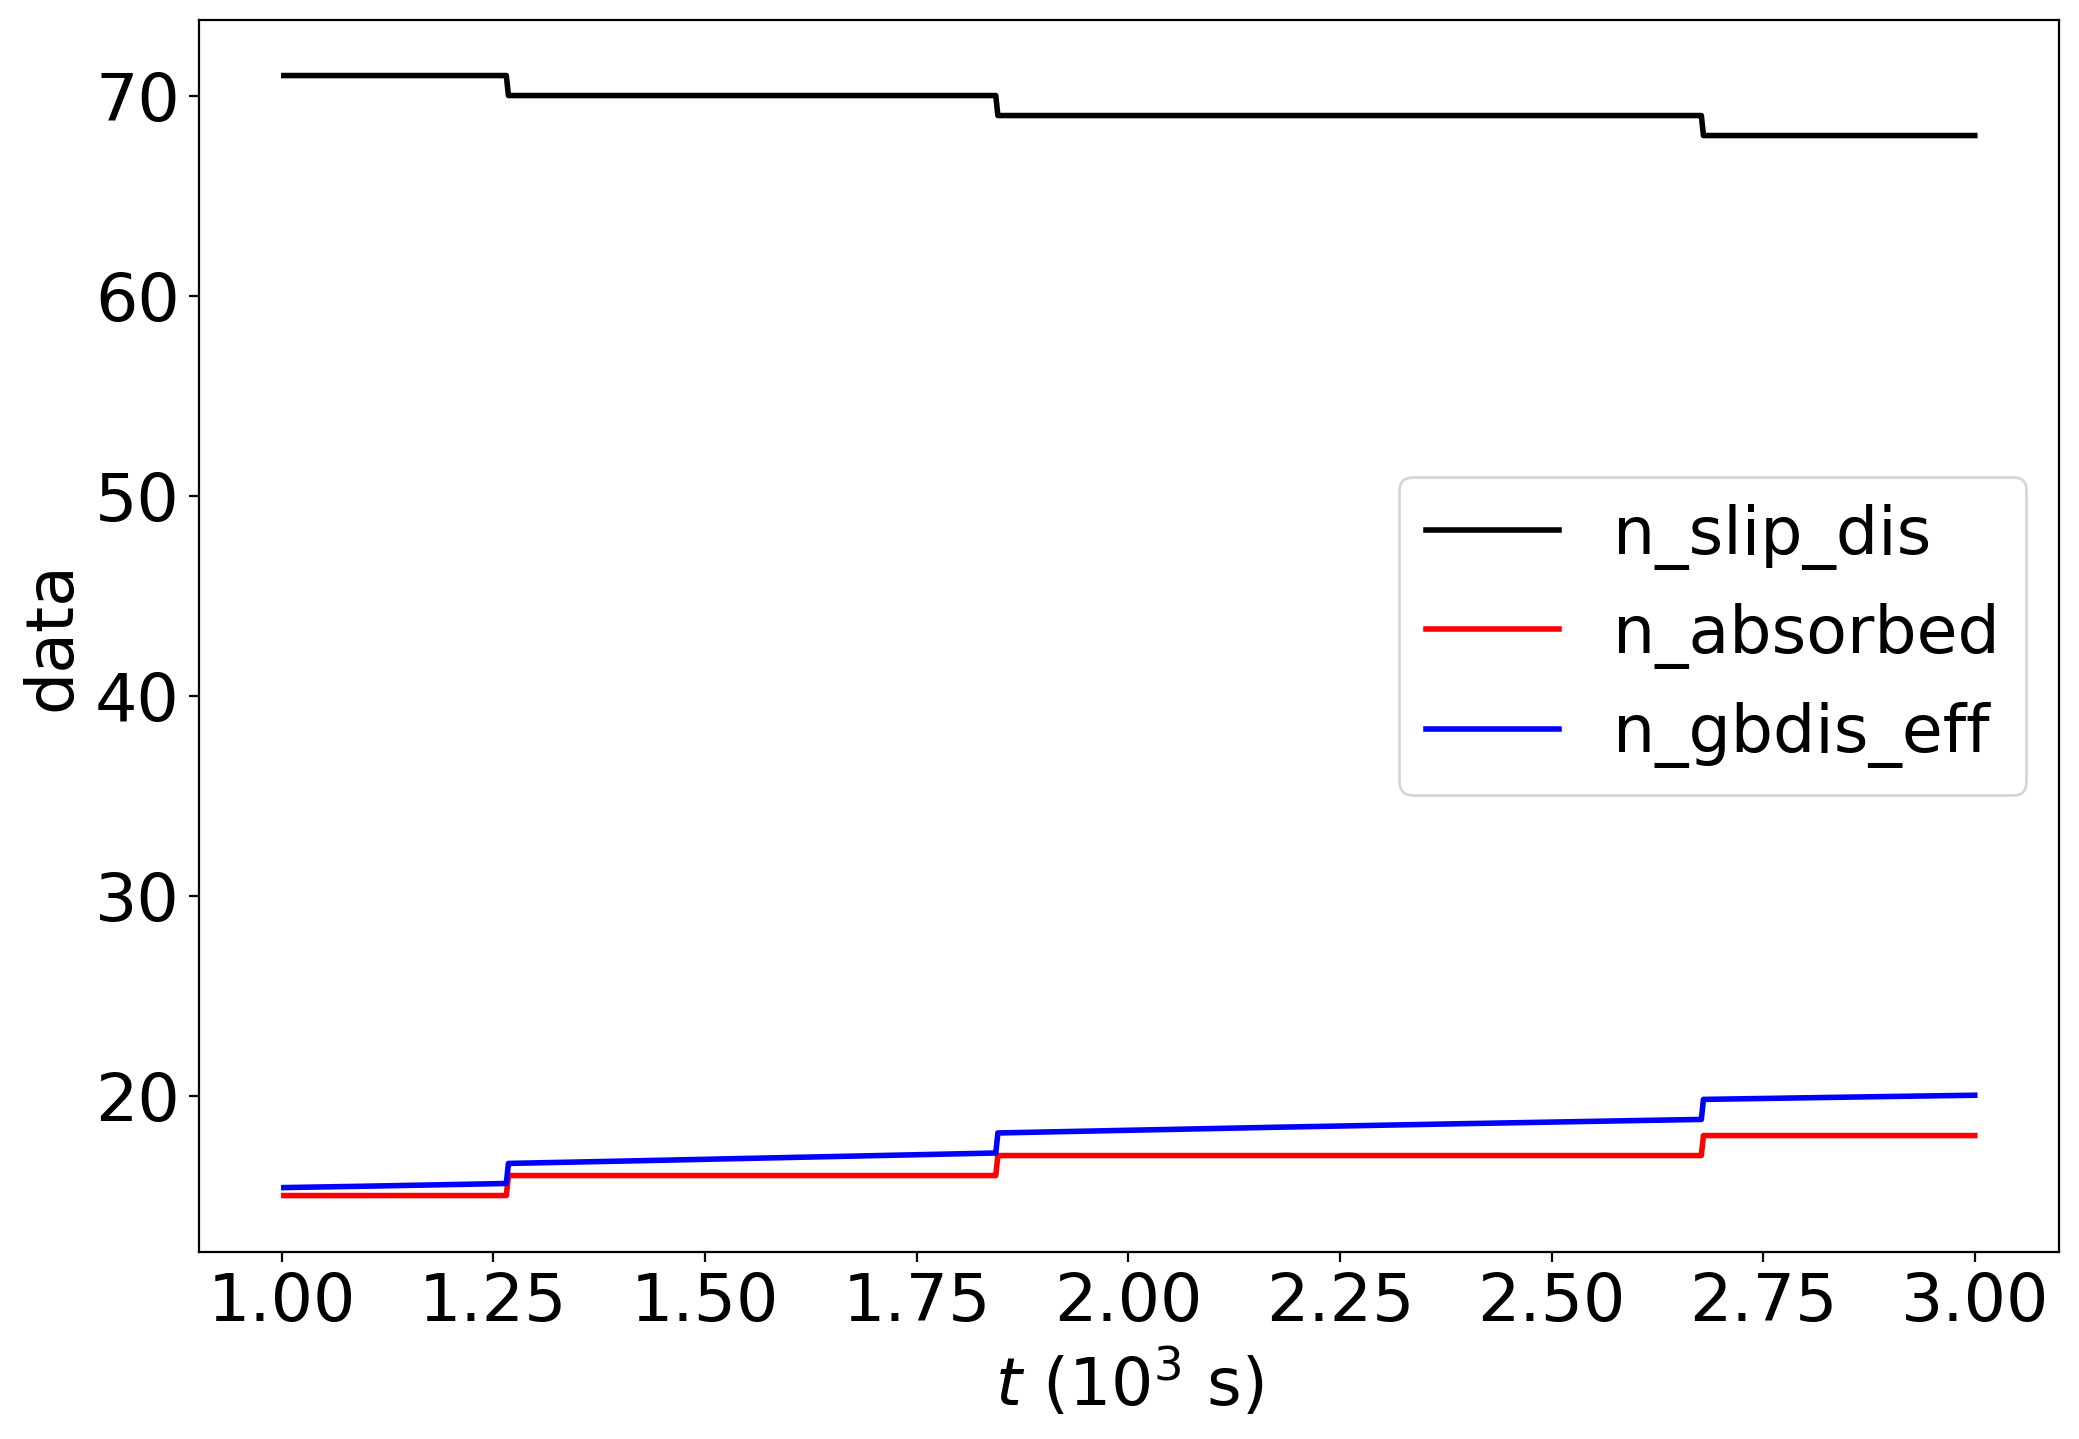

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -3.6666651146788377e-13, Nslip: 68.0, Ngb_eff: 19.937140526489006
*** hvar, hist *** 0.0 (array([100]), array([67.5, 68.5]))
Data file with H=3.0, L=0.3, T=700.0, tau0=150.0, n=74


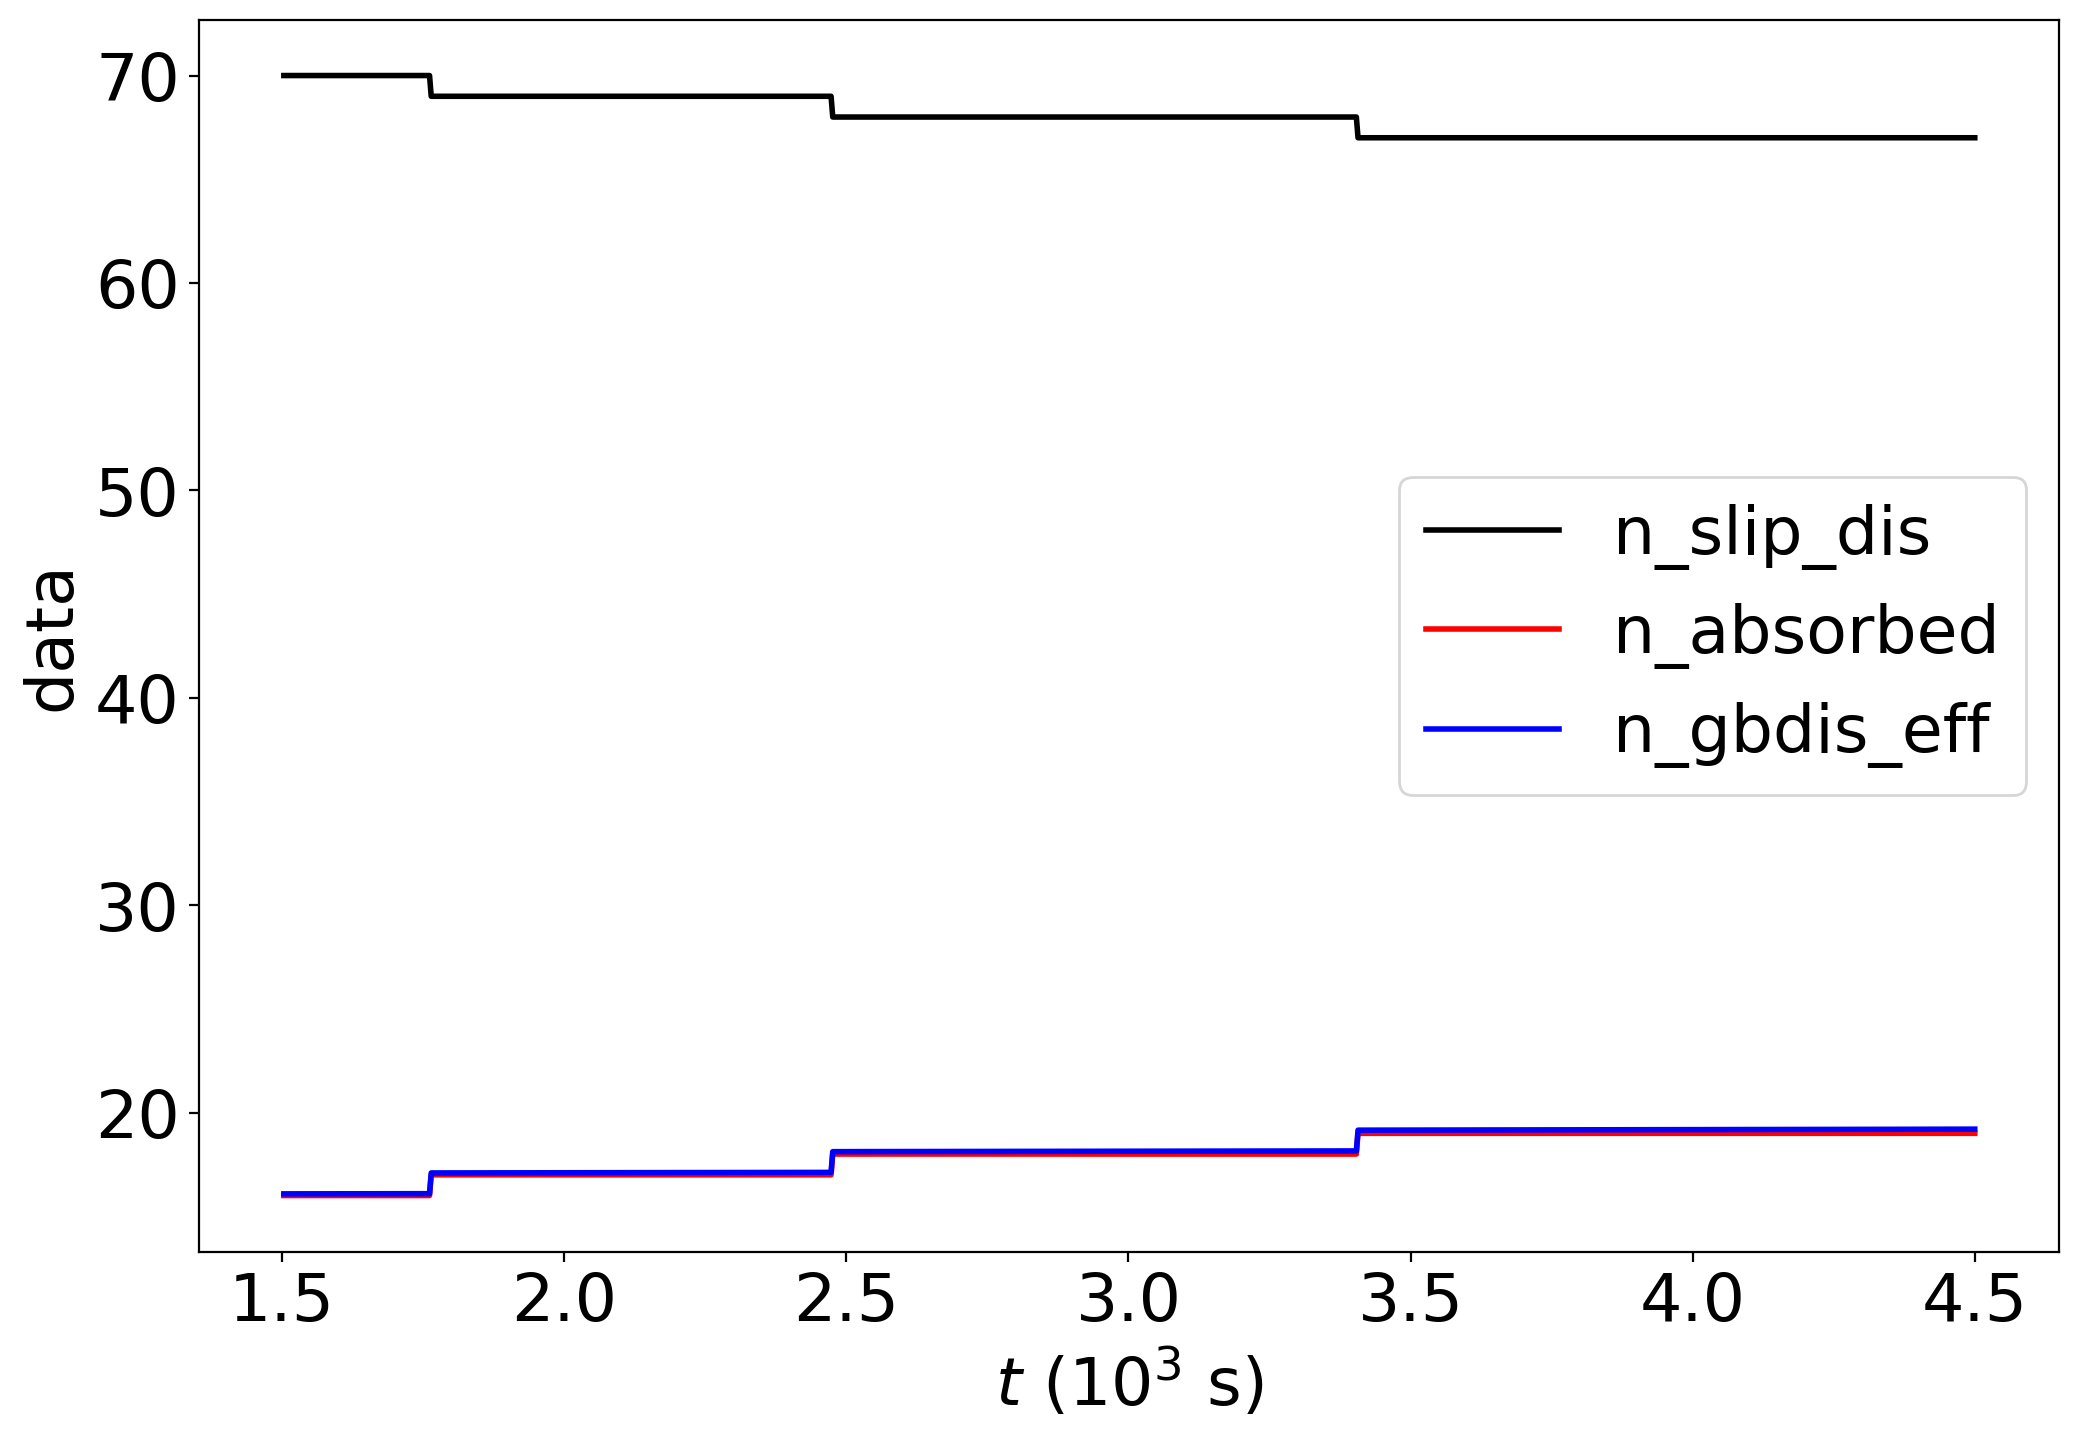

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 4.6943070174165786e-14, Nslip: 67.0, Ngb_eff: 19.193615842158472
*** hvar, hist *** 0.0 (array([100]), array([66.5, 67.5]))
Data file with H=0.3, L=0.1, T=700.0, tau0=150.0, n=24


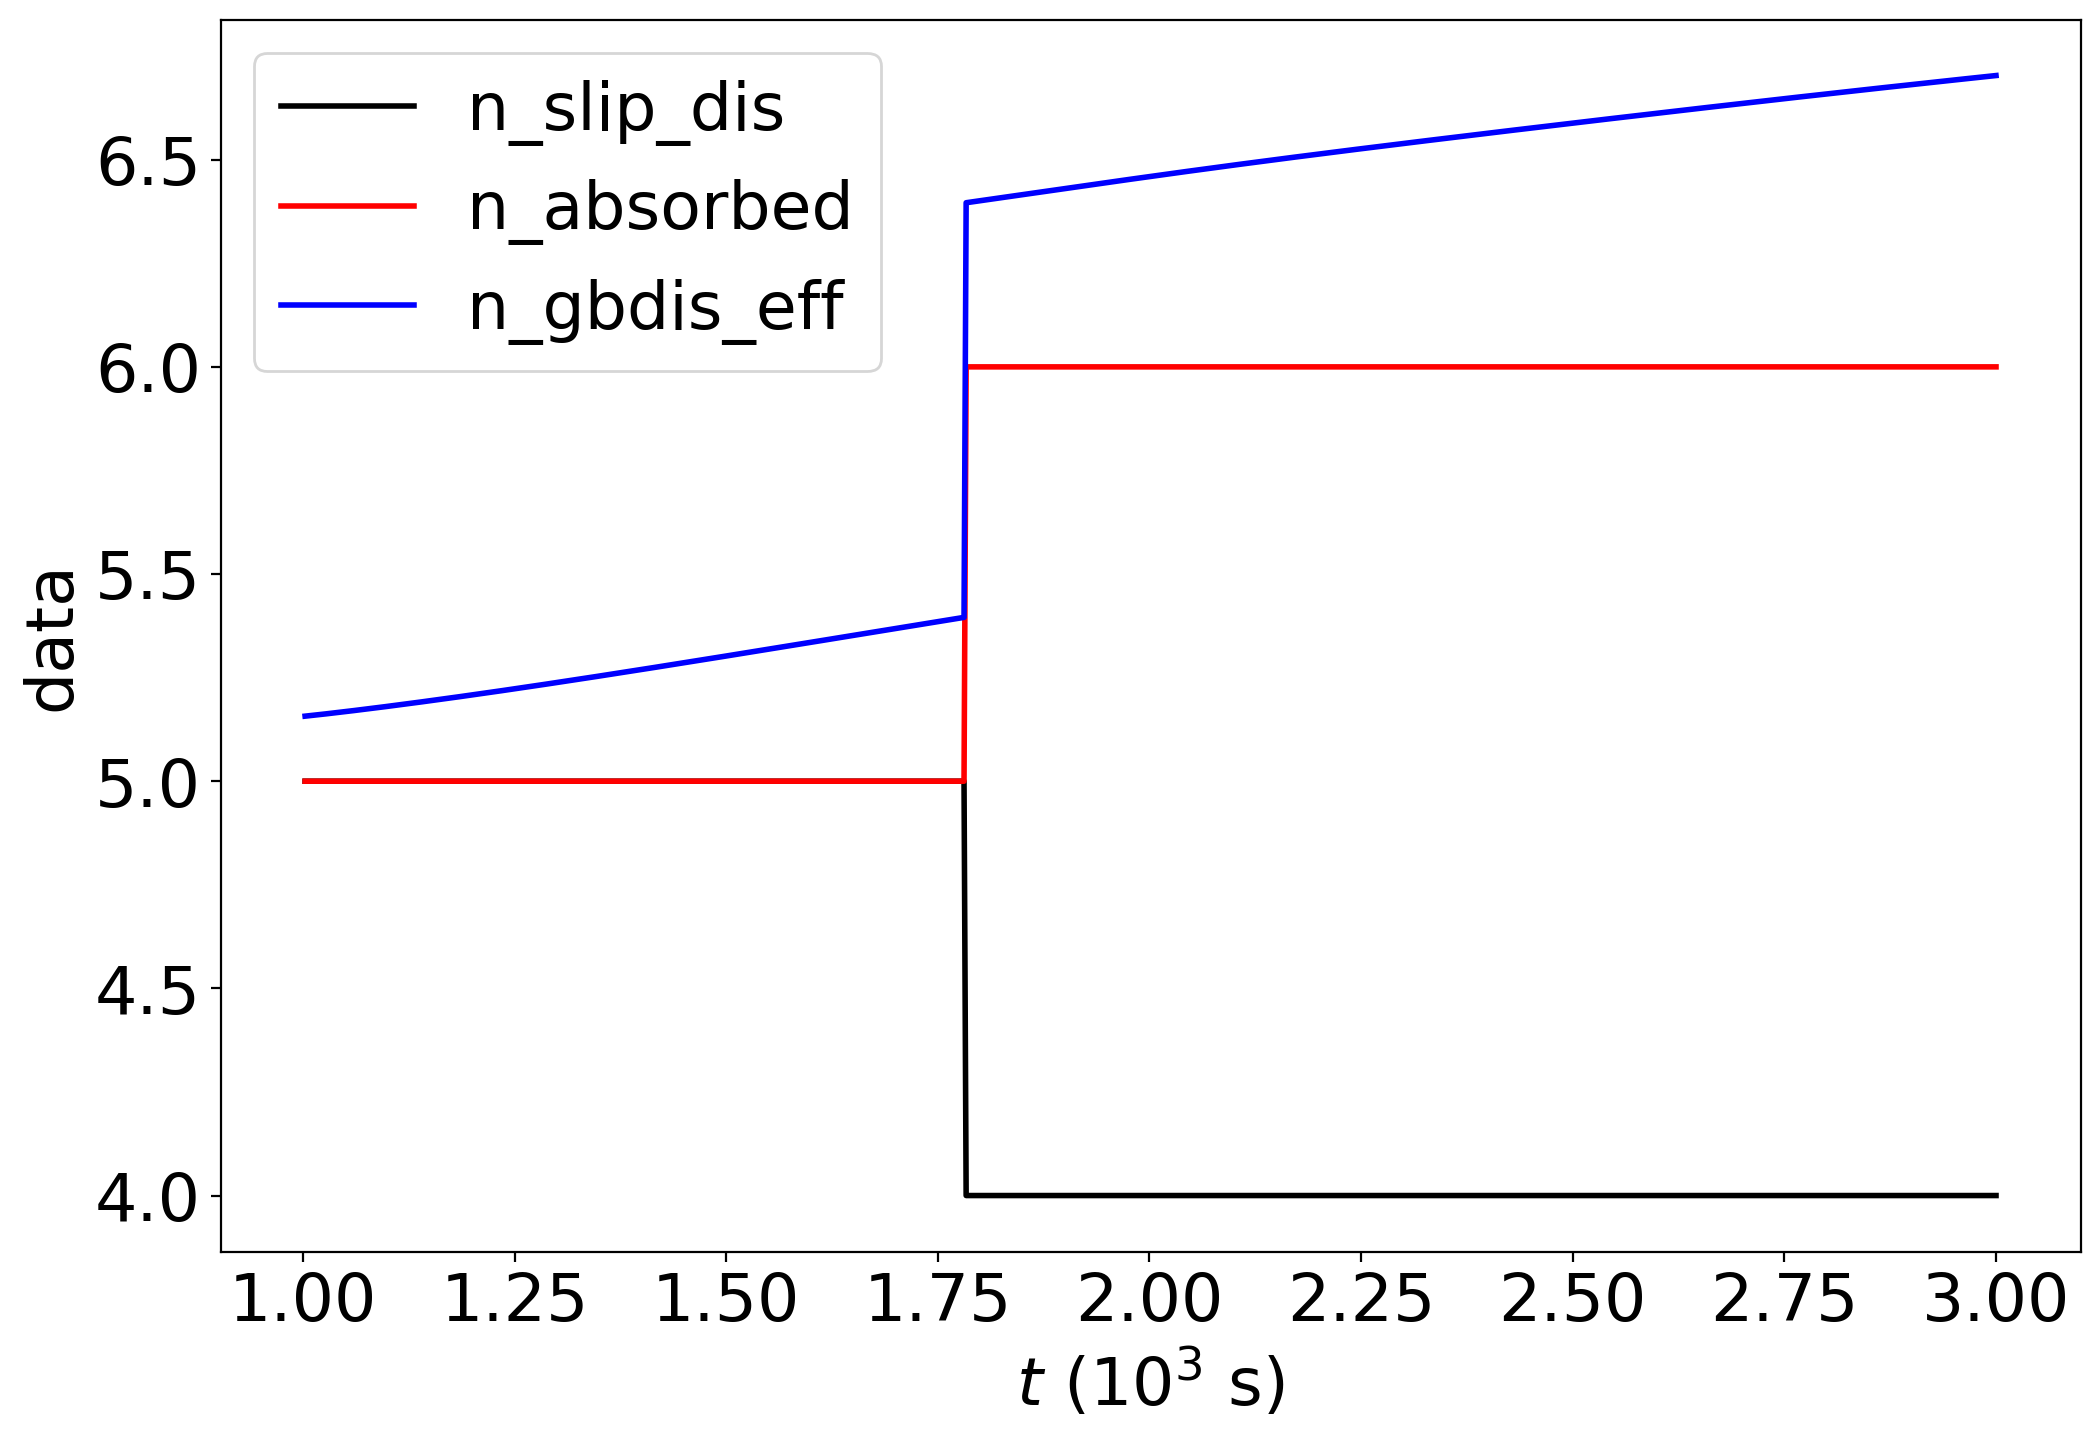

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 3.0356225408922926e-14, Nslip: 4.0, Ngb_eff: 6.67573104483204
*** hvar, hist *** 0.0 (array([100]), array([3.5, 4.5]))
Data file with H=0.3, L=0.3, T=700.0, tau0=150.0, n=74


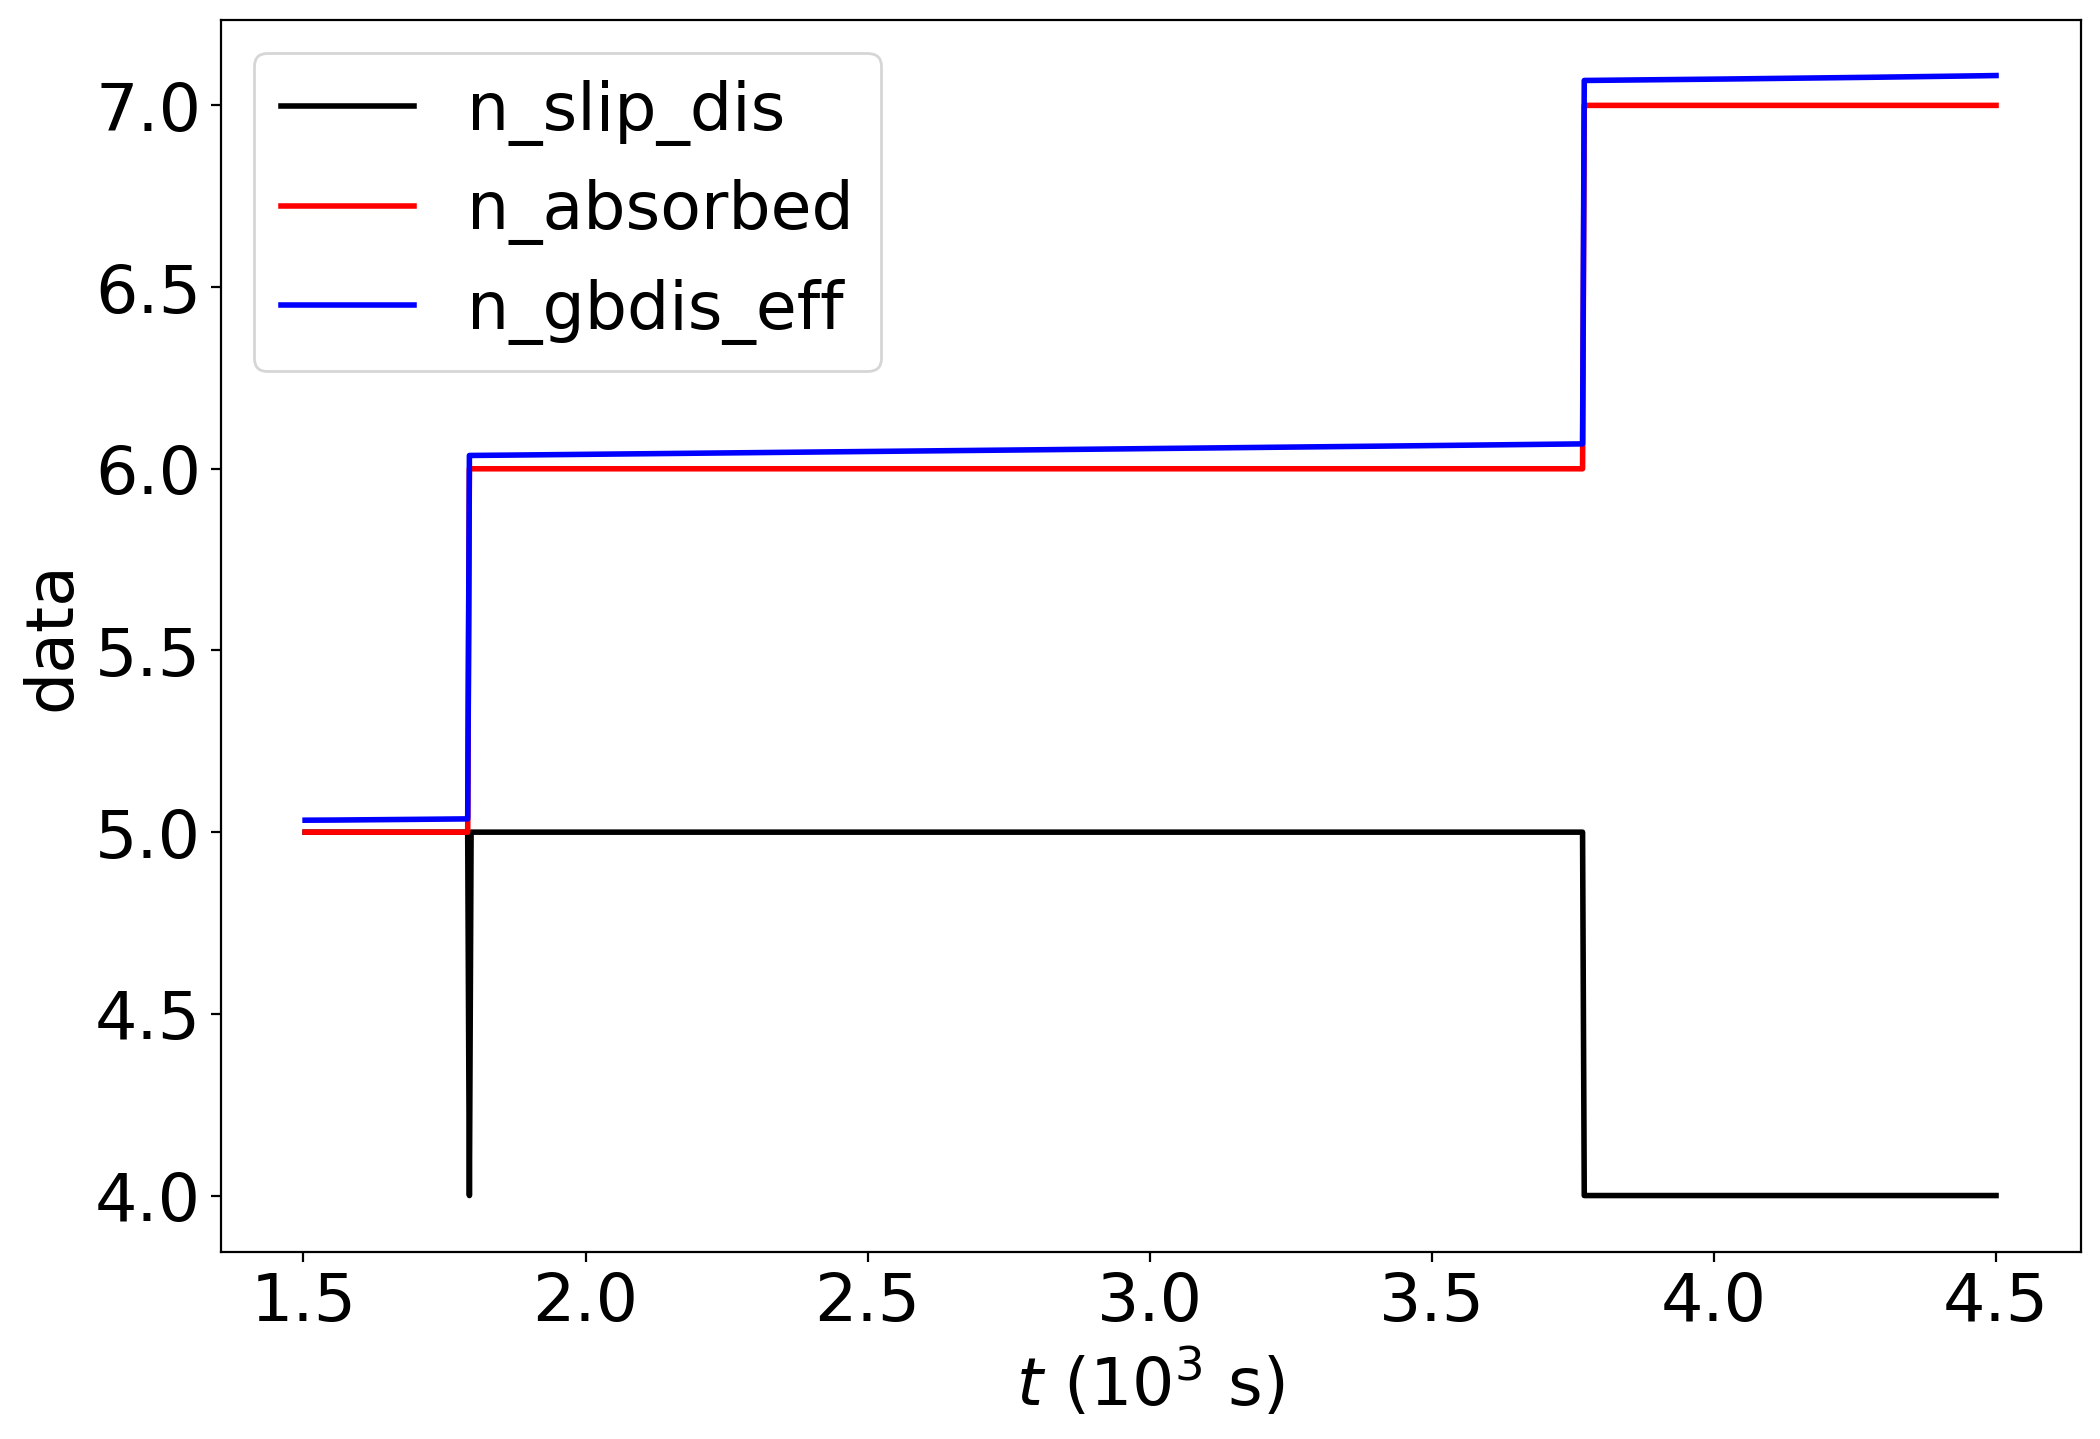

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.3929381825382738e-14, Nslip: 4.0, Ngb_eff: 7.078844303644165
*** hvar, hist *** 0.0 (array([100]), array([3.5, 4.5]))
Data file with H=60.0, L=0.1, T=700.0, tau0=150.0, n=24


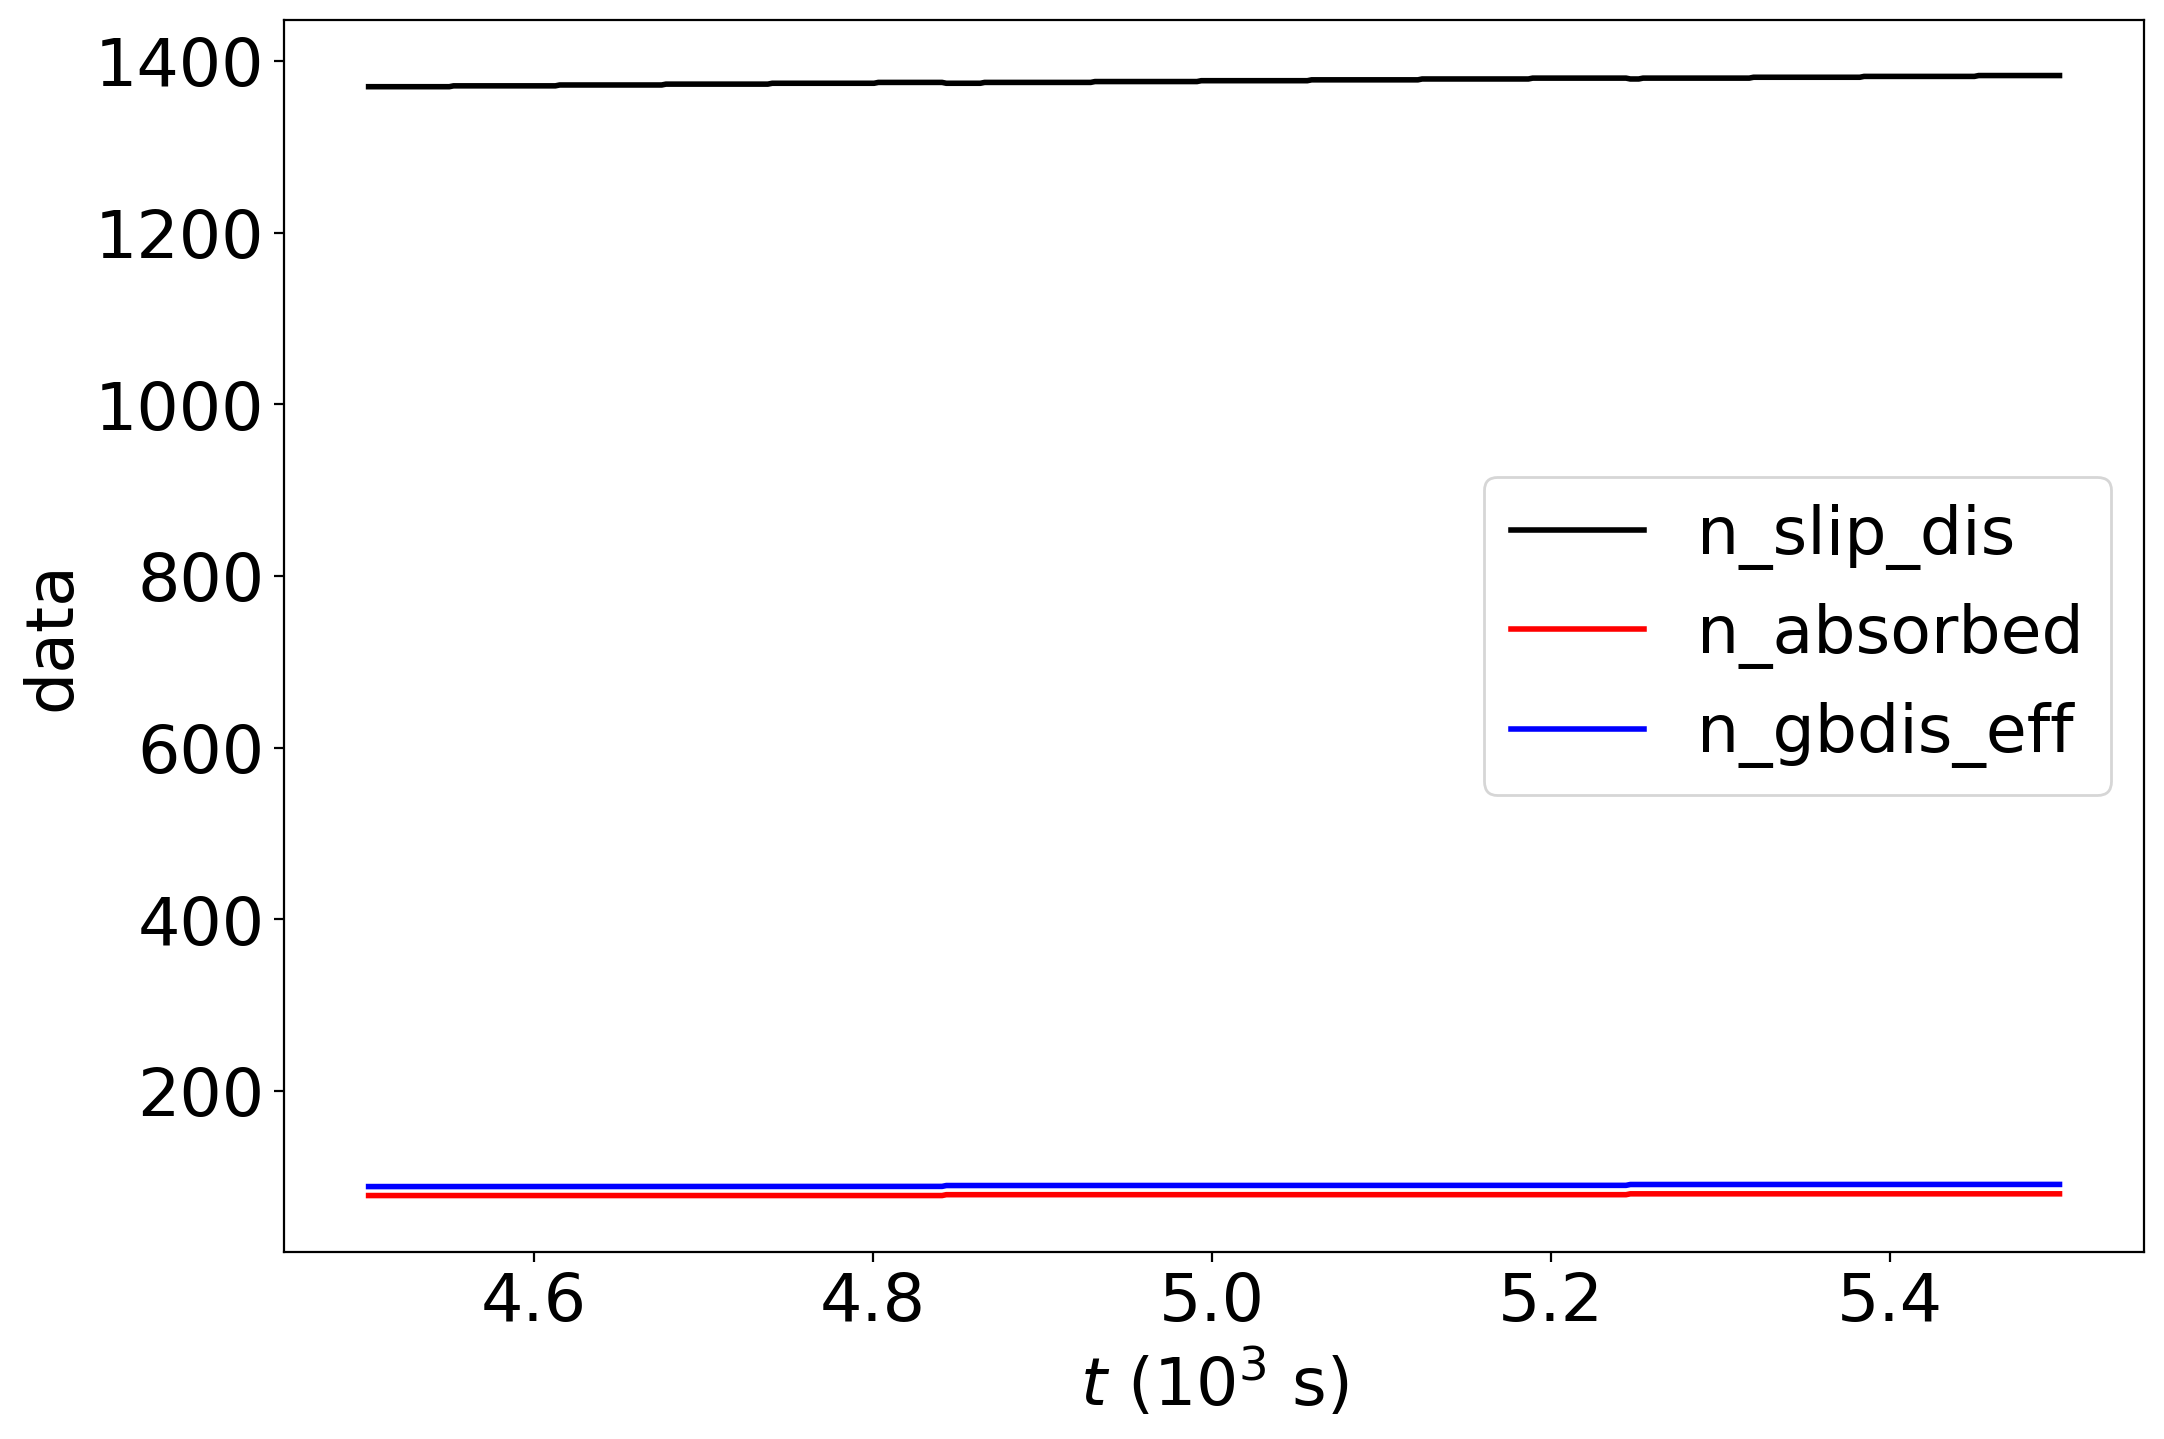

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.4719099542913856e-11, Nslip: 1381.39, Ngb_eff: 90.91693586001317
*** hvar, hist *** 4.0 (array([ 1, 26, 26, 27, 20]), array([1379. , 1379.8, 1380.6, 1381.4, 1382.2, 1383. ]))
Data file with H=60.0, L=0.3, T=700.0, tau0=150.0, n=74


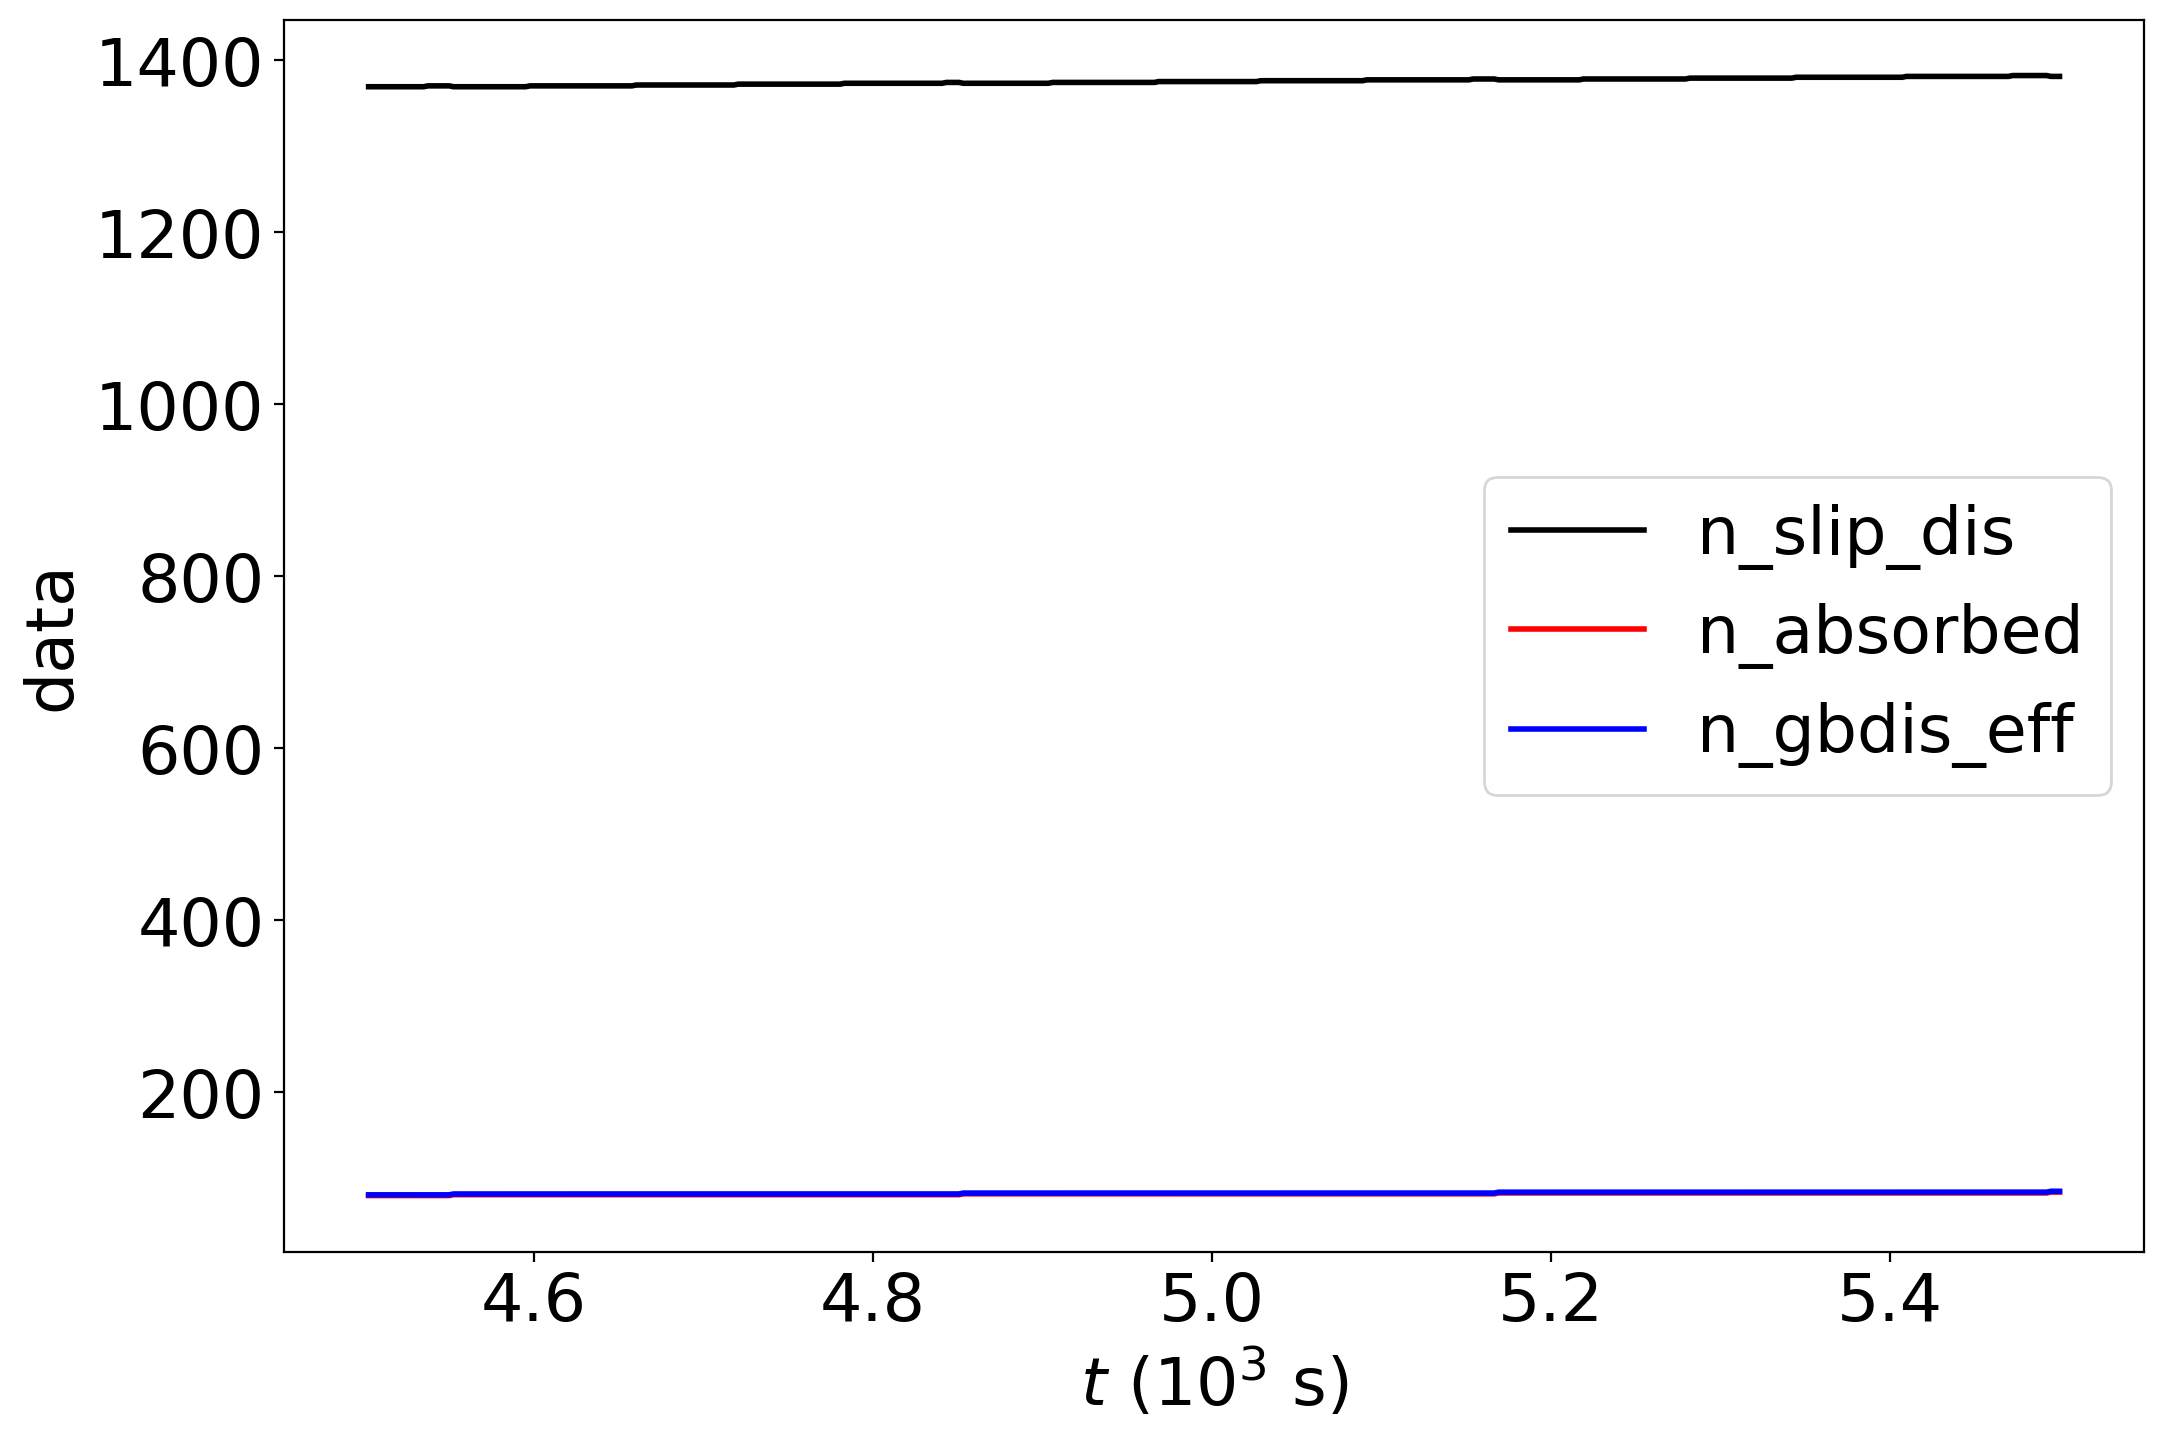

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 8.709444209359363e-12, Nslip: 1379.97, Ngb_eff: 83.97278358179891
*** hvar, hist *** 4.0 (array([12, 25, 26, 28,  9]), array([1378. , 1378.8, 1379.6, 1380.4, 1381.2, 1382. ]))
Data file with H=100.0, L=0.1, T=800.0, tau0=150.0, n=24


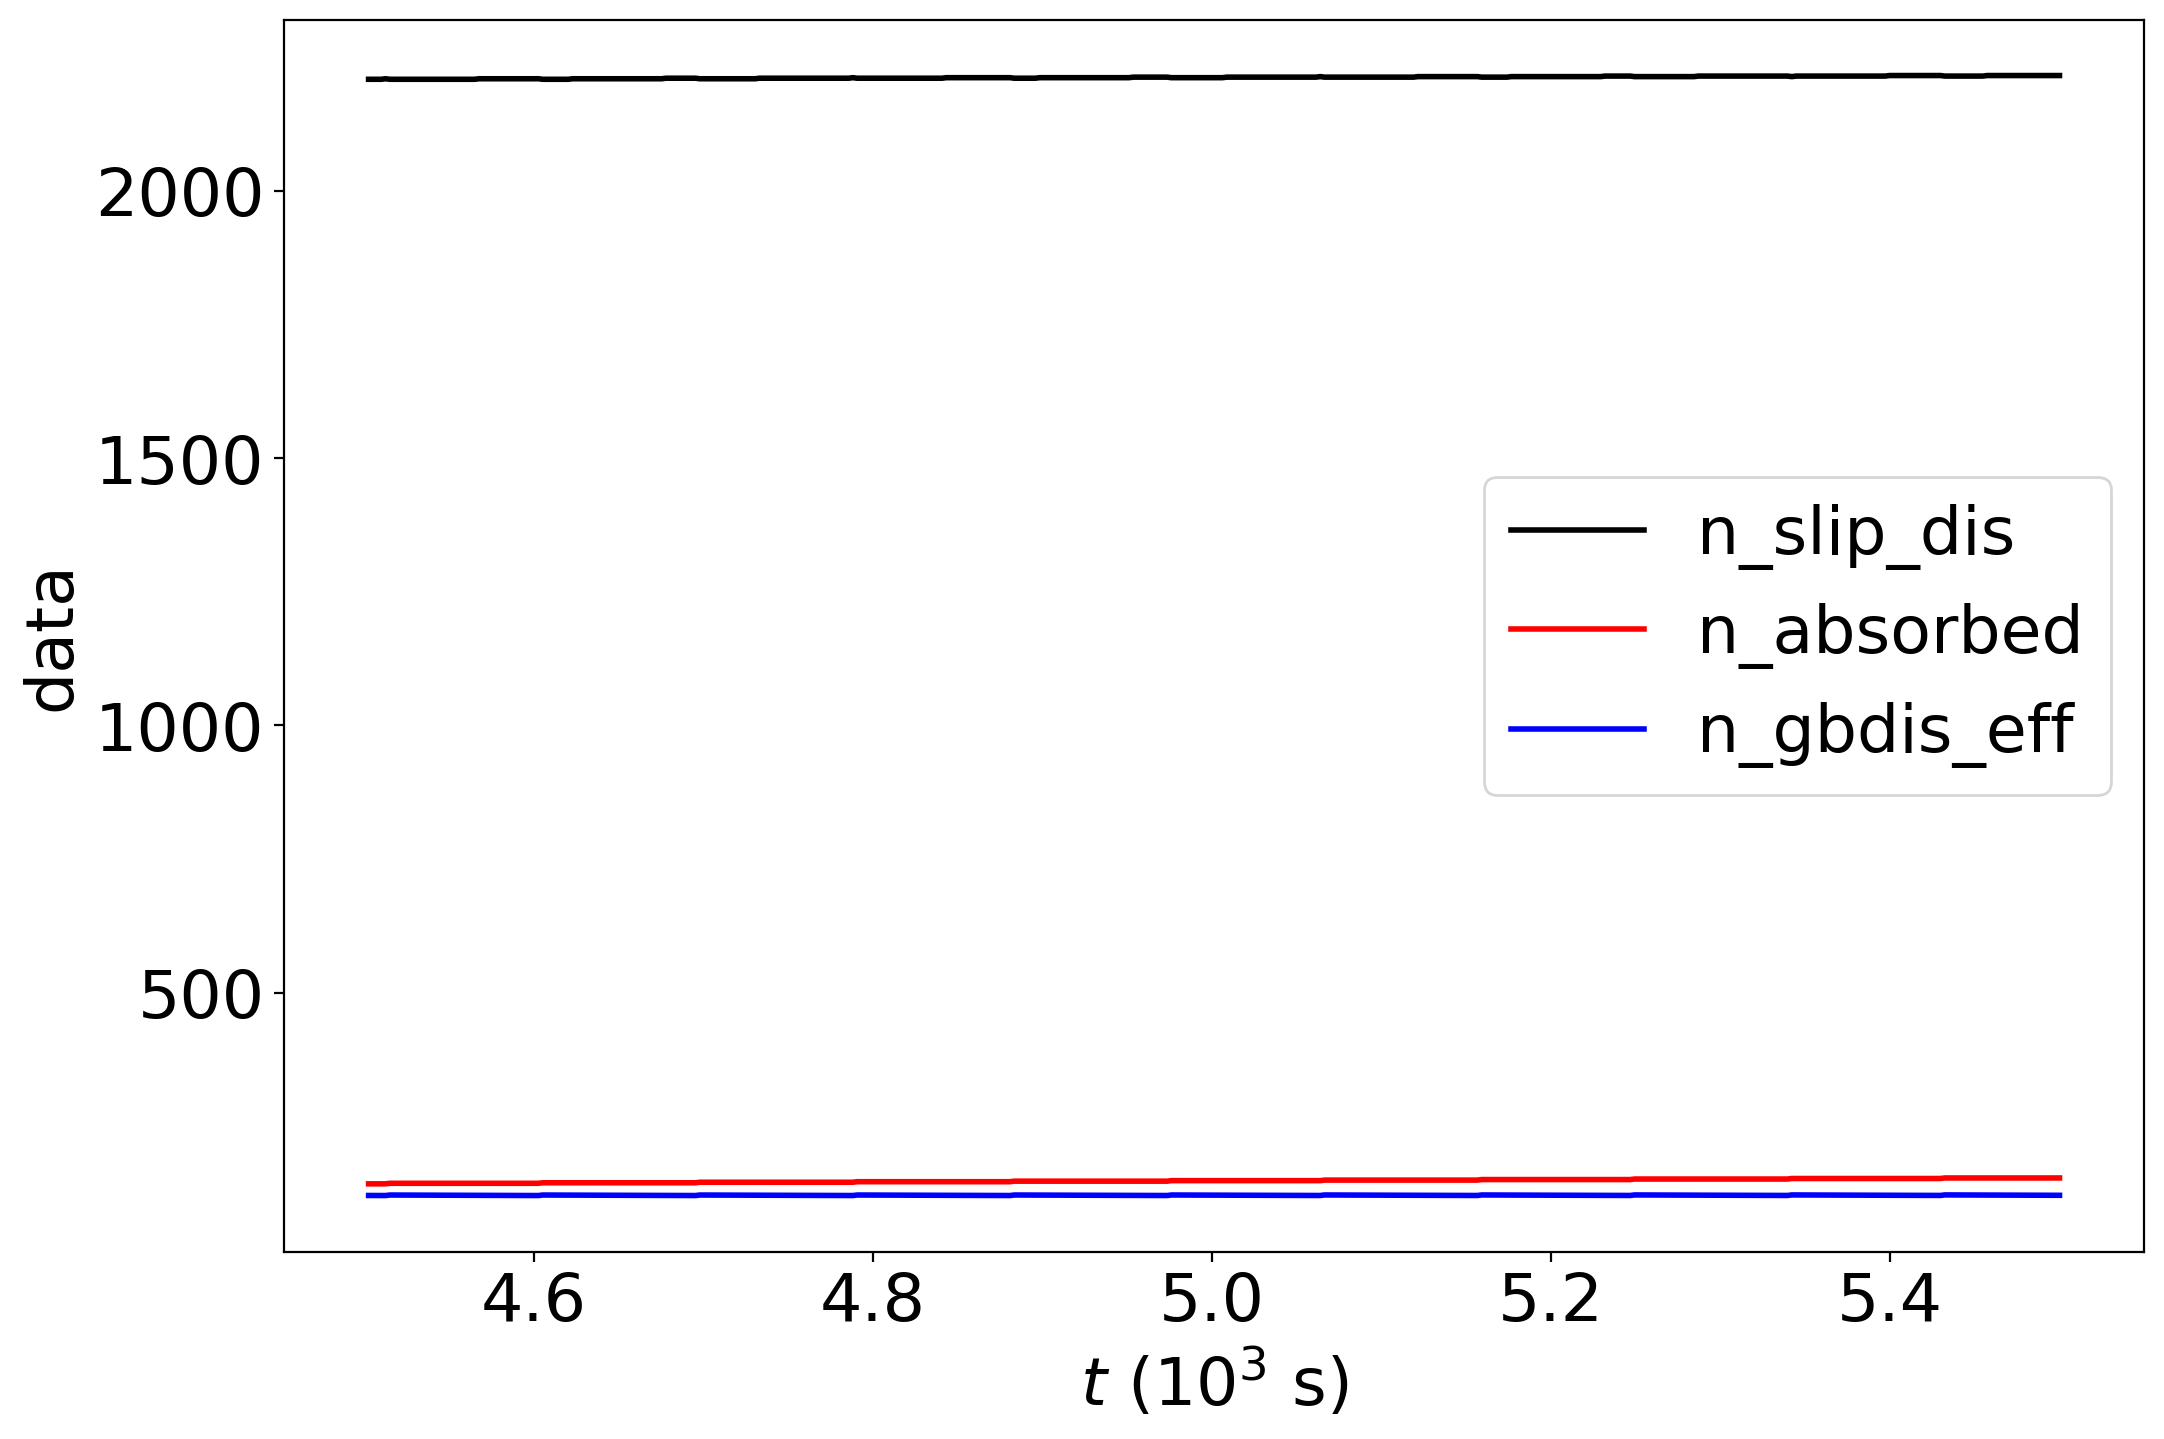

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 3.3856228555360217e-11, Nslip: 2215.16, Ngb_eff: 120.7895034732399
*** hvar, hist *** 2.0 (array([15, 54, 31]), array([2214.        , 2214.66666667, 2215.33333333, 2216.        ]))
Data file with H=10.0, L=0.1, T=800.0, tau0=150.0, n=24


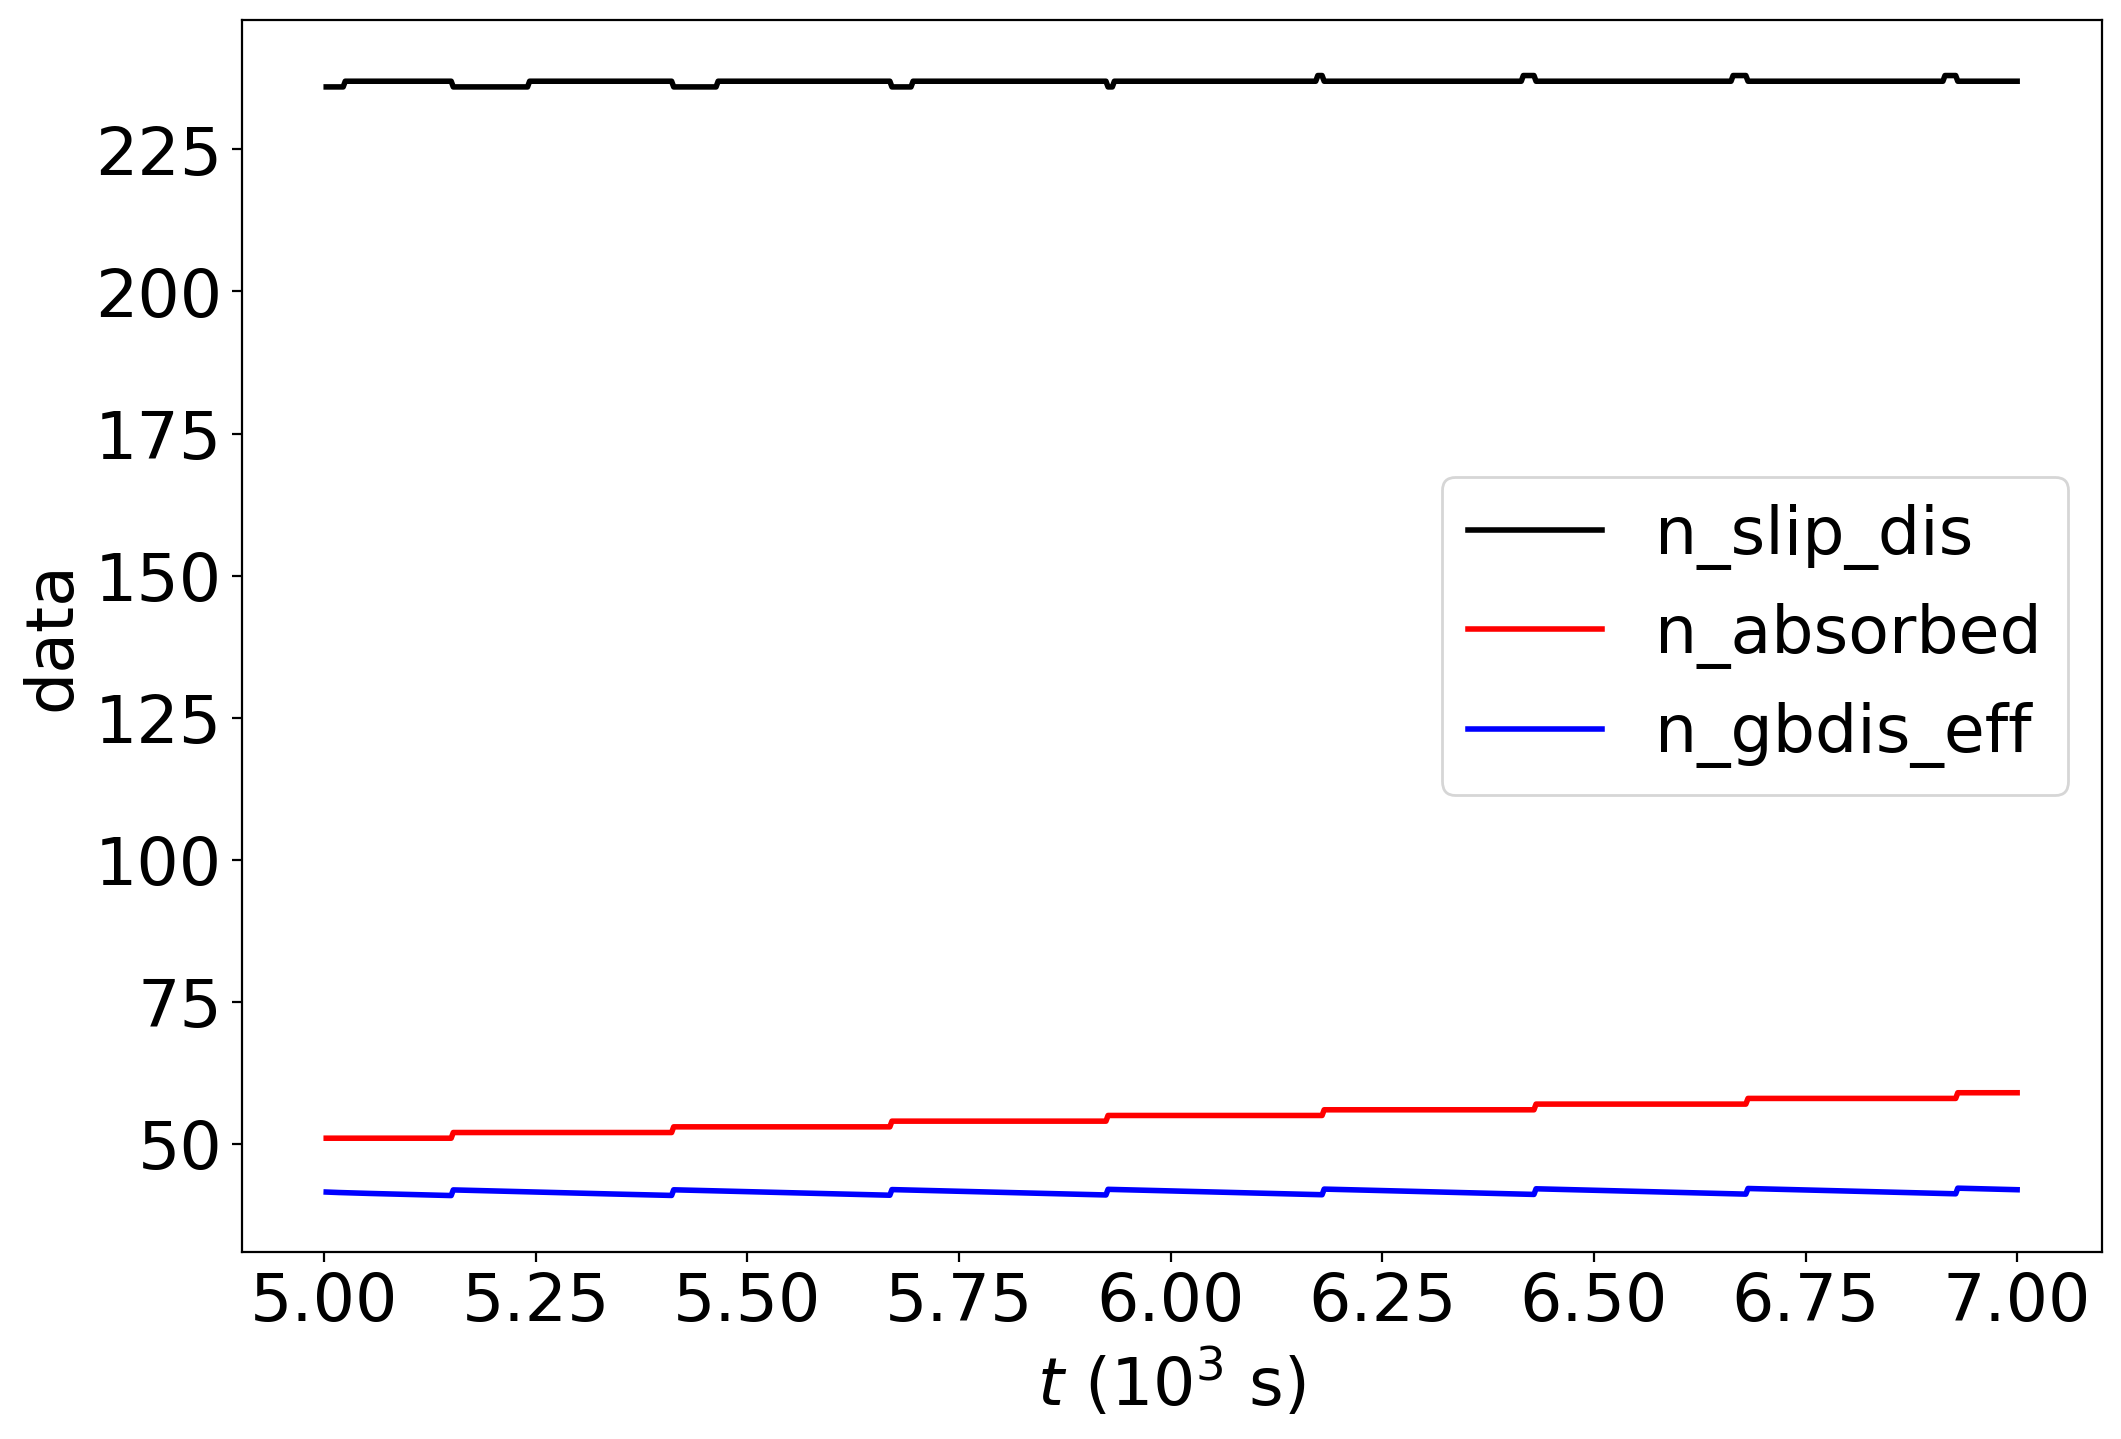

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 9.836677961257616e-12, Nslip: 237.06, Ngb_eff: 41.69668469731144
*** hvar, hist *** 1.0 (array([94,  6]), array([237. , 237.5, 238. ]))
Data file with H=10.0, L=0.3, T=800.0, tau0=150.0, n=74


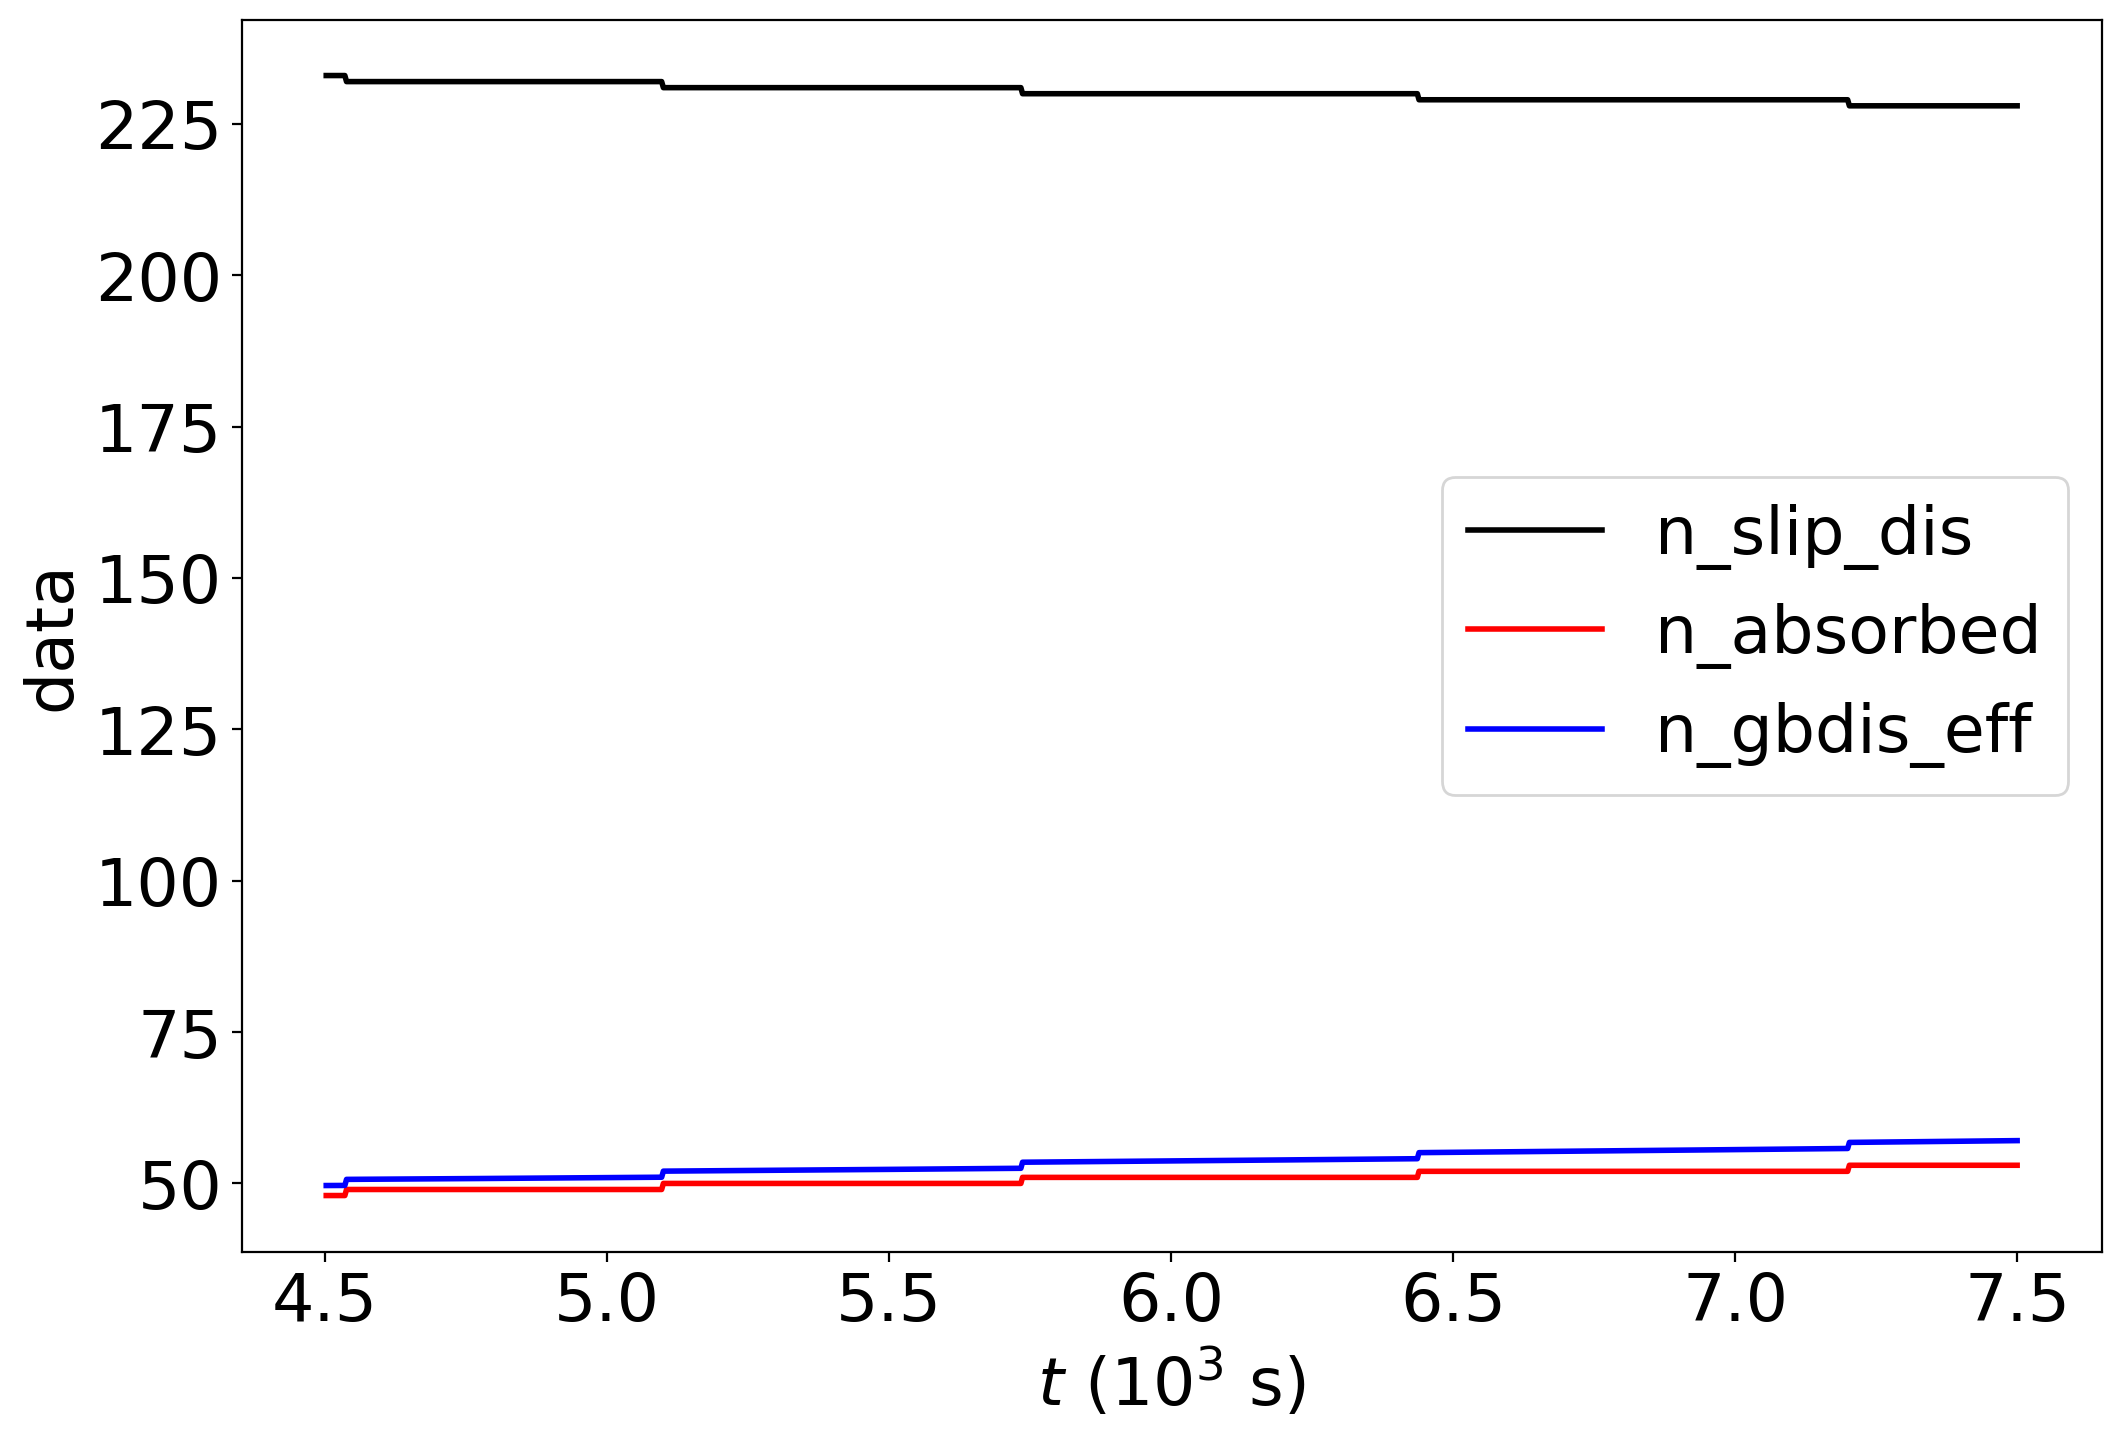

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -1.2919290379003215e-13, Nslip: 228.0, Ngb_eff: 56.91907744360797
*** hvar, hist *** 0.0 (array([100]), array([227.5, 228.5]))
Data file with H=1.0, L=0.1, T=800.0, tau0=150.0, n=24


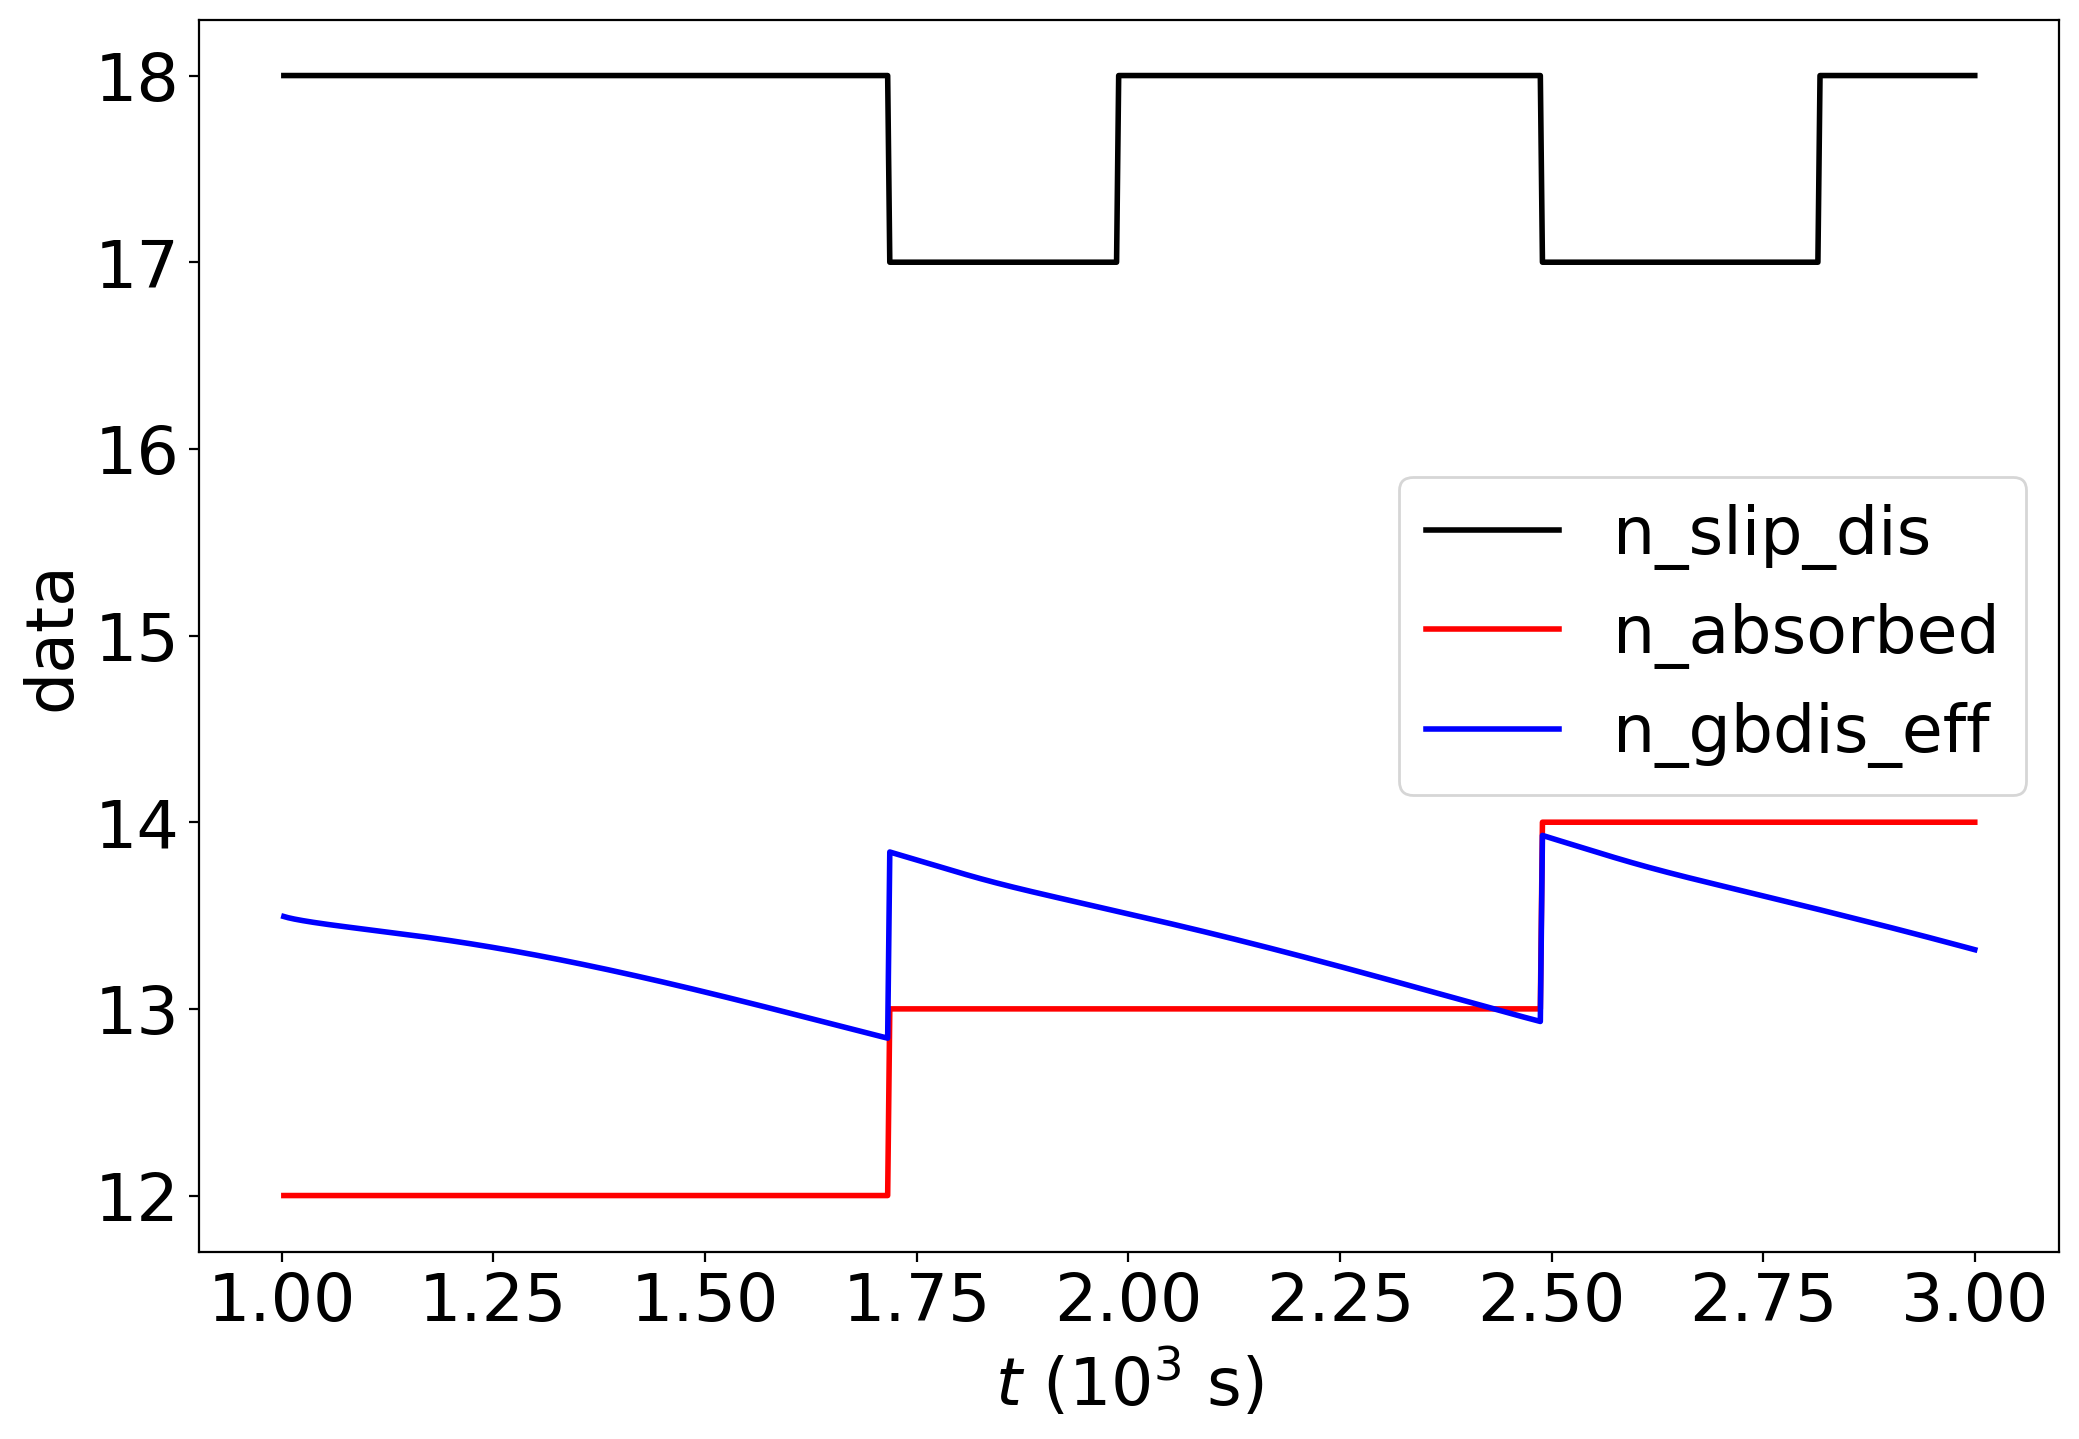

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 6.471099473515099e-12, Nslip: 17.74, Ngb_eff: 13.46275427124845
*** hvar, hist *** 1.0 (array([26, 74]), array([17. , 17.5, 18. ]))
Data file with H=1.0, L=0.3, T=800.0, tau0=150.0, n=74


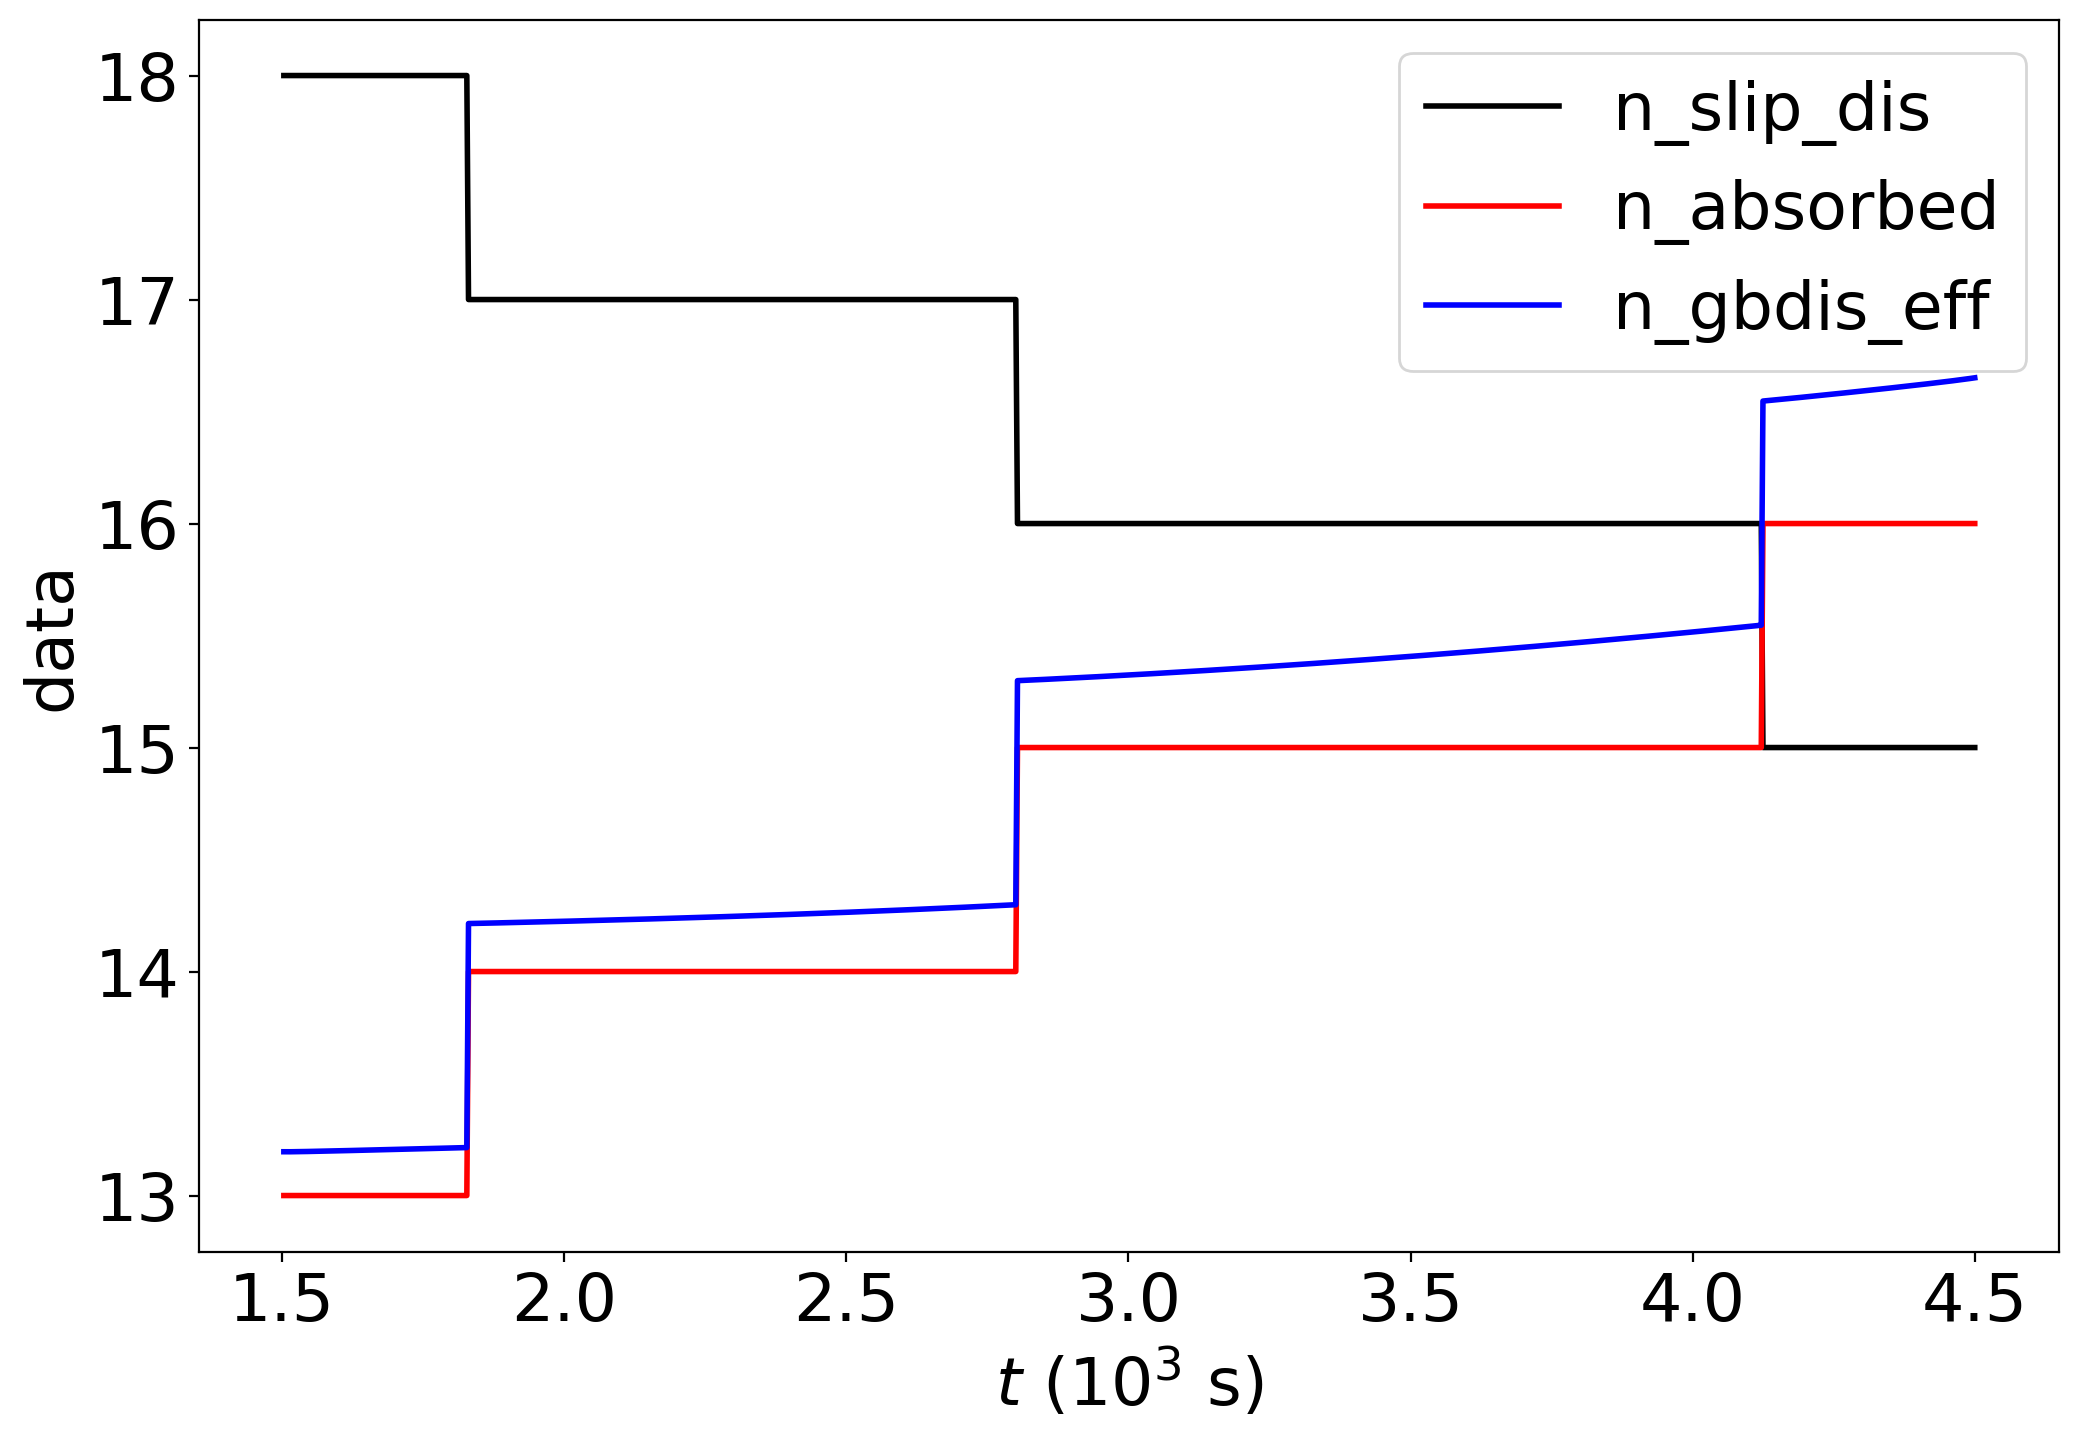

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 3.8602946844434894e-14, Nslip: 15.0, Ngb_eff: 16.606215134703643
*** hvar, hist *** 0.0 (array([100]), array([14.5, 15.5]))
Data file with H=30.0, L=0.1, T=800.0, tau0=150.0, n=24


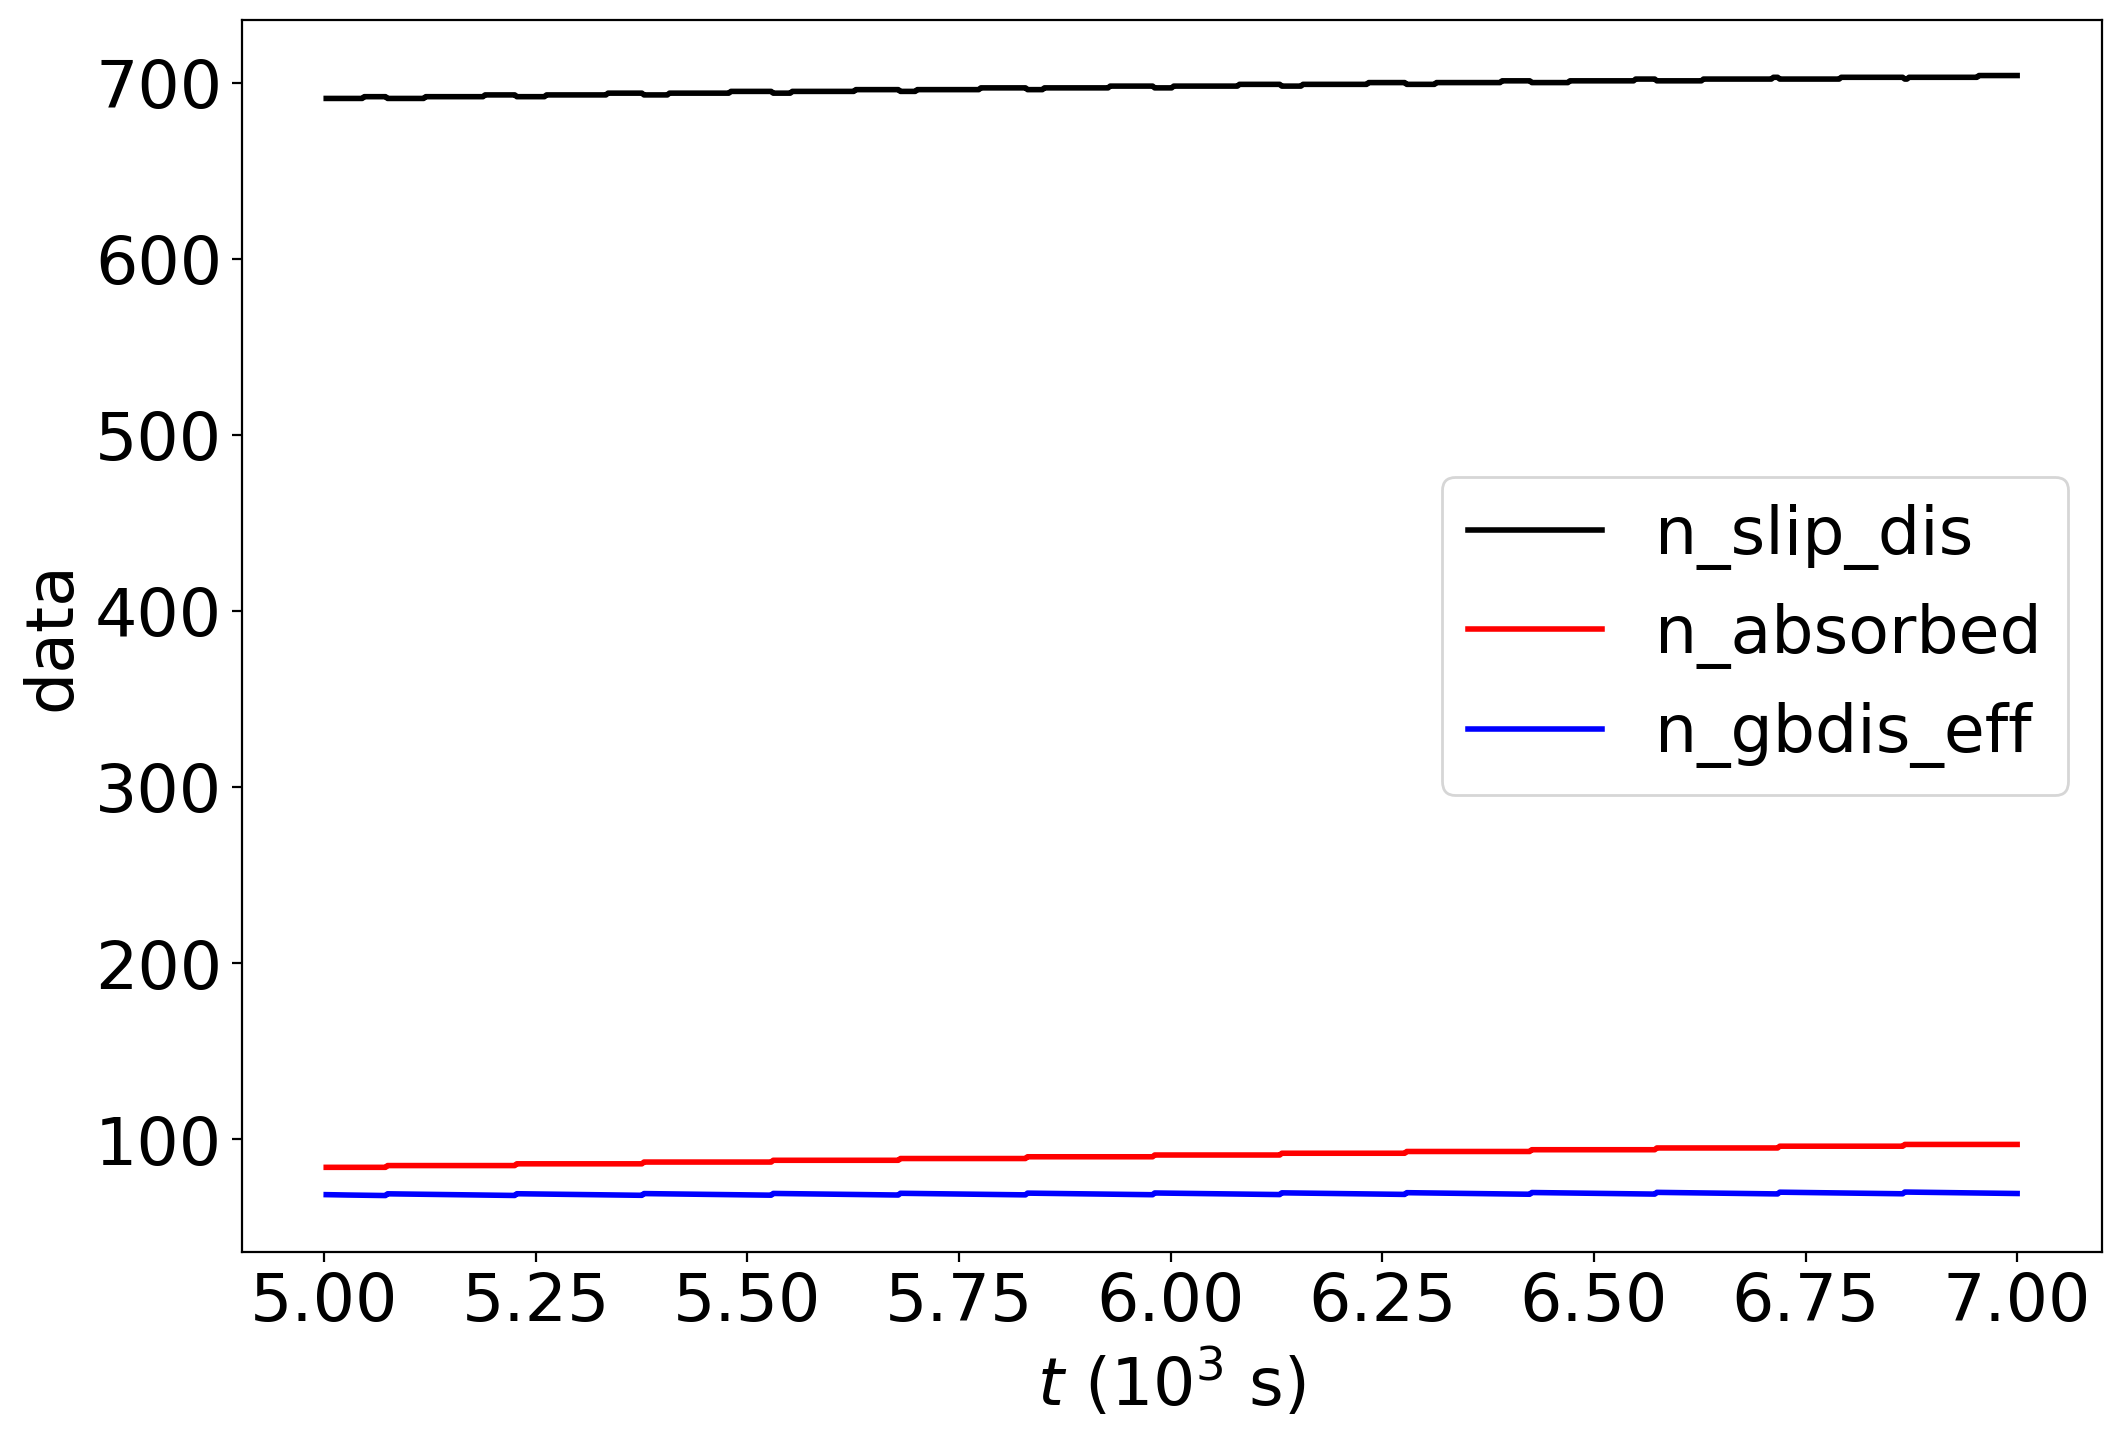

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.5727443086573125e-11, Nslip: 703.01, Ngb_eff: 69.44843319351419
*** hvar, hist *** 2.0 (array([18, 63, 19]), array([702.        , 702.66666667, 703.33333333, 704.        ]))
Data file with H=30.0, L=0.3, T=800.0, tau0=150.0, n=74


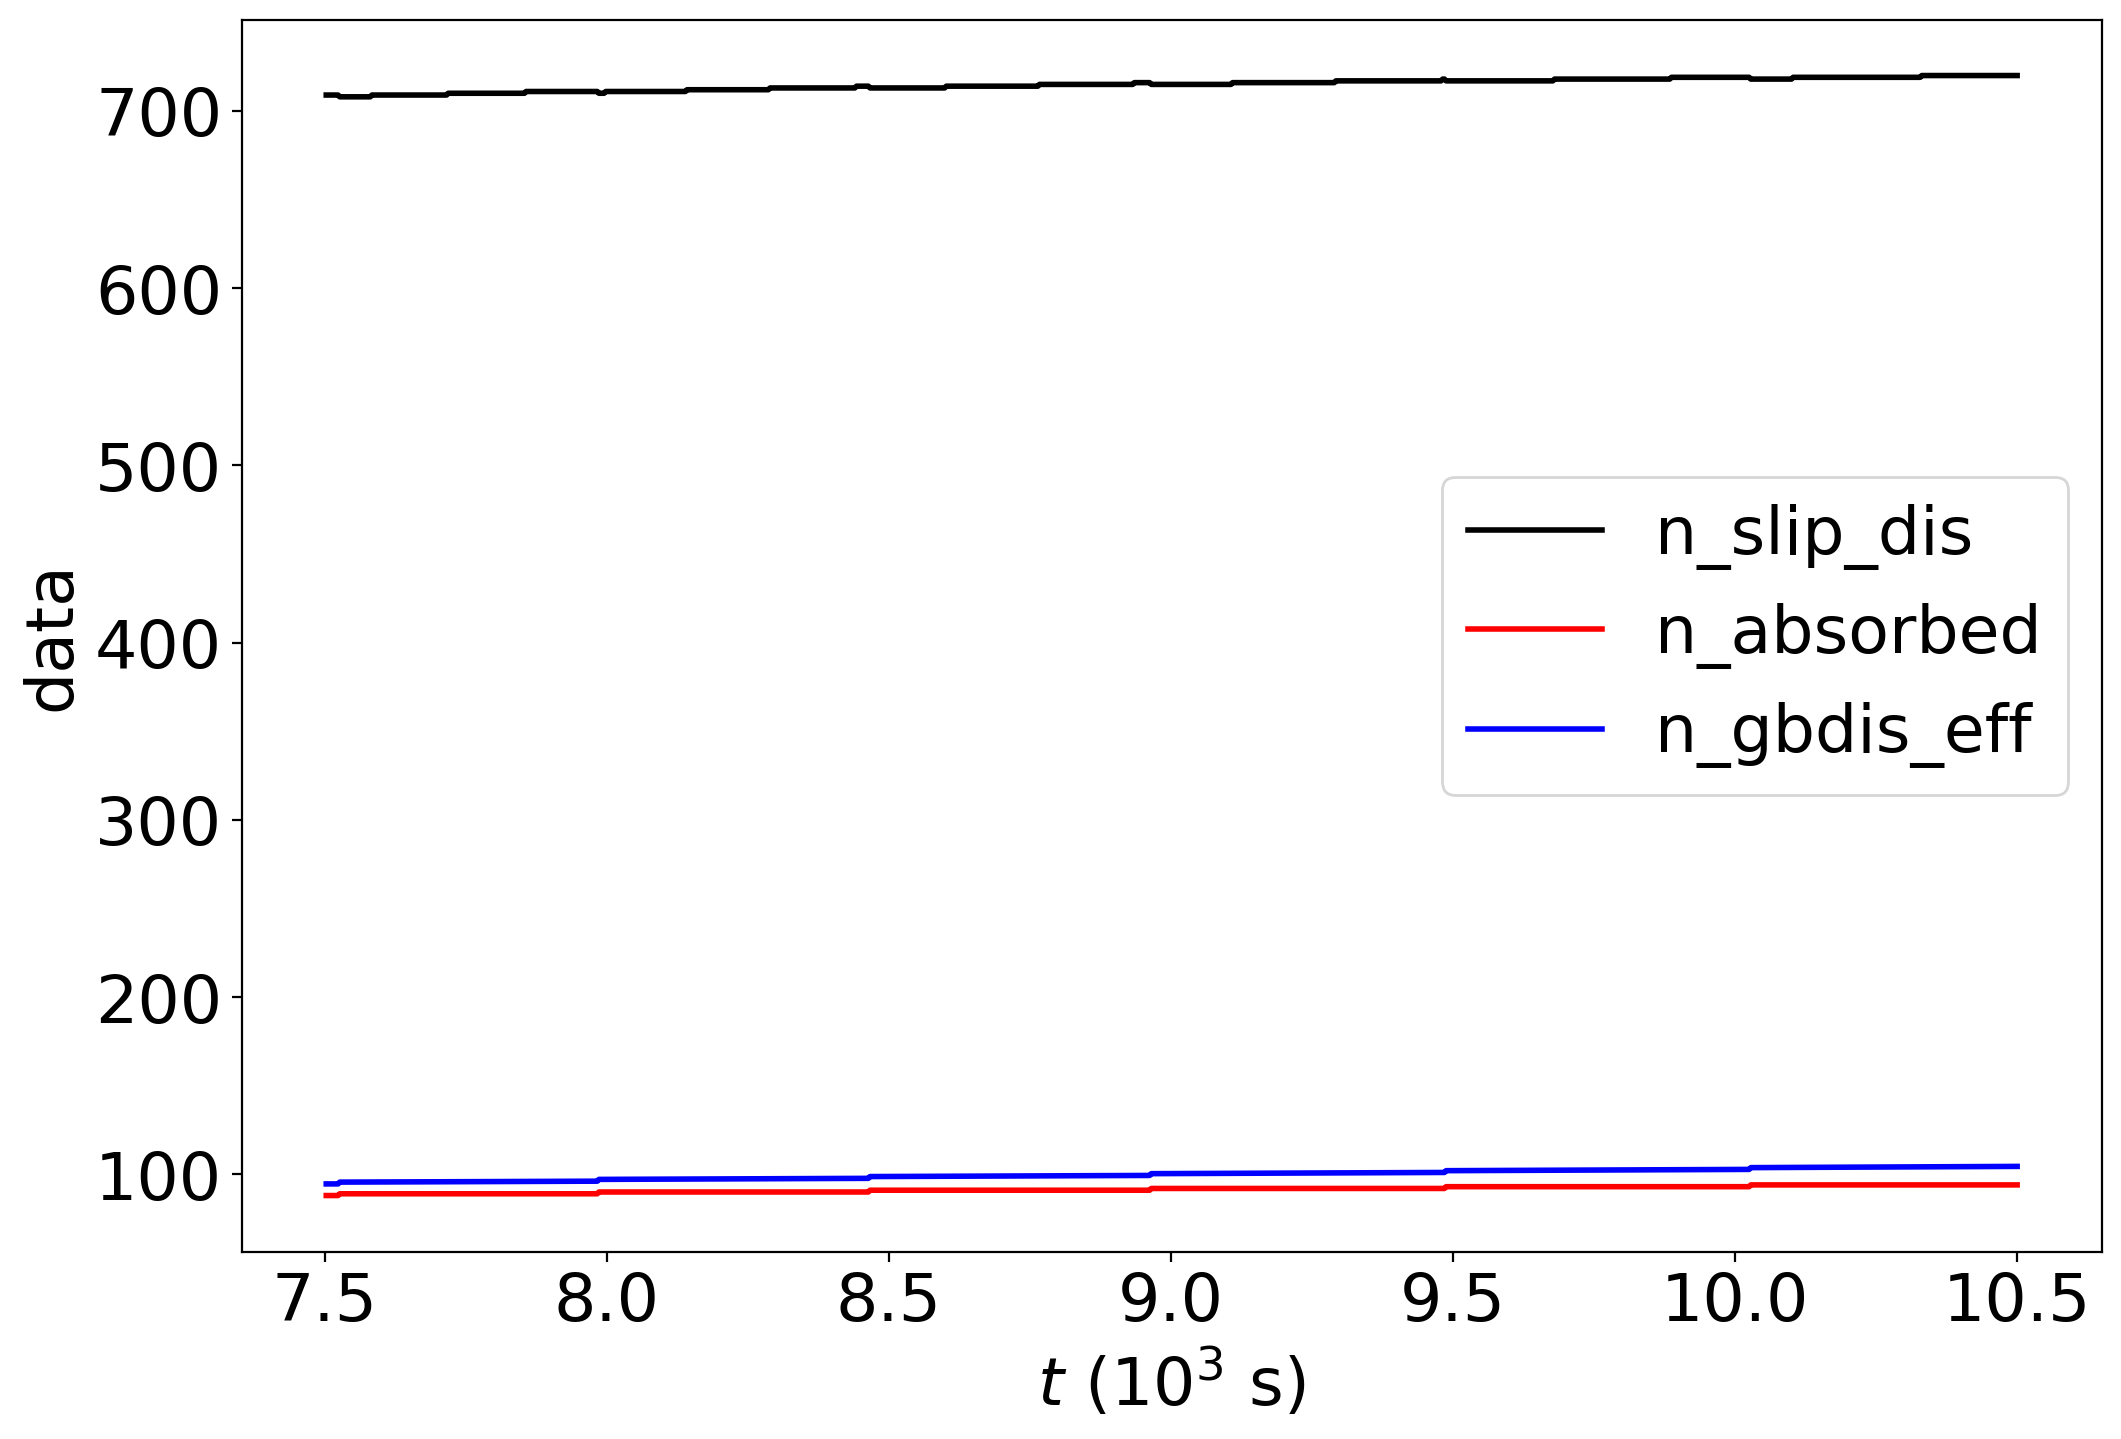

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.089240914756375e-12, Nslip: 719.57, Ngb_eff: 104.21014501897038
*** hvar, hist *** 1.0 (array([43, 57]), array([719. , 719.5, 720. ]))
Data file with H=3.0, L=0.1, T=800.0, tau0=150.0, n=24


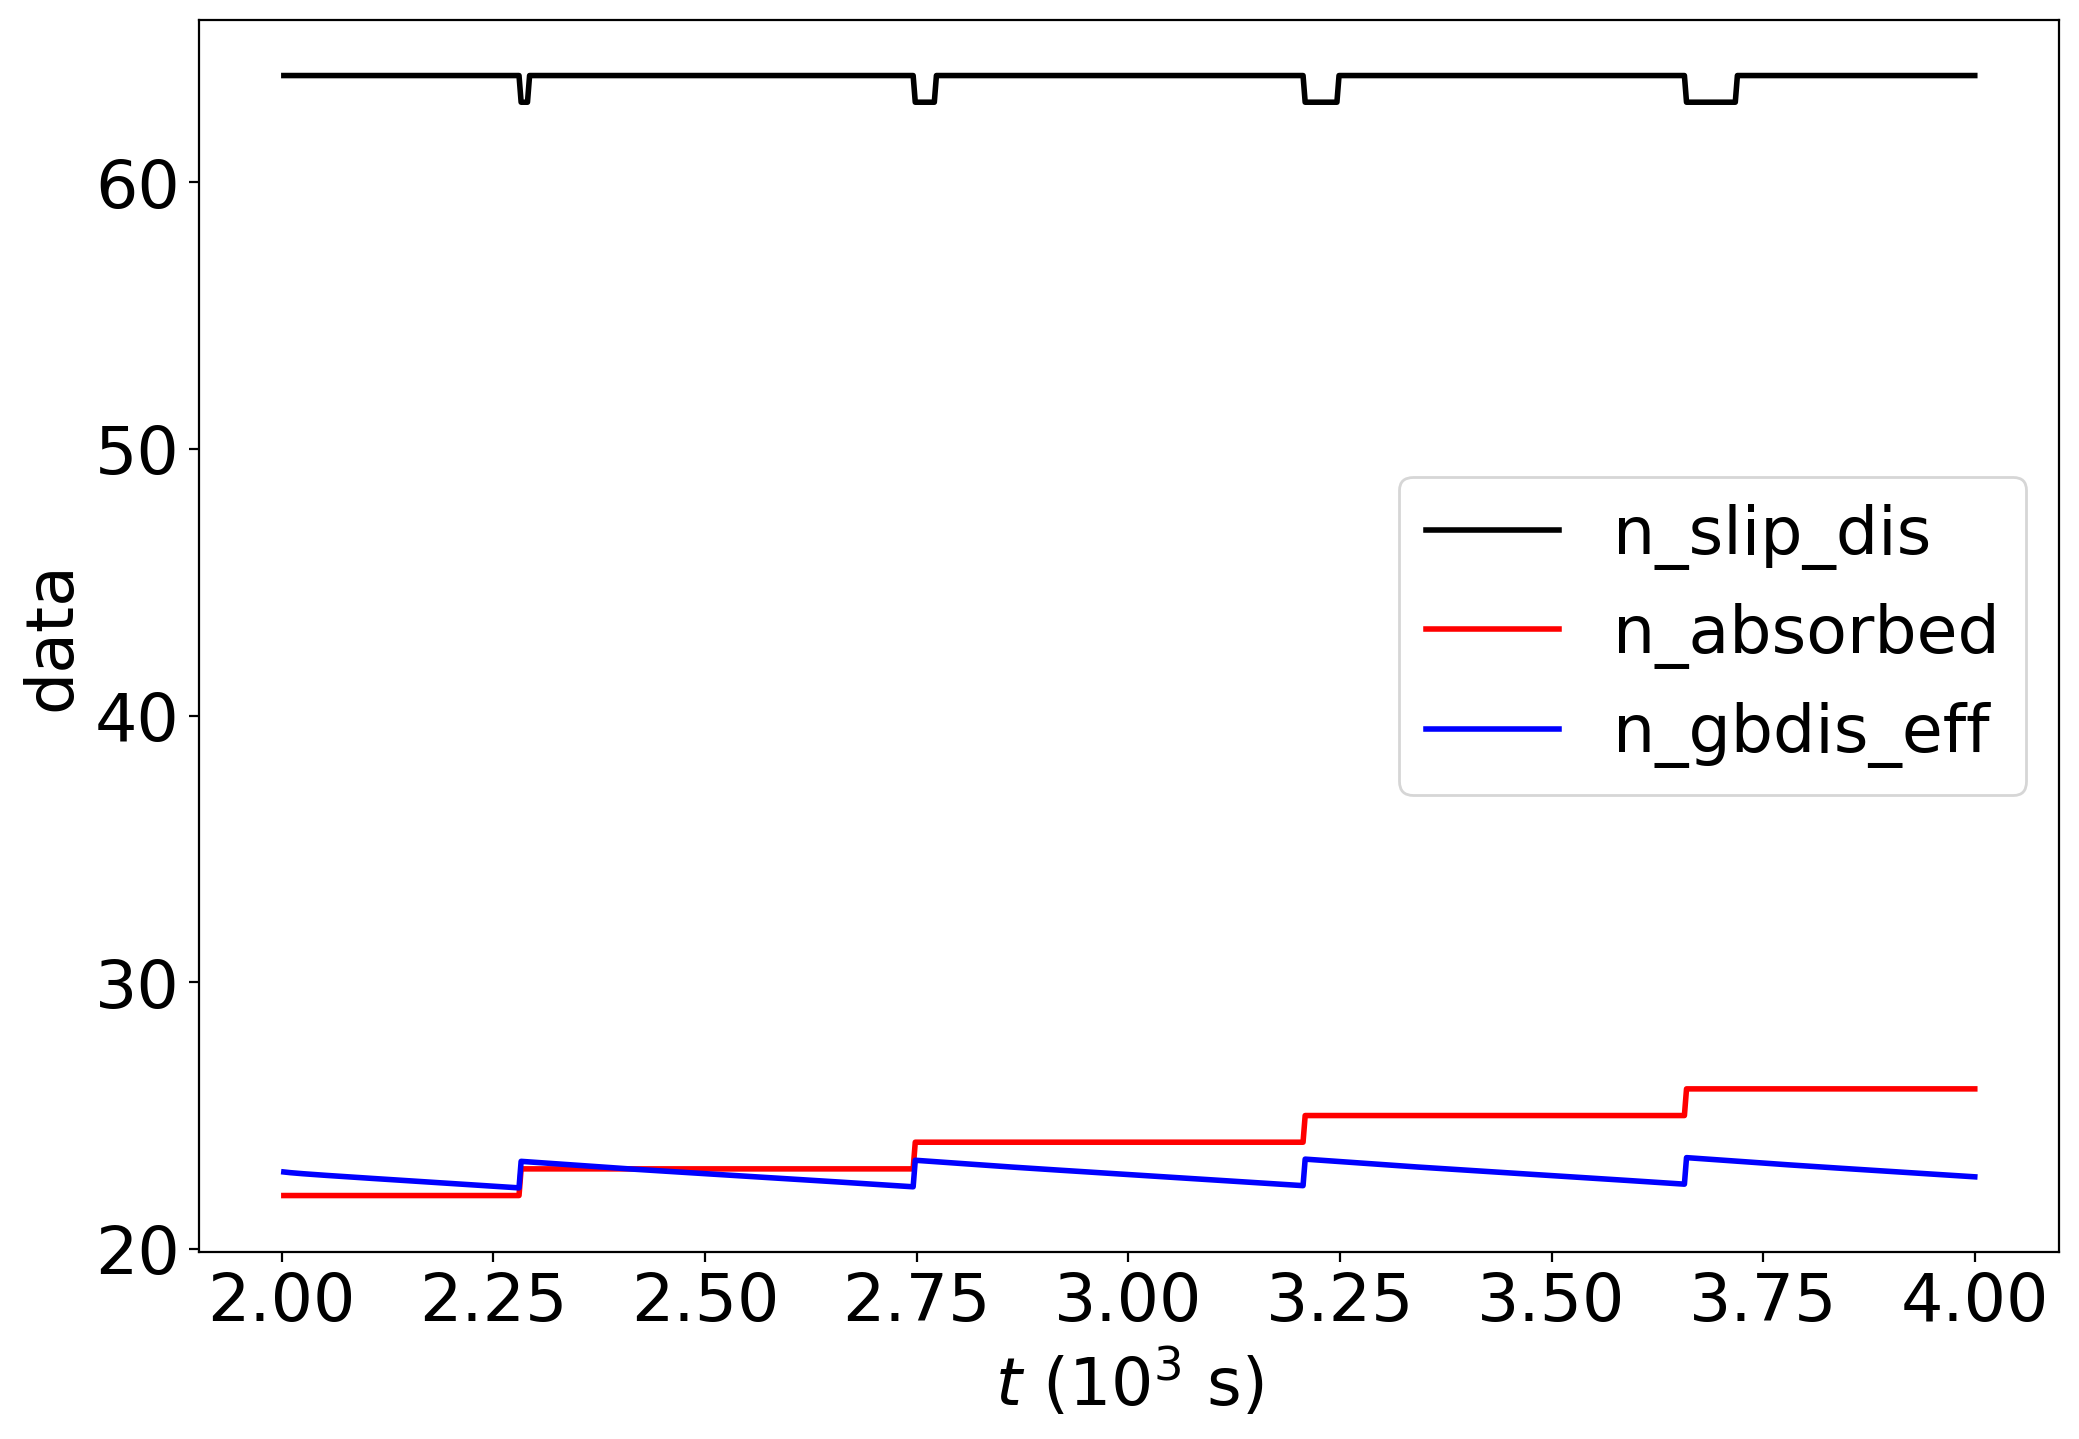

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 5.822668364771747e-12, Nslip: 64.0, Ngb_eff: 22.954731232289205
*** hvar, hist *** 0.0 (array([100]), array([63.5, 64.5]))
Data file with H=3.0, L=0.3, T=800.0, tau0=150.0, n=74


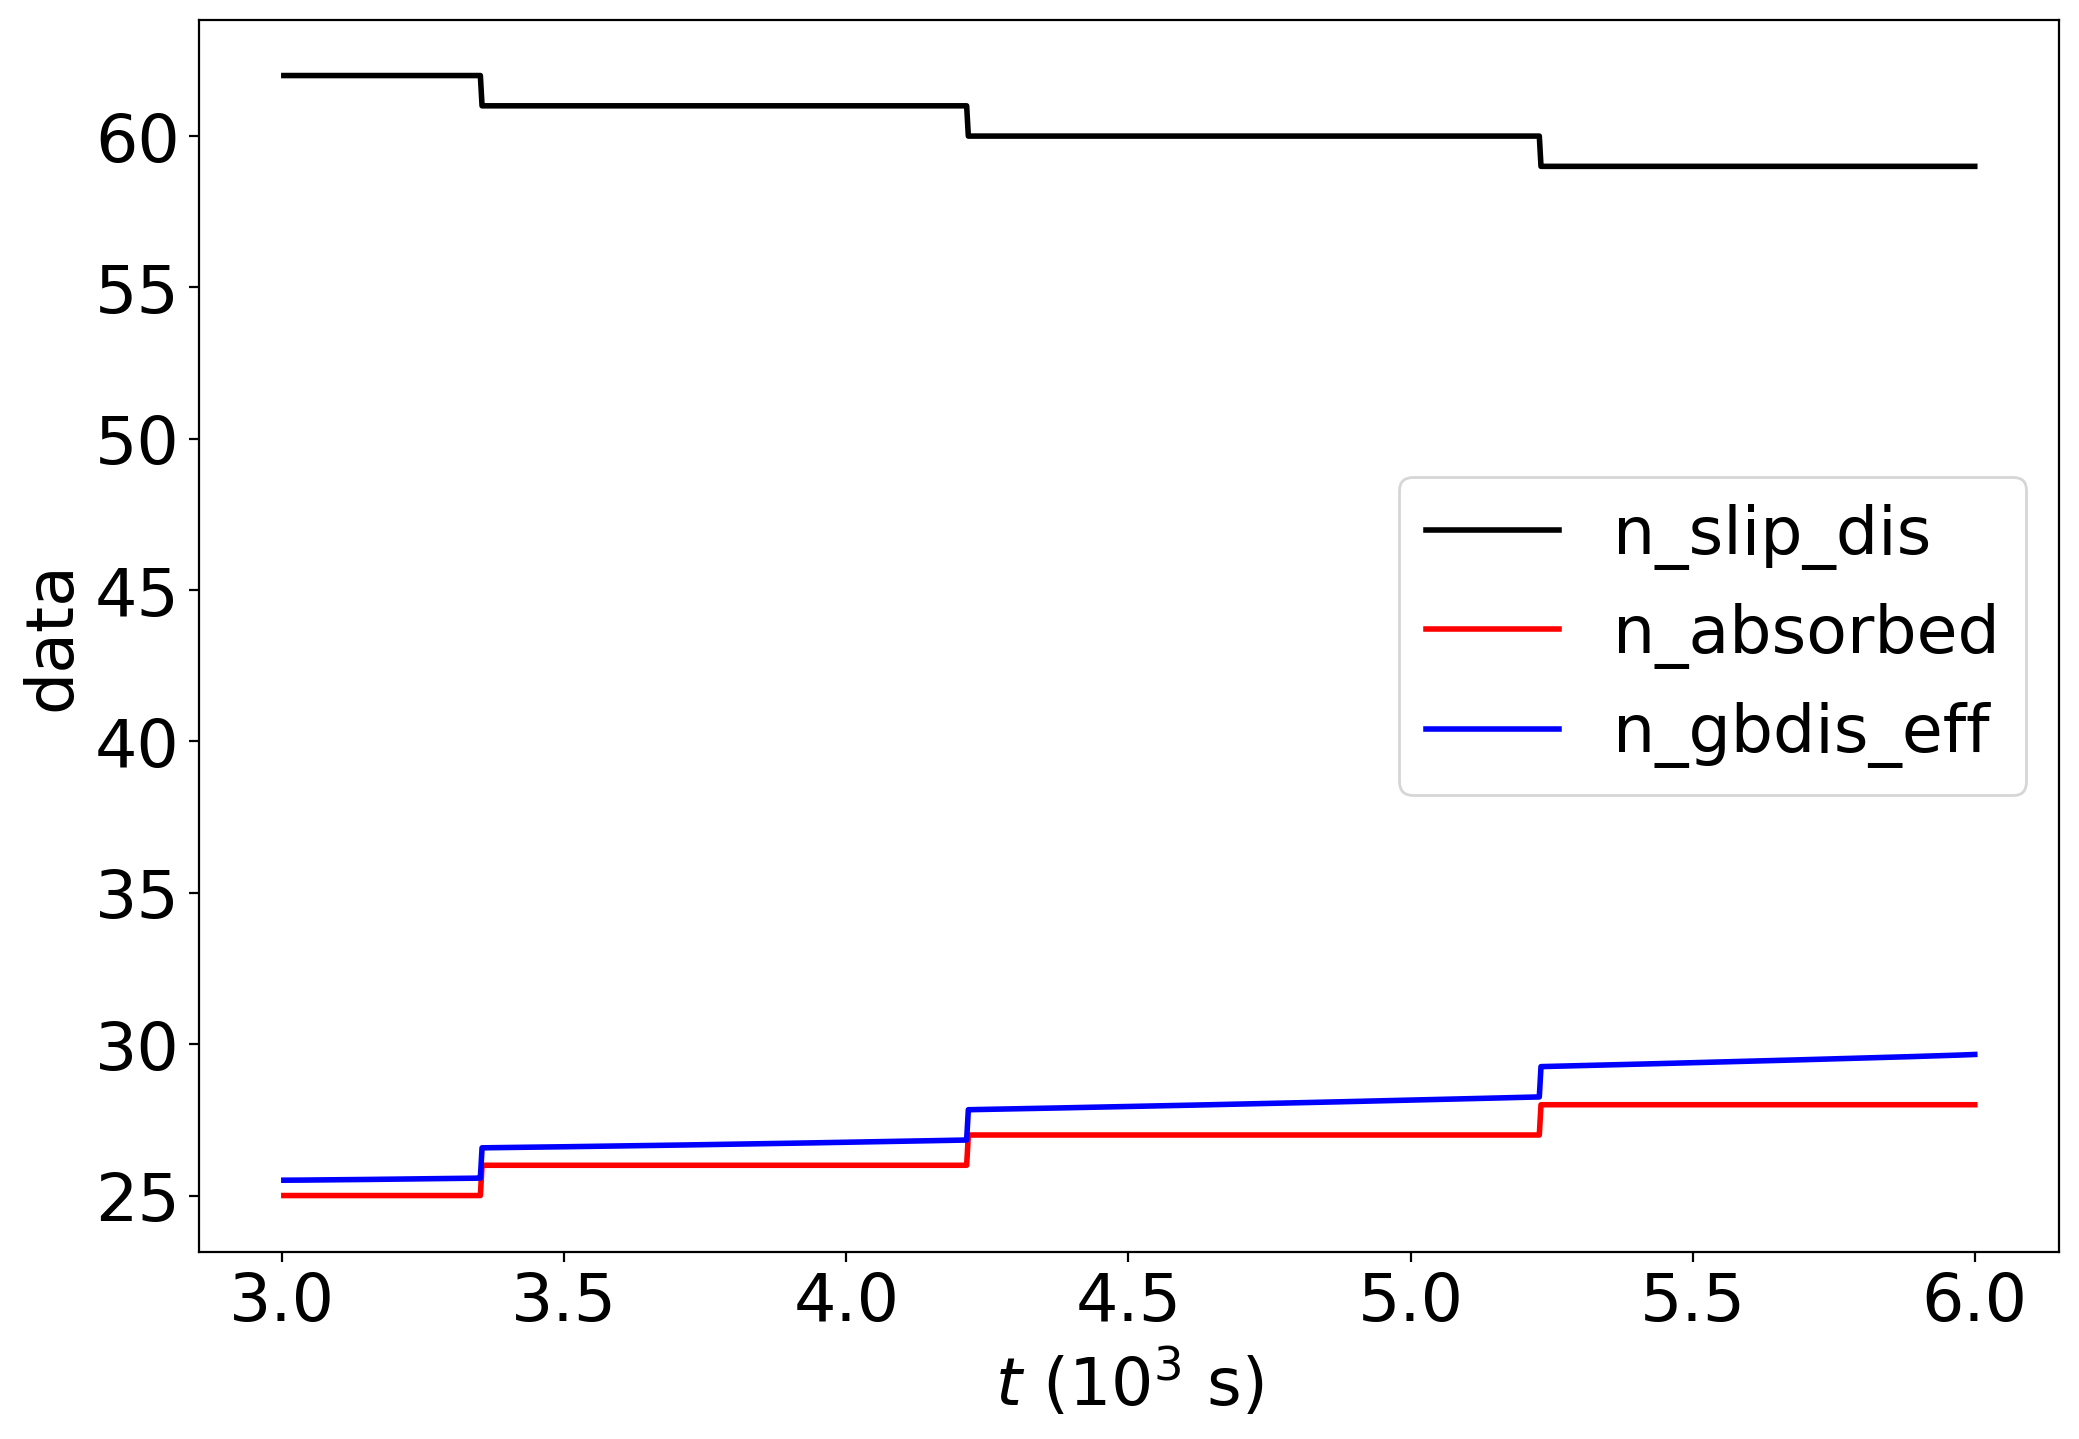

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -4.331127507839485e-14, Nslip: 59.0, Ngb_eff: 29.57097042364346
*** hvar, hist *** 0.0 (array([100]), array([58.5, 59.5]))
Data file with H=0.3, L=0.1, T=800.0, tau0=150.0, n=24


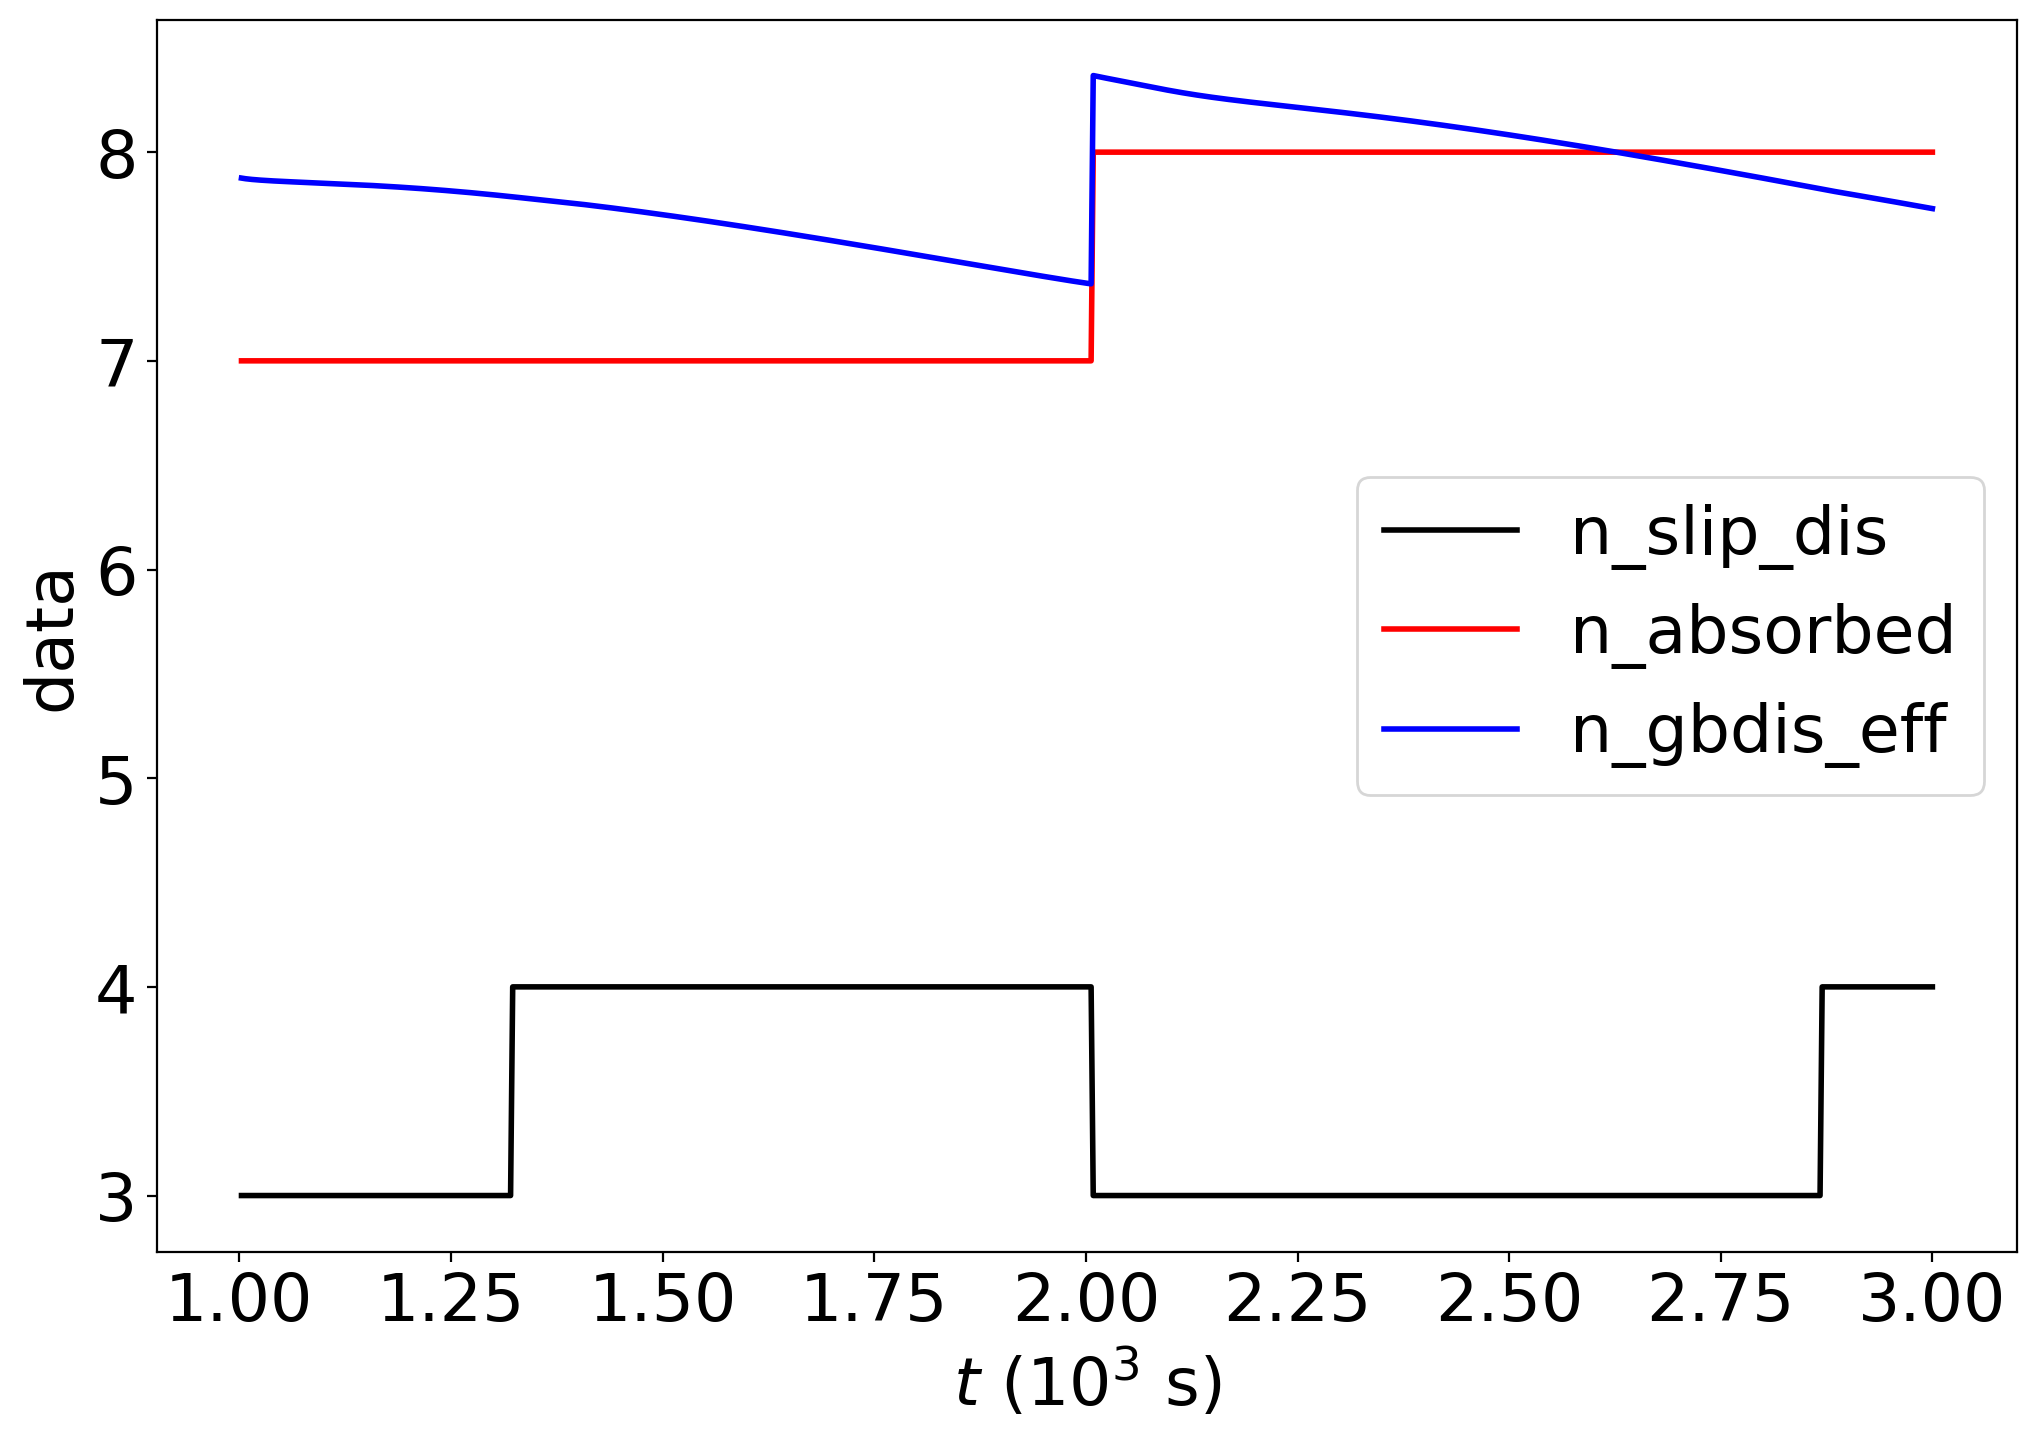

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 5.878985659322214e-12, Nslip: 3.53, Ngb_eff: 7.81931029359494
*** hvar, hist *** 1.0 (array([47, 53]), array([3. , 3.5, 4. ]))
Data file with H=0.3, L=0.3, T=800.0, tau0=150.0, n=74


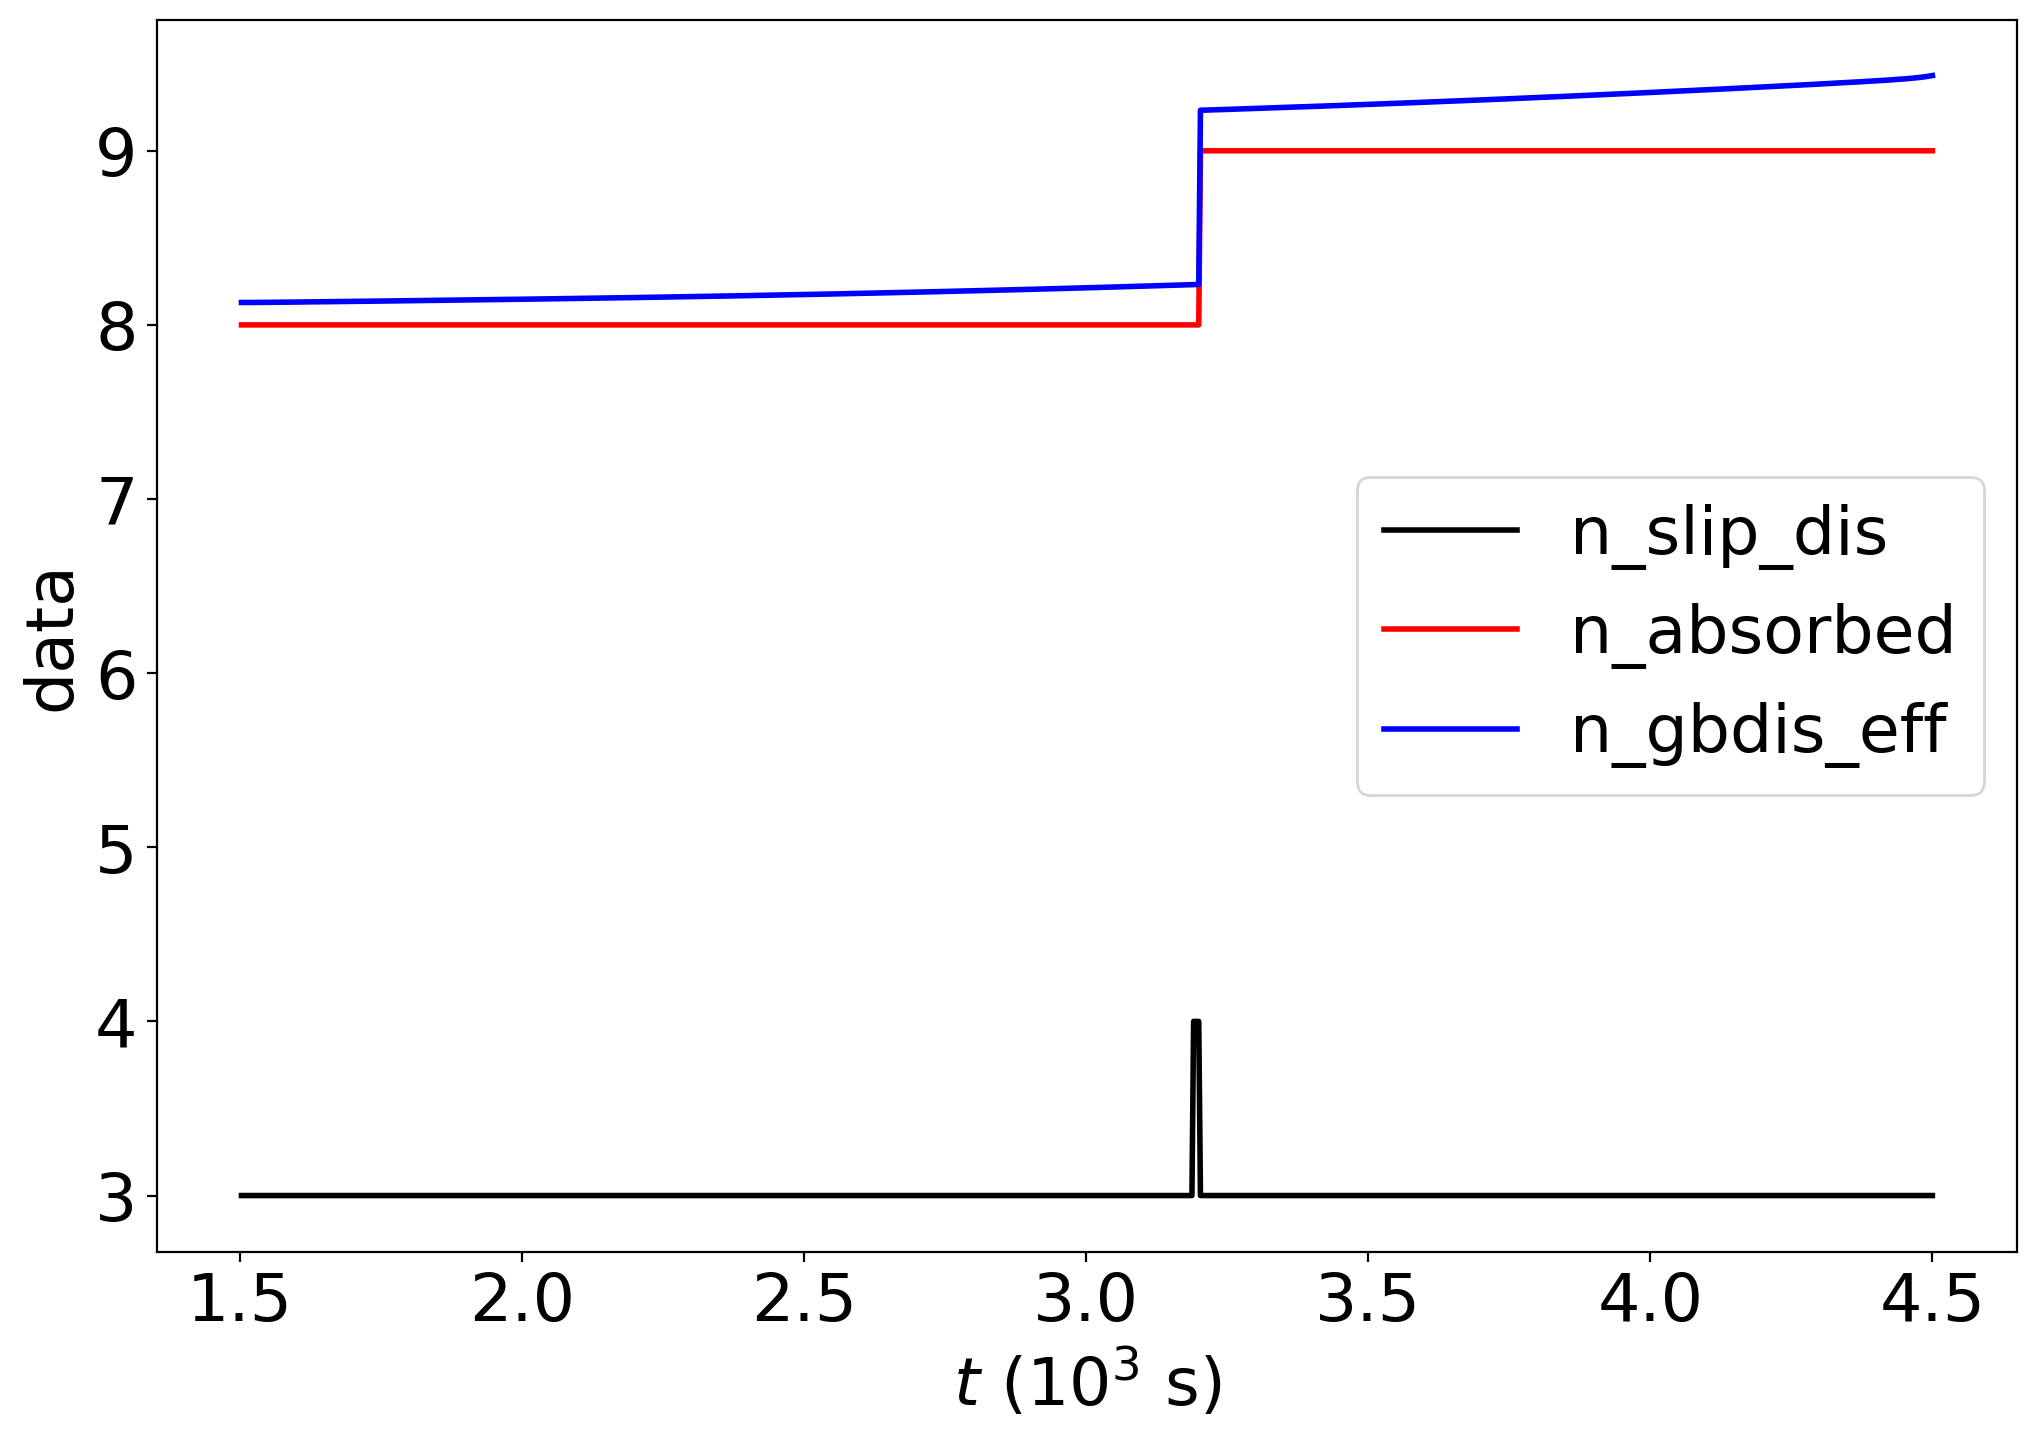

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.0040946111189445e-13, Nslip: 3.0, Ngb_eff: 9.393886677761758
*** hvar, hist *** 0.0 (array([100]), array([2.5, 3.5]))
Data file with H=60.0, L=0.1, T=800.0, tau0=150.0, n=24


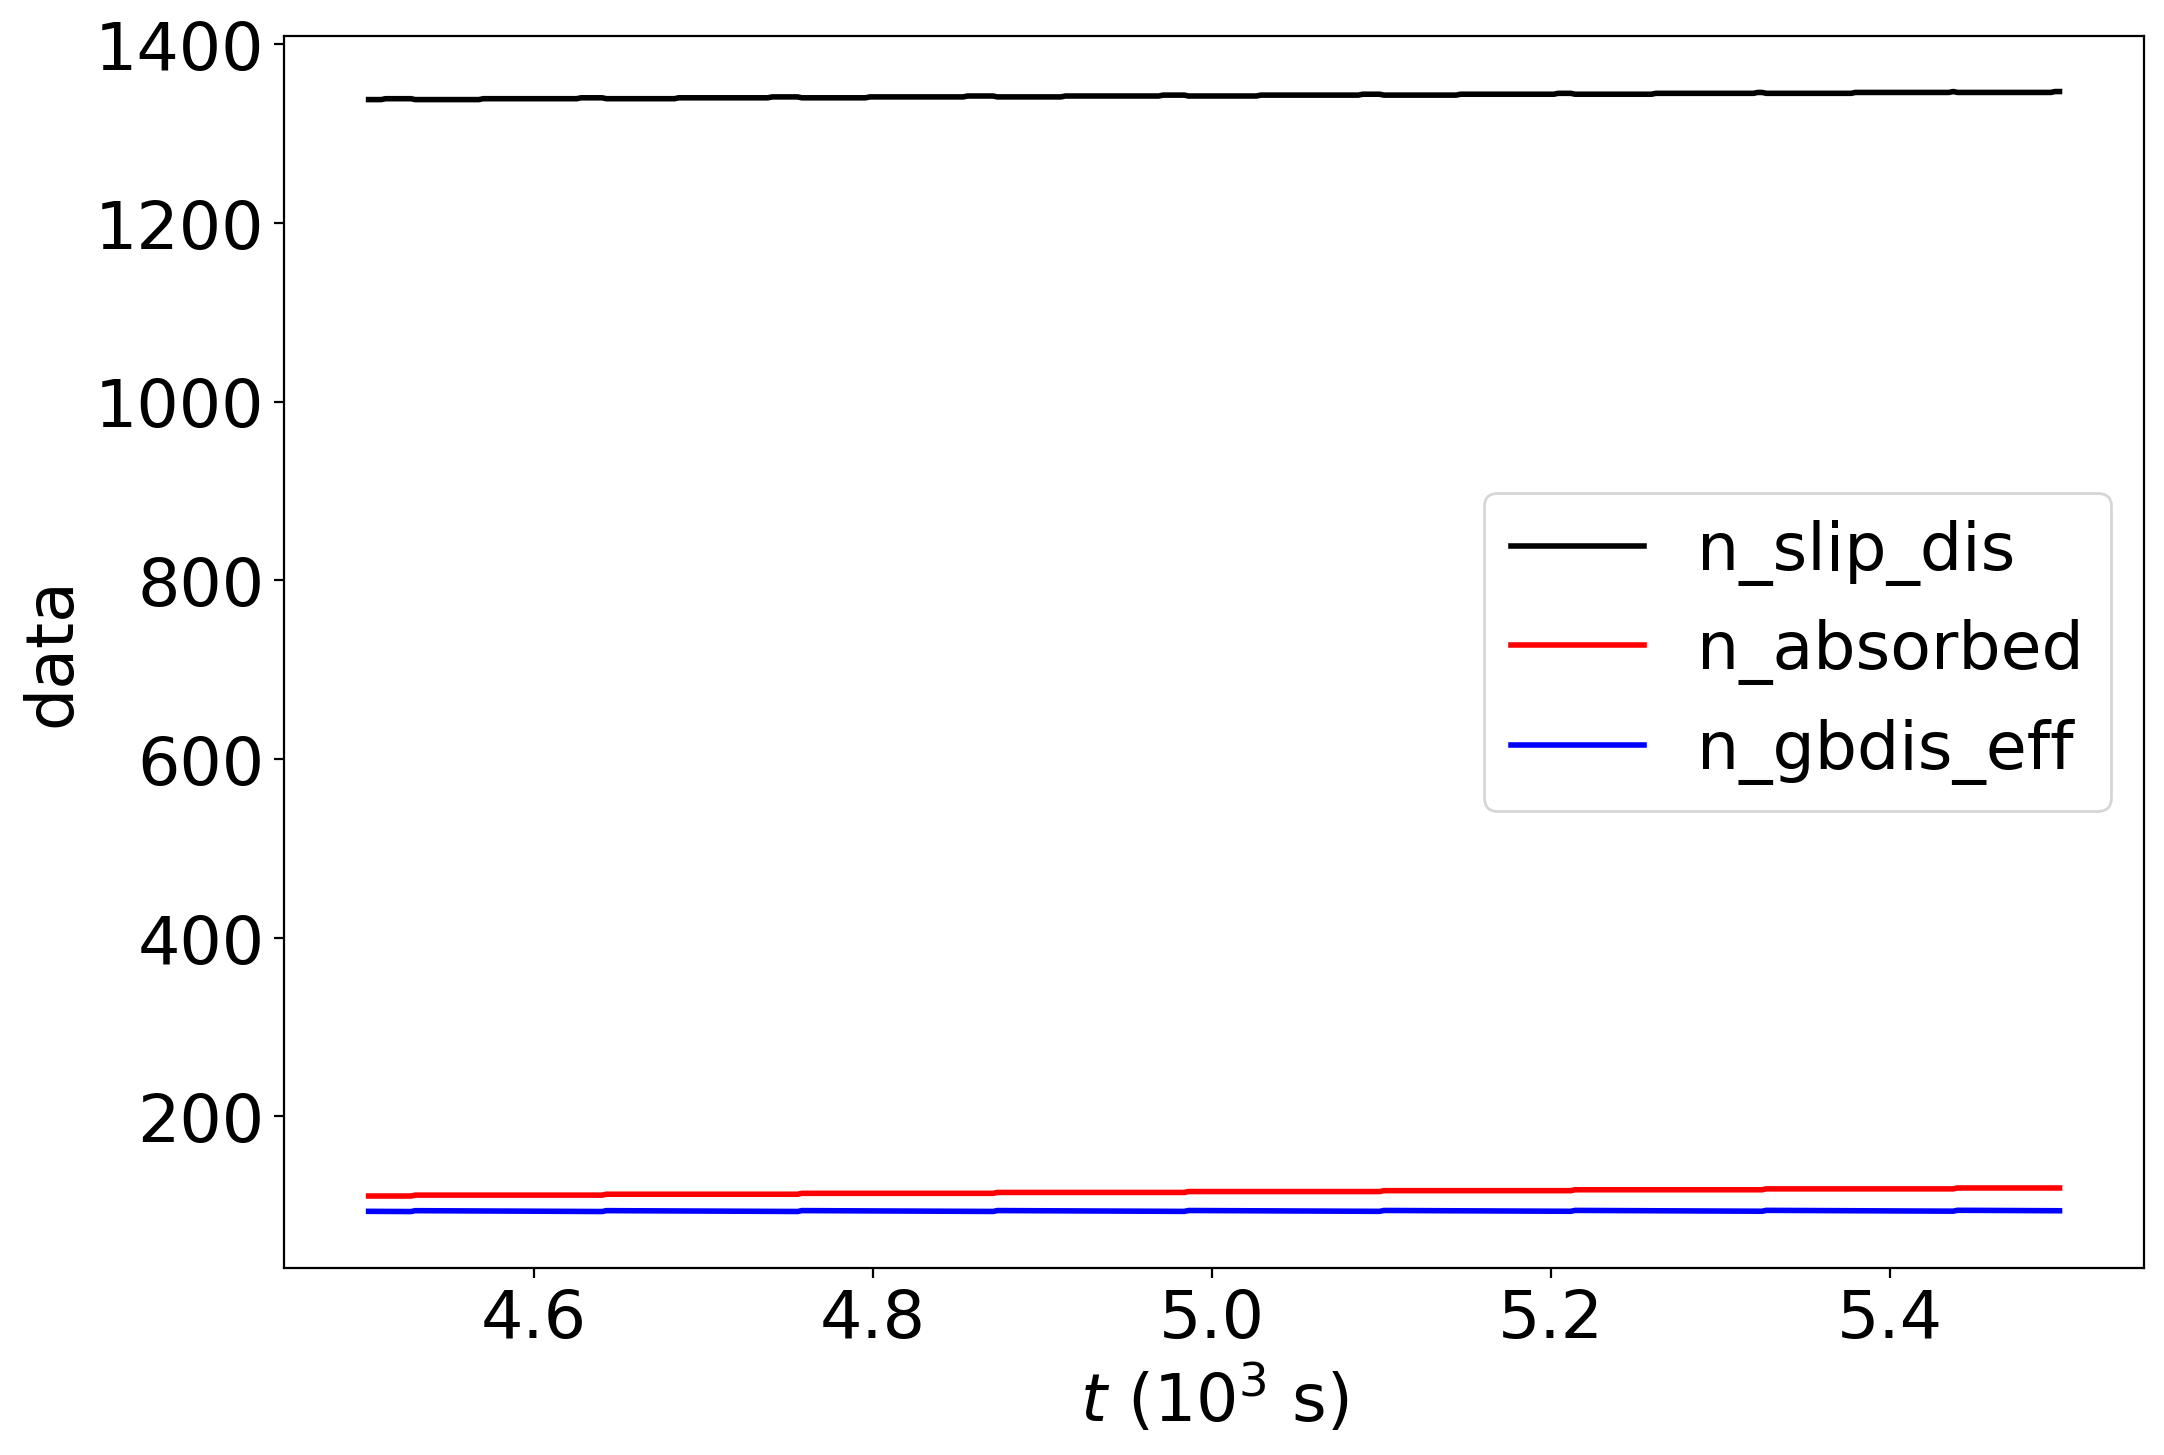

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 3.5020610491325466e-11, Nslip: 1345.5, Ngb_eff: 94.49349852246955
*** hvar, hist *** 3.0 (array([ 4, 45, 48,  3]), array([1344.  , 1344.75, 1345.5 , 1346.25, 1347.  ]))
Data file with H=60.0, L=0.3, T=800.0, tau0=150.0, n=74


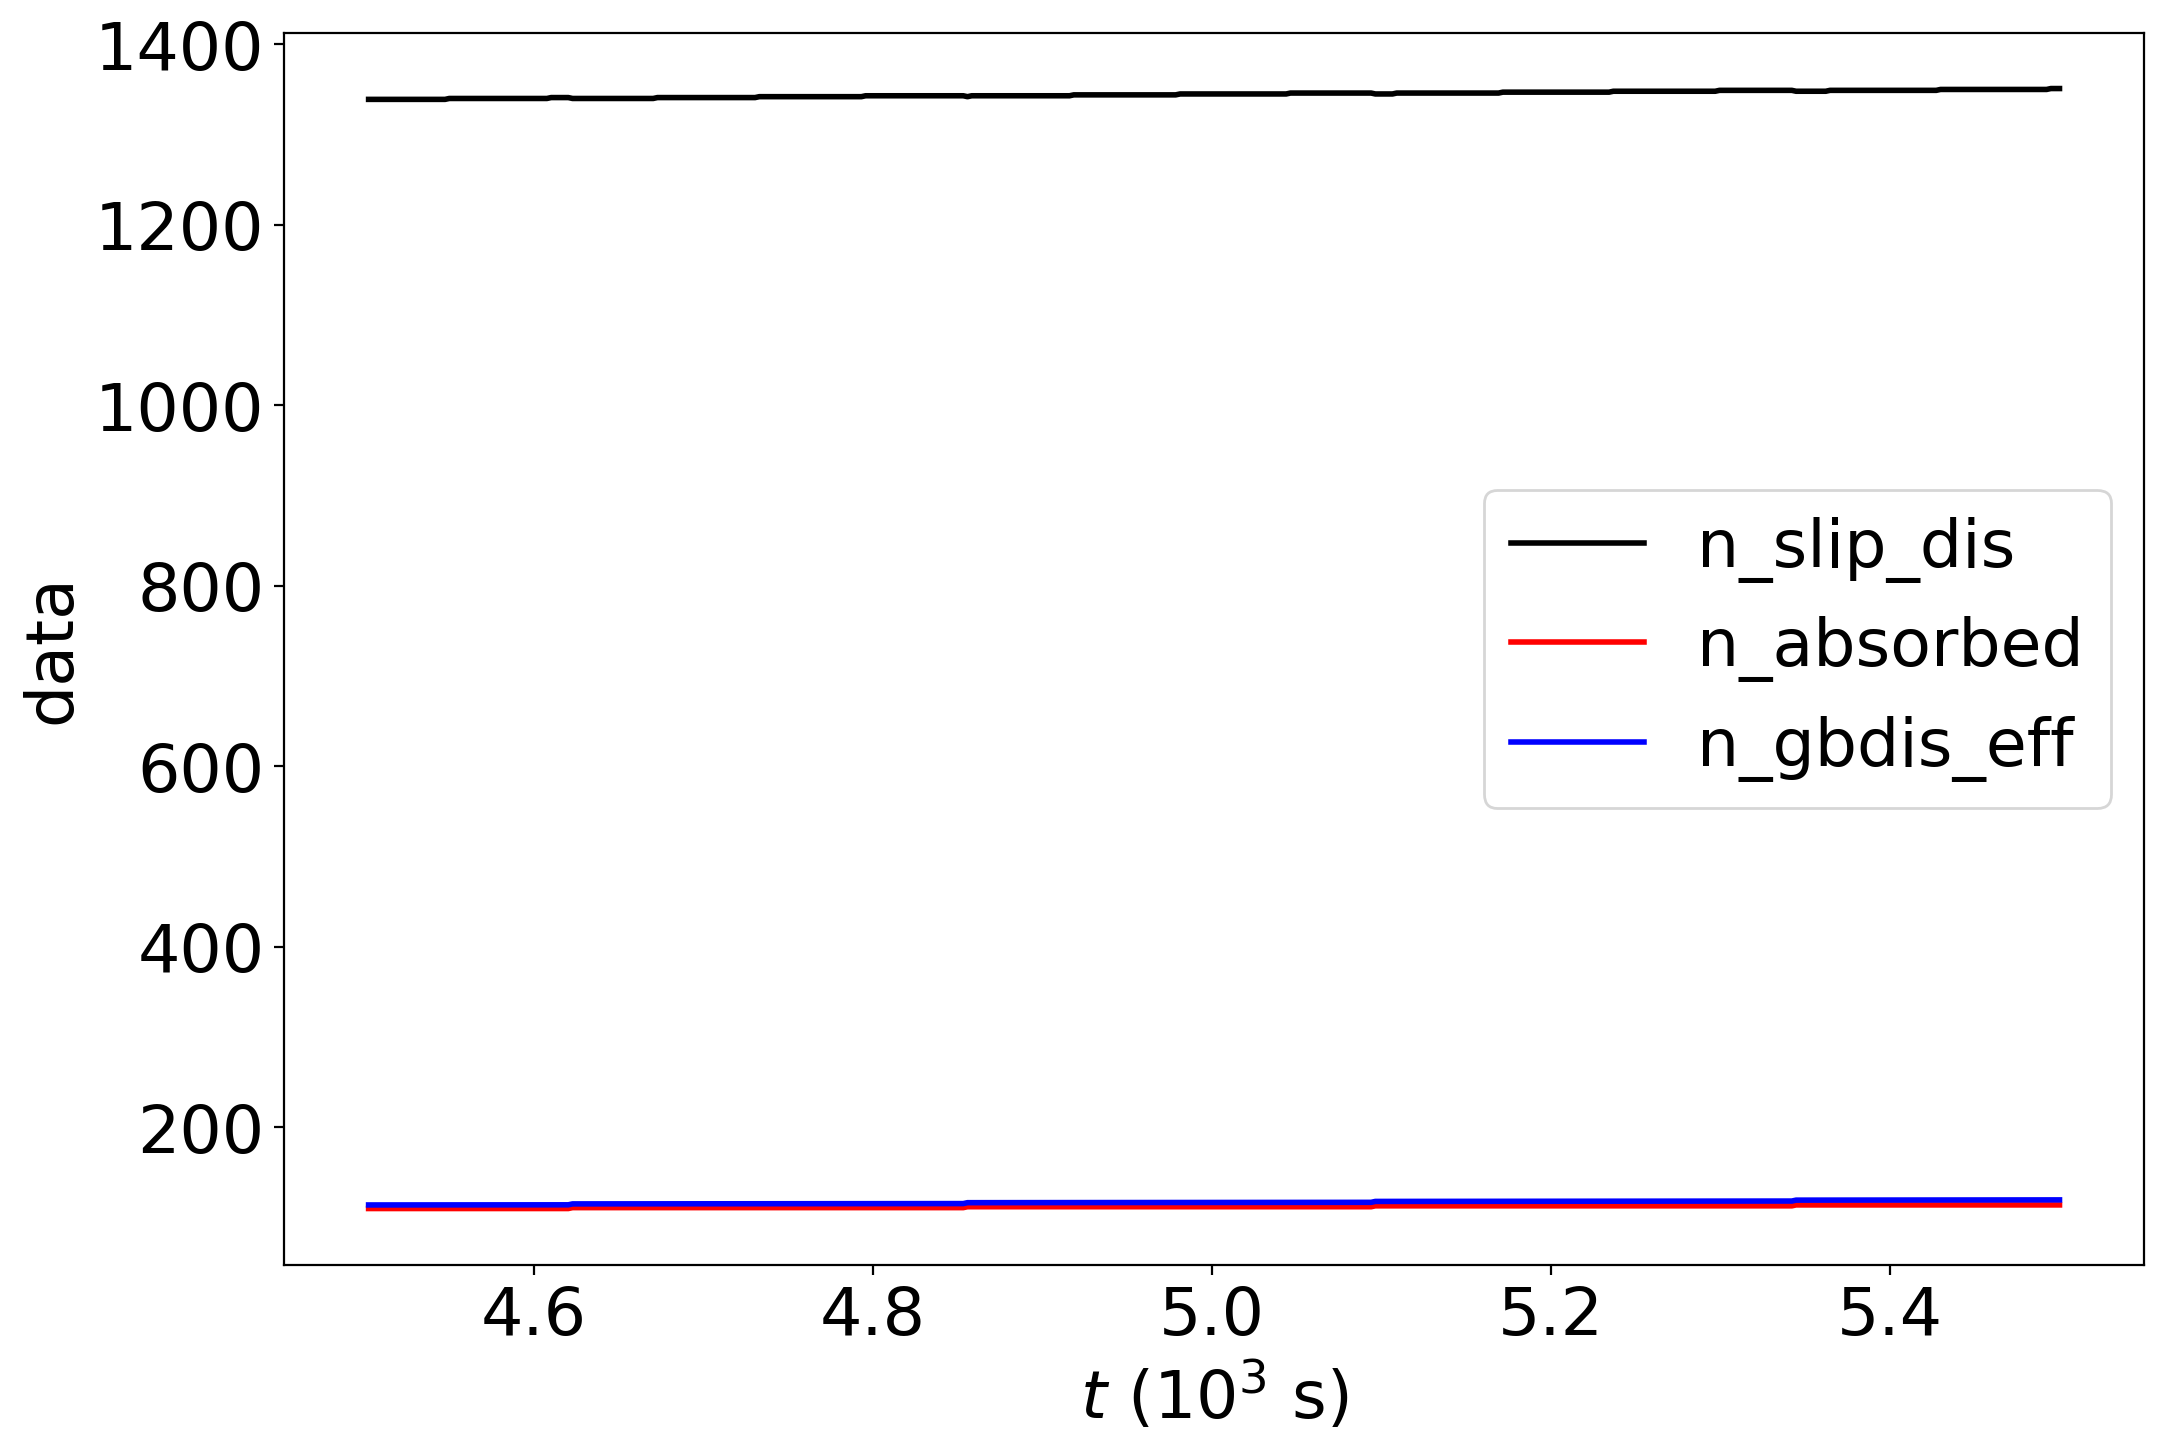

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 8.337952500235138e-12, Nslip: 1349.05, Ngb_eff: 119.00463338381054
*** hvar, hist *** 3.0 (array([27, 44, 26,  3]), array([1348.  , 1348.75, 1349.5 , 1350.25, 1351.  ]))
Data file with H=10.0, L=0.1, T=900.0, tau0=150.0, n=24


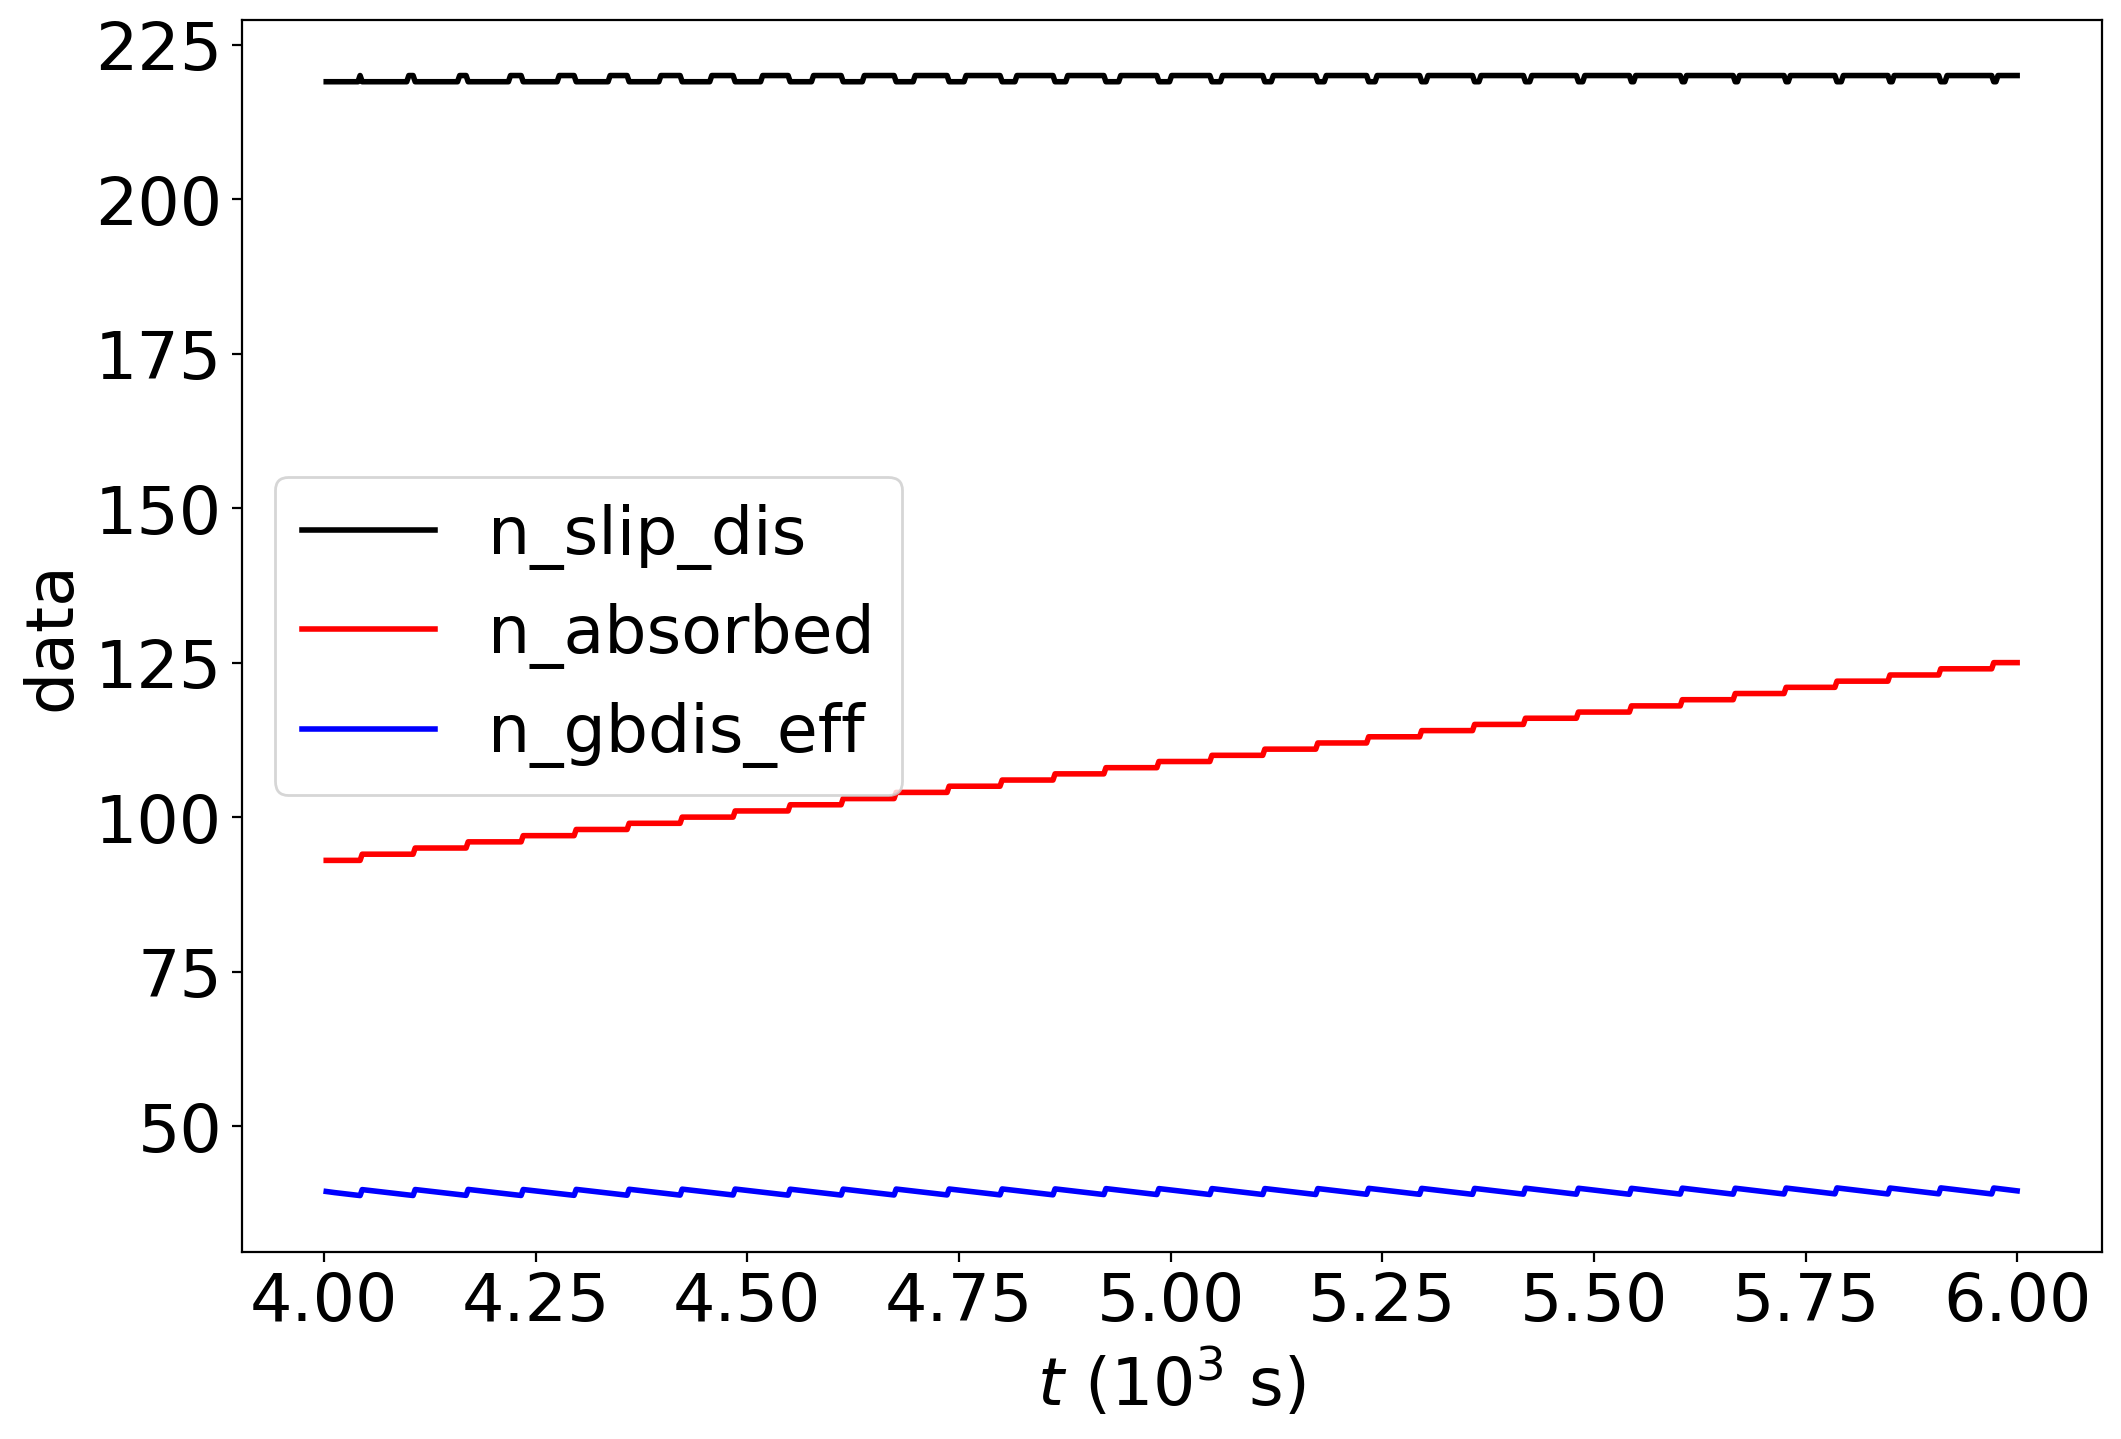

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 4.079988870530961e-11, Nslip: 219.9, Ngb_eff: 39.50671270720391
*** hvar, hist *** 1.0 (array([10, 90]), array([219. , 219.5, 220. ]))
Data file with H=10.0, L=0.3, T=900.0, tau0=150.0, n=74


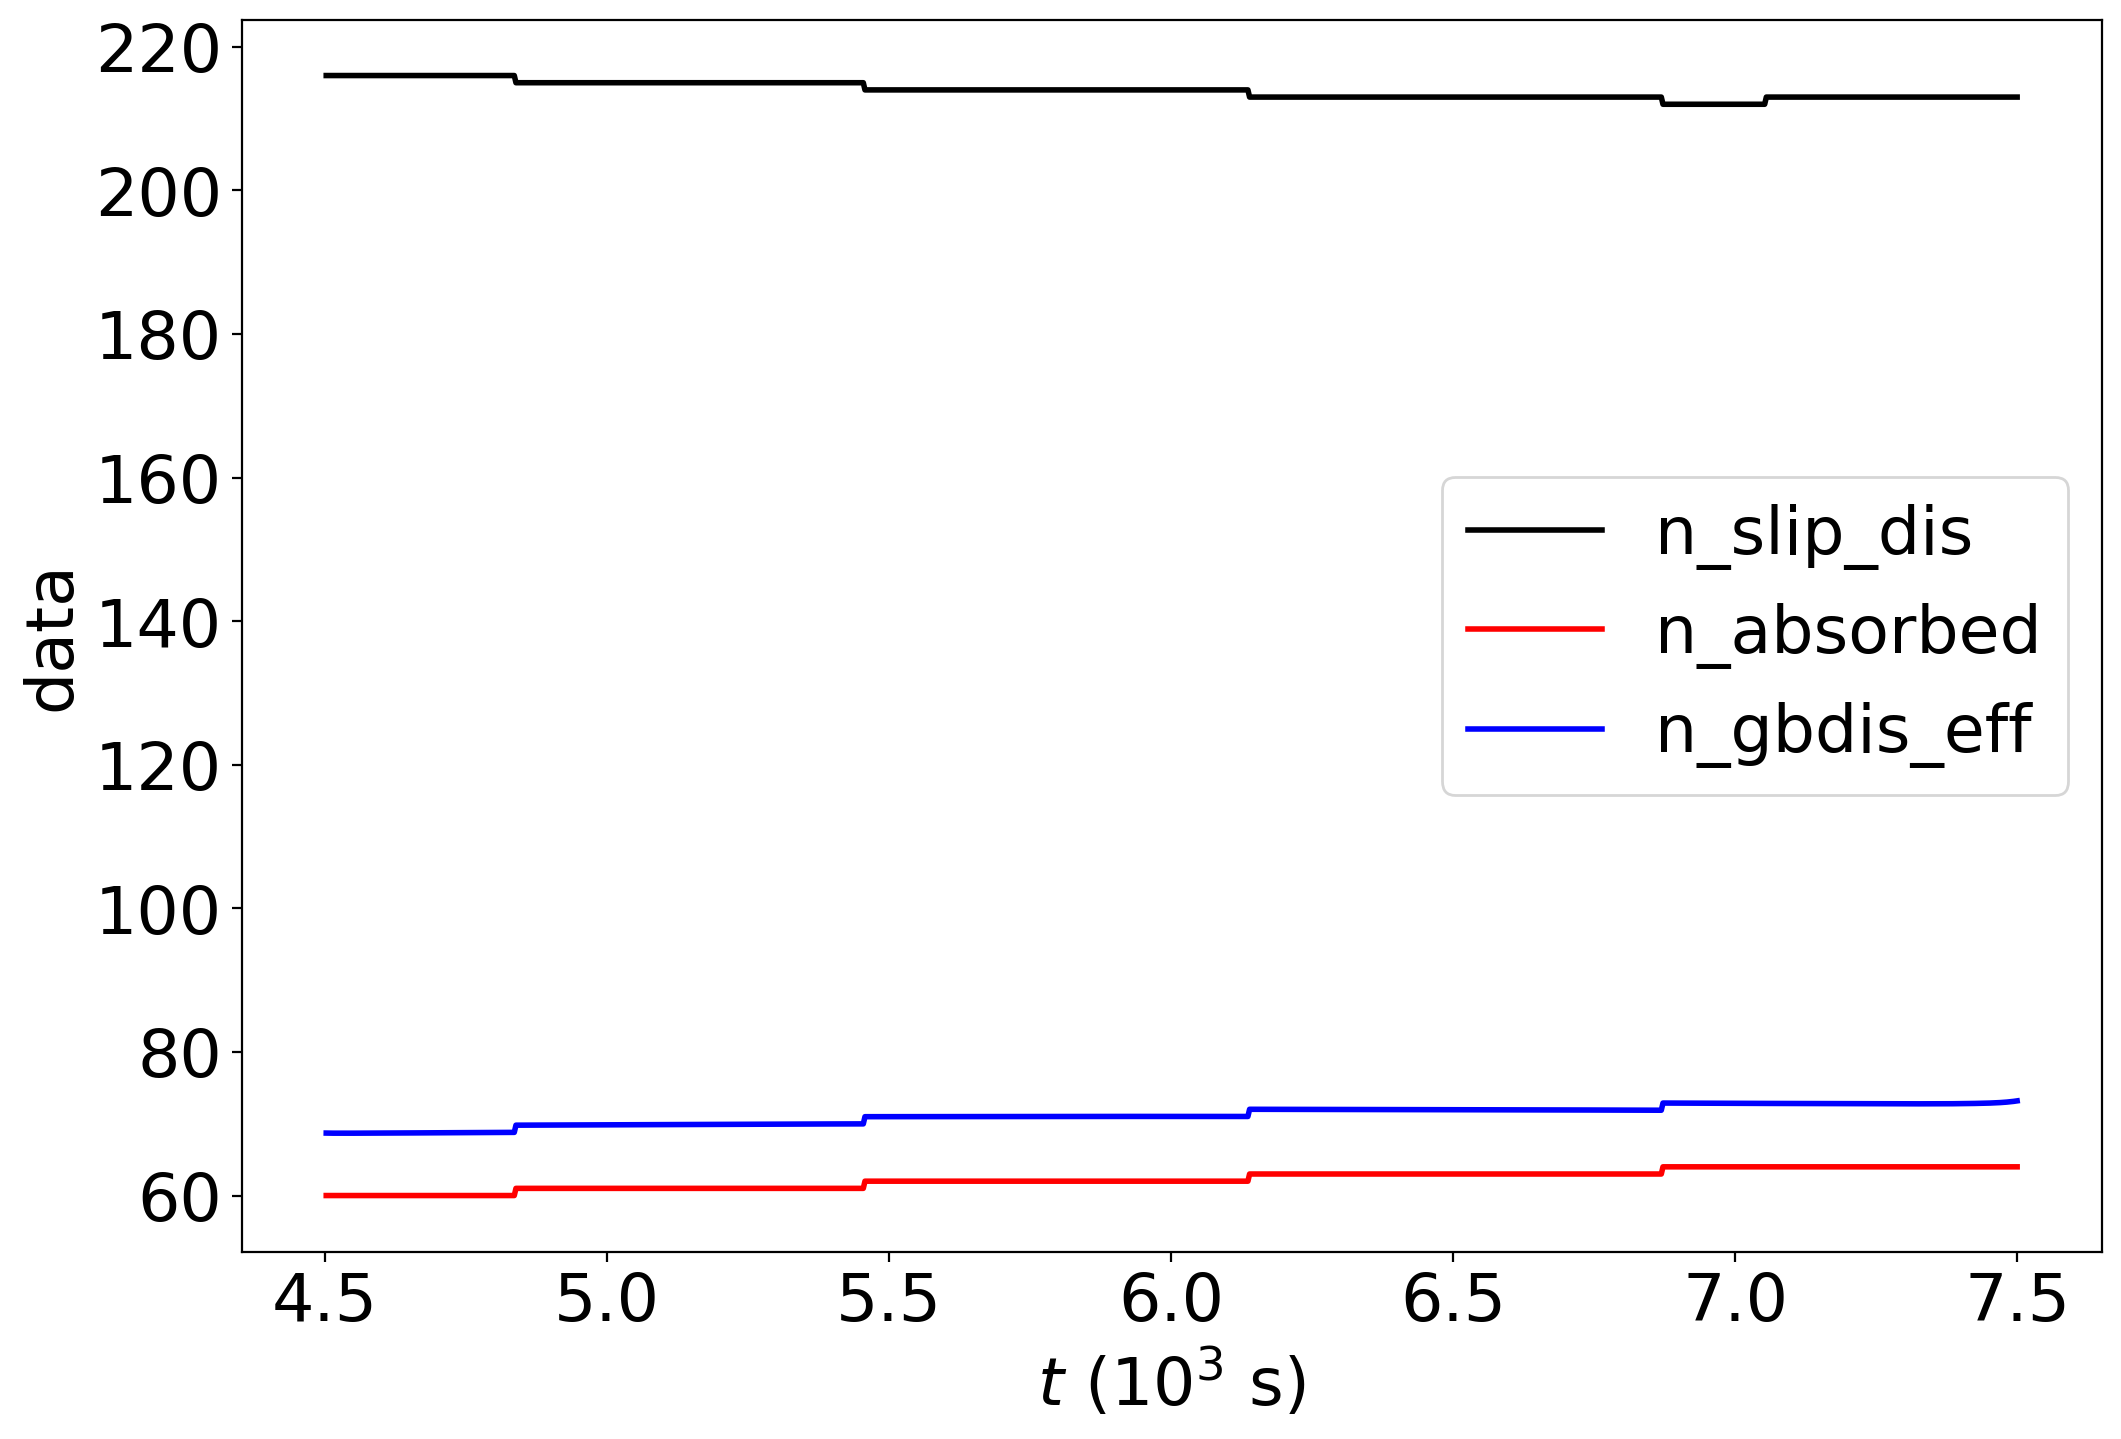

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 6.268497571162684e-13, Nslip: 213.0, Ngb_eff: 72.82804861639359
*** hvar, hist *** 0.0 (array([100]), array([212.5, 213.5]))
Data file with H=1.0, L=0.1, T=900.0, tau0=150.0, n=24


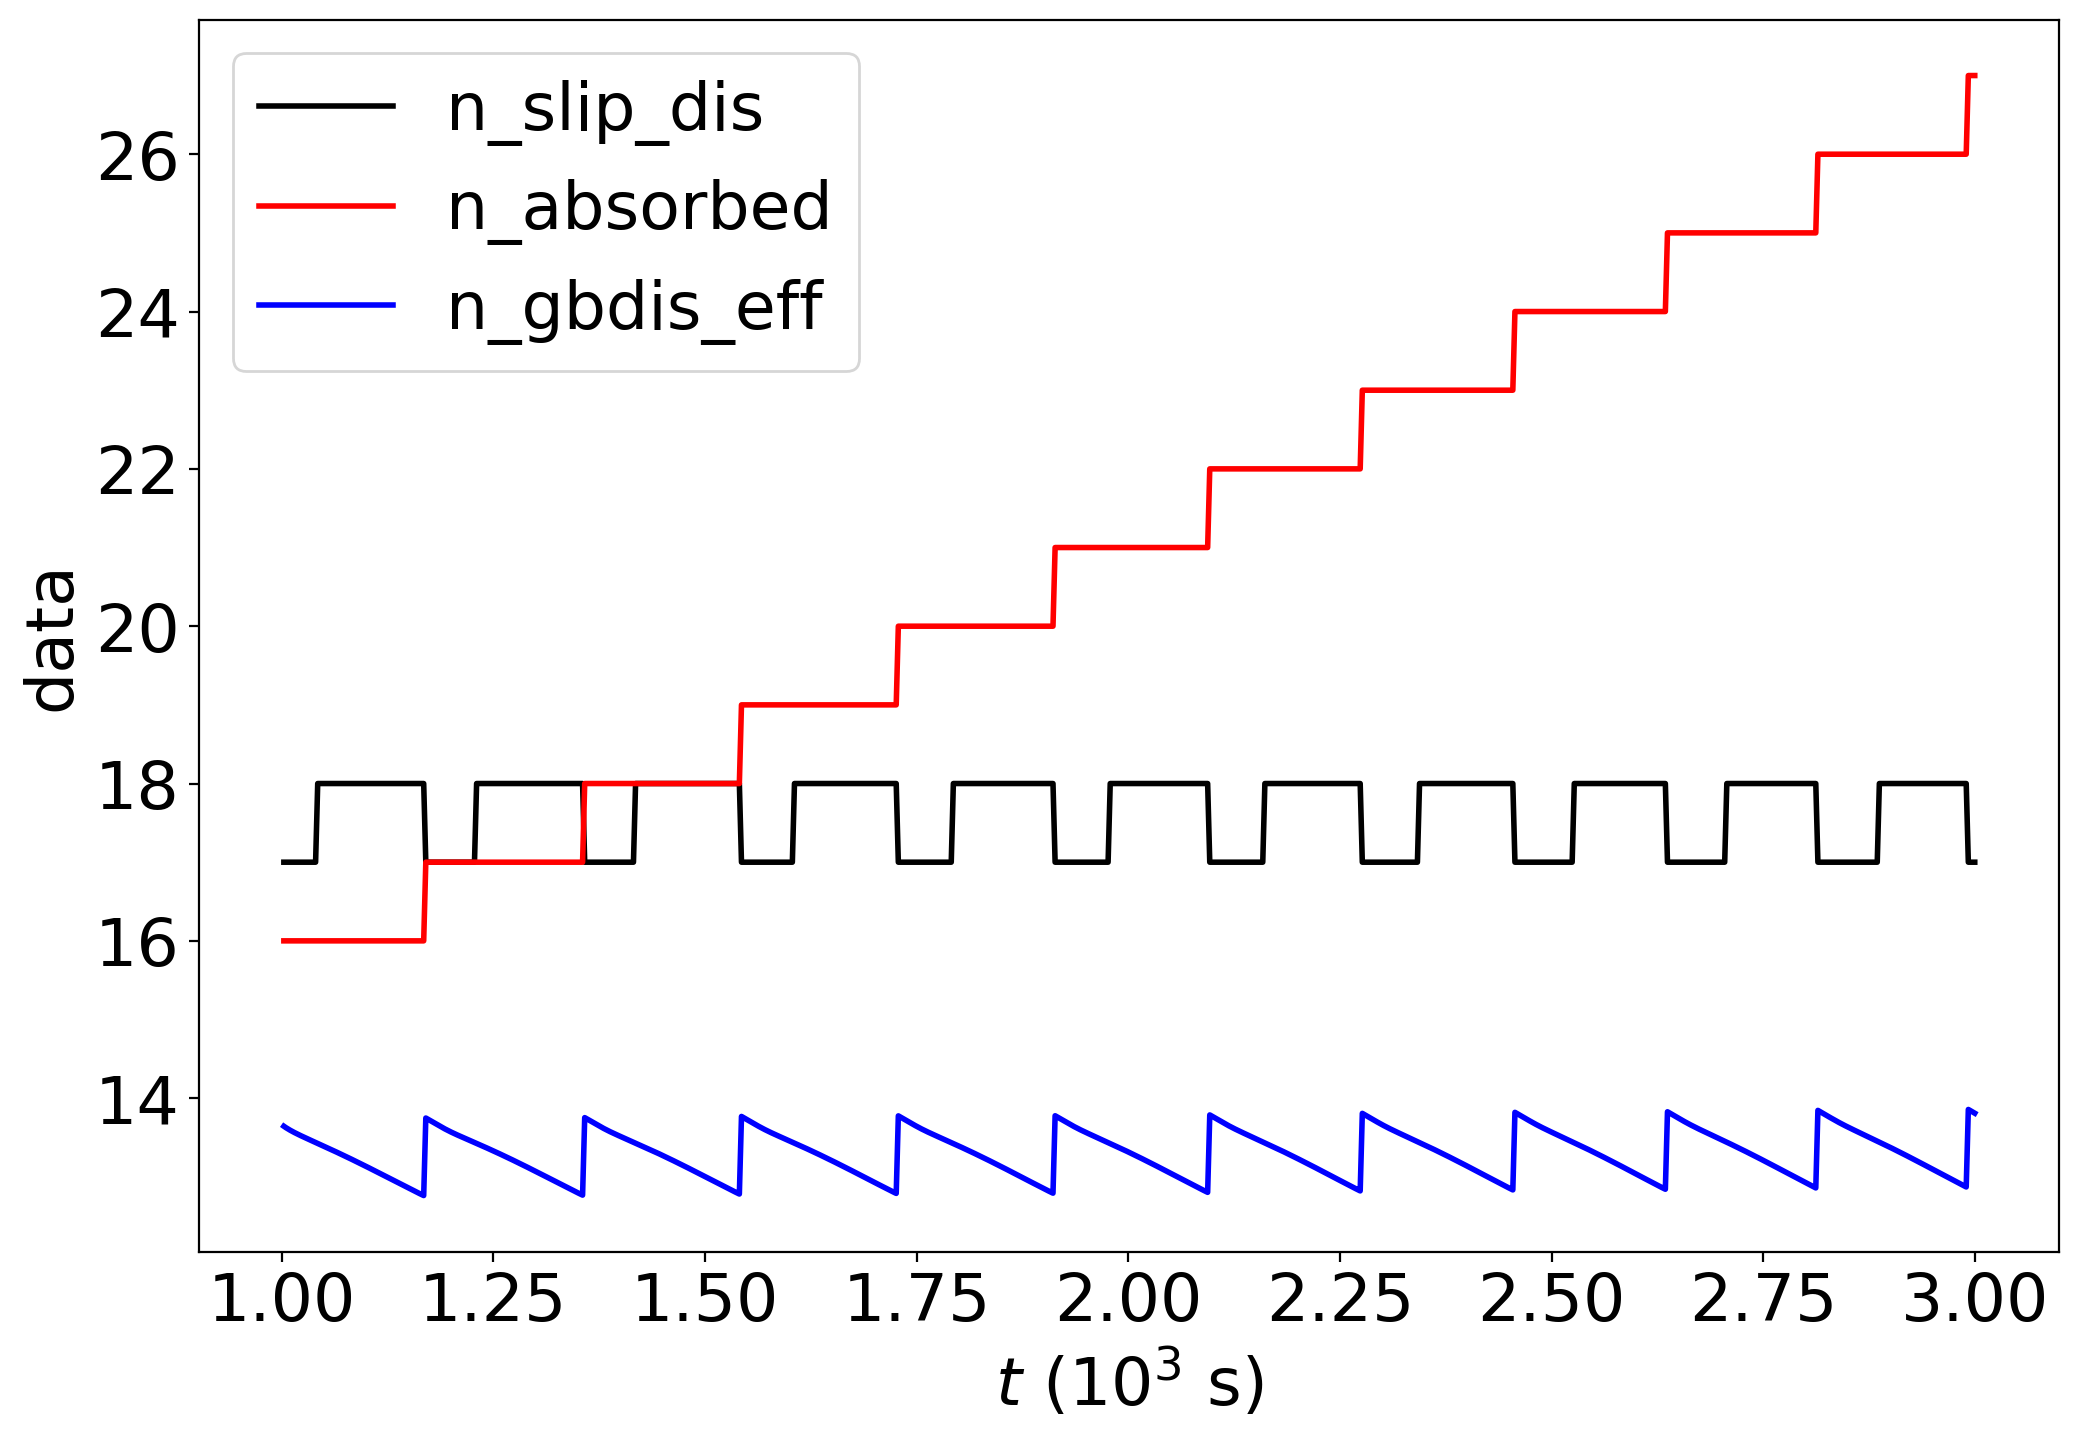

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.3270788765775374e-11, Nslip: 17.67, Ngb_eff: 13.293462453898268
*** hvar, hist *** 1.0 (array([33, 67]), array([17. , 17.5, 18. ]))
Data file with H=1.0, L=0.3, T=900.0, tau0=150.0, n=74


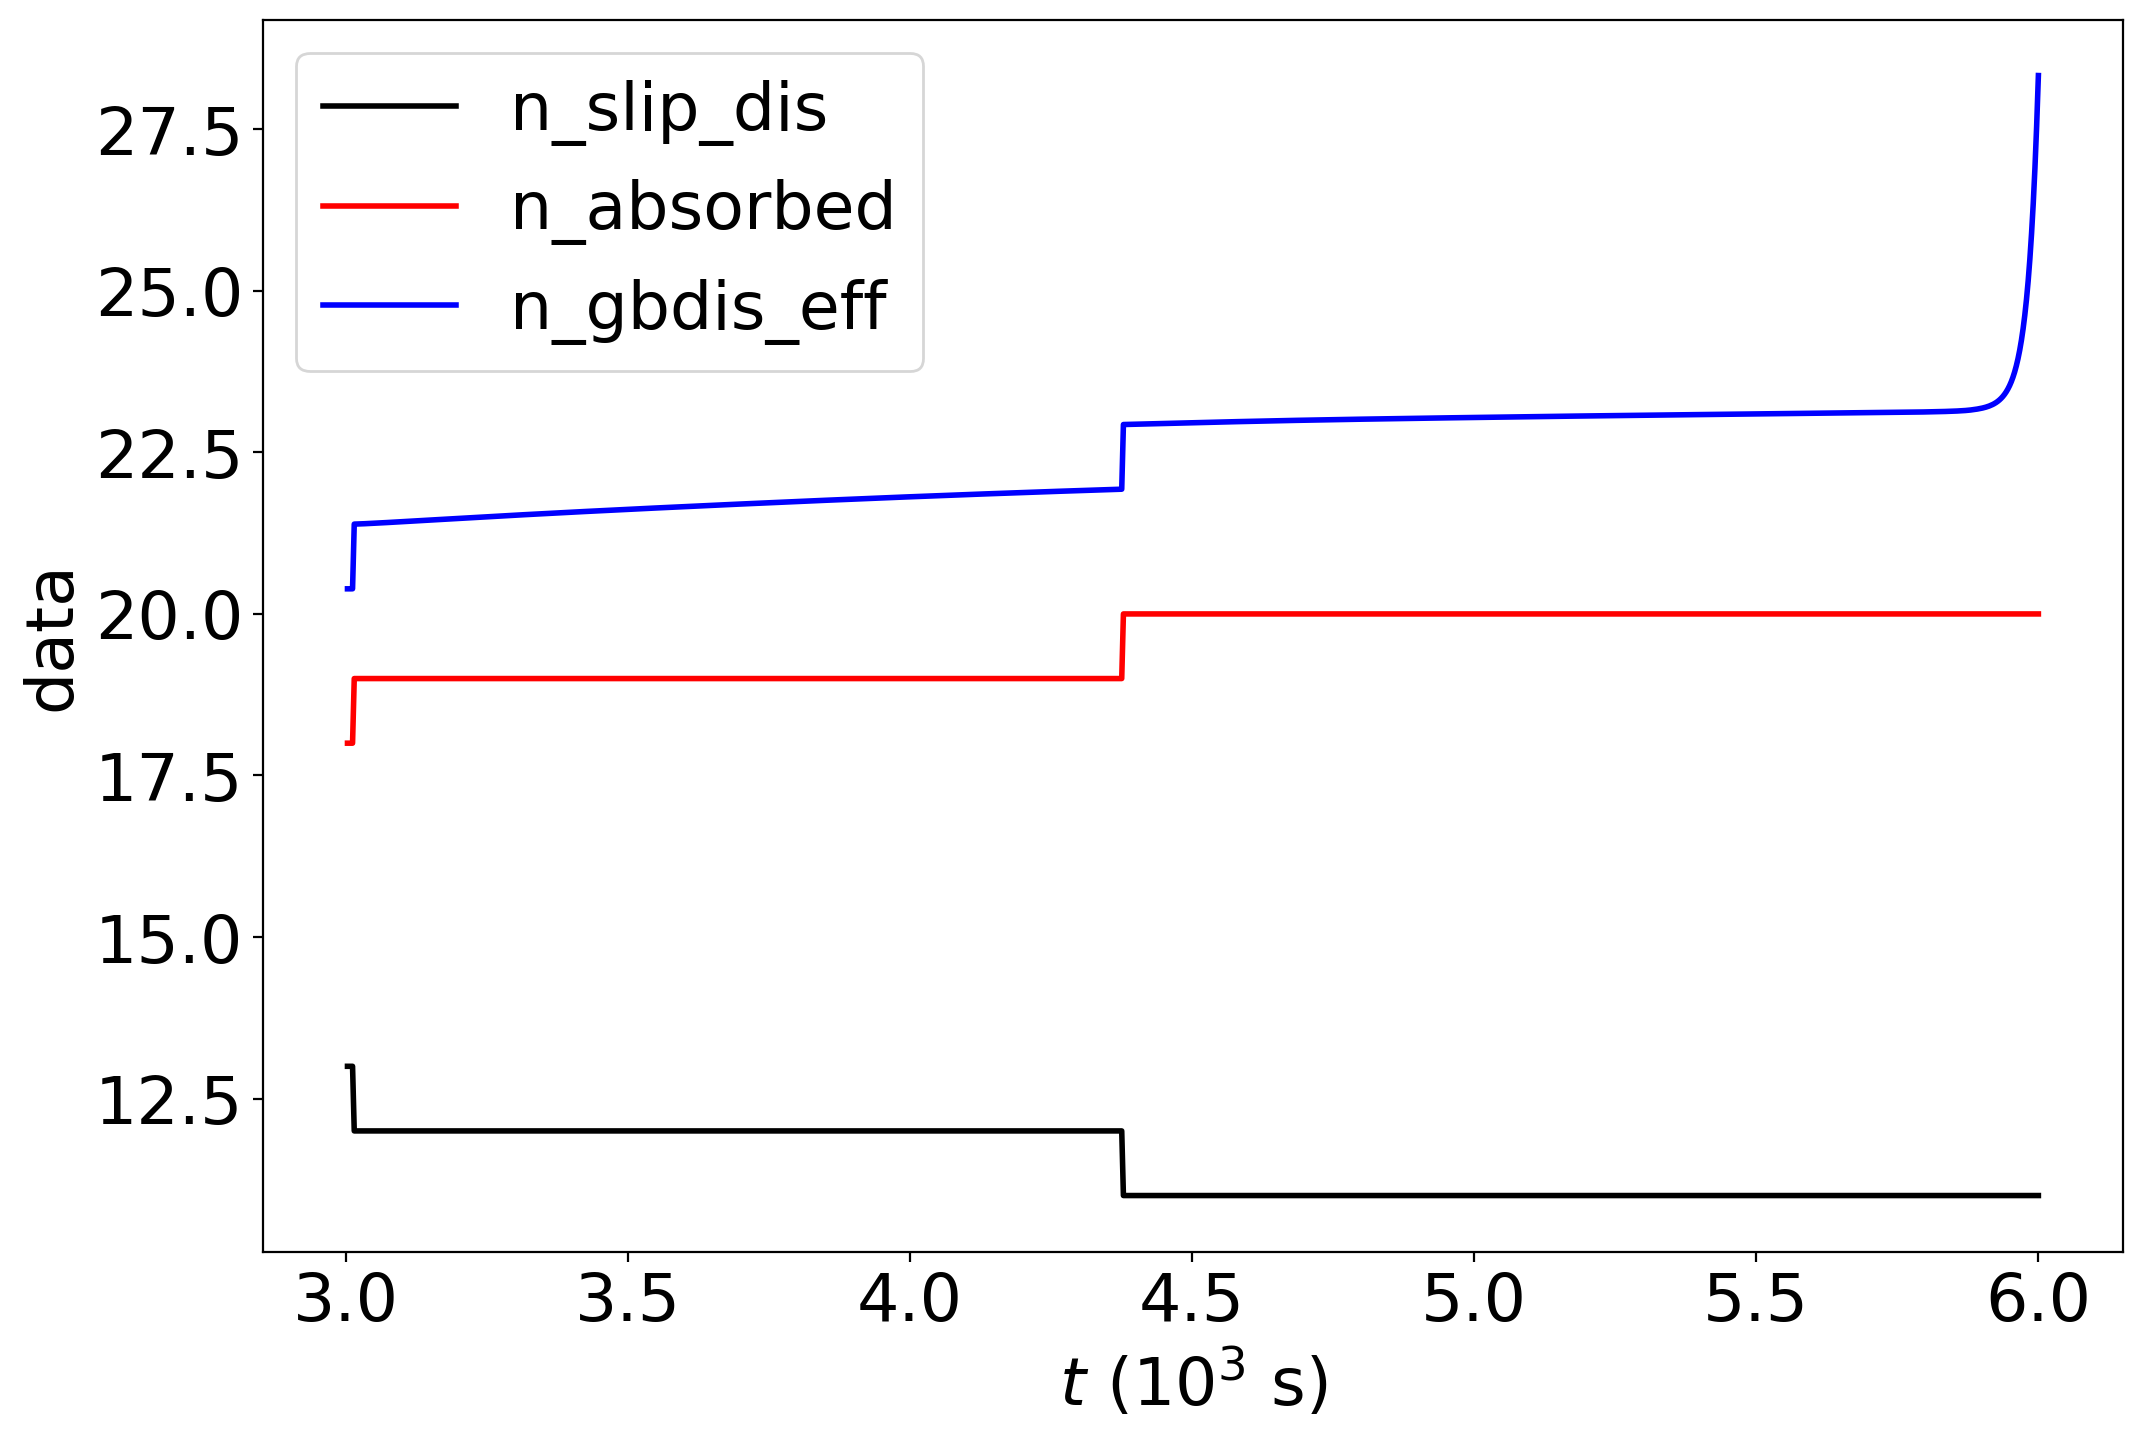

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -5.94553633537479e-13, Nslip: 11.0, Ngb_eff: 23.494557908633656
*** hvar, hist *** 0.0 (array([100]), array([10.5, 11.5]))
Data file with H=30.0, L=0.1, T=900.0, tau0=150.0, n=24


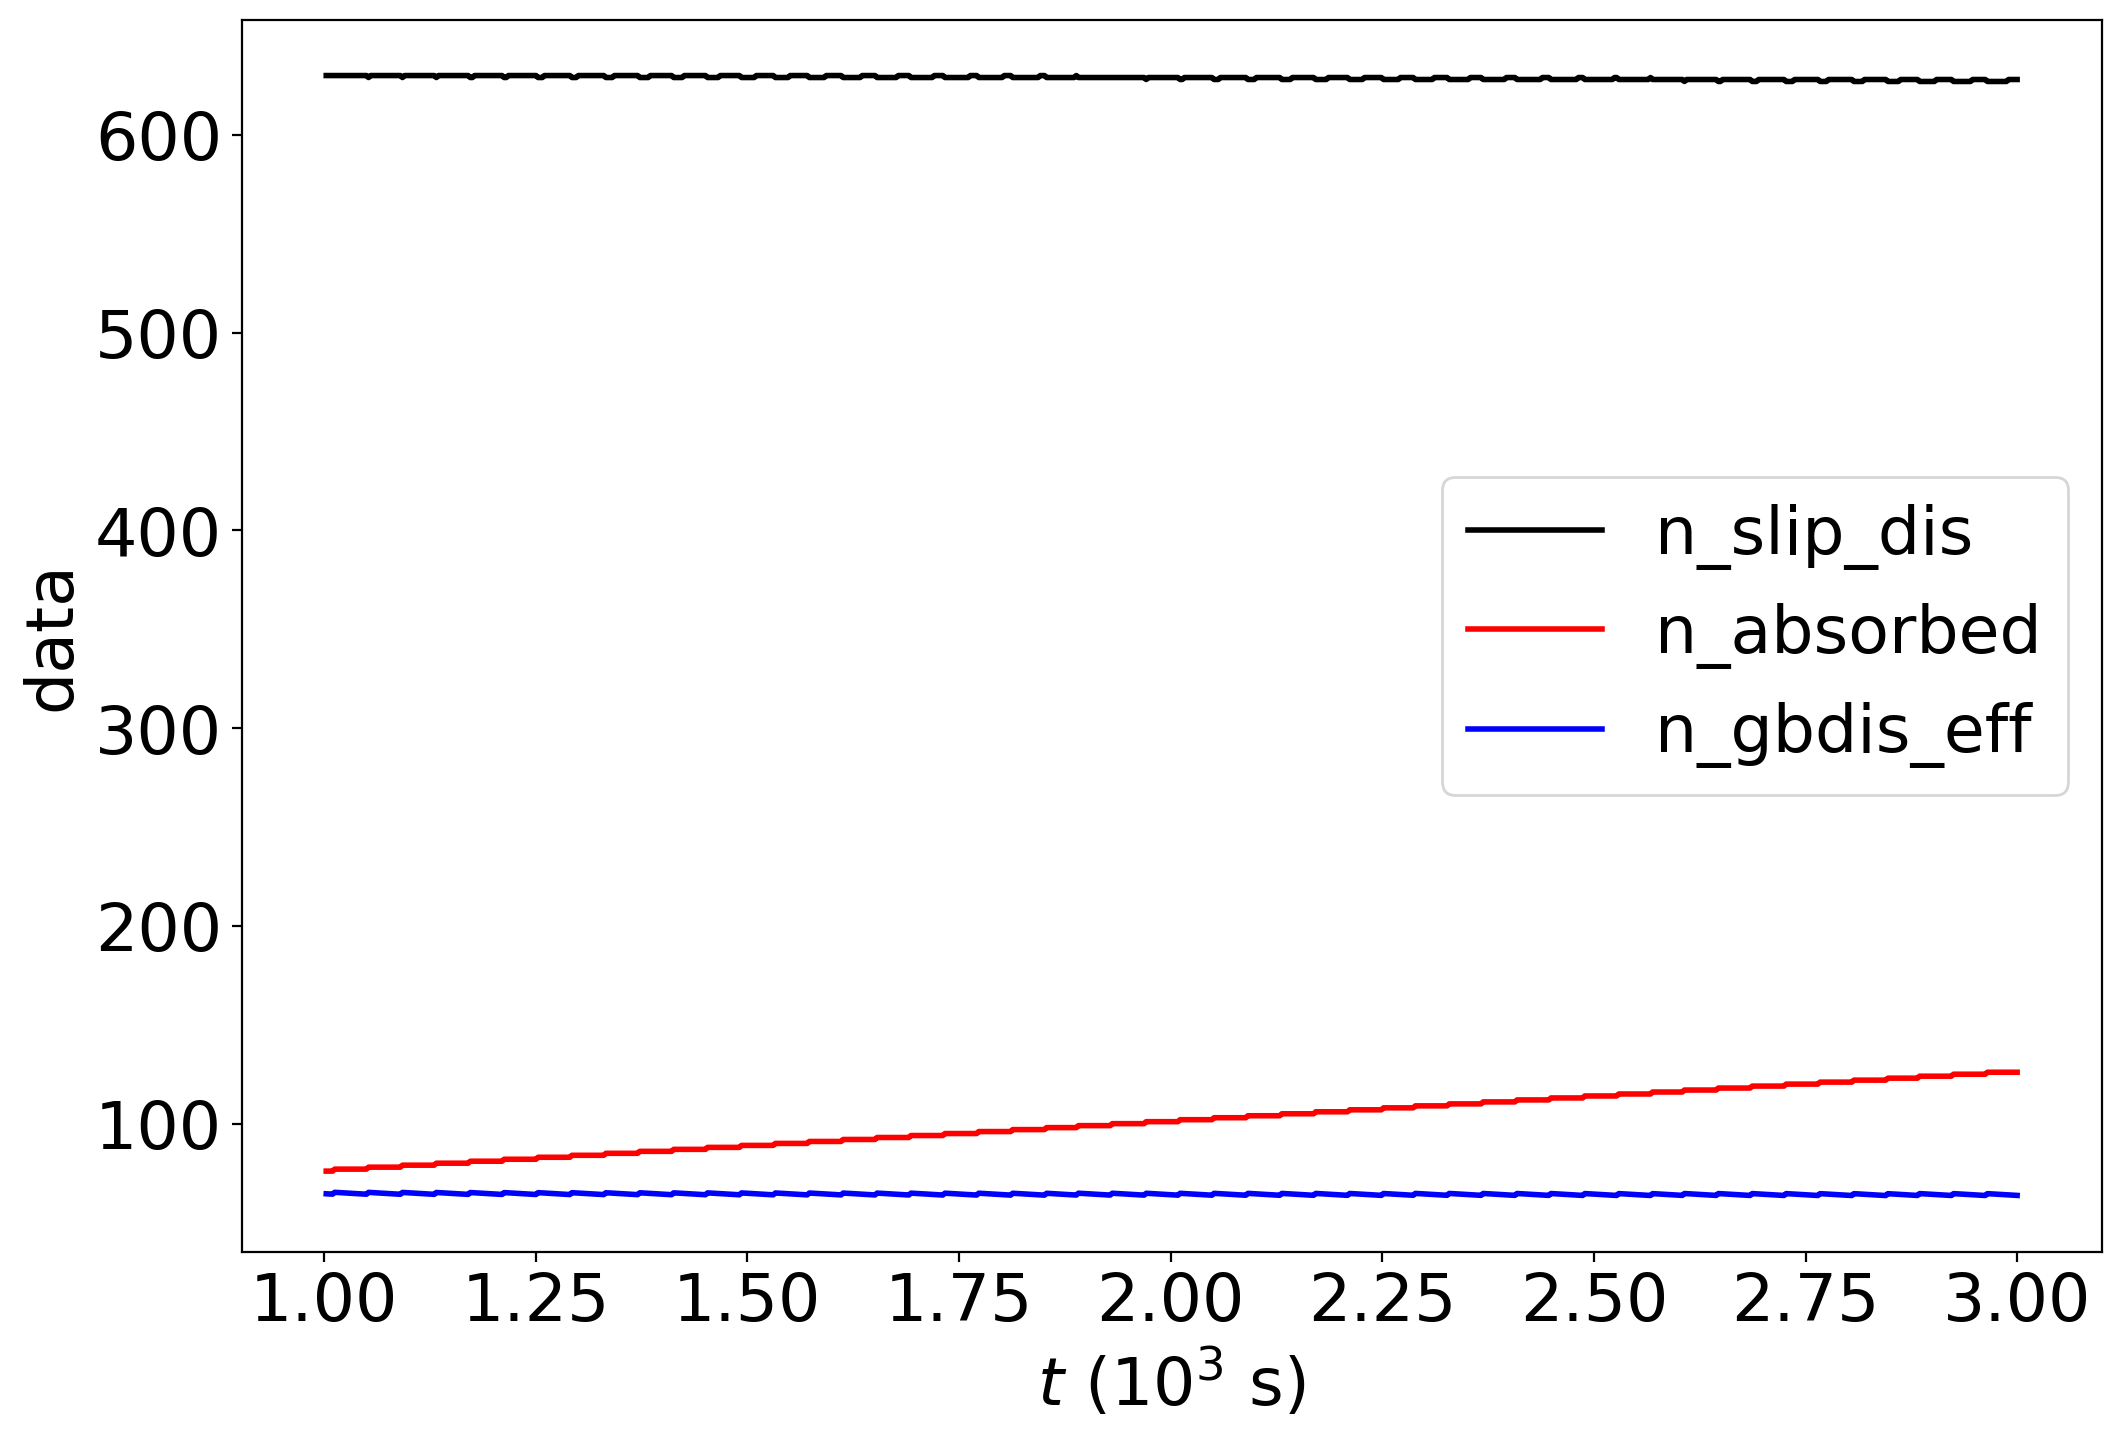

** Max. time step = 1885.5819913269065, Median: 1523.0763060350691
Av. slip rate: 5.969914354486268e-11, Nslip: 627.58, Ngb_eff: 64.12268760670146
*** hvar, hist *** 1.0 (array([42, 58]), array([627. , 627.5, 628. ]))
Data file with H=30.0, L=0.3, T=900.0, tau0=150.0, n=74


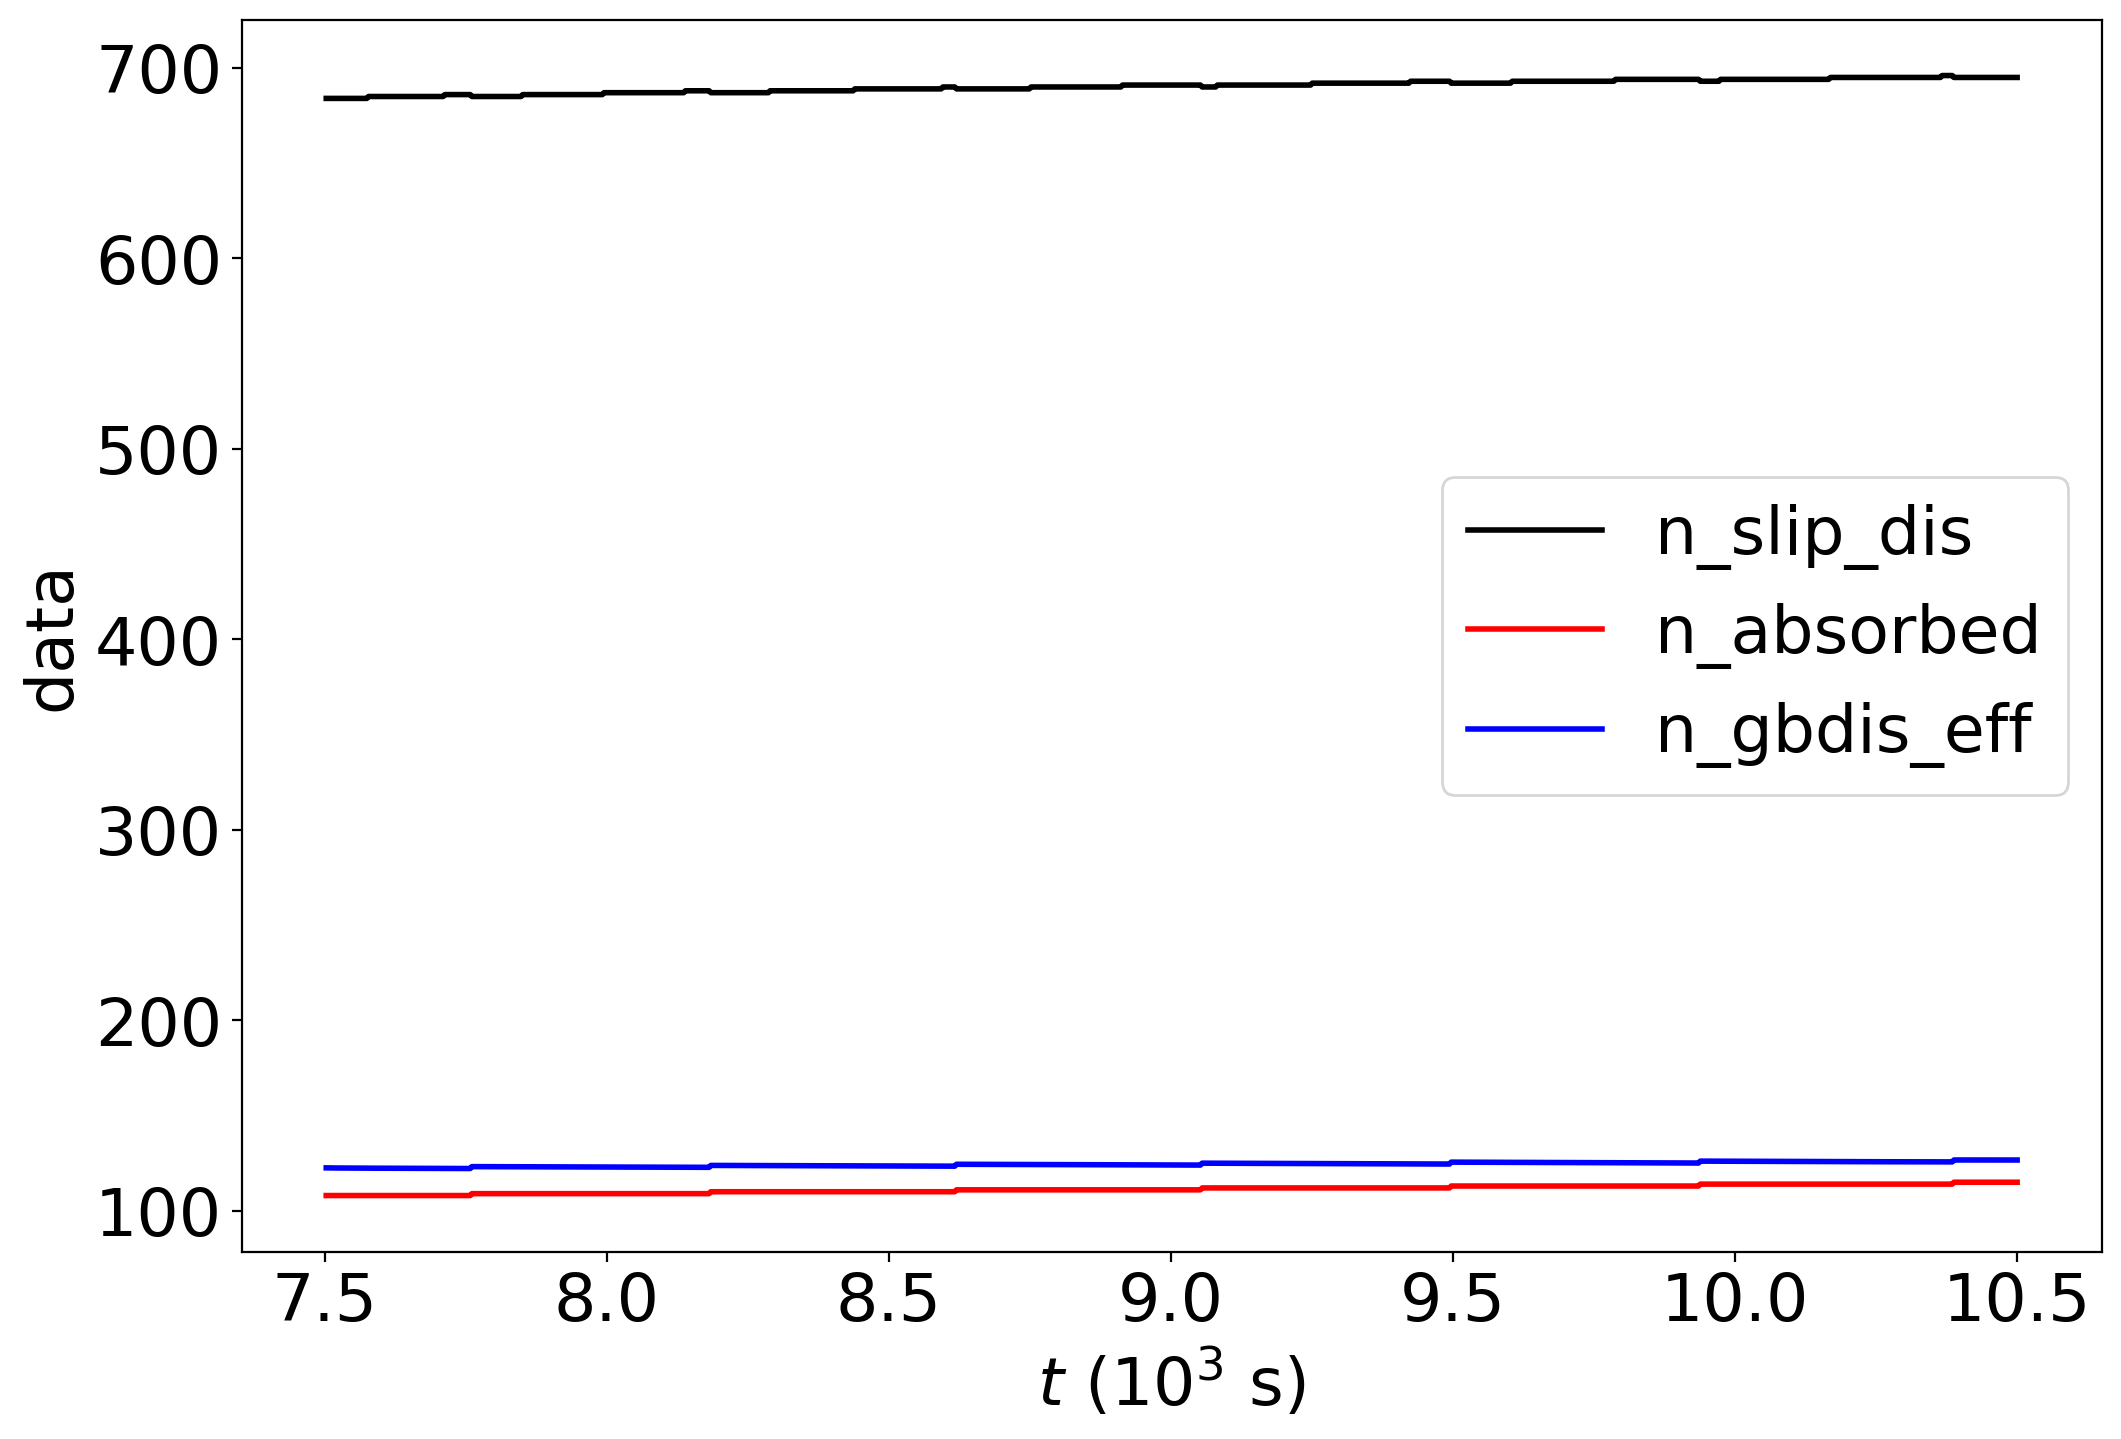

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 3.099992889618693e-12, Nslip: 695.07, Ngb_eff: 126.07627179975412
*** hvar, hist *** 1.0 (array([93,  7]), array([695. , 695.5, 696. ]))
Data file with H=3.0, L=0.1, T=900.0, tau0=150.0, n=24


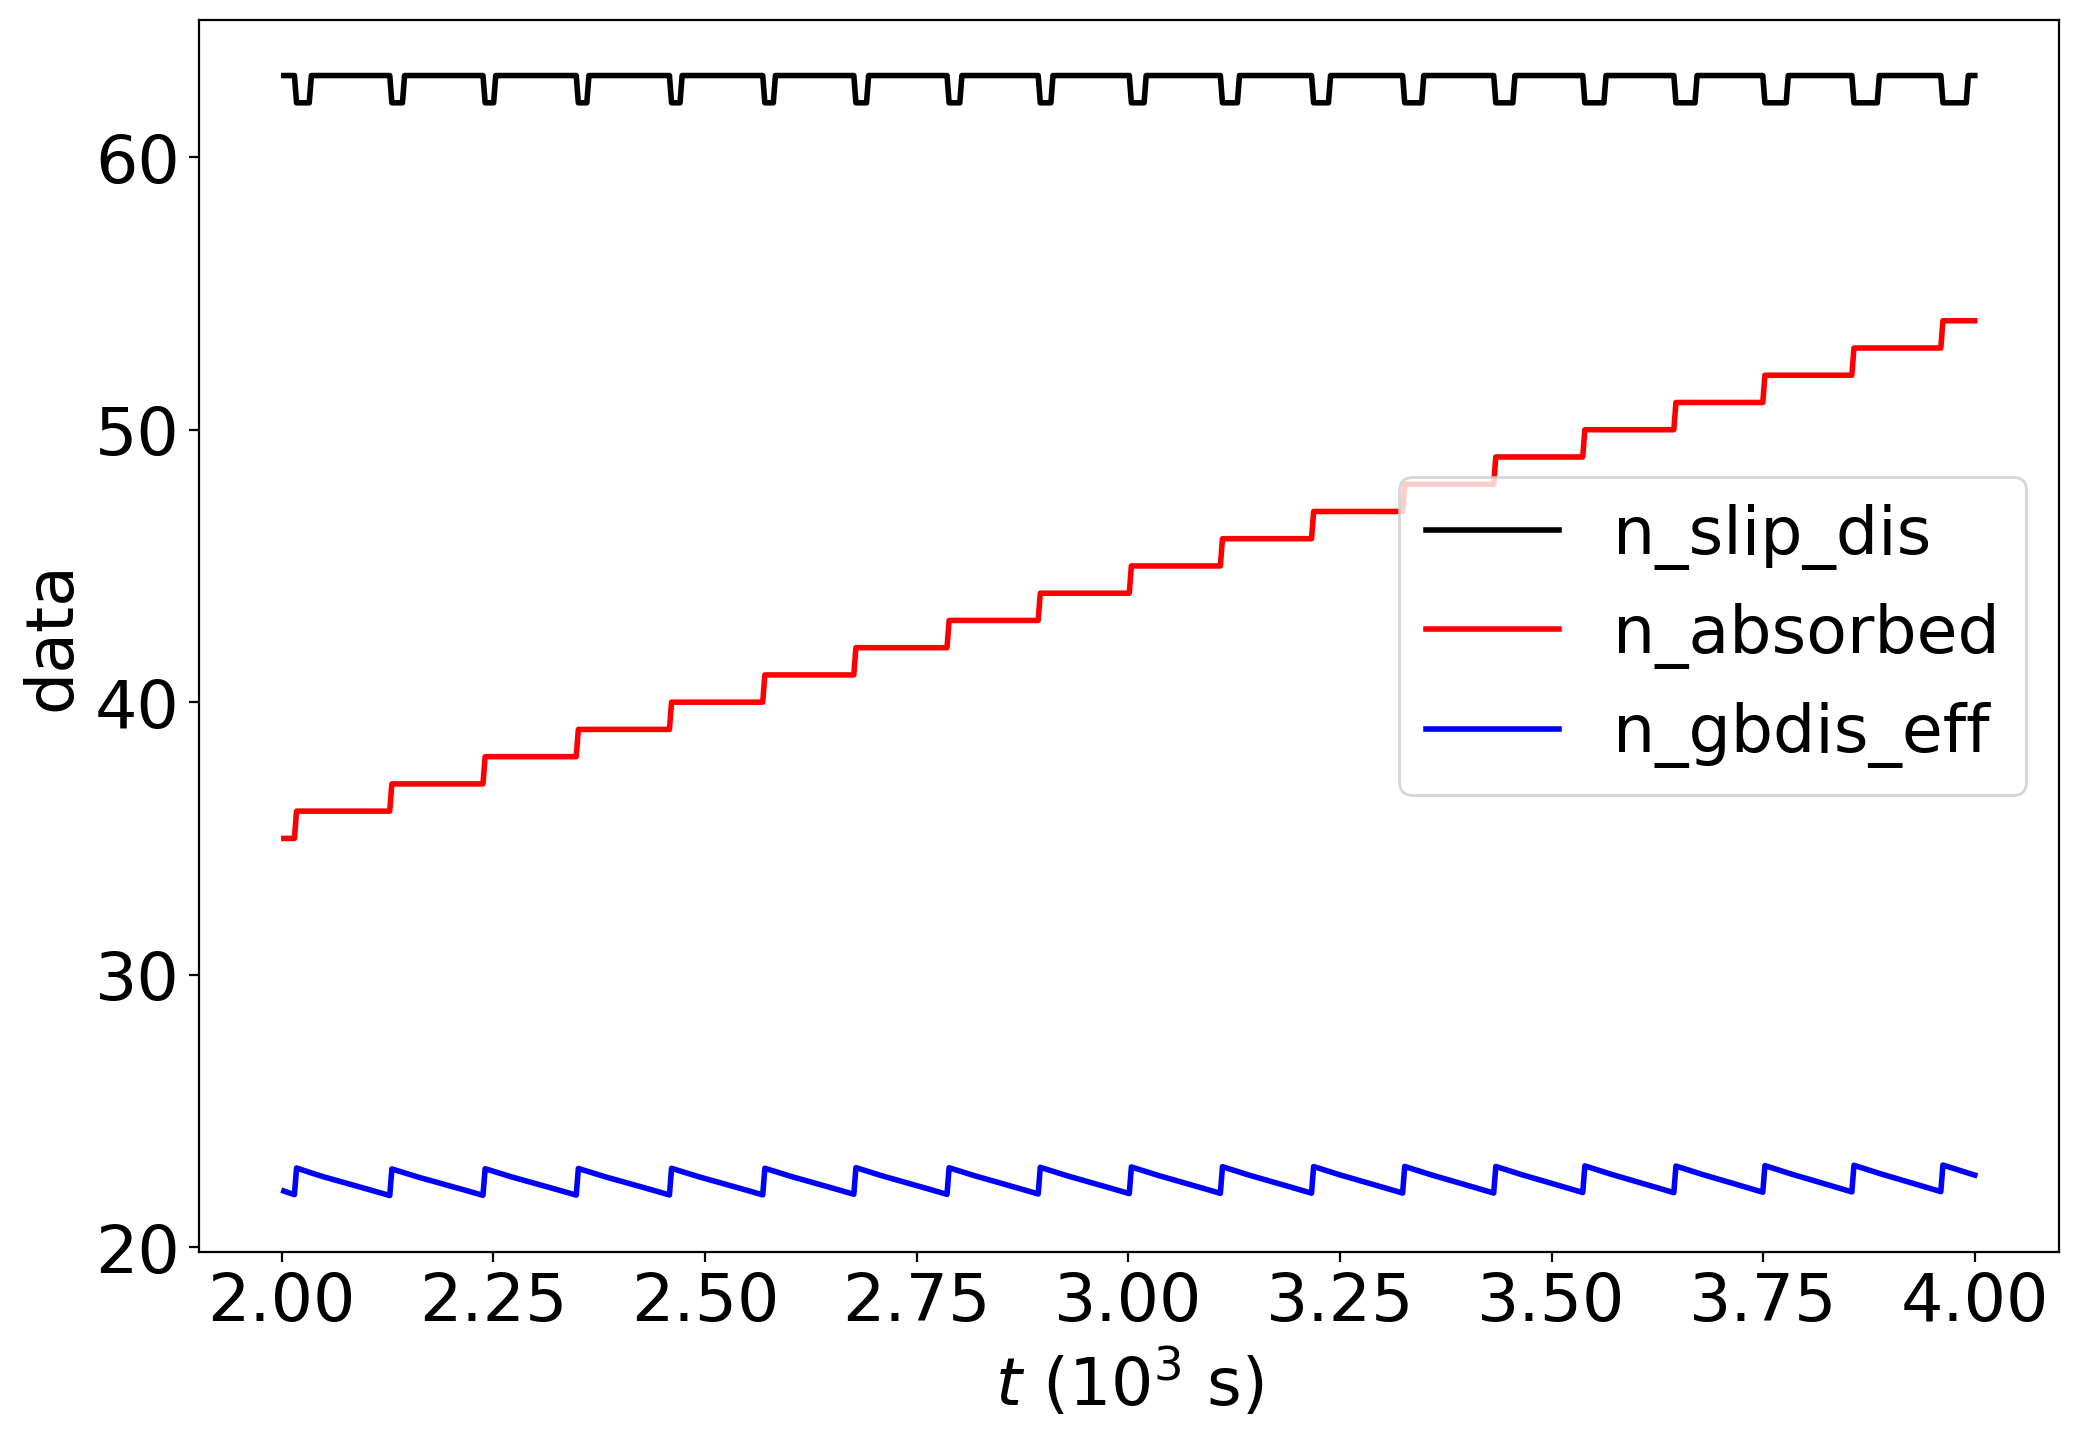

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.311113903362561e-11, Nslip: 62.65, Ngb_eff: 22.556250470921814
*** hvar, hist *** 1.0 (array([35, 65]), array([62. , 62.5, 63. ]))
Data file with H=3.0, L=0.3, T=900.0, tau0=150.0, n=74


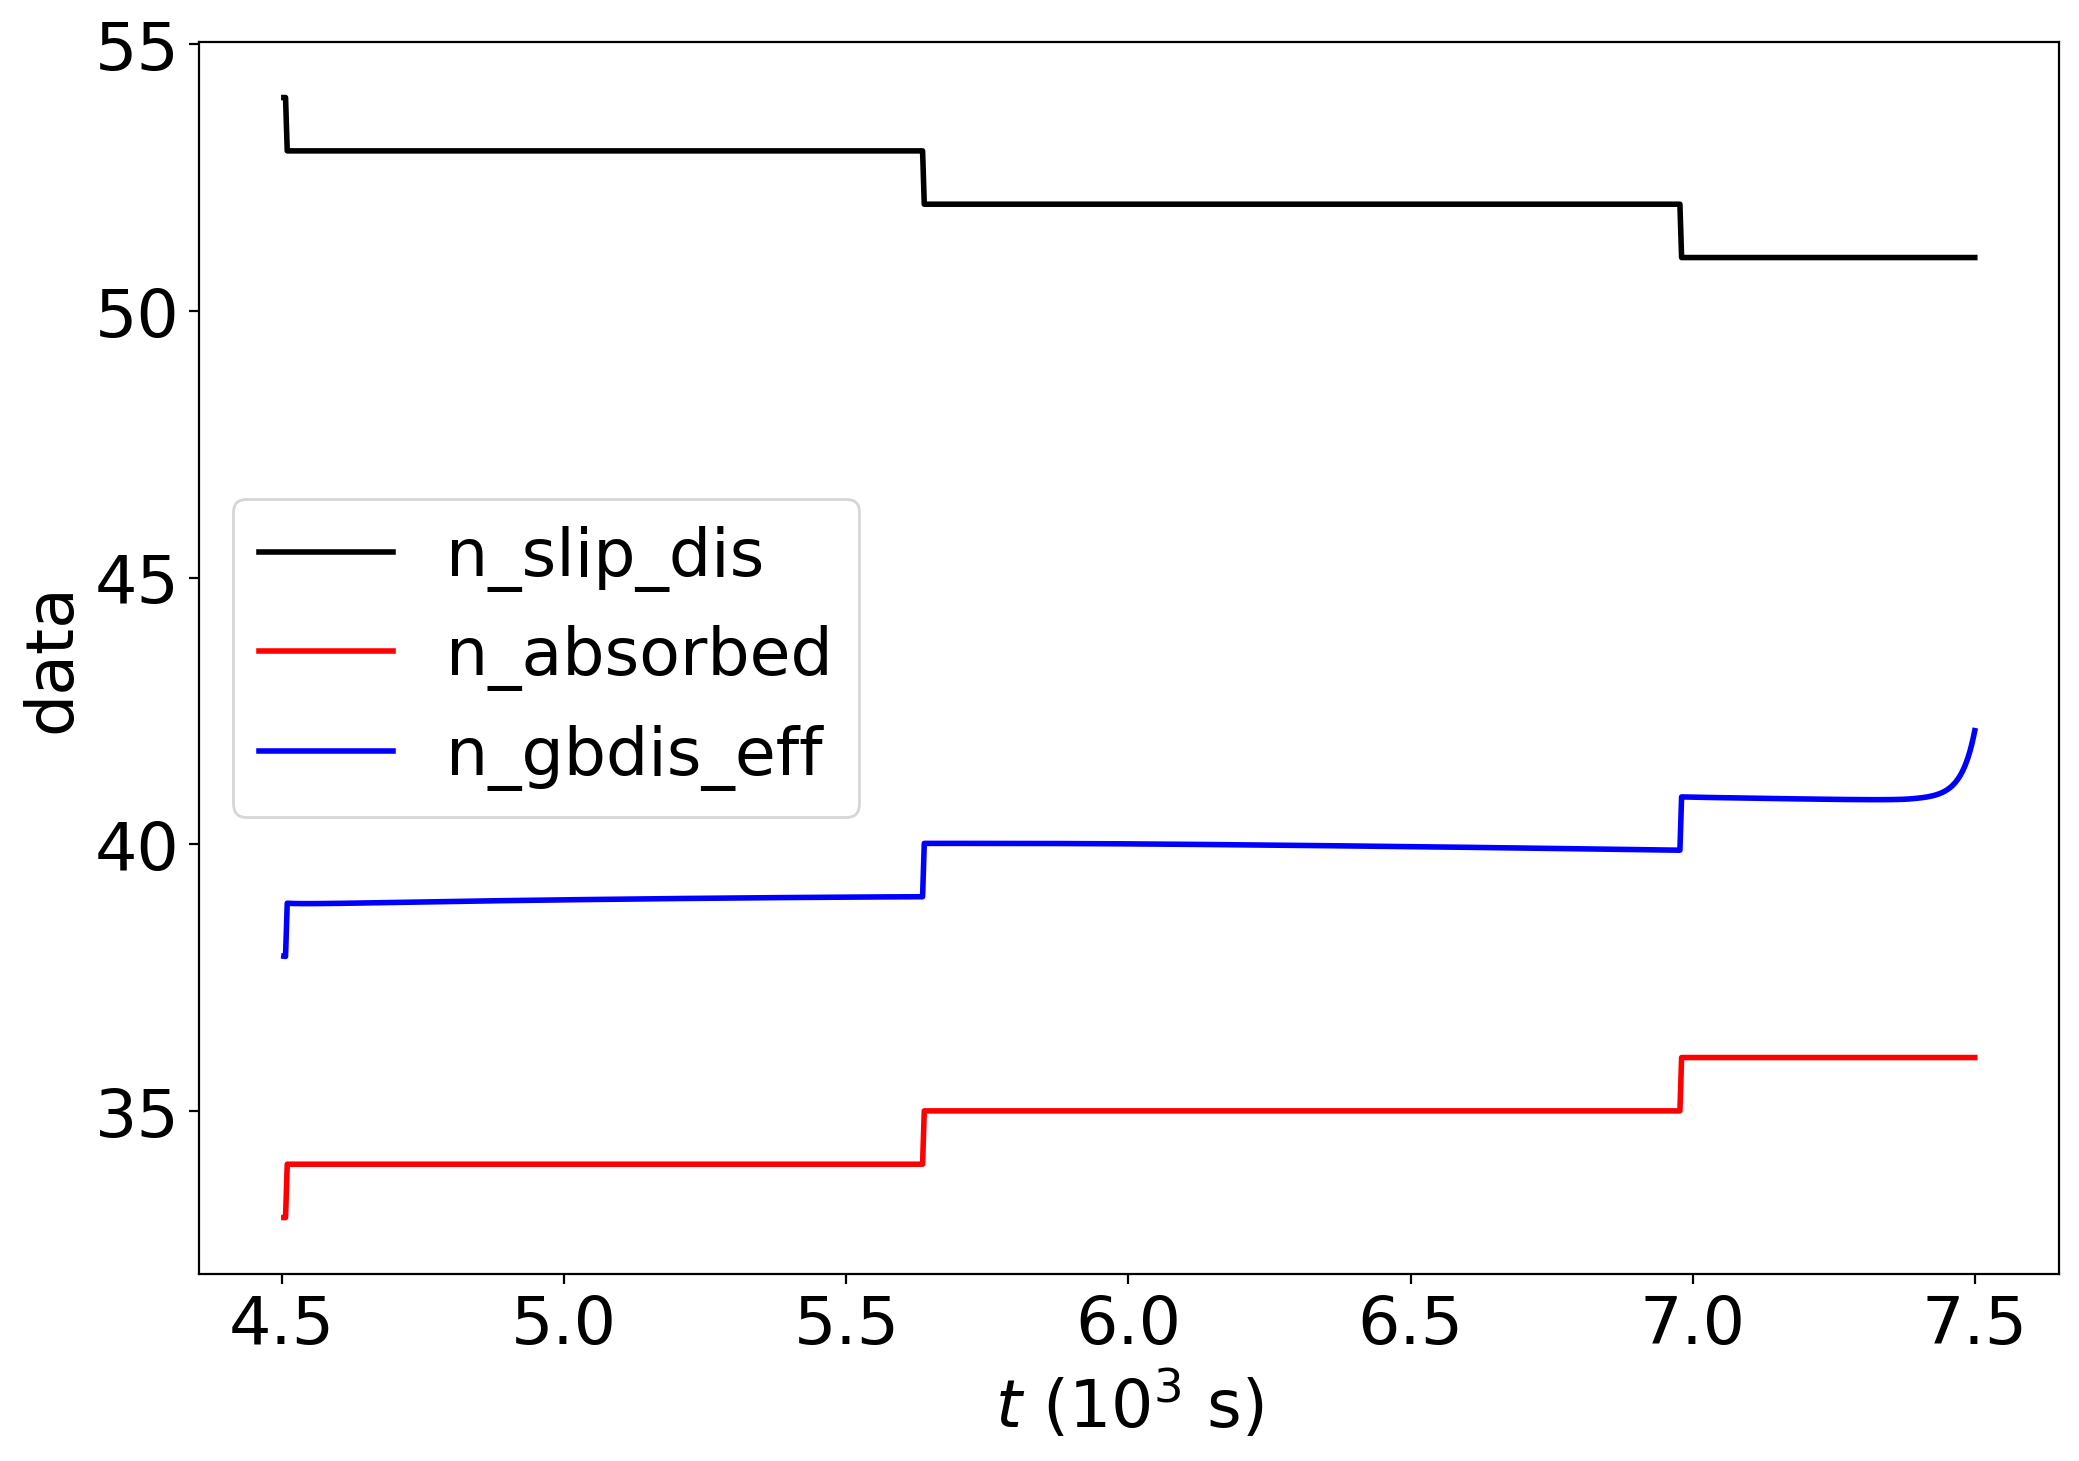

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: -1.863749899575714e-13, Nslip: 51.0, Ngb_eff: 40.950963626990614
*** hvar, hist *** 0.0 (array([100]), array([50.5, 51.5]))
Data file with H=0.3, L=0.1, T=900.0, tau0=150.0, n=24


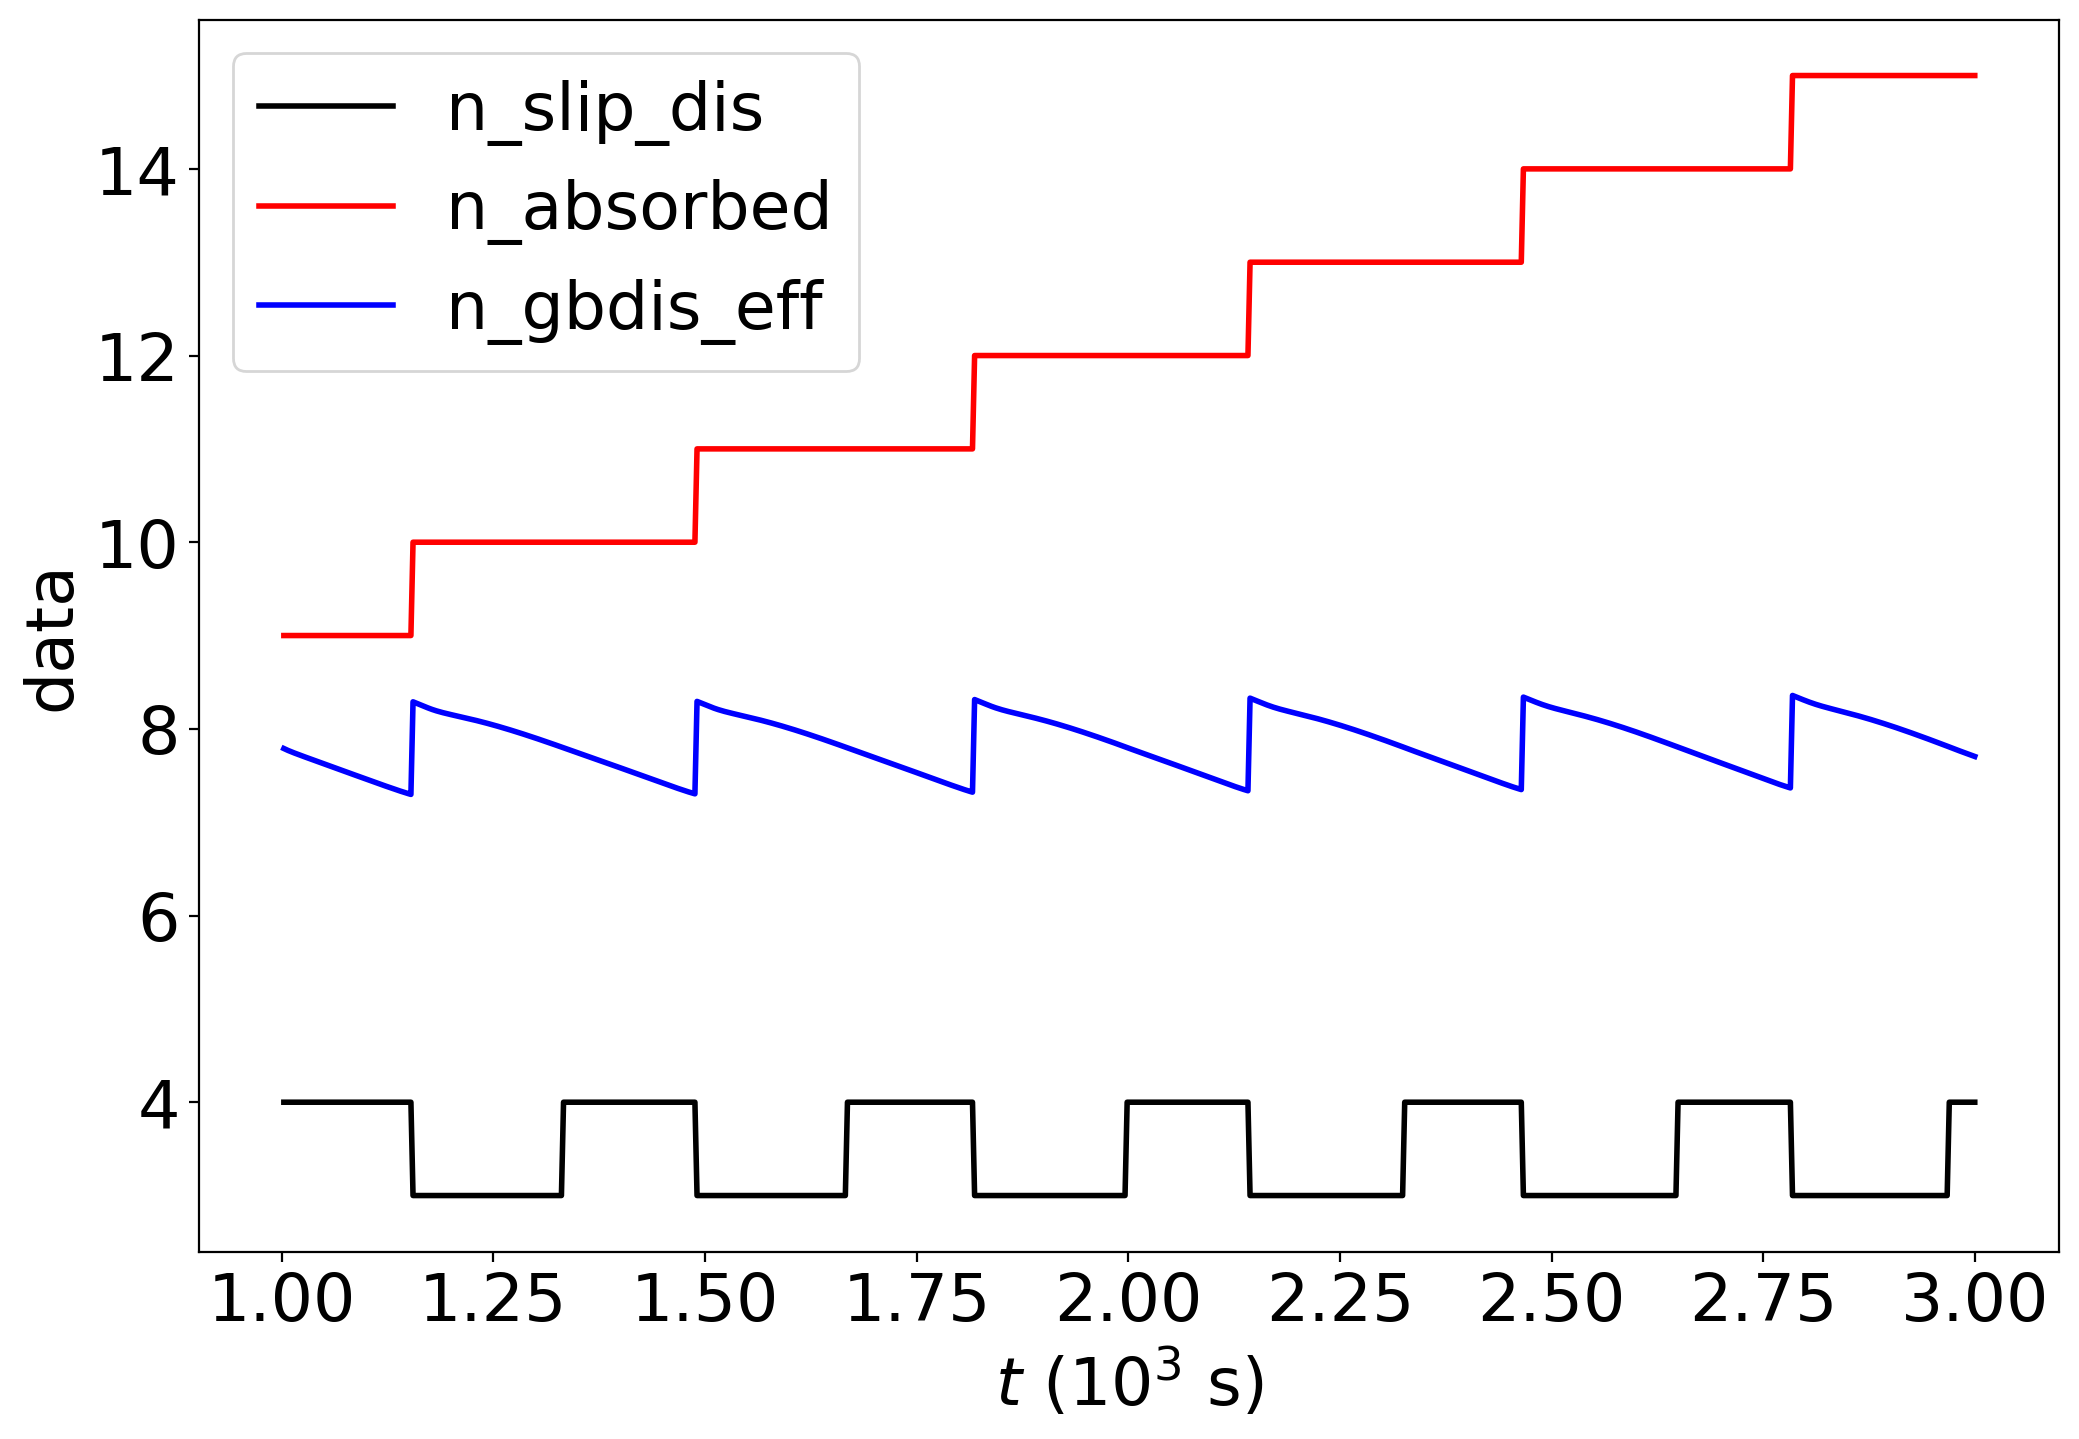

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 9.283458252260477e-12, Nslip: 3.26, Ngb_eff: 7.9604835725249
*** hvar, hist *** 1.0 (array([74, 26]), array([3. , 3.5, 4. ]))
Data file with H=0.3, L=0.3, T=900.0, tau0=150.0, n=74


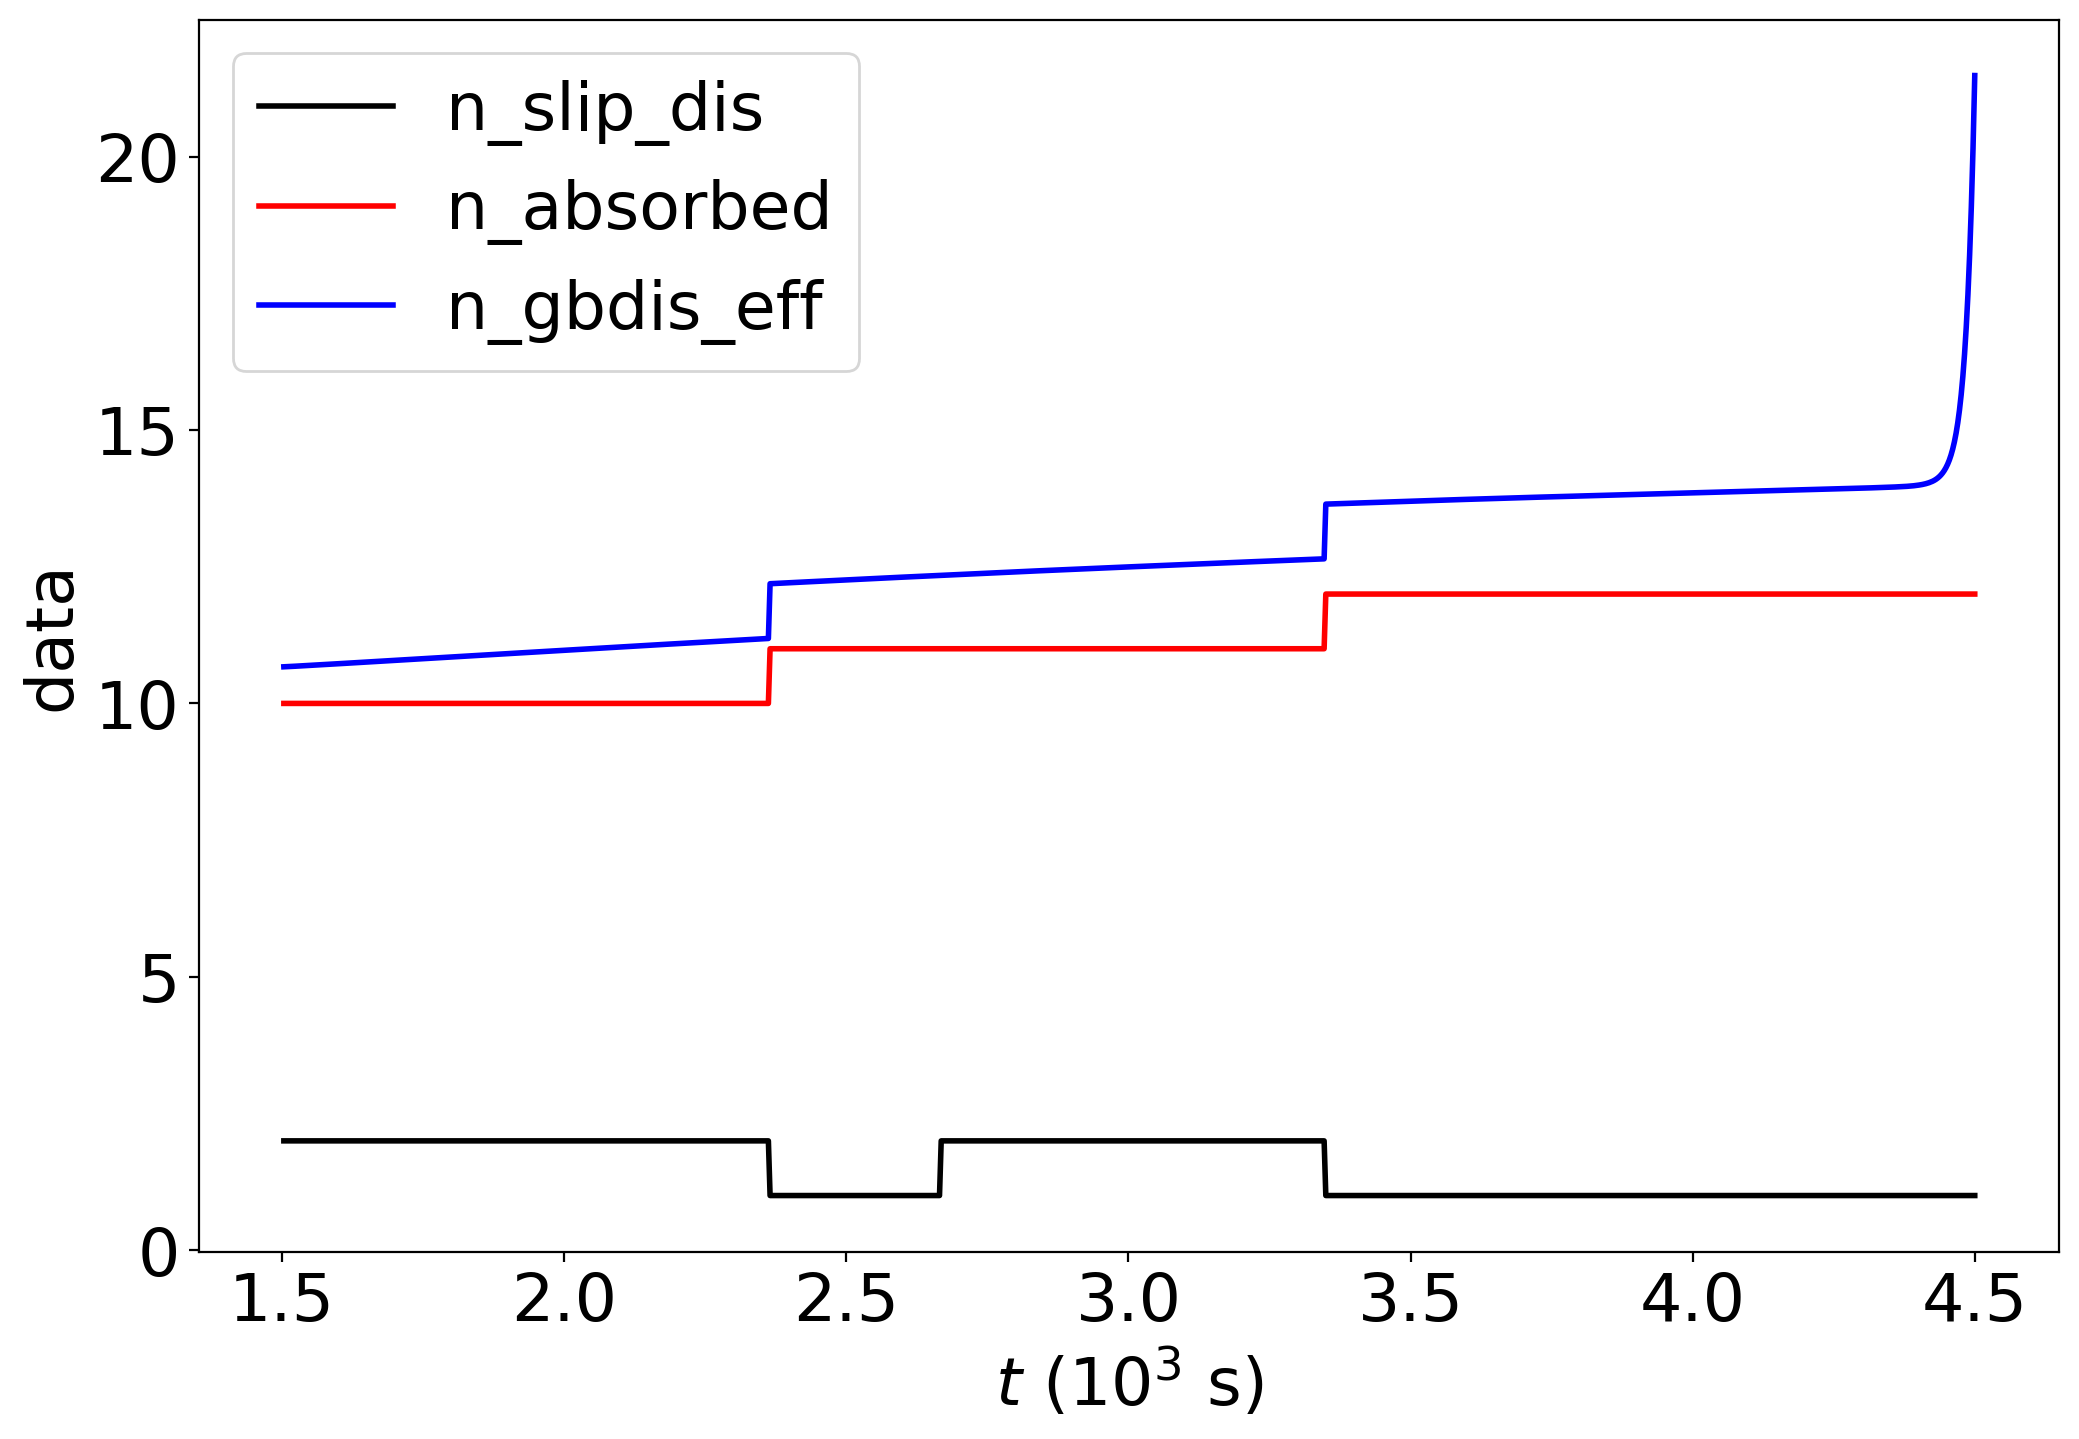

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 4.8928131608161967e-14, Nslip: 1.0, Ngb_eff: 14.391164588808788
*** hvar, hist *** 0.0 (array([100]), array([0.5, 1.5]))
Data file with H=60.0, L=0.1, T=900.0, tau0=150.0, n=24


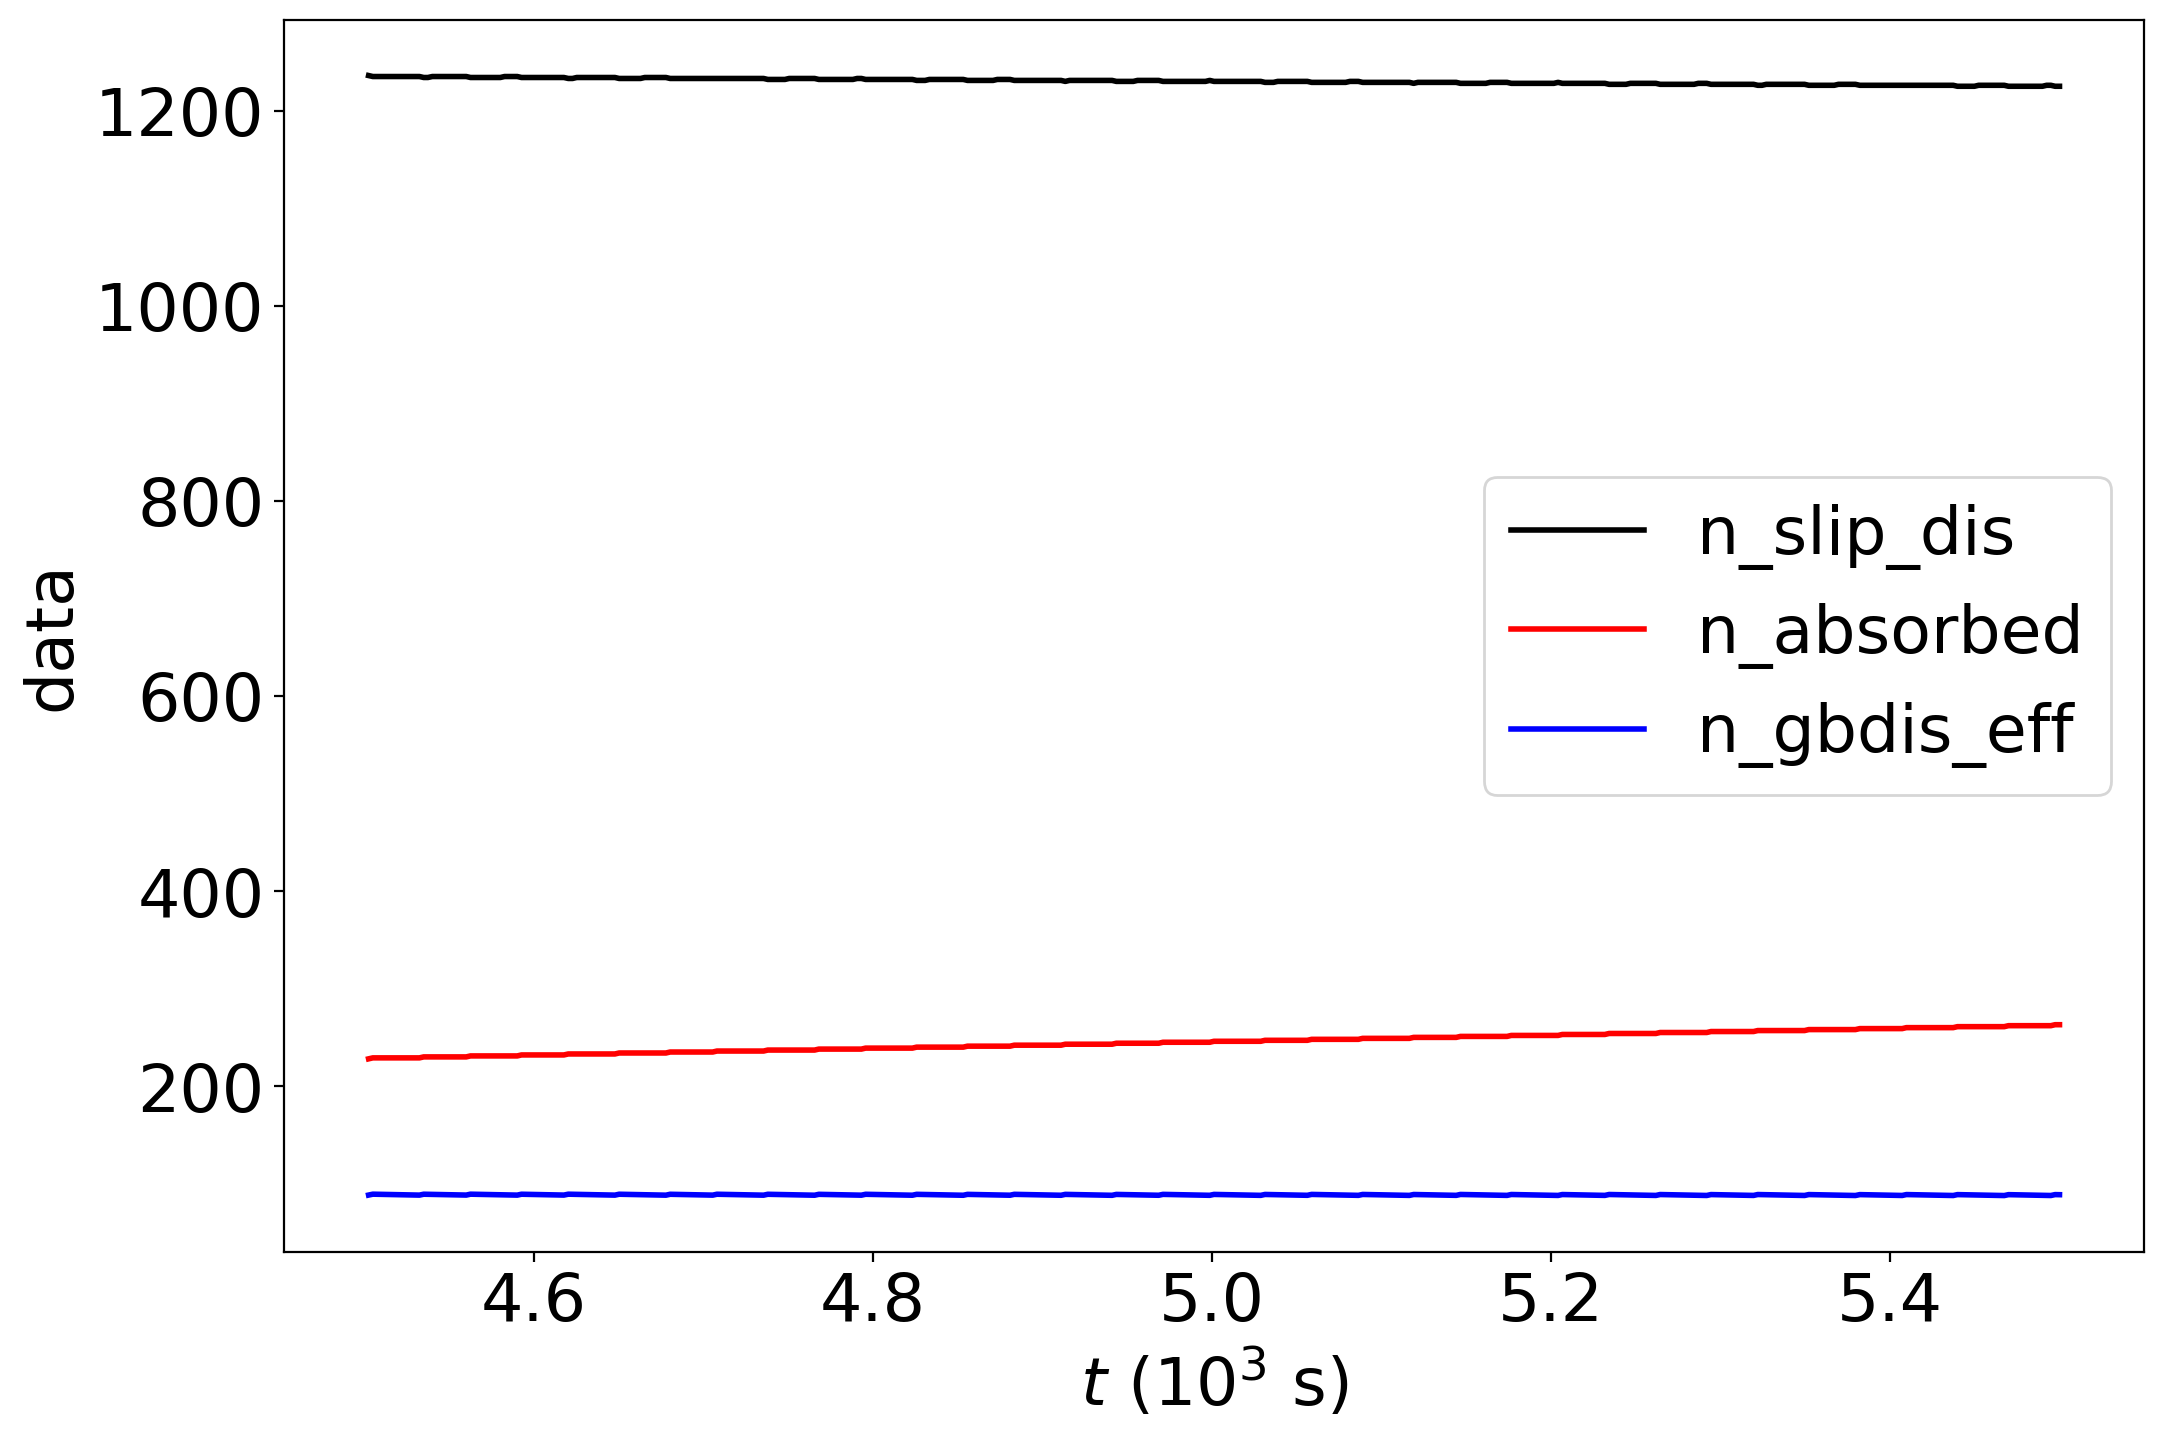

** Max. time step = 1284.2165143603881, Median: 1029.30768160274
Av. slip rate: 6.744654243001211e-11, Nslip: 1226.35, Ngb_eff: 88.38741461996175
*** hvar, hist *** 3.0 (array([16, 41, 35,  8]), array([1225.  , 1225.75, 1226.5 , 1227.25, 1228.  ]))
Data file with H=60.0, L=0.3, T=900.0, tau0=150.0, n=74


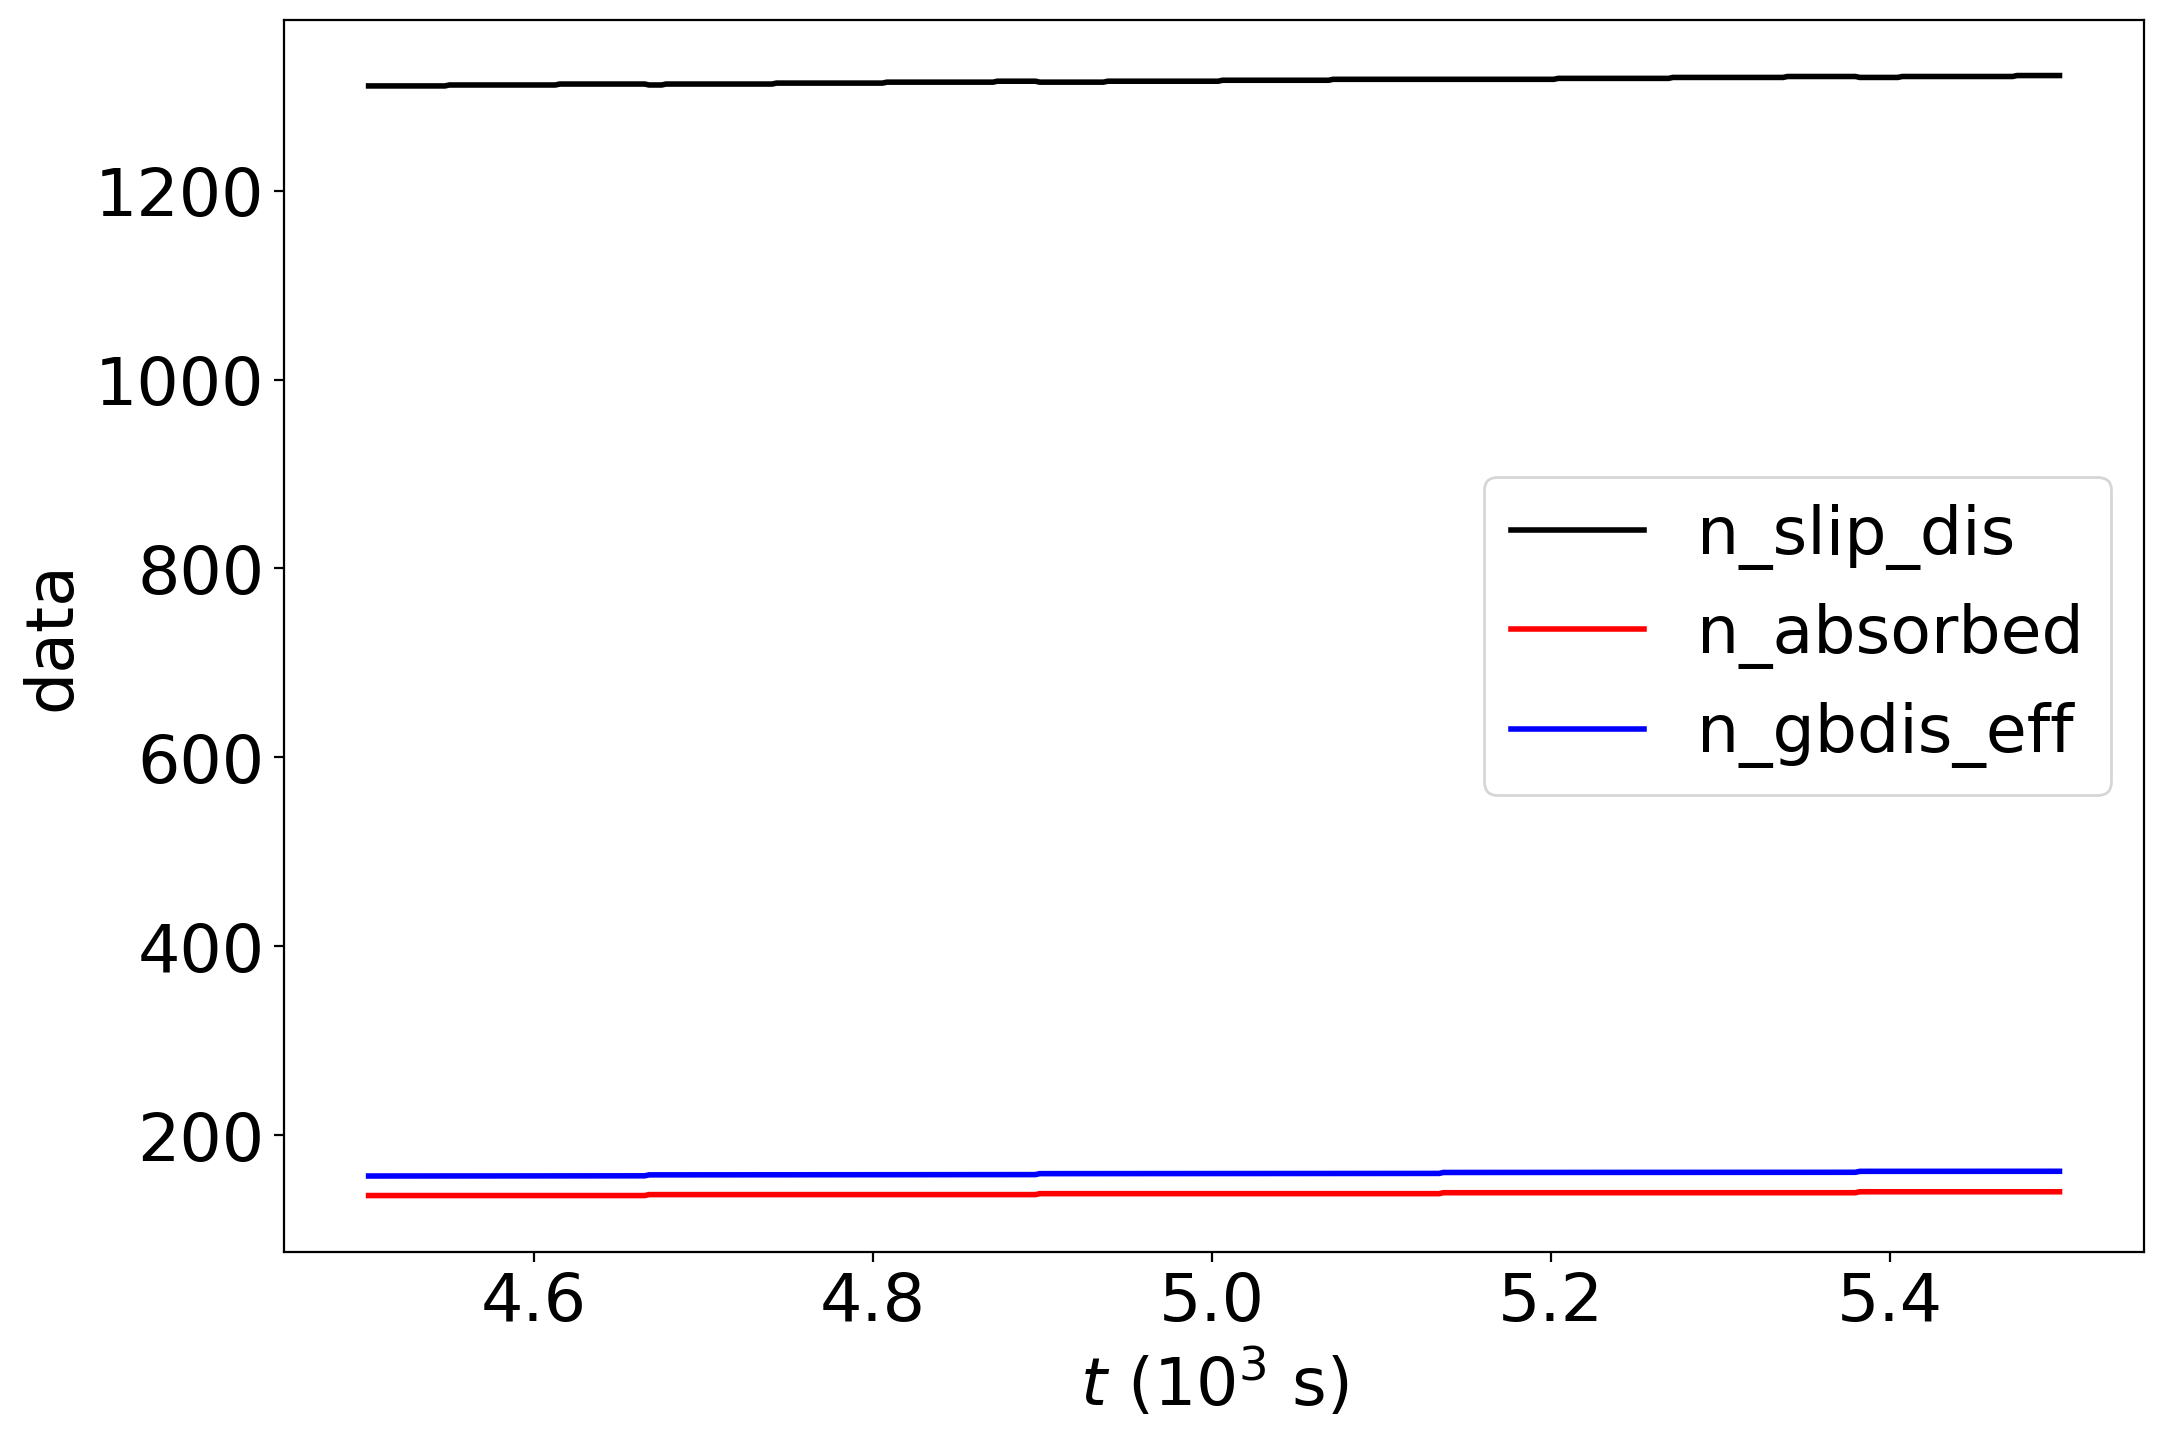

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 7.923826742503487e-12, Nslip: 1320.58, Ngb_eff: 161.09297293106948
*** hvar, hist *** 3.0 (array([ 8, 37, 44, 11]), array([1319.  , 1319.75, 1320.5 , 1321.25, 1322.  ]))


In [6]:
path = "../data/Res-tau150/" #-v2_2_4/"  # 
flist = find_h5_files(path)
for i, fname in enumerate(flist):
    #if not "H300" in str(fname):
    #    continue
    gbdd = dd.GB_dislocations(from_file=fname)
    print(f"Data file with H={gbdd.D2}, L={gbdd.Dgp}, T={gbdd.temp}, tau0={gbdd.tau0}, n={gbdd.Ngbn-1}")
    gbdd.plot_time_series(['n_slip_dis', 'n_absorbed', 'n_gbdis_eff'])
    print(f"** Max. time step = {max(gbdd.glob_data['timestep'])}, Median: {np.median(gbdd.glob_data['timestep'])}")
    print(f"Av. slip rate: {np.mean(gbdd.glob_data['plast_slip_rate'][-100:])}, "
          f"Nslip: {np.mean(gbdd.glob_data['n_slip_dis'][-100:])}, Ngb_eff: {np.mean(gbdd.glob_data['n_gbdis_eff'][-100:])}")
    data.append(gbdd)
    hh = gbdd.glob_data["n_slip_dis"][gbdd.nout-100:gbdd.nout]
    hvar = max(hh) - min(hh)
    nhist = np.histogram(hh, bins=int(hvar+1))
    print('*** hvar, hist ***',hvar, nhist, )

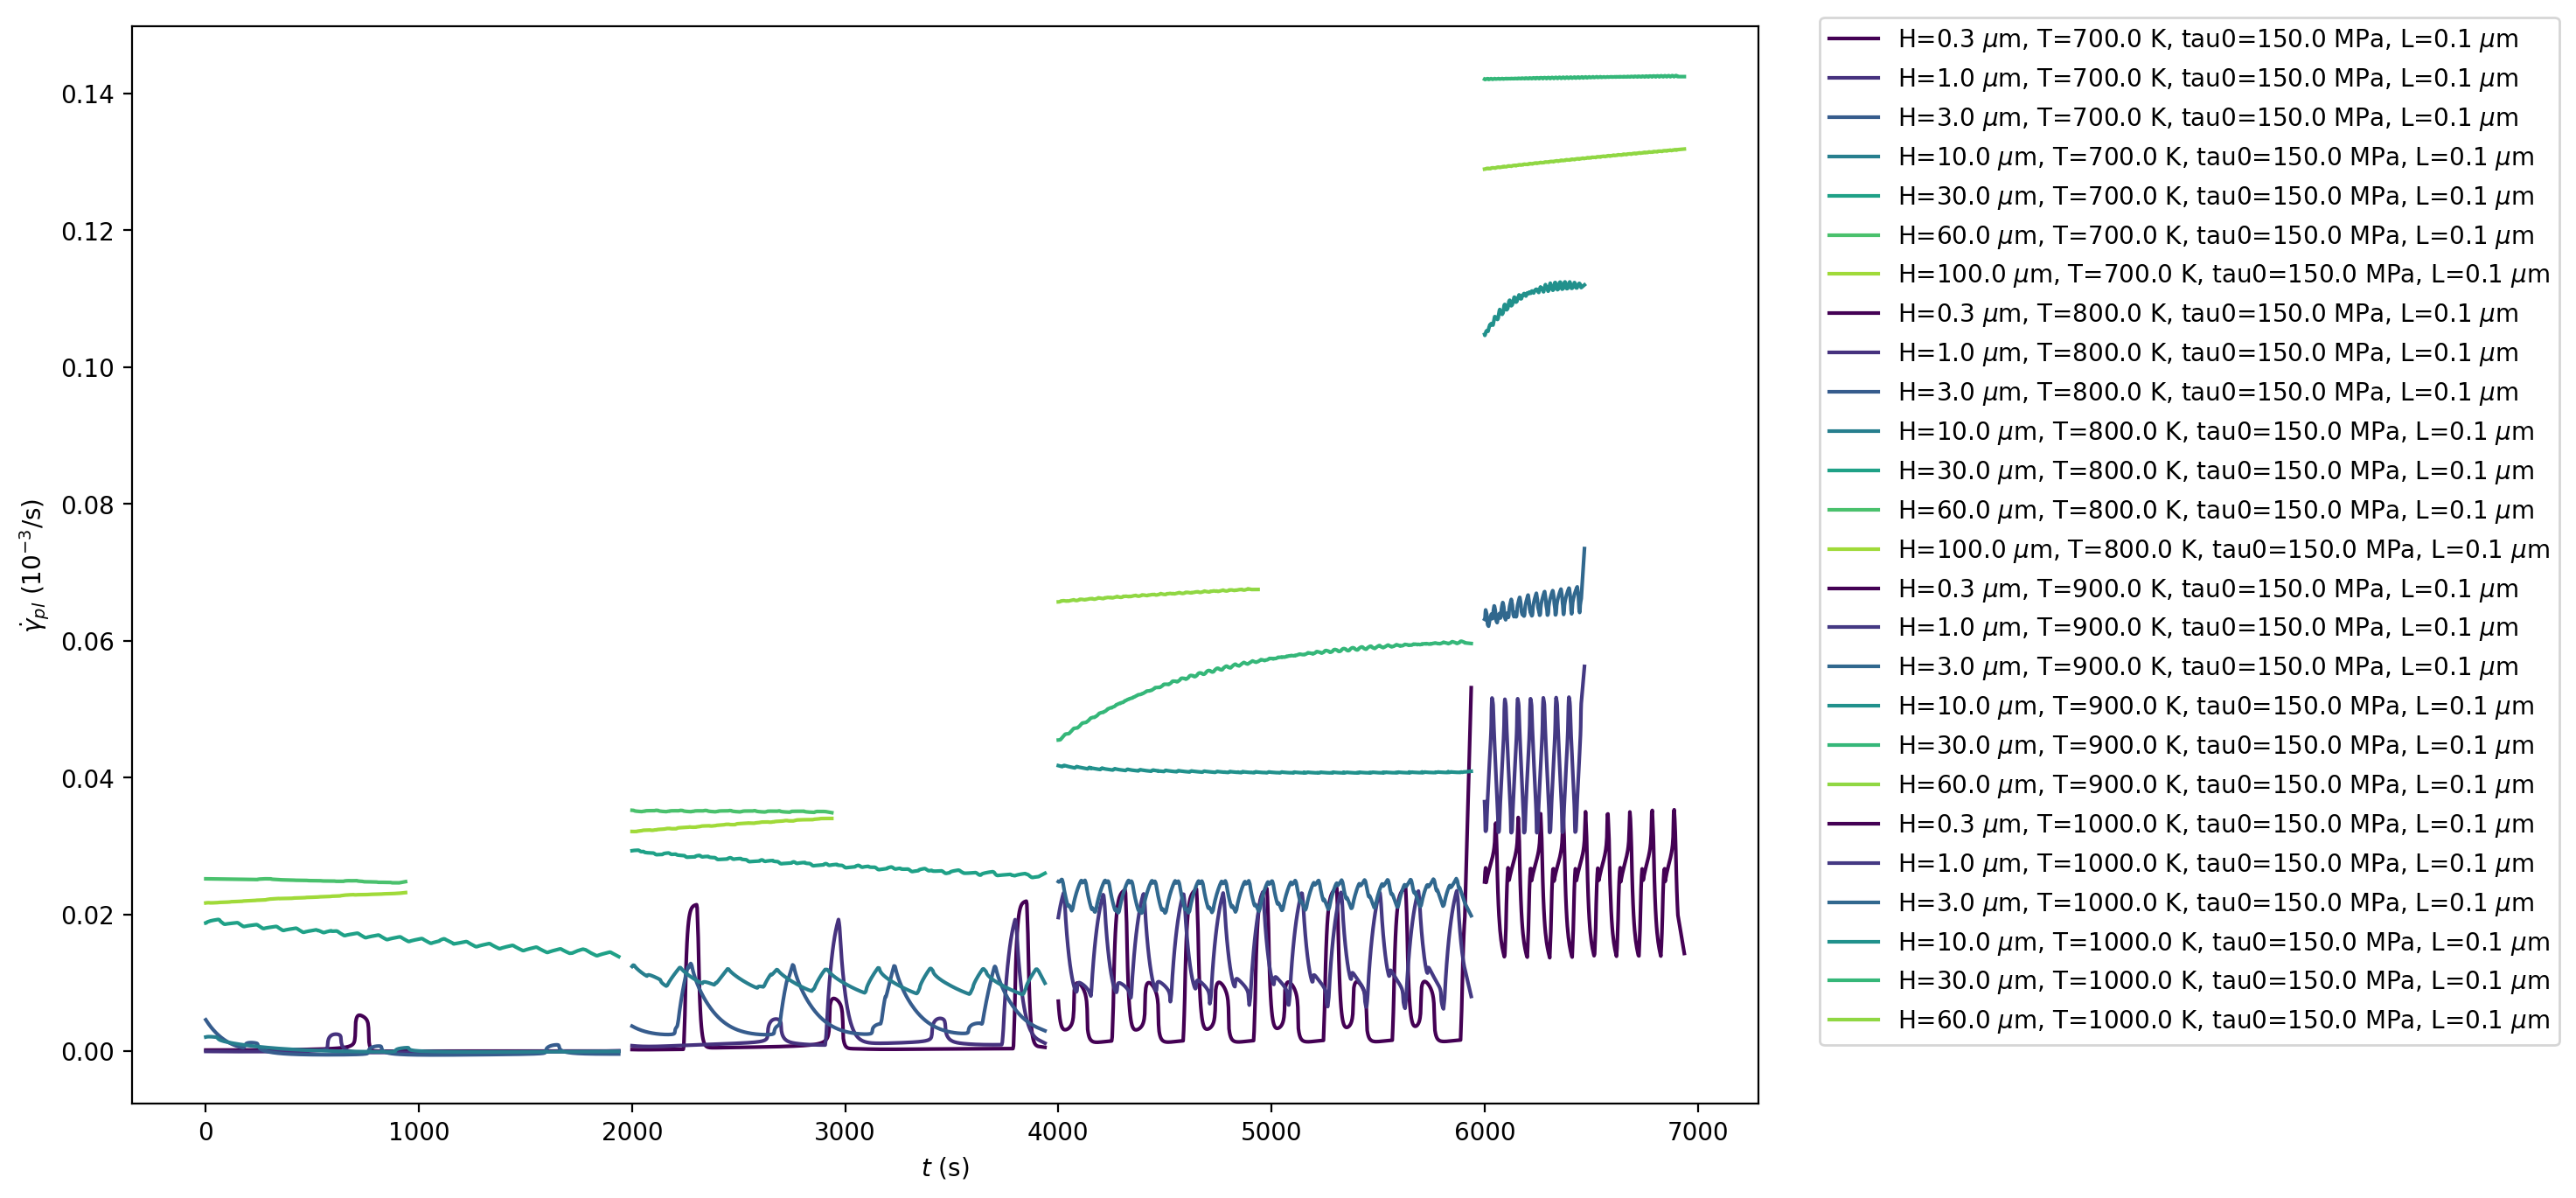

In [7]:
#store data in nd-arrays
num = len(data)
psr_ = np.zeros(num)
temp_ = np.zeros(num)
gs_ = np.zeros(num)
H_ = np.zeros(num)
L_ = np.zeros(num)
tau_ = np.zeros(num)
nit = np.zeros(num, dtype=int)
psr_flt = np.zeros((num, maxout))
stime = np.zeros((num, maxout))

def _find_ls(h):
    ls = None
    if np.isclose(h, 0.3):
        ls=":"
    elif np.isclose(h, 1.):
        ls = "-."
    elif np.isclose(h, 3.):
        ls = "--"
    elif np.isclose(h, 10.):
        ls = "-"
    elif np.isclose(h, 30.):
        ls=":"
    elif np.isclose(h, 60.):
        ls = "-."
    elif np.isclose(h, 100.):
        ls = "-"
    else:
        print(f'Unrecognized height: {h}')
    return ls

hh_ = np.zeros(num)
for i, ds in enumerate(data):
    hh_[i] = ds.D2
isort = np.argsort(hh_)

for i, j in enumerate(isort):
    ds = data[j]
    nit[i] = ds.nout
    stime[i, :nit[i]] = ds.sim_time
    gs_[i] = ds.D2
    temp_[i] = ds.temp
    H_[i] = ds.D2
    L_[i] = ds.Dgp
    tau_[i] = ds.tau0
    #gplast = ds.glob_data['plastic_slip']
    psr_[i] = np.mean(ds.glob_data['plast_slip_rate'][-120:-5])
    wl = min(25, int(ds.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {ds.nout}")
        psr_flt[i, :nit[i]] = ds.glob_data['psr_av']
    else:
        psr_flt[i, :nit[i]-5] = savgol_filter(ds.glob_data['psr_av'][:-5], window_length=wl, polyorder=1, deriv=0)

plt.rcParams["font.size"] = 10
ioffs=20
tapp = [700, 800, 900, 1000]
hfac = lambda x: np.log(x/min(H_)) / np.log(max(H_)/min(H_))
ngbl = 0.1
cmap = plt.cm.viridis  #plasma
plfun = plt.plot  # semilogy
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for k, t in enumerate(tapp):
    ind = np.nonzero(np.logical_and(np.isclose(temp_, t), np.isclose(L_, ngbl)))[0]
    for j, i in enumerate(ind):
        cx = j/len(ind)
        col = cmap(cx)
        xval = stime[i, ioffs:nit[i]-5] - stime[i, ioffs]
        plfun(xval*1.e-6 + 2000*k,
             psr_flt[i, ioffs:nit[i]-5]*1.e9,
             marker="none",
             linestyle="solid", #_find_ls(H_[i]),
             color=col,
             label=f"H={gs_[i]}"+r" $\mu$m, " + f"T={temp_[i]} K, tau0={tau_[i]} MPa, L={L_[i]}"+r" $\mu$m"
             )
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.02))
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
#plt.savefig('pu1_conv_gd_ngbn_semilog.pdf', dpi=300, format='pdf')
plt.show()

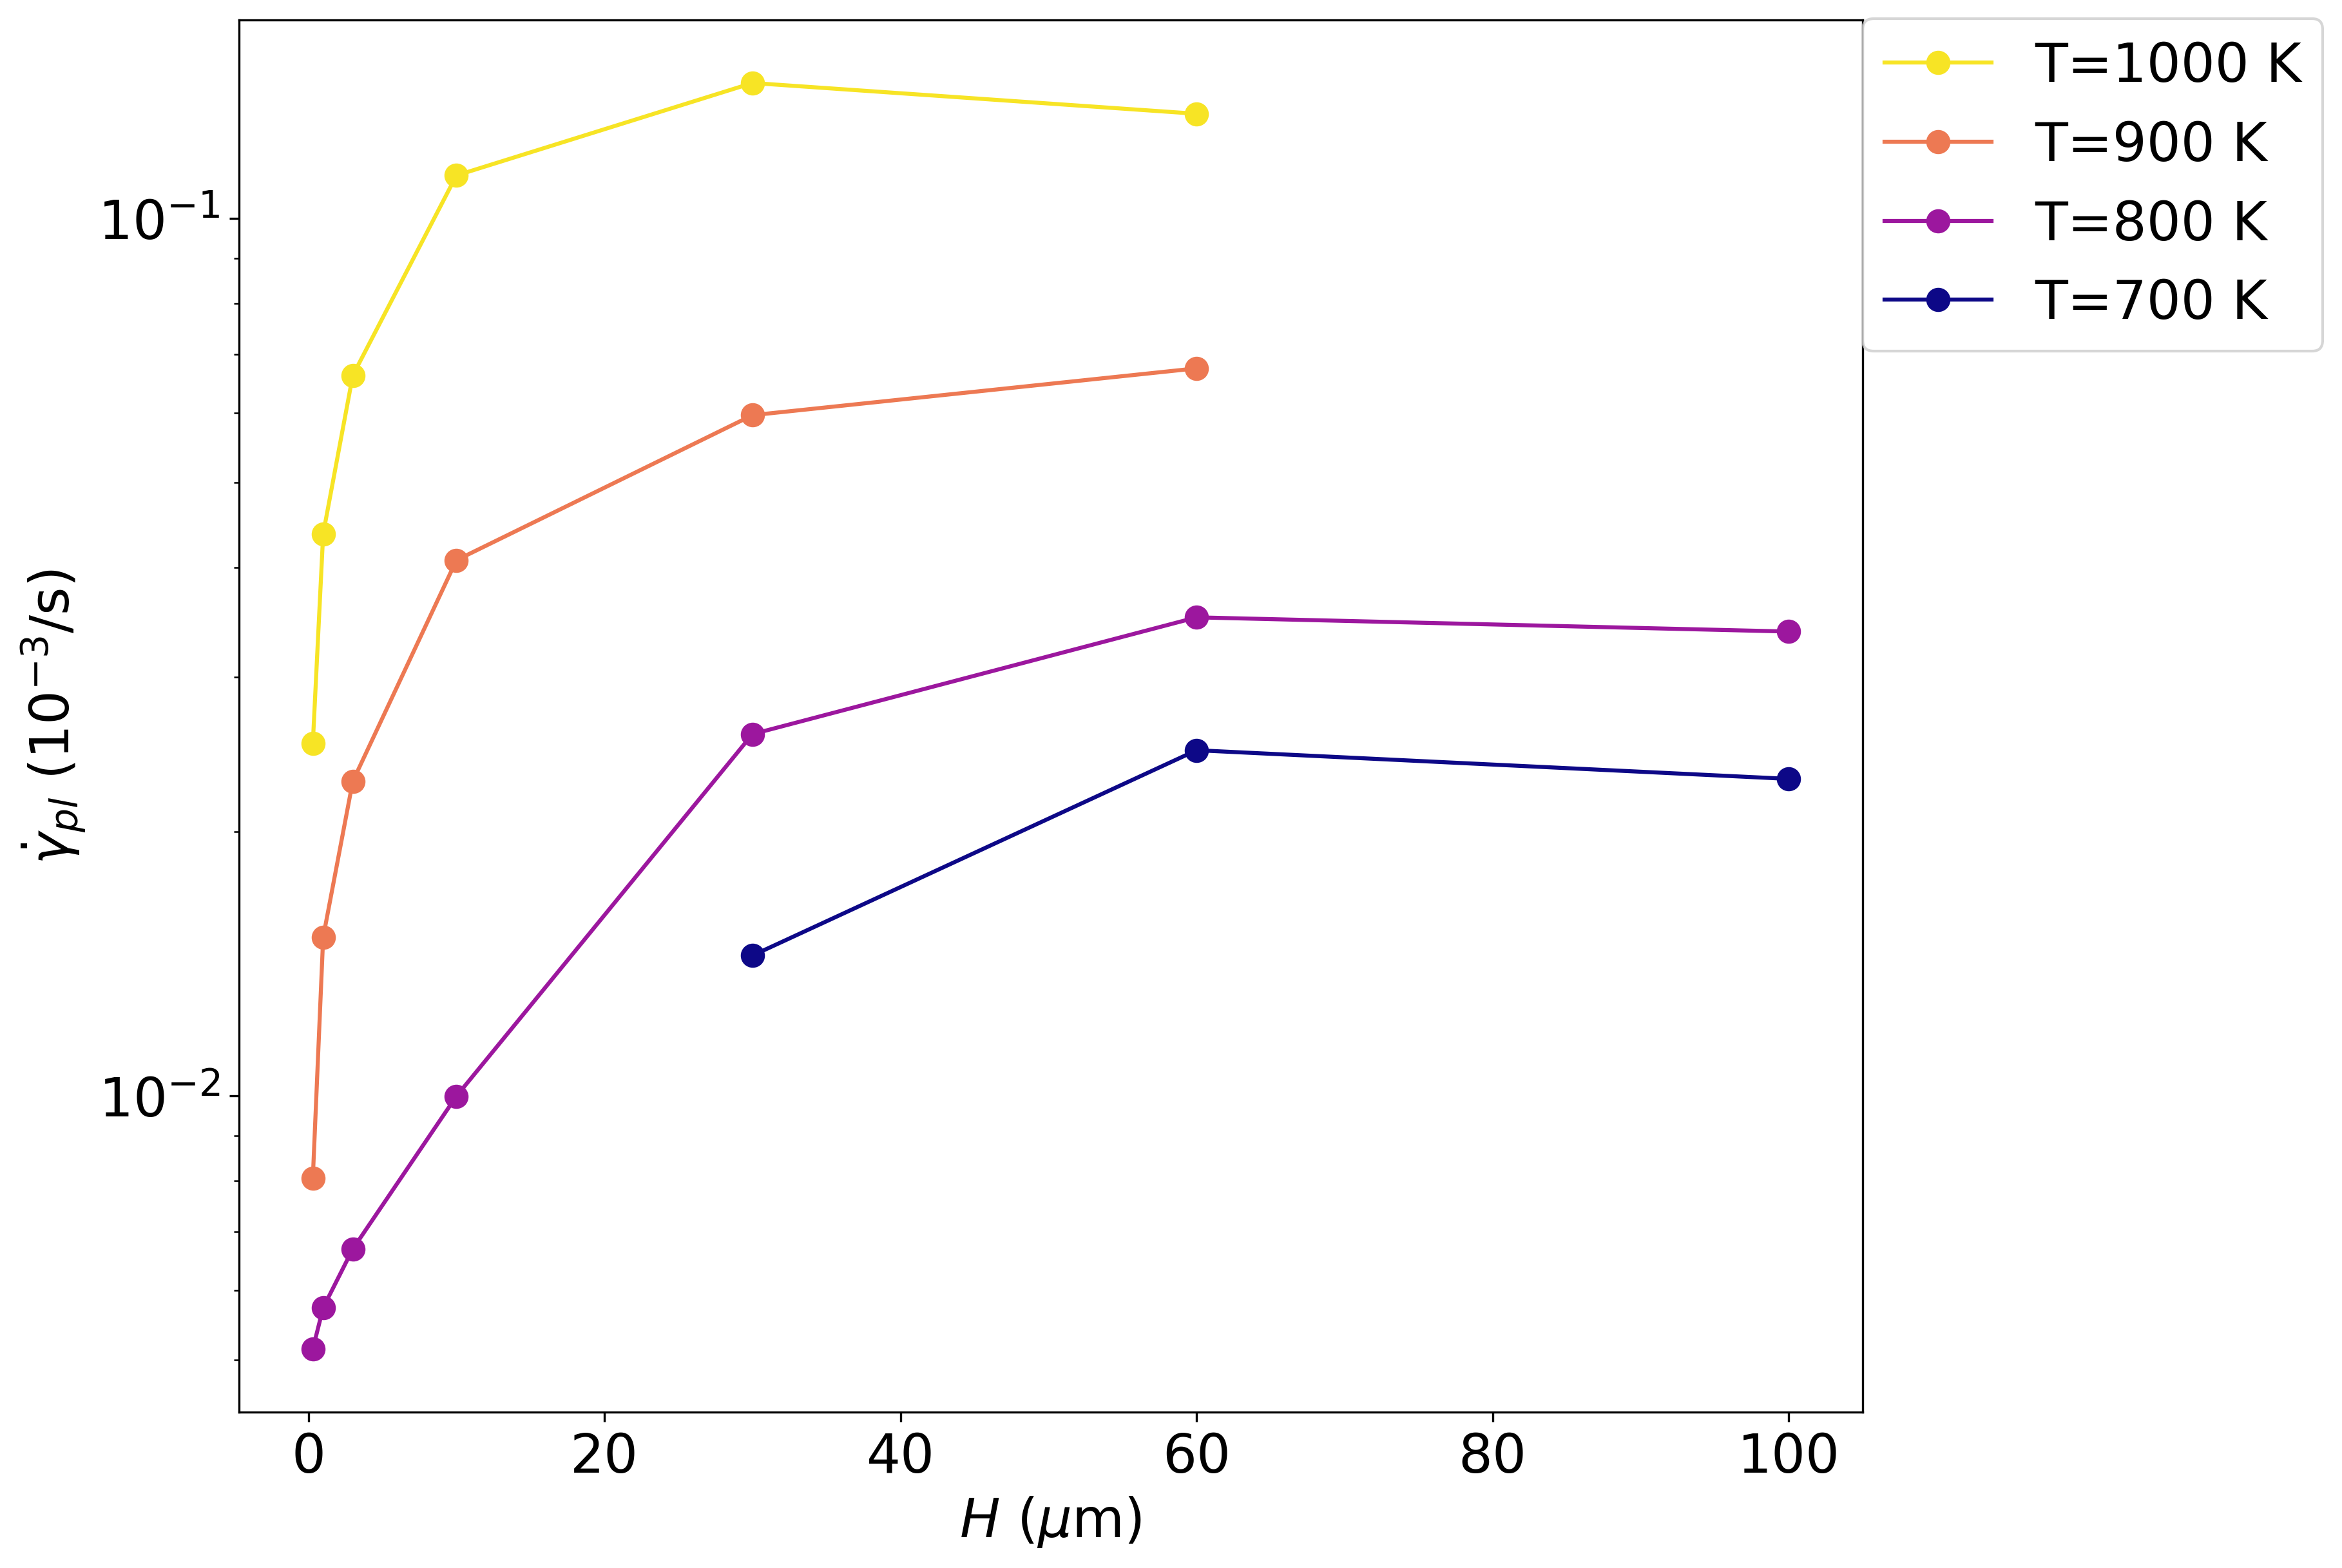

In [8]:
gs_ = np.linspace(10., 100., 50)

plt.rcParams["font.size"] = 20
fig, ax = plt.subplots(figsize=(12, 8), dpi=300, constrained_layout=True)
#gs_list = [0.3, 1., 3., 10., 30., 60.]
#xval = 1./np.sqrt(gs_list)
#x_scale = lambda x : 1./np.sqrt(x)
#xlabel = r"$1/\sqrt{H}$ ($\mu$m$^{-1/2}$)"
xlabel = r"$H$ ($\mu$m)"
x_scale = lambda x : x
cmap = plt.cm.plasma
ngbl = 0.1
plfun = plt.semilogy
ind = np.nonzero(np.logical_and(np.isclose(temp_, 1000.), np.isclose(L_, ngbl)))[0]
plfun(x_scale(H_[ind]), psr_[ind]*1.e9,
         color=cmap(0.95),
         linestyle = "solid",
         marker = 'o',
         markersize = 8,
         label=f"T=1000 K")#, Lgb={ngbl}"+r"$\mu$m")
#plt.semilogy(gs_, eps_dot(150, 1000., gs_), '-k')
ind = np.nonzero(np.logical_and(np.isclose(temp_, 900.), np.isclose(L_, ngbl)))[0]
plfun(x_scale(H_[ind]), psr_[ind]*1.e9,
         color=cmap(0.667),
         linestyle = "solid",
         marker = 'o',
         markersize = 8,
         label=f"T=900 K")#, Lgb={ngbl}"+r"$\mu$m")
ind = np.nonzero(np.logical_and(np.isclose(temp_, 800.), np.isclose(L_, ngbl)))[0]
plfun(x_scale(H_[ind]), psr_[ind]*1.e9,
         color=cmap(0.333),
         linestyle = "solid",
         marker = 'o',
         markersize = 8,
         label=f"T=800 K")#, Lgb={ngbl}"+r"$\mu$m")
ind = np.nonzero(np.logical_and(np.isclose(temp_,700.), np.isclose(L_, ngbl)))[0]
ind = [i for i in ind if H_[i]>=30.]
plfun(x_scale(H_[ind]), psr_[ind]*1.e9,
         color=cmap(0.),
         linestyle = "solid",
         marker = 'o',
         markersize = 8,
         label=f"T=700 K")#, Lgb={ngbl}"+r"$\mu$m")
plt.xlabel(xlabel)
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.02))
plt.savefig('creep_rate_vs_H.pdf', dpi=300, format='pdf')
plt.show()

In [10]:
eps_dot(150, 1000., gs_)


array([1.25620270e+20, 7.57467461e+19, 4.91386877e+19, 3.36672145e+19,
       2.40652947e+19, 1.77936237e+19, 1.35249693e+19, 1.05194708e+19,
       8.34241617e+18, 6.72694544e+18, 5.50305130e+18, 4.55892887e+18,
       3.81899425e+18, 3.23090135e+18, 2.75761616e+18, 2.37243593e+18,
       2.05577715e+18, 1.79305600e+18, 1.57326035e+18, 1.38796949e+18,
       1.23066972e+18, 1.09626889e+18, 9.80747258e+17, 8.80902954e+17,
       7.94164263e+17, 7.18449544e+17, 6.52061646e+17, 5.93607539e+17,
       5.41936591e+17, 4.96092751e+17, 4.55277212e+17, 4.18819054e+17,
       3.86151974e+17, 3.56795744e+17, 3.30341322e+17, 3.06438841e+17,
       2.84787856e+17, 2.65129391e+17, 2.47239405e+17, 2.30923424e+17,
       2.16012080e+17, 2.02357412e+17, 1.89829777e+17, 1.78315253e+17,
       1.67713464e+17, 1.57935734e+17, 1.48903529e+17, 1.40547125e+17,
       1.32804482e+17, 1.25620270e+17])

In [ ]:
#store data in nd-arrays
num = len(data)
psr_ = np.zeros(num)
temp_ = np.zeros(num)
gs_ = np.zeros(num)
H_ = np.zeros(num)
L_ = np.zeros(num)
tau_ = np.zeros(num)
nit = np.zeros(num, dtype=int)
psr_flt = np.zeros((num, maxout))
stime = np.zeros((num, maxout))

def _find_ls(h):
    ls = None
    if np.isclose(h, 0.3):
        ls=":"
    elif np.isclose(h, 1.):
        ls = "-."
    elif np.isclose(h, 3.):
        ls = "--"
    elif np.isclose(h, 10.):
        ls = "-"
    elif np.isclose(h, 30.):
        ls=":"
    elif np.isclose(h, 60.):
        ls = "-."
    elif np.isclose(h, 100.):
        ls = "-"
    else:
        print(f'Unrecognized height: {h}')
    return ls


for i, ds in enumerate(data):
    nit[i] = ds.nout
    stime[i, :nit[i]] = ds.sim_time
    gs_[i] = ds.D2
    temp_[i] = ds.temp
    H_[i] = ds.D2
    L_[i] = ds.Dgp
    tau_[i] = ds.tau0
    #gplast = ds.glob_data['plastic_slip']
    psr_[i] = np.mean(ds.glob_data['plast_slip_rate'][-120:-5])
    wl = min(25, int(ds.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {ds.nout}")
        psr_flt[i, :nit[i]] = ds.glob_data['psr_av']
    else:
        psr_flt[i, :nit[i]-1] = savgol_filter(ds.glob_data['psr_av'][:-1], window_length=wl, polyorder=1, deriv=0)
    

plt.rcParams["font.size"] = 10
ioffs=20
tapp = [700, 800, 900, 1000]
hfac = lambda x: np.log(x/min(H_)) / np.log(max(H_)/min(H_))
ngbl = 0.1
cmap = plt.cm.plasma
plfun = plt.plot  # semilogy
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for k, t in enumerate(tapp):
    ind = np.nonzero(np.logical_and(np.isclose(temp_, t), np.isclose(L_, ngbl)))[0]
    for j, i in enumerate(ind):
        cx = k/3.5
        col = cmap(cx)
        plfun(stime[i, ioffs:nit[i]-5]*1.e-6,
             psr_flt[i, ioffs:nit[i]-5]*1.e9,
             marker="none",
             linestyle=_find_ls(H_[i]),
             color=col,
             label=f"H={gs_[i]}"+r" $\mu$m, " + f"T={temp_[i]} K, tau0={tau_[i]} MPa, L={L_[i]}"+r" $\mu$m"
             )
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.02))
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
#plt.savefig('pu1_conv_gd_ngbn_semilog.pdf', dpi=300, format='pdf')
plt.show()



In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
#xval = 1./np.sqrt(gs_list)
#xlabel = r"$1/\sqrt{H}$ ($\mu$m$^{-1/2}$)"
xlabel = r"$H$ ($\mu$m)"
for i, ds in enumerate(data):
    plt.plot(ds.D2, ds.npu_max,
             color=plt.cm.viridis(ds.temp/900.),
             linestyle = "none",
             marker = 'o',
             #label=f"T={ds.temp} K"
            )
xv = np.linspace(0, 40, 50)
ds = data[0]
hc = np.pi*(1. - ds.nu)/(ds.mu*ds.B)*ds.tau0
yv = hc * xv
plt.plot(xv, yv, '-k')
plt.xlabel(xlabel)
plt.ylabel("max(N_dis)")
plt.legend()
plt.show()

In [ ]:
# set simulation parameters
temp = 900.0
tau0 = 150.0
lgb = 0.1
delta = 0.004
ngbn = int(lgb/delta)
if ngbn % 2 == 0: ngbn += 1
dtmax = 6.25e-7/delta**4  # value 1.e4 for delta=0.005, 50. for PU
#grain_size = 1.0
tfin = 1.5e9
niter = 500_000_000

# set variable quantity
D2_list = [1]
Np = len(D2_list)

# initialize arrays to store results
psr_av = np.zeros((Np, maxout))
gplast = np.zeros((Np, maxout))
sim_time = np.zeros((Np, maxout))
nit = np.zeros(Np, dtype=int)
gs_list = np.zeros(Np)

# run simulations
for i, gs in enumerate(D2_list):
    print(f"Simulation with N_gbn={ngbn}, grain_size={gs}, dtmax={dtmax}")
    gbdd = dd.GB_dislocations(temp=temp, tau0=tau0,
                       Ngbn=ngbn, len_gb_seg=lgb, grain_size=gs,
                       tfin=tfin, niter=niter, maxout=maxout,
                       dtmax=dtmax,
                       screenout=True)
    gbdd.run_sim()
    gbdd.save_hdf5(f"pu1_tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.h5")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    #gbdd.plot_time_series('plastic_slip', fs=26, lw=3)
    gbdd.plot_time_series('psr_av', fs=26, lw=4,
                          file=f"pu1_gd_tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    gbdd.plot_field('displacement', fs=26, lw=4, nplot=6,
                    file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    gbdd.plot_field('bfield', fs=26, lw=3, nplot=6,
                    file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    nit[i] = gbdd.nout
    gs_list[i] = gs
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    wl = min(25, int(gbdd.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {gbdd.nout}")
        psr_av[i, 0:gbdd.nout] = gbdd.glob_data['psr_av']
    else:
        psr_av[i, 0:gbdd.nout-1] = savgol_filter(gbdd.glob_data['psr_av'][:-1], window_length=wl, polyorder=1, deriv=0)
    gplast[i, 0:gbdd.nout] = gbdd.glob_data['plastic_slip']
    psr_list[i] = np.mean(gbdd.glob_data['plast_slip_rate'][-100:])


In [ ]:
# read existing data from GDF5 files
for i, fname in enumerate(flist):
    gbdd = dd.GB_dislocations(from_file=path+fname+".h5")
    print(f"Data file with D={gbdd.D2}, delta={gbdd.Dgp}, dtmax={gbdd.dtmax}")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    print(f"** Max. time step = {max(gbdd.glob_data['timestep'])}, Median: {np.median(gbdd.glob_data['timestep'])}")
    #gbdd.plot_time_series('max_bdot')
    #gbdd.plot_time_series('plast_slip_rate')
    gbdd.plot_time_series('psr_av')
    #gbdd.plot_field('displacement')
    gbdd.plot_field('bfield')
    nit[i] = gbdd.nout
    gs_list[i] = gbdd.D2
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    wl = min(25, int(gbdd.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {gbdd.nout}")
        psr_av[i, 0:gbdd.nout] = gbdd.glob_data['psr_av']
    else:
        psr_av[i, 0:gbdd.nout-1] = savgol_filter(gbdd.glob_data['psr_av'][:-1], window_length=wl, polyorder=1, deriv=0)
    gplast[i, 0:gbdd.nout] = gbdd.glob_data['plastic_slip']
    psr_list[2, i] = np.mean(gbdd.glob_data['plast_slip_rate'][-100:])
    temp_list[2] = 500.
                          

In [ ]:
plt.rcParams["font.size"] = 20

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for i in range(Np):
    plt.plot(sim_time[i, :nit[i]-20]*1.e-6,
             psr_av[i, :nit[i]-20]*1.e9,
             marker="none",
             linestyle="-",
             color=plt.cm.viridis(i / max(1, Np)),
             label=f"D={gs_list[i]}"+r" $\mu$m"
             )
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.02))
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
#plt.savefig('pu1_conv_gd_ngbn_semilog.pdf', dpi=300, format='pdf')
plt.show()

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
#xval = 1./np.sqrt(gs_list)
#xlabel = r"$1/\sqrt{H}$ ($\mu$m$^{-1/2}$)"
xval = gs_list
xlabel = r"$H$ ($\mu$m)"
plt.plot(xval, psr_list[0,:-1]*1.e9,
         color='red',
        label=f"T=900 K")
plt.plot(xval, psr_list[1,:-1]*1.e9,
         color='orange',
        label=f"T=700 K")
plt.plot(xval, psr_list[2,:-1]*1.e9,
         color='blue',
        label=f"T=500 K")
plt.xlabel(xlabel)
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
plt.legend()
plt.show()

In [ ]:
psr_list

In [ ]:
gbdd.plot_pile_up()
gbdd.plot_time_series('n_slip_dis')

In [ ]:
it = 500
plt.rcParams["font.size"] = 12
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
assert npu == gbdd.glob_data['n_slip_dis'][it]
ngbn = gbdd.Ngbn
Nc = int((ngbn+1)/2) - 1
gbdx = gbdd.Dgp/(ngbn-1)
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
print(f"Number of dislocations: {npu}, Simulation time: {gbdd.sim_time[it]*1.e-6}")

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
plot_stress_bfield(file=f"sigpu_tau{int(gbdd.tau0)}_T{int(gbdd.temp)}_D{int(gbdd.D2*10)}_L{int(gbdd.Dgp*10)}.pdf", cutoff=200)


In [ ]:

gbdd.Dgp